<a href="https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.en/cap09/cap09_aluno.ipynb"><img src="imagens/colab-badge.png" style="height:20px;vertical-align:middle"></a>
<a href="https://github.com/fzampirolli/pdi-vc"><img src="imagens/github-badge.png" style="height:20px;vertical-align:middle"></a>

# 9 Deep Learning for Computer Vision

The previous chapters established the foundations of Computer Vision (CV) through classical methods of feature extraction and representation. In **Chapter 7**, descriptors such as *Local Binary Patterns* (*LBP*) and *Histogram of Oriented Gradients* (*HOG*) showed how textures and shapes can be encoded by manually designed descriptors. In **Chapter 8**, algorithms such as *Oriented FAST and Rotated BRIEF* (*ORB*) and the *Haar Cascade* detector extended this principle to tasks of matching, detection, and object recognition.

These techniques remain relevant for their interpretability and computational efficiency, but they rely on a prior step of manually defining descriptors, known as **feature engineering**. This dependence limits the model's adaptation to scenarios for which the descriptor was not designed.

**Deep Learning** proposes an alternative: instead of manually specifying the relevant features, the model automatically learns representations from the data during training—a process known as **representation learning** (GOODFELLOW, 2016). In CV, this strategy is implemented mainly through **Convolutional Neural Networks** (CNNs), in which convolutional filters no longer have fixed coefficients and are instead adjusted by optimization algorithms.

Although they represent a shift in the construction of pattern recognition systems, CNNs preserve concepts already studied in this book: the convolution, presented in **Chapter 3**, remains the operation responsible for local feature extraction, now applied with learned coefficients rather than designed ones.

It is worth noting that the goal of this chapter is not to exhaustively explore the theory of Deep Learning, but rather to offer an overview of its foundations and to demonstrate how these architectures are applied in the context of CV. Readers interested in a deeper theoretical and conceptual understanding of the field should refer to specialized references in the literature, such as Goodfellow (2016) and Lecun (2015).

## 9.1 Chapter Objectives

By the end of this chapter, the student should be able to:

- Relate the convolution learned by CNNs to the convolution of fixed *kernels* presented in **Chapter 3**;
- Describe the basic architecture of a CNN and the function of its main layers;
- Implement, train, and evaluate CNN models for image classification;
- Apply **transfer learning** to adapt pre-trained models to new problems;
- Use pre-trained models in classification, object detection, and segmentation tasks;
- Implement, train, and evaluate a *U-Net* architecture for semantic segmentation, comparing it to classical approaches;
- Prepare annotated datasets and integrate them into a training *pipeline* through platforms such as **Roboflow**;
- Integrate computational geometry and Deep Learning in augmented reality and photogrammetry applications.

[Figure 9.1](#fig-09-infografo) synthesizes the organization of the concepts studied in this chapter and the relationships among them.

<figure id="fig-09-infografo" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-infografo.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figure 9.1:</strong> Overview of the main concepts addressed in this chapter. **Source:** prepared with the aid of *Gemini Notebook* ({GOOGLE}, 2025).</figcaption>
</figure>

## 9.2 Overview: Classification, Detection, and Segmentation

Computer vision tasks primarily differ in the information produced as output. **Classification** assigns a single label to the entire image; **object detection** locates and identifies objects present in the scene; **segmentation** associates a class with each pixel and, in some approaches, distinguishes different instances of the same category.

[Table 9.1](#tbl-panorama-tarefas) summarizes the tasks studied throughout the book, indicating the question each one answers and the granularity of the information produced.

<a id="tbl-panorama-tarefas"></a>

**Tabela 9.1:** Comparison among the main computer vision tasks according to the granularity of the information produced.

| Task | Question Answered | Output Granularity | Chapter |
|-----------------------------|-----------------------------------------------|-------------------------------------------------------------|:--------:|
| **Classification** | "What is the class of this image?" | A single label for the entire image | 7 and 9 |
| **Object detection** | "Which objects exist and where are they?" | Class and bounding box for each object | 8 and 9 |
| **Semantic segmentation** | "To which class does each pixel belong?" | A class label for each pixel | 8 and 9 |
| **Instance segmentation** | "Which pixels belong to each object?" | One label per pixel for each instance | 8 and 9 |
| **Panoptic segmentation** | "What is the class and identity of each object?" | Class and instance identifier for each pixel | 8 and 9 |


These tasks represent increasing levels of image interpretation: classification describes the scene globally, detection adds the location of objects, and segmentation produces a detailed spatial representation, allowing each region to be analyzed individually. This chapter focuses first on classification by CNNs, then extends the same principles to detection and segmentation.

## 9.3 Environment Setup

The examples in this chapter use **PyTorch**, a *framework* widely employed in the development and training of Deep Learning models. The following code checks the availability of the required libraries and automatically installs those not yet present in the execution environment.

If **PyTorch** is not installed, a version compatible with the available hardware is automatically selected: the version with **CUDA** support, if an NVIDIA GPU is available, or the CPU execution version, otherwise.

Next, the environment is initialized with the import of the libraries used throughout the chapter, the definition of a random seed to favor experiment reproducibility, and the retrieval of the `morph.py` file — the didactic morphological processing library already used in previous chapters —, if it is not yet available in the working directory.

In [1]:
import contextlib, importlib, importlib.metadata, importlib.util
import io, os, random, shutil, subprocess, sys, urllib.request, warnings

# Suppresses PyTorch warnings and general warnings
warnings.filterwarnings("ignore", category=UserWarning)

url = ("https://raw.githubusercontent.com/fzampirolli/"
       "pdi-vc/master/morph/config.py")
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config

# Silences stdout and stderr both at Python level and at OS File Descriptor level
def setup_silencioso():
    with open(os.devnull, "w") as fnull:
        old_out = os.dup(1)
        old_err = os.dup(2)
        try:
            os.dup2(fnull.fileno(), 1)
            os.dup2(fnull.fileno(), 2)
            with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
                config.setup()
        finally:
            os.dup2(old_out, 1)
            os.dup2(old_err, 2)
            os.close(old_out)
            os.close(old_err)

setup_silencioso()
from morph import mm


def setup_cap09():
    """Installs missing libs for this chapter in a 100% silent way."""
    pkgs = {
        "skimage": "scikit-image", "numpy": "numpy",
        "sklearn": "scikit-learn", "matplotlib": "matplotlib",
        "torchviz": "torchviz", "ultralytics": "ultralytics",
        "roboflow": "roboflow",
    }
    for mod, pkg in pkgs.items():
        if importlib.util.find_spec(mod) is None:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    if importlib.util.find_spec("torch") is None:
        args = (["torch", "torchvision"] if shutil.which("nvidia-smi")
                 else ["--index-url",
                       "https://download.pytorch.org/whl/cpu",
                       "torch", "torchvision"])
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    if not shutil.which("dot") and shutil.which("apt-get"):
        subprocess.run(["apt-get", "install", "-y", "-qq", "graphviz"],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)


setup_cap09()

import cv2, numpy as np, torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from skimage import data as skdata
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import OxfordIIITPet
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights)
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.transforms.functional import to_tensor
from torchviz import make_dot
from ultralytics import YOLO

torch.manual_seed(42)
FLAG_LIMPAR_DADOS = False
device = "cuda" if torch.cuda.is_available() else "cpu"
gpu = f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""
ver = importlib.metadata.version("ultralytics")
print(f"✅ Environment ready. OpenCV {cv2.__version__} | "
      f"morph {getattr(mm, '__version__', 'local_file')} | "
      f"PyTorch {torch.__version__} | Ultralytics {ver} | {device}{gpu}")

✅ Environment ready. OpenCV 5.0.0 | morph local_file | PyTorch 2.6.0+cu124 | Ultralytics 8.4.113 | cuda (NVIDIA GeForce GTX TITAN X)


## 9.4 Fundamentals of Deep Learning for CV

CNNs are the primary Deep Learning architecture applied to image analysis. Their operation is based on the composition of convolutional operations organized into successive layers, in which the filters learned during training transform the image into progressively more abstract representations. This section presents the fundamental concepts that connect the spatial convolution studied previously to modern CV models, including hierarchical feature extraction, the training process, and the use of pre-trained models.

### 9.4.1 From Fixed Convolution to Learned Convolution

**Chapter 3** presented spatial convolution with fixed *kernels*, such as the Sobel operators, designed to highlight specific features of an image. In **Chapters 7** and **8**, the same principle underpinned descriptors such as *HOG*, *LBP*, and *ORB*, as well as the *Haar Cascade* detector: in all these cases, the filters are defined before the execution of the algorithm and remain unchanged during processing.

[Figure 9.2](#fig-09-sim-09-convolucao) revisits how spatial convolution works: the simulator allows selecting different *kernels* and following the displacement of the convolution window over an image. At each position, the *kernel* coefficients combine with the local neighborhood of the image — known as the **receptive field** — to produce a value in the **feature map**, also illustrating weight sharing.

CNNs preserve this operation but replace fixed *kernels* with **learned filters**: instead of predefined coefficients, the network adjusts these values during training from labeled examples, seeking to minimize a **loss function**, which measures the difference between the model's predictions and the expected responses.

The essential difference between classical methods and CNNs, therefore, lies not in the convolution operation itself, but in how the filters are obtained: whereas the former use manually designed filters, CNNs learn, from the training data, representations suited to the task.

In [2]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-convolucao" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-convolucao .cap09conv_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-convolucao .cap09conv_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-convolucao .cap09conv_btn {
      font-size:11px; font-weight:600; padding:6px 10px; border-radius:6px;
      border:1px solid #E4DCC8; background:#FFF; color:#26241D; cursor:pointer;
      transition:all .15s ease;
    }
    #sim-09-convolucao .cap09conv_btn:hover { background:#F1EAD7; }
    #sim-09-convolucao .cap09conv_modebtn {
      flex:1; text-align:center; padding:5px 8px; font-size:11px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:8px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-convolucao .cap09conv_modebtn.cap09conv_active { background:#26241D; color:#FBF7EE; }
    #sim-09-convolucao .cap09conv_btn.cap09conv_active { background:#26241D !important; color:#FBF7EE !important; border-color:#26241D !important; }
    #sim-09-convolucao .cap09conv_btn_primary { background:#2F6F9F; color:#FFF; border-color:#2F6F9F; }
    #sim-09-convolucao .cap09conv_btn_primary:hover { background:#245880; }
    #sim-09-convolucao .cap09conv_btn_success { background:#1E8F6F; color:#FFF; border-color:#1E8F6F; }
    #sim-09-convolucao .cap09conv_btn_success:hover { background:#166e55; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">🎯 Simulator: Classic 2D Convolution Operation</span>
    <span class="cap09conv_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Input 12×12 · Kernel 3×3 · Stride 1</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Painel de Seleção de Imagens e Kernels -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;margin-bottom:12px;">
      <div style="flex:1;min-width:230px;">
        <div class="cap09conv_grouplabel">INPUT IMAGE (12×12)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09conv_btnCasa" class="cap09conv_modebtn cap09conv_active">🏠 House</button>
          <button id="cap09conv_btnFeliz" class="cap09conv_modebtn">😊 Happy</button>
          <button id="cap09conv_btnTriste" class="cap09conv_modebtn">😢 Sad</button>
        </div>
      </div>

      <div style="flex:1;min-width:280px;">
        <div class="cap09conv_grouplabel">FILTER (KERNEL 3×3)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09conv_btnSobelV" class="cap09conv_btn cap09conv_active">📐 Sobel V</button>
          <button id="cap09conv_btnSobelH" class="cap09conv_btn">📏 Sobel H</button>
          <button id="cap09conv_btnSharpen" class="cap09conv_btn">✨ Sharpen</button>
          <button id="cap09conv_btnIdentidade" class="cap09conv_btn">🎯 Identity</button>
        </div>
      </div>
    </div>

    <!-- Controles do Passo a Passo -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-bottom:12px;">
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;justify-content:space-between;">
        <div style="display:flex;gap:6px;align-items:center;">
          <button id="cap09conv_btnPasso" class="cap09conv_btn cap09conv_btn_success">▶ Step Forward</button>
          <button id="cap09conv_btnTudo" class="cap09conv_btn cap09conv_btn_primary">⏭ Calculate All</button>
          <button id="cap09conv_btnReset" class="cap09conv_btn">↺ Reset</button>
        </div>
        <span class="cap09conv_mono" style="font-size:11px;color:#5b5647;">Current Position: <b id="cap09conv_posTxt" style="color:#2F6F9F;">(0, 0)</b> [Output 10×10]</span>
      </div>
    </div>

    <!-- Área Gráfica: Entrada, Kernel e Saída -->
    <div style="display:flex;gap:18px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Input (12×12)</div>
        <canvas id="cap09conv_canvasEntrada" style="width:240px;height:240px;"></canvas>
      </div>

      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Kernel (3×3)</div>
        <canvas id="cap09conv_canvasKernel" style="width:105px;height:105px;"></canvas>
      </div>

      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Output Map (10×10)</div>
        <canvas id="cap09conv_canvasSaida" style="width:200px;height:200px;"></canvas>
      </div>
    </div>

    <!-- Terminal de Cálculo em Tempo Real -->
    <div id="cap09conv_calcTxt" class="cap09conv_mono" style="text-align:center;font-size:11px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:8px 10px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;overflow-x:auto;">
      ∑ (xᵢ × wᵢ) = current position calculation...
    </div>

  </div>
</div>

<script>
(function(){
  var cap09conv_IMAGENS = {
    casa: [
      "............", "....XXXX....", "...XXXXXX...", "..XXXXXXXX..",
      ".XXXXXXXXXX.", ".XXXXXXXXXX.", ".XXXXXXXXXX.", ".XXXXXXXXXX.",
      ".XXXX..XXXX.", ".XXXX..XXXX.", ".XXXX..XXXX.", "............"
    ],
    feliz: [
      "............", "....XXXX....", "..XXXXXXXX..", ".XXXXXXXXXX.",
      ".XXXXXXXXXX.", ".XXX.XX.XXX.", ".XXXXXXXXXX.", ".XX......XX.",
      ".XXX....XXX.", ".XXXXXXXXXX.", "..XXXXXXXX..", "............"
    ],
    triste: [
      "............", "....XXXX....", "..XXXXXXXX..", ".XXXXXXXXXX.",
      ".XXXXXXXXXX.", ".XXX.XX.XXX.", ".XXXXXXXXXX.", ".XXX....XXX.",
      ".XX......XX.", ".XXXXXXXXXX.", "..XXXXXXXX..", "............"
    ]
  };

  var cap09conv_KERNELS = {
    sobelV:     { nome: "Sobel Vertical", k: [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]] },
    sobelH:     { nome: "Sobel Horizontal", k: [[-1, -2, -1], [0, 0, 0], [1, 2, 1]] },
    sharpen:    { nome: "Nitidez (Sharpen)", k: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] },
    identidade: { nome: "Identidade", k: [[0, 0, 0], [0, 1, 0], [0, 0, 0]] }
  };

  function cap09conv_converterLinhas(cap09conv_linhas){
    return cap09conv_linhas.map(function(cap09conv_l){
      var cap09conv_res = [];
      for(var cap09conv_i=0; cap09conv_i<cap09conv_l.length; cap09conv_i++) cap09conv_res.push(cap09conv_l[cap09conv_i]==='X' ? 1.0 : 0.0);
      return cap09conv_res;
    });
  }

  function cap09conv_init(cap09conv_root){
    if(!cap09conv_root || cap09conv_root.dataset.initConv) return;
    cap09conv_root.dataset.initConv = "1";

    var cap09conv_imgAtualId = "casa";
    var cap09conv_kernelAtualKey = "sobelV";

    var cap09conv_imgEntradaBase = cap09conv_converterLinhas(cap09conv_IMAGENS[cap09conv_imgAtualId]);
    var cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
    var cap09conv_pos = {r:0, c:0};

    var cap09conv_cvsEnt = cap09conv_root.querySelector('#cap09conv_canvasEntrada');
    var cap09conv_cvsKer = cap09conv_root.querySelector('#cap09conv_canvasKernel');
    var cap09conv_cvsSai = cap09conv_root.querySelector('#cap09conv_canvasSaida');

    var cap09conv_ctxEnt = cap09conv_cvsEnt.getContext('2d');
    var cap09conv_ctxKer = cap09conv_cvsKer.getContext('2d');
    var cap09conv_ctxSai = cap09conv_cvsSai.getContext('2d');

    function cap09conv_prepararCanvas(cap09conv_canvas, cap09conv_ctx, cap09conv_cssW, cap09conv_cssH){
      var cap09conv_dpr = window.devicePixelRatio || 1;
      cap09conv_canvas.width = cap09conv_cssW * cap09conv_dpr;
      cap09conv_canvas.height = cap09conv_cssH * cap09conv_dpr;
      cap09conv_ctx.scale(cap09conv_dpr, cap09conv_dpr);
    }
    cap09conv_prepararCanvas(cap09conv_cvsEnt, cap09conv_ctxEnt, 240, 240);
    cap09conv_prepararCanvas(cap09conv_cvsKer, cap09conv_ctxKer, 105, 105);
    cap09conv_prepararCanvas(cap09conv_cvsSai, cap09conv_ctxSai, 200, 200);

    var cap09conv_posTxt  = cap09conv_root.querySelector('#cap09conv_posTxt');
    var cap09conv_calcTxt = cap09conv_root.querySelector('#cap09conv_calcTxt');

    var cap09conv_btnCasa   = cap09conv_root.querySelector('#cap09conv_btnCasa');
    var cap09conv_btnFeliz  = cap09conv_root.querySelector('#cap09conv_btnFeliz');
    var cap09conv_btnTriste = cap09conv_root.querySelector('#cap09conv_btnTriste');

    var cap09conv_btnSobelV     = cap09conv_root.querySelector('#cap09conv_btnSobelV');
    var cap09conv_btnSobelH     = cap09conv_root.querySelector('#cap09conv_btnSobelH');
    var cap09conv_btnSharpen    = cap09conv_root.querySelector('#cap09conv_btnSharpen');
    var cap09conv_btnIdentidade = cap09conv_root.querySelector('#cap09conv_btnIdentidade');

    function cap09conv_desenharEntrada(){
      var cap09conv_tam = 20;
      cap09conv_ctxEnt.clearRect(0,0,240,240);
      for (var cap09conv_r=0; cap09conv_r<12; cap09conv_r++){
        for (var cap09conv_c=0; cap09conv_c<12; cap09conv_c++){
          var cap09conv_val = cap09conv_imgEntradaBase[cap09conv_r][cap09conv_c];
          var cap09conv_g = Math.round(cap09conv_val * 255);
          cap09conv_ctxEnt.fillStyle = "rgb(" + cap09conv_g + "," + cap09conv_g + "," + cap09conv_g + ")";
          cap09conv_ctxEnt.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
          cap09conv_ctxEnt.strokeStyle = "#E4DCC8";
          cap09conv_ctxEnt.lineWidth = 0.8;
          cap09conv_ctxEnt.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

          cap09conv_ctxEnt.fillStyle = cap09conv_g > 128 ? "#111827" : "#FFFFFF";
          cap09conv_ctxEnt.font = "600 8px 'JetBrains Mono', monospace";
          cap09conv_ctxEnt.textAlign = "center";
          cap09conv_ctxEnt.textBaseline = "middle";
          cap09conv_ctxEnt.fillText(cap09conv_val.toFixed(0), cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
        }
      }

      if (cap09conv_pos.r < 10) {
        cap09conv_ctxEnt.strokeStyle = "#C1443A";
        cap09conv_ctxEnt.lineWidth = 2.5;
        cap09conv_ctxEnt.strokeRect(cap09conv_pos.c*cap09conv_tam, cap09conv_pos.r*cap09conv_tam, cap09conv_tam*3, cap09conv_tam*3);
      }
    }

    function cap09conv_desenharKernel(){
      var cap09conv_tam = 35;
      cap09conv_ctxKer.clearRect(0,0,105,105);
      var cap09conv_k = cap09conv_KERNELS[cap09conv_kernelAtualKey].k;
      for (var cap09conv_i=0; cap09conv_i<3; cap09conv_i++){
        for (var cap09conv_j=0; cap09conv_j<3; cap09conv_j++){
          var cap09conv_val = cap09conv_k[cap09conv_i][cap09conv_j];
          cap09conv_ctxKer.fillStyle = cap09conv_val > 0 ? "#E6F4EA" : (cap09conv_val < 0 ? "#FCE8E6" : "#FAFAF7");
          cap09conv_ctxKer.fillRect(cap09conv_j*cap09conv_tam, cap09conv_i*cap09conv_tam, cap09conv_tam, cap09conv_tam);
          cap09conv_ctxKer.strokeStyle = "#E4DCC8";
          cap09conv_ctxKer.strokeRect(cap09conv_j*cap09conv_tam, cap09conv_i*cap09conv_tam, cap09conv_tam, cap09conv_tam);

          cap09conv_ctxKer.fillStyle = cap09conv_val > 0 ? "#1E8F6F" : (cap09conv_val < 0 ? "#C1443A" : "#8A8371");
          cap09conv_ctxKer.font = "600 10px 'JetBrains Mono', monospace";
          cap09conv_ctxKer.textAlign = "center";
          cap09conv_ctxKer.textBaseline = "middle";
          cap09conv_ctxKer.fillText(cap09conv_val.toString(), cap09conv_j*cap09conv_tam + cap09conv_tam/2, cap09conv_i*cap09conv_tam + cap09conv_tam/2);
        }
      }
    }

    function cap09conv_desenharSaida(){
      var cap09conv_tam = 20;
      cap09conv_ctxSai.clearRect(0,0,200,200);
      for (var cap09conv_r=0; cap09conv_r<10; cap09conv_r++){
        for (var cap09conv_c=0; cap09conv_c<10; cap09conv_c++){
          var cap09conv_v = cap09conv_saida[cap09conv_r][cap09conv_c];
          if (cap09conv_v === null) {
            cap09conv_ctxSai.fillStyle = "#F7F5EE";
            cap09conv_ctxSai.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
            cap09conv_ctxSai.strokeStyle = "#E4DCC8";
            cap09conv_ctxSai.lineWidth = 0.8;
            cap09conv_ctxSai.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

            cap09conv_ctxSai.fillStyle = "#B8AE94";
            cap09conv_ctxSai.font = "700 8px 'JetBrains Mono', monospace";
            cap09conv_ctxSai.textAlign = "center";
            cap09conv_ctxSai.textBaseline = "middle";
            cap09conv_ctxSai.fillText("·", cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
          } else {
            var cap09conv_normV = Math.max(0, Math.min(1, (cap09conv_v + 2.0) / 4.0));
            var cap09conv_g = Math.round(cap09conv_normV * 255);
            cap09conv_ctxSai.fillStyle = "rgb(" + cap09conv_g + "," + cap09conv_g + "," + cap09conv_g + ")";
            cap09conv_ctxSai.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
            cap09conv_ctxSai.strokeStyle = "#E4DCC8";
            cap09conv_ctxSai.lineWidth = 0.8;
            cap09conv_ctxSai.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

            cap09conv_ctxSai.fillStyle = cap09conv_g > 128 ? "#111827" : "#FFFFFF";
            cap09conv_ctxSai.font = "600 7.5px 'JetBrains Mono', monospace";
            cap09conv_ctxSai.textAlign = "center";
            cap09conv_ctxSai.textBaseline = "middle";
            cap09conv_ctxSai.fillText(cap09conv_v.toFixed(1), cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
          }
        }
      }

      if (cap09conv_pos.r < 10){
        cap09conv_ctxSai.strokeStyle = "#2F6F9F";
        cap09conv_ctxSai.lineWidth = 2;
        cap09conv_ctxSai.strokeRect(cap09conv_pos.c*cap09conv_tam, cap09conv_pos.r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
      }
    }

    function cap09conv_calcularPosicao(cap09conv_r, cap09conv_c){
      var cap09conv_k = cap09conv_KERNELS[cap09conv_kernelAtualKey].k;
      var cap09conv_soma = 0;
      var cap09conv_termos = [];
      for (var cap09conv_i=0; cap09conv_i<3; cap09conv_i++){
        for (var cap09conv_j=0; cap09conv_j<3; cap09conv_j++){
          var cap09conv_valEnt = cap09conv_imgEntradaBase[cap09conv_r+cap09conv_i][cap09conv_c+cap09conv_j];
          var cap09conv_valKer = cap09conv_k[cap09conv_i][cap09conv_j];
          var cap09conv_prod = cap09conv_valEnt * cap09conv_valKer;
          cap09conv_soma += cap09conv_prod;
          cap09conv_termos.push(cap09conv_prod >= 0 ? cap09conv_prod.toFixed(0) : '(' + cap09conv_prod.toFixed(0) + ')');
        }
      }
      return { valFinal: cap09conv_soma, expressao: cap09conv_termos.join(" + ") };
    }

    function cap09conv_atualizarCalculoTexto(){
      if (cap09conv_pos.r >= 10) {
        cap09conv_calcTxt.textContent = "Convolution Complete! All 100 pixels of the output map were generated.";
        return;
      }
      var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
      cap09conv_calcTxt.textContent = 'Position (' + cap09conv_pos.r + ',' + cap09conv_pos.c + ') → z = ' + cap09conv_obj.expressao + ' = ' + cap09conv_obj.valFinal.toFixed(2);
    }

    function cap09conv_avancarPasso(){
      if (cap09conv_pos.r >= 10) return;
      var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
      cap09conv_saida[cap09conv_pos.r][cap09conv_pos.c] = cap09conv_obj.valFinal;
      cap09conv_pos.c++;
      if (cap09conv_pos.c >= 10){ cap09conv_pos.c = 0; cap09conv_pos.r++; }
      cap09conv_render();
    }

    function cap09conv_calcularTudo(){
      while (cap09conv_pos.r < 10) {
        var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
        cap09conv_saida[cap09conv_pos.r][cap09conv_pos.c] = cap09conv_obj.valFinal;
        cap09conv_pos.c++;
        if (cap09conv_pos.c >= 10){ cap09conv_pos.c = 0; cap09conv_pos.r++; }
      }
      cap09conv_render();
    }

    function cap09conv_resetar(){
      cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
      cap09conv_pos = {r:0, c:0};
      cap09conv_render();
    }

    function cap09conv_resetarECalcular(){
      cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
      cap09conv_pos = {r:0, c:0};
      cap09conv_calcularTudo();
    }

    function cap09conv_render(){
      cap09conv_desenharEntrada();
      cap09conv_desenharKernel();
      cap09conv_desenharSaida();
      cap09conv_posTxt.textContent = cap09conv_pos.r < 10 ? '(' + cap09conv_pos.r + ', ' + cap09conv_pos.c + ')' : 'concluído';
      cap09conv_atualizarCalculoTexto();
    }

    function cap09conv_trocarImagem(cap09conv_id, cap09conv_btn){
      [cap09conv_btnCasa, cap09conv_btnFeliz, cap09conv_btnTriste].forEach(function(b){ b.classList.remove('cap09conv_active'); });
      cap09conv_btn.classList.add('cap09conv_active');
      cap09conv_imgAtualId = cap09conv_id;
      cap09conv_imgEntradaBase = cap09conv_converterLinhas(cap09conv_IMAGENS[cap09conv_id]);
      cap09conv_resetarECalcular();
    }

    function cap09conv_trocarKernel(cap09conv_key, cap09conv_btn){
      [cap09conv_btnSobelV, cap09conv_btnSobelH, cap09conv_btnSharpen, cap09conv_btnIdentidade].forEach(function(b){ b.classList.remove('cap09conv_active'); });
      cap09conv_btn.classList.add('cap09conv_active');
      cap09conv_kernelAtualKey = cap09conv_key;
      cap09conv_resetarECalcular();
    }

    cap09conv_btnCasa.addEventListener('click', function(){ cap09conv_trocarImagem("casa", cap09conv_btnCasa); });
    cap09conv_btnFeliz.addEventListener('click', function(){ cap09conv_trocarImagem("feliz", cap09conv_btnFeliz); });
    cap09conv_btnTriste.addEventListener('click', function(){ cap09conv_trocarImagem("triste", cap09conv_btnTriste); });

    cap09conv_btnSobelV.addEventListener('click', function(){ cap09conv_trocarKernel("sobelV", cap09conv_btnSobelV); });
    cap09conv_btnSobelH.addEventListener('click', function(){ cap09conv_trocarKernel("sobelH", cap09conv_btnSobelH); });
    cap09conv_btnSharpen.addEventListener('click', function(){ cap09conv_trocarKernel("sharpen", cap09conv_btnSharpen); });
    cap09conv_btnIdentidade.addEventListener('click', function(){ cap09conv_trocarKernel("identidade", cap09conv_btnIdentidade); });

    cap09conv_root.querySelector('#cap09conv_btnPasso').addEventListener('click', cap09conv_avancarPasso);
    cap09conv_root.querySelector('#cap09conv_btnTudo').addEventListener('click', cap09conv_calcularTudo);
    cap09conv_root.querySelector('#cap09conv_btnReset').addEventListener('click', cap09conv_resetar);

    cap09conv_resetarECalcular();
  
  }

  function cap09conv_tryInit(){
    var cap09conv_root = document.getElementById('sim-09-convolucao');
    if(cap09conv_root) cap09conv_init(cap09conv_root); else setTimeout(cap09conv_tryInit, 200);
  }
  cap09conv_tryInit();
})();
</script>
''')

**Figure 9.2:** Interactive simulator of classic 2D convolution: choose among the three synthetic 12×12 input images (house, happy or sad face) and a 3×3 filter (Sobel V, Sobel H, Sharpen, or Identity) and step forward to observe how the local inner products of the receptive field build the feature map cell by cell.


To understand how this learning occurs, it is necessary to study the basic processing unit of neural networks: the **artificial neuron**.

### 9.4.2 Artificial Neuron

The **artificial neuron** is the fundamental processing unit of a neural network. Its first mathematical model—a set of combined inputs compared against a threshold—was proposed by Mcculloch (1943), still without any learning mechanism. The **Perceptron** (ROSENBLATT, 1958) advanced this formulation by introducing a rule for adjusting weights based on examples, becoming the first artificial neuron model capable of learning and the foundation of modern **Deep Learning** architectures. The term Deep Learning refers to the use of networks with multiple processing layers, capable of learning hierarchical representations of data: the first layers learn simple features, such as edges and textures, and deeper layers progressively combine these representations to identify more complex structures and objects.

Each neuron receives a set of inputs, computes a linear combination of these values, and applies an **activation function**, producing a single output value. Mathematically, the linear combination is given by

$$
z=\sum_{i=1}^{n}w_i x_i+b,
$$

where $x_i$ represent the inputs, $w_i$ the weights associated with each input, and $b$ the **bias**. The neuron's output is obtained by applying the activation function:

$$
y=f(z).
$$

In CNNs, this principle assumes different forms depending on the layer. In **convolutional layers**, each neuron processes only a small region of the input, called the **receptive field**, preserving the spatial organization of the image. In **fully connected layers**, each neuron receives all outputs from the previous layer, combining the extracted features to produce the network's final output, such as the class assigned to the image.

[Figure 9.3](#fig-09-sim-09-neuronio) illustrates the functioning of an artificial neuron: the simulator allows modifying the inputs ($x_1$ and $x_2$), the weights ($w_1$ and $w_2$), the bias ($b$), and the activation function, observing in real time the calculation of the linear combination and the corresponding output.

In [3]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-neuronio" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-neuronio .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-neuronio .cn-modebtn {
      flex:1; text-align:center; padding:8px 10px; font-size:12px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:10px;
      transition:background .15s ease, color .15s ease;
    }
    #sim-09-neuronio .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-neuronio input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #sim-09-neuronio .cn-tag {
      font-size:10px; font-weight:700; color:#8A8371; width:16px; text-align:center; flex-shrink:0;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulator: Artificial Neuron in a CNN</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">y = f(∑ wᵢxᵢ + b)</span>
  </div>

  <div style="padding:18px 20px;background:#FFFFFF;overflow:auto">

    <!-- Alternador de contexto: camada convolucional vs. totalmente conectada -->
    <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:12px;padding:4px;margin-bottom:14px;max-width:480px;margin-left:auto;margin-right:auto;">
      <button id="cap09neuronio_modeConv" class="cn-modebtn active">🧩 Convolutional Layer</button>
      <button id="cap09neuronio_modeFC" class="cn-modebtn">🔗 Fully Connected Layer</button>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));gap:12px;align-items:start;">

        <div>
          <label id="cap09neuronio_lblX1" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₁ (normalized) / Kernel weight w₁</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₁</span>
            <input type="range" id="cap09neuronio_x1" min="-3" max="3" step="0.1" value="1.0" style="flex:1;">
            <span class="cn-tag cn-mono">w₁</span>
            <input type="range" id="cap09neuronio_w1" min="-3" max="3" step="0.1" value="0.8" style="flex:1;">
          </div>
        </div>

        <div>
          <label id="cap09neuronio_lblX2" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₂ (normalized) / Kernel weight w₂</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₂</span>
            <input type="range" id="cap09neuronio_x2" min="-3" max="3" step="0.1" value="-1.5" style="flex:1;">
            <span class="cn-tag cn-mono">w₂</span>
            <input type="range" id="cap09neuronio_w2" min="-3" max="3" step="0.1" value="0.5" style="flex:1;">
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Bias (b) and Function f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">b</span>
            <input type="range" id="cap09neuronio_bias" min="-3" max="3" step="0.1" value="0.2" style="flex:1;">
            <select id="cap09neuronio_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;">
              <option value="relu">ReLU</option>
              <option value="sigmoid">Sigmoid</option>
              <option value="step">Step</option>
              <option value="identity">Identity</option>
            </select>
          </div>
        </div>

      </div>
      <div id="cap09neuronio_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;">
        The values of x range from -3 to 3 because, in a CNN, pixels (0–255) are <b>normalized</b> before entering the network. The drawing on the side translates that normalized value back into a gray tone, just for visual intuition — the numbers that count for the calculation are the ones on the bars.
      </div>
    </div>

    <!-- Área Gráfica: Esquema do Neurônio + Curva -->
    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div id="cap09neuronio_diagTitle" style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Receptive Field → Convolution → Feature Map</div>
        <canvas id="cap09neuronio_canvasEsquema" style="width:320px;height:230px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Activation at f(z)</div>
        <canvas id="cap09neuronio_canvasCurva" style="width:260px;height:230px;"></canvas>
      </div>
    </div>

    <!-- Legenda contextual -->
    <div id="cap09neuronio_caption" style="font-size:11.5px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:10px 12px;margin-top:14px;">
      <b>x₁, x₂</b> = intensity of pixels in the receptive field · <b>w₁, w₂</b> = kernel (filter) weights · <b>z</b> = convolution result at this position · <b>y</b> = pixel value produced in the feature map, after activation.
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09neuronio_valTxt" class="cn-mono" style="text-align:center;font-size:12px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:10px 12px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;">
      z = (1.00 × 0.80) + (-1.50 × 0.50) + 0.20 = 0.25 → y = 0.25
    </div>

  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var canvasEsquema = root.querySelector('#cap09neuronio_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09neuronio_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    // Escala para telas de alta resolução (retina)
    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 320, 230);
    prepararCanvas(canvasCurva, ctxCurva, 260, 230);

    var inX1 = root.querySelector('#cap09neuronio_x1');
    var inW1 = root.querySelector('#cap09neuronio_w1');
    var inX2 = root.querySelector('#cap09neuronio_x2');
    var inW2 = root.querySelector('#cap09neuronio_w2');
    var inB  = root.querySelector('#cap09neuronio_bias');
    var selF = root.querySelector('#cap09neuronio_func');
    var valTxt = root.querySelector('#cap09neuronio_valTxt');
    var caption = root.querySelector('#cap09neuronio_caption');
    var diagTitle = root.querySelector('#cap09neuronio_diagTitle');
    var lblX1 = root.querySelector('#cap09neuronio_lblX1');
    var lblX2 = root.querySelector('#cap09neuronio_lblX2');
    var notaEscala = root.querySelector('#cap09neuronio_notaEscala');
    var btnConv = root.querySelector('#cap09neuronio_modeConv');
    var btnFC   = root.querySelector('#cap09neuronio_modeFC');

    var modo = 'conv'; // 'conv' | 'fc'

    var CORES = {
      pos: "#1E8F6F",      // peso/conexão positiva
      neg: "#C1443A",      // peso/conexão negativa
      bias: "#C08A2E",     // viés
      saida: "#2F5FA8",    // sinal de saída
      texto: "#26241D",
      textoSuave: "#6b7280",
      grade: "#EFEAdd"
    };

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      if (tipo === 'step') return z >= 0 ? 1 : 0;
      return z; // identity
    }

    // Converte um valor de entrada (-3..3) em um tom de cinza 0-255 (intensidade de pixel)
    function valorParaCinza(v){
      var t = Math.max(0, Math.min(1, (v + 3) / 6));
      return Math.round(t * 255);
    }
    // Converte a saída y (que pode ter faixas diferentes conforme f) em cinza 0-255
    function saidaParaCinza(y, tipo){
      var t;
      if (tipo === 'sigmoid' || tipo === 'step') t = y;
      else t = Math.max(0, Math.min(1, (y + 3) / 6));
      return Math.round(Math.max(0, Math.min(1, t)) * 255);
    }

    function desenharPixel(ctx, cx, cy, lado, cinza, corBorda){
      var g = "rgb(" + cinza + "," + cinza + "," + cinza + ")";
      ctx.fillStyle = g;
      ctx.fillRect(cx - lado/2, cy - lado/2, lado, lado);
      ctx.strokeStyle = corBorda || "#9ca3af";
      ctx.lineWidth = 1.2;
      ctx.strokeRect(cx - lado/2, cy - lado/2, lado, lado);
    }

    function chipPeso(ctx, cx, cy, valor){
      var cor = valor >= 0 ? CORES.pos : CORES.neg;
      ctx.font = "600 10px 'JetBrains Mono', monospace";
      var texto = (valor>=0?"+":"") + valor.toFixed(1);
      var w = ctx.measureText(texto).width + 10;
      ctx.fillStyle = cor;
      roundRect(ctx, cx - w/2, cy - 9, w, 18, 9);
      ctx.fill();
      ctx.fillStyle = "#fff";
      ctx.textAlign = "center";
      ctx.textBaseline = "middle";
      ctx.fillText(texto, cx, cy+1);
    }

    function roundRect(ctx, x, y, w, h, r){
      ctx.beginPath();
      ctx.moveTo(x+r, y);
      ctx.arcTo(x+w, y, x+w, y+h, r);
      ctx.arcTo(x+w, y+h, x, y+h, r);
      ctx.arcTo(x, y+h, x, y, r);
      ctx.arcTo(x, y, x+w, y, r);
      ctx.closePath();
    }

    function seta(ctx, x1,y1,x2,y2,cor){
      ctx.strokeStyle = cor; ctx.lineWidth = 2;
      ctx.beginPath(); ctx.moveTo(x1,y1); ctx.lineTo(x2,y2); ctx.stroke();
      var ang = Math.atan2(y2-y1, x2-x1);
      ctx.fillStyle = cor;
      ctx.beginPath();
      ctx.moveTo(x2,y2);
      ctx.lineTo(x2 - 7*Math.cos(ang-0.4), y2 - 7*Math.sin(ang-0.4));
      ctx.lineTo(x2 - 7*Math.cos(ang+0.4), y2 - 7*Math.sin(ang+0.4));
      ctx.closePath(); ctx.fill();
    }

    // ---------- MODO CONVOLUÇÃO ----------
    function desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      var cinzaX1 = valorParaCinza(x1), cinzaX2 = valorParaCinza(x2);
      var cinzaY  = saidaParaCinza(y, tipo);

      // Campo receptivo (patch de imagem de entrada) — dois pixels empilhados
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Receptive field", 48, 14);

      desenharPixel(ctxEsquema, 48, 48, 44, cinzaX1, "#9ca3af");
      desenharPixel(ctxEsquema, 48, 118, 44, cinzaX2, "#9ca3af");
      ctxEsquema.fillStyle = cinzaX1 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 48, 48);
      ctxEsquema.fillStyle = cinzaX2 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 48, 118);

      // CORREÇÃO AQUI: As setas agora param na borda esquerda do bloco do kernel (x=118)
      seta(ctxEsquema, 70, 48, 118, 72, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 70, 118, 118, 96, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 140, 45, 140, 62, b >= 0 ? CORES.bias : CORES.neg);

      // CORREÇÃO AQUI: Chips dos pesos centralizados no meio da seta (x=94)
      chipPeso(ctxEsquema, 94, 60, w1);
      chipPeso(ctxEsquema, 94, 107, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA";
      ctxEsquema.beginPath(); ctxEsquema.arc(140, 26, 19, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 140, 26);

      // Nó de convolução (kernel * patch) — ocupa de x=118 a x=162
      ctxEsquema.fillStyle = "#DCE8F5";
      roundRect(ctxEsquema, 118, 62, 44, 44, 10); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "600 12px Inter, sans-serif";
      ctxEsquema.fillText("⊛", 140, 78);
      ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("kernel", 140, 94);

      // Seta para o mapa de características
      seta(ctxEsquema, 162, 84, 202, 84, CORES.saida);

      // Mapa de características (mini tira com o pixel de saída em destaque)
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Feature map", 265, 14);

      var vizinhos = [190, 190];
      desenharPixel(ctxEsquema, 224, 84, 26, vizinhos[0], "#d1d5db");
      ctxEsquema.save();
      desenharPixel(ctxEsquema, 265, 84, 40, cinzaY, "#2F5FA8");
      ctxEsquema.lineWidth = 2.4; ctxEsquema.strokeStyle = CORES.saida;
      ctxEsquema.strokeRect(265-21, 84-21, 42, 42);
      ctxEsquema.fillStyle = cinzaY > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(1), 265, 84);
      ctxEsquema.restore();
      desenharPixel(ctxEsquema, 306, 84, 26, vizinhos[1], "#d1d5db");

      ctxEsquema.fillStyle = "#9ca3af"; ctxEsquema.font = "8px Inter, sans-serif";
      ctxEsquema.fillText("(kernel slides →)", 265, 212);
    }

    // ---------- MODO TOTALMENTE CONECTADA ----------
    function desenharFC(x1, w1, x2, w2, b, z, y){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      seta(ctxEsquema, 55, 60, 155, 118, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 55, 176, 155, 118, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 170, 45, 170, 100, b  >= 0 ? CORES.bias : CORES.neg);
      seta(ctxEsquema, 195, 118, 260, 118, CORES.saida);

      // Entrada x1
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 60, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 45, 60);

      // Entrada x2
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 176, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto;
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 45, 176);

      chipPeso(ctxEsquema, 108, 92, w1);
      chipPeso(ctxEsquema, 108, 148, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA"; ctxEsquema.beginPath(); ctxEsquema.arc(170, 30, 20, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 170, 30);

      // Soma / ativação
      ctxEsquema.fillStyle = "#DCE8F5"; ctxEsquema.beginPath(); ctxEsquema.arc(172, 118, 28, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "12px Inter, sans-serif";
      ctxEsquema.fillText("∑, f", 172, 118);

      // Saída
      ctxEsquema.fillStyle = "#DCEEE6"; ctxEsquema.beginPath(); ctxEsquema.arc(280, 118, 26, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.pos; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#14532d"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(2), 280, 118);

      ctxEsquema.fillStyle = CORES.textoSuave; ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("neuron of the fully connected layer", 172, 210);
    }

    function desenharCurva(z, y, tipo){
      var W = 260, H = 230;
      var origemX = 130, origemY = 165;
      var escalaX = 20, escalaY = 40;

      ctxCurva.clearRect(0,0,W,H);

      // Grade sutil
      ctxCurva.strokeStyle = CORES.grade; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      // Eixos
      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.3;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "10px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-18, origemY-6);
      ctxCurva.fillText("y", origemX+6, 16);

      // Curva da função
      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.4;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      // Ponto atual
      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.5; ctxCurva.stroke();
    }

    function atualizarLegendas(){
      if (modo === 'conv'){
        lblX1.textContent = "Pixel x₁ (normalized) / Kernel weight w₁";
        lblX2.textContent = "Pixel x₂ (normalized) / Kernel weight w₂";
        diagTitle.textContent = "Receptive Field → Convolution → Feature Map";
        caption.innerHTML = "<b>🧩 Preservação Espacial:</b> Na camada convolucional, a operação ocorre localmente via campo receptivo. O resultado (y) mantém uma posição bem definida no mapa de características 2D, preservando a vizinhança e a estrutura geométrica dos pixels.";
        notaEscala.innerHTML = "Os valores de x variam de -3 a 3 porque, em uma CNN, os pixels (0–255) são <b>normalizados</b> antes de entrar na rede. O desenho ao lado traduz esse valor normalizado de volta em um tom de cinza, só para dar intuição visual — os números que valem para a conta são os das barras.";
      } else {
        lblX1.textContent = "Feature x₁ (attribute) / Weight w₁";
        lblX2.textContent = "Feature x₂ (attribute) / Weight w₂";
        diagTitle.textContent = "Feature Vector → Neuron → Output";
        caption.innerHTML = "<b>🔗 Perda da Informação Espacial:</b> Na camada totalmente conectada, os mapas de características são achatados (flatten) em um vetor 1D. Como o neurônio se conecta a todas as entradas indiferenciadamente, a noção de 'vizinho de cima/lado' é destruída em prol de uma decisão global.";
        notaEscala.innerHTML = "Aqui x₁, x₂ representam atributos já extraídos (não pixels), tipicamente padronizados para uma faixa pequena como esta antes de entrarem na camada.";
      }
    }

    function atualizar(){
      var x1 = parseFloat(inX1.value);
      var w1 = parseFloat(inW1.value);
      var x2 = parseFloat(inX2.value);
      var w2 = parseFloat(inW2.value);
      var b  = parseFloat(inB.value);
      var tipo = selF.value;

      var z = (x1 * w1) + (x2 * w2) + b;
      var y = calcularAtivacao(z, tipo);

      if (modo === 'conv') desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo);
      else desenharFC(x1, w1, x2, w2, b, z, y);

      desenharCurva(z, y, tipo);

      valTxt.textContent = 'z = (' + x1.toFixed(2) + ' × ' + w1.toFixed(2) + ') + (' +
                           x2.toFixed(2) + ' × ' + w2.toFixed(2) + ') + (' + b.toFixed(2) +
                           ') = ' + z.toFixed(2) + '  →  y = ' + selF.options[selF.selectedIndex].text + '(z) = ' + y.toFixed(2);
    }

    function definirModo(novoModo){
      modo = novoModo;
      btnConv.classList.toggle('active', modo === 'conv');
      btnFC.classList.toggle('active', modo === 'fc');
      atualizarLegendas();
      atualizar();
    }

    btnConv.addEventListener('click', function(){ definirModo('conv'); });
    btnFC.addEventListener('click', function(){ definirModo('fc'); });

    inX1.addEventListener('input', atualizar);
    inW1.addEventListener('input', atualizar);
    inX2.addEventListener('input', atualizar);
    inW2.addEventListener('input', atualizar);
    inB.addEventListener('input', atualizar);
    selF.addEventListener('change', atualizar);

    atualizarLegendas();
    atualizar();
  }

  function tryInit(){
    var root = document.getElementById('sim-09-neuronio');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figure 9.3:** Interactive simulator of the Artificial Neuron in a CNN context: toggle between a convolutional layer neuron (where x_i are pixel intensities in a receptive field and w_i are kernel weights) and a fully connected layer neuron, adjusting inputs, weights, bias, and activation function to visualize the computation of z and output y in real time.


In a CNN, thousands of neurons are organized into layers with specific functions: the first ones are responsible for feature extraction through convolution, and the last ones perform classification based on the learned features.

### 9.4.3 Convolutional Layer

The **convolutional layer** is responsible for extracting features from the image. Each filter generates a **feature map**, whose intensity at each position indicates the filter's response to the corresponding region of the input.

The operation performed follows the same principle of shifting and local combination presented in **Chapter 3** for spatial convolution. Considering a kernel $K$ of dimension $k \times k$, the value produced at position $(i,j)$ is given by

$$
F(i,j)=\sum_{u=0}^{k-1}\sum_{v=0}^{k-1}K(u,v)\,I(i+u,j+v).
$$

It is worth noting a terminological distinction: the expression above formally corresponds to a **cross-correlation**, rather than strict mathematical convolution, which requires reflecting the kernel before combination. Most Deep Learning frameworks, including **PyTorch**, implement this operation without reflection and designate it, by convention, as convolution — a convention also adopted in this chapter. This difference has no practical effect on training, since the kernel coefficients are learned rather than imposed beforehand.

The main difference from classical methods therefore lies in obtaining the kernel $K$: in traditional filters, its coefficients are manually defined to highlight specific image features; in CNNs, the coefficients are initialized automatically and adjusted during training through **error backpropagation**, making each filter specialized in identifying patterns relevant to the task under study.

Two concepts characterize this layer:

- **Weight sharing**: the same filter is applied at all positions of the image, significantly reducing the number of model parameters.
- **Receptive field**: each convolutional neuron processes only a small neighborhood of the image, preserving the spatial structure of the data.

By stacking multiple convolutional layers, the network learns a **feature hierarchy**: the early layers tend to detect simple patterns, such as edges and textures, and the deeper layers combine this information to represent progressively more complex structures. After convolution, the feature map is subjected to an activation function, introducing nonlinearity into the model and expanding its capacity to represent complex relationships among input variables.

[Figure 9.4](#fig-09-sim-09-camada-conv) presents this layer interactively.

In [4]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-camada-conv" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-camada-conv .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-camada-conv .cn-grouplabel {
      font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px;
    }
    #sim-09-camada-conv .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-camada-conv .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-camada-conv input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #sim-09-camada-conv .cn-navbtn {
      width:26px;height:26px;border-radius:8px;border:1px solid #E4DCC8;background:#FAFAF7;
      color:#26241D;font-size:12px;cursor:pointer;display:flex;align-items:center;justify-content:center;
      transition:background .15s ease; flex-shrink:0;
    }
    #sim-09-camada-conv .cn-navbtn:hover { background:#F1EAD7; }
    #sim-09-camada-conv .cn-playbtn {
      padding:0 10px;height:26px;border-radius:8px;border:1px solid #2F6F9F;background:#EAF2FA;
      color:#2F6F9F;font-size:10.5px;font-weight:700;cursor:pointer;white-space:nowrap;flex-shrink:0;
    }
    #sim-09-camada-conv .cn-playbtn:hover { background:#DCEEFB; }
    #sim-09-camada-conv .cn-prodcell {
      border-radius:6px;padding:3px 2px;text-align:center;border:1px solid #e5e7eb;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Operação de Convolução & Mapa de Características</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">F(i,j) = f(∑ K(u,v) · I(i+u, j+v))</span>
  </div>

  <div style="padding:12px 14px;background:#FFFFFF;overflow:auto">

    <!-- Seletores: Imagem de Entrada + Kernel, lado a lado para compactar -->
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:10px;">
      <div style="flex:1;min-width:230px;">
        <div class="cn-grouplabel">IMAGEM DE ENTRADA</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09camdconvimg_btnImgCasa" class="cn-modebtn active">🏠 Casa</button>
          <button id="cap09camdconvimg_btnImgFeliz" class="cn-modebtn">😊 Feliz</button>
          <button id="cap09camdconvimg_btnImgTriste" class="cn-modebtn">😢 Triste</button>
        </div>
      </div>
      <div style="flex:1;min-width:280px;">
        <div class="cn-grouplabel">KERNEL (FILTRO FIXO)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09camdconvimg_btnSobelV" class="cn-modebtn active">📐 Vertical</button>
          <button id="cap09camdconvimg_btnSobelH" class="cn-modebtn">📏 Horizontal</button>
          <button id="cap09camdconvimg_btnSharpen" class="cn-modebtn">✨ Nitidez</button>
          <button id="cap09camdconvimg_btnIdentity" class="cn-modebtn">🎯 Identidade</button>
        </div>
      </div>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-bottom:10px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));gap:10px;align-items:start;">

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Posição do Campo Receptivo</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <button id="cap09camdconvimg_btnAnterior" class="cn-navbtn" title="Passo anterior">◀</button>
            <input type="range" id="cap09camdconvimg_step" min="0" max="8" step="1" value="0" style="flex:1;">
            <button id="cap09camdconvimg_btnProximo" class="cn-navbtn" title="Próximo passo">▶</button>
            <button id="cap09camdconvimg_btnPlay" class="cn-playbtn">⏵ Auto</button>
            <button id="cap09camdconvimg_btnReiniciar" class="cn-navbtn" title="Reiniciar varredura">↺</button>
          </div>
          <div id="cap09camdconvimg_posLabel" class="cn-mono" style="font-size:10px;color:#8A8371;margin-top:4px;"></div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Função de Ativação f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <select id="cap09camdconvimg_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;width:100%;">
              <option value="relu">ReLU</option>
              <option value="identity">Identidade (Linear)</option>
              <option value="sigmoid">Sigmoide</option>
            </select>
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Preenchimento (Padding)</label>
          <div style="display:flex;gap:6px;align-items:center;padding-top:3px;">
            <input type="checkbox" id="cap09camdconvimg_padding" style="accent-color:#2F6F9F;">
            <span style="font-size:11px;color:#374151;font-weight:500;">Zero-Padding (p = 1)</span>
          </div>
          <div style="display:flex;gap:8px;align-items:center;margin-top:6px;font-size:9.5px;color:#6b7280;flex-wrap:wrap;">
            <span><span style="display:inline-block;width:10px;height:10px;background:#555;border:1px solid #999;vertical-align:middle;"></span> pixel real</span>
            <span><span style="display:inline-block;width:10px;height:10px;background:#111;border:1px dashed #C98A2E;vertical-align:middle;"></span> margem fixa da imagem (0)</span>
            <span><span style="display:inline-block;width:10px;height:10px;background:#DCEEFB;border:1px dashed #8AB4D8;vertical-align:middle;"></span> padding do algoritmo (0)</span>
          </div>
        </div>

      </div>
      <div id="cap09camdconvimg_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:8px;padding-top:6px;border-top:1px dashed #E9E3D3;">
        O mesmo kernel desliza sobre toda a imagem reutilizando seus coeficientes (<b>compartilhamento de pesos</b>). Cada imagem já vem cercada por uma margem fixa de 1 pixel de fundo (zeros, contorno tracejado âmbar), isolando a forma nos quatro lados. Escolha uma imagem e um kernel fixo acima, depois use ◀ ▶ ou "Auto" para percorrer o campo receptivo — o <b>Feature Map</b> à direita é preenchido célula a célula, na mesma ordem em que a convolução é calculada (as células ainda não visitadas aparecem como "···").
      </div>
      <div id="cap09camdconvimg_notaFormula" class="cn-mono" style="font-size:10.5px;color:#2F6F9F;margin-top:5px;"></div>
      <div id="cap09camdconvimg_notaOffset" style="font-size:10.5px;color:#8A8371;margin-top:4px;">
        📌 A saída F(i,j) vem do campo receptivo entre (i,j) e (i+2,j+2); seu centro real é (i+1,j+1) — <b>1 linha e 1 coluna abaixo/à direita</b> do índice usado para rotular a célula, sempre nas duas direções. Esse deslocamento só fica visível no eixo em que o kernel diferencia a imagem (por isso o Sobel V parece deslocar só para o lado, e o Sobel H, só para baixo).
      </div>
    </div>

    <!-- Área Gráfica: Esquema da Convolução + Curva de Ativação -->
    <div style="display:flex;gap:18px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <canvas id="cap09camdconvimg_canvasEsquema" style="width:580px;height:260px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Ativação em f(z)</div>
        <canvas id="cap09camdconvimg_canvasCurva" style="width:200px;height:190px;"></canvas>
      </div>
    </div>

    <!-- Painel de Cálculo Detalhado -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-top:10px;">
      <div style="font-size:11px;font-weight:600;color:#4b5563;margin-bottom:8px;">🔍 Cálculo Detalhado no Campo Receptivo Atual</div>
      <div style="display:flex;gap:18px;align-items:center;flex-wrap:wrap;">
        <div id="cap09camdconvimg_gradeProdutos" style="display:grid;grid-template-columns:repeat(3,44px);gap:3px;"></div>
        <div id="cap09camdconvimg_expressaoSoma" style="font-size:11px;color:#374151;line-height:1.6;"></div>
      </div>
    </div>

    <!-- Legenda contextual (dinâmica: imagem escolhida + kernel escolhido) -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;margin-top:10px;">
      <div id="cap09camdconvimg_legendaImagem" style="flex:1;min-width:250px;font-size:11px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:8px 10px;"></div>
      <div id="cap09camdconvimg_legendaKernel" style="flex:1;min-width:250px;font-size:11px;line-height:1.5;color:#5b5647;background:#F1F6FB;border:1px solid #DCEEFB;border-radius:10px;padding:8px 10px;"></div>
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09camdconvimg_valTxt" class="cn-mono" style="text-align:center;font-size:11px;margin-top:10px;color:#7EE7C6;background:#1B2430;padding:8px 10px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;overflow-x:auto;">
      z = 0.00 → y = ReLU(z) = 0.00
    </div>

  </div>
</div>

<script>
(function(){
  function initCamadaConvImg(root){
    if(!root || root.dataset.initConvImg) return;
    root.dataset.initConvImg = "1";

    var canvasEsquema = root.querySelector('#cap09camdconvimg_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09camdconvimg_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 580, 260);
    prepararCanvas(canvasCurva, ctxCurva, 200, 190);

    var inStep   = root.querySelector('#cap09camdconvimg_step');
    var selF     = root.querySelector('#cap09camdconvimg_func');
    var chkP     = root.querySelector('#cap09camdconvimg_padding');
    var valTxt   = root.querySelector('#cap09camdconvimg_valTxt');
    var posLabel = root.querySelector('#cap09camdconvimg_posLabel');
    var notaFormula = root.querySelector('#cap09camdconvimg_notaFormula');
    var legendaKernel = root.querySelector('#cap09camdconvimg_legendaKernel');
    var legendaImagem = root.querySelector('#cap09camdconvimg_legendaImagem');
    var gradeProdutos = root.querySelector('#cap09camdconvimg_gradeProdutos');
    var expressaoSoma = root.querySelector('#cap09camdconvimg_expressaoSoma');

    var btnSobelV   = root.querySelector('#cap09camdconvimg_btnSobelV');
    var btnSobelH   = root.querySelector('#cap09camdconvimg_btnSobelH');
    var btnSharpen  = root.querySelector('#cap09camdconvimg_btnSharpen');
    var btnIdentity = root.querySelector('#cap09camdconvimg_btnIdentity');

    var btnImgCasa   = root.querySelector('#cap09camdconvimg_btnImgCasa');
    var btnImgFeliz  = root.querySelector('#cap09camdconvimg_btnImgFeliz');
    var btnImgTriste = root.querySelector('#cap09camdconvimg_btnImgTriste');

    var btnAnterior  = root.querySelector('#cap09camdconvimg_btnAnterior');
    var btnProximo   = root.querySelector('#cap09camdconvimg_btnProximo');
    var btnPlay      = root.querySelector('#cap09camdconvimg_btnPlay');
    var btnReiniciar = root.querySelector('#cap09camdconvimg_btnReiniciar');

    var CORES = {
      pos: "#1E8F6F",
      neg: "#C1443A",
      saida: "#2F5FA8",
      textoSuave: "#6b7280",
      padding: "#DCEEFB",
      paddingBorda: "#8AB4D8",
      paddingTexto: "#2F6F9F",
      margemBase: "#C98A2E"
    };

    var KERNELS = {
      sobelV: [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
      sobelH: [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
      sharpen: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
      identity: [[0, 0, 0], [0, 1, 0], [0, 0, 0]]
    };

    var KERNEL_INFO = {
      sobelV: { emoji: "📐", nome: "Sobel Vertical", desc: "responde fortemente a mudanças bruscas de intensidade na direção horizontal — por isso realça <b>bordas verticais</b> da imagem." },
      sobelH: { emoji: "📏", nome: "Sobel Horizontal", desc: "responde a mudanças bruscas de intensidade na direção vertical — por isso realça <b>bordas horizontais</b> da imagem." },
      sharpen: { emoji: "✨", nome: "Nitidez (Sharpen)", desc: "amplifica o pixel central em relação aos vizinhos, aumentando o contraste local e destacando detalhes finos." },
      identity: { emoji: "🎯", nome: "Identidade", desc: "reproduz o valor original do pixel central sem alterá-lo — útil como referência de que a convolução não introduz distorção por si só." }
    };

    // Três imagens de entrada 12×12 desenhadas como "arte ASCII": 'X' = pixel
    // aceso (1.0), '.' = pixel apagado (0.0). Todas com o mesmo tamanho fixo,
    // para que o simulador continue mostrando apenas a operação de convolução
    // (sem qualquer etapa de classificação).
    var IMAGENS = {
      casa: {
        emoji: "🏠",
        nome: "Casa",
        desc: "combina bordas diagonais no telhado, bordas verticais retas nas paredes e uma porta recortada no centro. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "...XXXXXX...",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXX..XXXX.",
          ".XXXX..XXXX.",
          ".XXXX..XXXX.",
          "............"
        ]
      },
      feliz: {
        emoji: "😊",
        nome: "Rosto Feliz",
        desc: "um contorno arredondado com dois olhos e uma boca que se abre mais na parte de cima e se fecha em direção ao queixo. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXX.XX.XXX.",
          ".XXXXXXXXXX.",
          ".XX......XX.",
          ".XXX....XXX.",
          ".XXXXXXXXXX.",
          "..XXXXXXXX..",
          "............"
        ]
      },
      triste: {
        emoji: "😢",
        nome: "Rosto Triste",
        desc: "mesmo contorno arredondado do rosto feliz, mas com a boca invertida: mais estreita perto do nariz e mais larga perto do queixo, simulando cantos da boca virados para baixo. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXX.XX.XXX.",
          ".XXXXXXXXXX.",
          ".XXX....XXX.",
          ".XX......XX.",
          ".XXXXXXXXXX.",
          "..XXXXXXXX..",
          "............"
        ]
      }
    };

    var kernelAtual = KERNELS.sobelV;
    var kernelAtualId = "sobelV";
    var imagemAtualId = "casa";
    var imgEntradaBase = null;
    var N_BASE = 12;
    var autoplayInterval = null;

    function converterLinhasParaMatriz(linhas){
      return linhas.map(function(linha){
        var pixels = [];
        for (var i = 0; i < linha.length; i++){
          pixels.push(linha[i] === 'X' ? 1.0 : 0.0);
        }
        return pixels;
      });
    }

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      return z;
    }

    // Retorna a matriz de entrada (com ou sem padding) e um mapa booleano
    // indicando quais células são padding artificial (para não confundi-las
    // com pixels reais de valor 0).
    function obterMatrizEntrada(comPadding){
      var dim = comPadding ? N_BASE + 2 : N_BASE;
      var matriz = [], mapaPad = [];
      for (var r = 0; r < dim; r++){
        var linhaVal = [], linhaPad = [];
        for (var c = 0; c < dim; c++){
          if (comPadding && (r === 0 || r === dim - 1 || c === 0 || c === dim - 1)){
            linhaVal.push(0.0);
            linhaPad.push(true);
          } else {
            var ri = comPadding ? r - 1 : r;
            var ci = comPadding ? c - 1 : c;
            linhaVal.push(imgEntradaBase[ri][ci]);
            linhaPad.push(false);
          }
        }
        matriz.push(linhaVal);
        mapaPad.push(linhaPad);
      }
      return { matriz: matriz, pad: mapaPad };
    }

    function desenharEsquema(passoIdx, tipoFunc, comPadding){
      ctxEsquema.clearRect(0, 0, 580, 260);

      var entrada = obterMatrizEntrada(comPadding);
      var img = entrada.matriz, mapaPad = entrada.pad;
      var dimImg = img.length;
      var dimOut = dimImg - 3 + 1;

      var maxSteps = (dimOut * dimOut) - 1;
      inStep.max = maxSteps;
      if (passoIdx > maxSteps) {
        passoIdx = maxSteps;
        inStep.value = maxSteps;
      }
      var rowOut = Math.floor(passoIdx / dimOut);
      var colOut = passoIdx % dimOut;

      var startX = 30, startY = 46;
      var cellSize = comPadding ? 12.5 : 14.5;

      ctxEsquema.textAlign = "center";
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Entrada I (" + dimImg + "×" + dimImg + ")", startX + (dimImg * cellSize) / 2, startY - 16);

      ctxEsquema.font = "7px 'JetBrains Mono', monospace";
      for (var c0 = 0; c0 < dimImg; c0++){
        ctxEsquema.fillText(String(c0), startX + c0 * cellSize + cellSize / 2, startY - 5);
      }
      ctxEsquema.textAlign = "right";
      for (var r0 = 0; r0 < dimImg; r0++){
        ctxEsquema.fillText(String(r0), startX - 5, startY + r0 * cellSize + cellSize / 2 + 3);
      }
      ctxEsquema.textAlign = "center";

      for (var r = 0; r < dimImg; r++) {
        for (var c = 0; c < dimImg; c++) {
          var val = img[r][c];
          var x = startX + c * cellSize, y = startY + r * cellSize;

          if (mapaPad[r][c]) {
            ctxEsquema.fillStyle = CORES.padding;
            ctxEsquema.fillRect(x, y, cellSize, cellSize);
            ctxEsquema.strokeStyle = CORES.paddingBorda;
            ctxEsquema.setLineDash([2, 2]);
            ctxEsquema.lineWidth = 1;
            ctxEsquema.strokeRect(x, y, cellSize, cellSize);
            ctxEsquema.setLineDash([]);
            ctxEsquema.fillStyle = CORES.paddingTexto;
          } else {
            var g = Math.round(val * 255);
            ctxEsquema.fillStyle = "rgb(" + g + "," + g + "," + g + ")";
            ctxEsquema.fillRect(x, y, cellSize, cellSize);

            // Distingue a margem fixa da própria imagem (1px de zeros nos
            // quatro lados, embutida em imgEntradaBase) do padding opcional
            // do algoritmo: mesmo contorno tracejado, mas em âmbar.
            var riBase = comPadding ? r - 1 : r;
            var ciBase = comPadding ? c - 1 : c;
            var ehMargemBase = (riBase === 0 || riBase === N_BASE - 1 || ciBase === 0 || ciBase === N_BASE - 1);

            if (ehMargemBase) {
              ctxEsquema.strokeStyle = CORES.margemBase;
              ctxEsquema.setLineDash([2, 2]);
              ctxEsquema.lineWidth = 1;
              ctxEsquema.strokeRect(x, y, cellSize, cellSize);
              ctxEsquema.setLineDash([]);
            } else {
              ctxEsquema.strokeStyle = "#d1d5db";
              ctxEsquema.lineWidth = 1;
              ctxEsquema.strokeRect(x, y, cellSize, cellSize);
            }
            ctxEsquema.fillStyle = g > 140 ? "#374151" : "#f3f4f6";
          }
          ctxEsquema.font = "600 7px 'JetBrains Mono', monospace";
          ctxEsquema.fillText(val.toFixed(0), x + cellSize / 2, y + cellSize / 2 + 2.5);
        }
      }

      // Destacar Campo Receptivo
      var krX = startX + colOut * cellSize;
      var krY = startY + rowOut * cellSize;
      ctxEsquema.strokeStyle = "#C1443A";
      ctxEsquema.lineWidth = 2.2;
      ctxEsquema.strokeRect(krX, krY, 3 * cellSize, 3 * cellSize);

      // Calcular z, y e os 9 termos do produto no ponto atual
      var termos = [];
      var z = 0;
      for (var kr = 0; kr < 3; kr++) {
        for (var kc = 0; kc < 3; kc++) {
          var iv = img[rowOut + kr][colOut + kc];
          var kv = kernelAtual[kr][kc];
          var prod = iv * kv;
          termos.push({ i: iv, k: kv, p: prod });
          z += prod;
        }
      }
      var y = calcularAtivacao(z, tipoFunc);

      // Desenhar Kernel (K)
      var kCell = 17;
      var kStartX = startX + (dimImg * cellSize) + 16;
      var kStartY = startY + (dimImg * cellSize) / 2 - (3 * kCell) / 2;

      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Kernel K", kStartX + (3 * kCell) / 2, kStartY - 9);

      for (var kr2 = 0; kr2 < 3; kr2++) {
        for (var kc2 = 0; kc2 < 3; kc2++) {
          var kv2 = kernelAtual[kr2][kc2];
          var kx = kStartX + kc2 * kCell, ky = kStartY + kr2 * kCell;
          ctxEsquema.fillStyle = kv2 > 0 ? "#E6F4EA" : (kv2 < 0 ? "#FCE8E6" : "#F3F4F6");
          ctxEsquema.fillRect(kx, ky, kCell, kCell);
          ctxEsquema.strokeStyle = "#9ca3af";
          ctxEsquema.strokeRect(kx, ky, kCell, kCell);

          ctxEsquema.fillStyle = kv2 > 0 ? CORES.pos : (kv2 < 0 ? CORES.neg : "#374151");
          ctxEsquema.font = "600 9px 'JetBrains Mono', monospace";
          ctxEsquema.fillText(String(kv2), kx + kCell / 2, ky + kCell / 2 + 3);
        }
      }

      // Desenhar Feature Map (F) — revelado progressivamente, na mesma ordem
      // (varredura linha a linha) em que a convolução realmente é calculada.
      // Células além do passo atual ainda não foram "computadas" e aparecem
      // como pendentes ("···"), reforçando que o mapa é construído aos poucos.
      var outCell = comPadding ? 13.5 : 16;
      var outStartX = kStartX + 3 * kCell + 52;
      var outStartY = startY + (dimImg * cellSize) / 2 - (dimOut * outCell) / 2;

      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Feature Map F (" + dimOut + "×" + dimOut + ")", outStartX + (dimOut * outCell) / 2, outStartY - 16);

      ctxEsquema.font = "7px 'JetBrains Mono', monospace";
      for (var oc0 = 0; oc0 < dimOut; oc0++){
        ctxEsquema.fillText(String(oc0), outStartX + oc0 * outCell + outCell / 2, outStartY - 5);
      }
      ctxEsquema.textAlign = "right";
      for (var or0 = 0; or0 < dimOut; or0++){
        ctxEsquema.fillText(String(or0), outStartX - 5, outStartY + or0 * outCell + outCell / 2 + 3);
      }
      ctxEsquema.textAlign = "center";

      for (var orr = 0; orr < dimOut; orr++) {
        for (var occ = 0; occ < dimOut; occ++) {
          var linIdx = orr * dimOut + occ;
          var jaCalculado = linIdx <= passoIdx;
          var cx = outStartX + occ * outCell;
          var cy = outStartY + orr * outCell;
          var isAtual = (orr === rowOut && occ === colOut);

          if (!jaCalculado) {
            // Célula ainda pendente: ainda não "visitada" pela varredura.
            ctxEsquema.fillStyle = "#F7F5EE";
            ctxEsquema.fillRect(cx, cy, outCell, outCell);
            ctxEsquema.strokeStyle = "#d9d2bd";
            ctxEsquema.setLineDash([2, 2]);
            ctxEsquema.lineWidth = 1;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);
            ctxEsquema.setLineDash([]);
            ctxEsquema.fillStyle = "#b8ae94";
            ctxEsquema.font = "700 8px 'JetBrains Mono', monospace";
            ctxEsquema.fillText("·", cx + outCell / 2, cy + outCell / 2 + 2.5);
          } else {
            var oz = 0;
            for (var kr3 = 0; kr3 < 3; kr3++) {
              for (var kc3 = 0; kc3 < 3; kc3++) {
                oz += img[orr + kr3][occ + kc3] * kernelAtual[kr3][kc3];
              }
            }
            var oy = calcularAtivacao(oz, tipoFunc);
            var normY = tipoFunc === 'sigmoid' ? oy : Math.max(0, Math.min(1, (oy + 2) / 4));
            var og = Math.round(normY * 255);

            ctxEsquema.fillStyle = "rgb(" + og + "," + og + "," + og + ")";
            ctxEsquema.fillRect(cx, cy, outCell, outCell);
            ctxEsquema.strokeStyle = isAtual ? CORES.saida : "#d1d5db";
            ctxEsquema.lineWidth = isAtual ? 2.4 : 1;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);

            ctxEsquema.fillStyle = og > 140 ? "#374151" : "#f3f4f6";
            ctxEsquema.font = "600 6.5px 'JetBrains Mono', monospace";
            ctxEsquema.fillText(oy.toFixed(1), cx + outCell / 2, cy + outCell / 2 + 2.2);
          }

          if (isAtual) {
            ctxEsquema.strokeStyle = CORES.saida;
            ctxEsquema.lineWidth = 2.4;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);
          }
        }
      }

      return { z: z, y: y, posR: rowOut, posC: colOut, dimImg: dimImg, dimOut: dimOut, termos: termos, p: comPadding ? 1 : 0 };
    }

    function desenharCurva(z, y, tipo){
      var W = 200, H = 190;
      var origemX = 100, origemY = 135;
      var escalaX = 17, escalaY = 32;

      ctxCurva.clearRect(0,0,W,H);

      ctxCurva.strokeStyle = "#EFEAdd"; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.2;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "9.5px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-16, origemY-5);
      ctxCurva.fillText("y", origemX+5, 14);

      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.2;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 4.5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.4; ctxCurva.stroke();
    }

    function atualizarPainelCalculo(res){
      var htmlGrade = '';
      for (var idx = 0; idx < res.termos.length; idx++) {
        var t = res.termos[idx];
        var corFundo = t.p > 0 ? "#E6F4EA" : (t.p < 0 ? "#FCE8E6" : "#F3F4F6");
        var corTxt = t.p > 0 ? CORES.pos : (t.p < 0 ? CORES.neg : "#374151");
        htmlGrade += '<div class="cn-prodcell" style="background:' + corFundo + ';">' +
          '<div class="cn-mono" style="font-size:9px;color:#6b7280;">' + t.i.toFixed(0) + '×' + t.k + '</div>' +
          '<div class="cn-mono" style="font-size:11px;font-weight:700;color:' + corTxt + ';">' + t.p.toFixed(0) + '</div></div>';
      }
      gradeProdutos.innerHTML = htmlGrade;

      var partes = res.termos.map(function(t){
        return t.p >= 0 ? t.p.toFixed(0) : '(' + t.p.toFixed(0) + ')';
      });
      var nomeFunc = selF.options[selF.selectedIndex].text;
      var htmlExpr = '<div class="cn-mono">z = ' + partes.join(' + ') + ' = <b>' + res.z.toFixed(2) + '</b></div>' +
        '<div class="cn-mono" style="margin-top:4px;">y = ' + nomeFunc + '(z) = <b>' + res.y.toFixed(2) + '</b></div>';
      if (res.p) {
        htmlExpr += '<div style="margin-top:6px;color:#2F6F9F;font-size:10.5px;">💡 Termos com fundo azul tracejado no diagrama vêm de <b>padding</b> — zeros adicionados artificialmente na borda, que não fazem parte da imagem original.</div>';
      }
      expressaoSoma.innerHTML = htmlExpr;
    }

    function atualizar(){
      var passoIdx = parseInt(inStep.value);
      var tipo = selF.value;
      var comPadding = chkP.checked;

      var res = desenharEsquema(passoIdx, tipo, comPadding);
      desenharCurva(res.z, res.y, tipo);
      atualizarPainelCalculo(res);

      var maxSteps = res.dimOut * res.dimOut - 1;
      var passoAtual = res.posR * res.dimOut + res.posC;
      posLabel.textContent = 'Passo ' + (passoAtual + 1) + ' de ' + (maxSteps + 1) +
        '  •  posição (i=' + res.posR + ', j=' + res.posC + ')';

      var nomeFunc = selF.options[selF.selectedIndex].text;
      valTxt.textContent = 'Posição (' + res.posR + ',' + res.posC + '): z = ' + res.z.toFixed(2) +
                           '  →  y = ' + nomeFunc + '(z) = ' + res.y.toFixed(2);

      notaFormula.textContent = '📏 Dimensão da saída: n_saída = (n + 2p − k)/s + 1 = (' + N_BASE + ' + 2×' + res.p + ' − 3)/1 + 1 = ' + res.dimOut;

      var infoKernel = KERNEL_INFO[kernelAtualId];
      legendaKernel.innerHTML = '<b>' + infoKernel.emoji + ' ' + infoKernel.nome + ':</b> este filtro ' + infoKernel.desc;

      var infoImagem = IMAGENS[imagemAtualId];
      legendaImagem.innerHTML = '<b>' + infoImagem.emoji + ' ' + infoImagem.nome + ':</b> ' + infoImagem.desc;
    }

    function pararAutoplay(){
      if (autoplayInterval) {
        clearInterval(autoplayInterval);
        autoplayInterval = null;
        btnPlay.textContent = '⏵ Auto';
      }
    }

    function setKernel(k, id, btn){
      [btnSobelV, btnSobelH, btnSharpen, btnIdentity].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      kernelAtual = k;
      kernelAtualId = id;
      pararAutoplay();
      atualizar();
    }

    function setImagem(id, btn){
      [btnImgCasa, btnImgFeliz, btnImgTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      imagemAtualId = id;
      imgEntradaBase = converterLinhasParaMatriz(IMAGENS[id].linhas);
      pararAutoplay();
      atualizar();
    }

    btnSobelV.addEventListener('click', function(){ setKernel(KERNELS.sobelV, 'sobelV', btnSobelV); });
    btnSobelH.addEventListener('click', function(){ setKernel(KERNELS.sobelH, 'sobelH', btnSobelH); });
    btnSharpen.addEventListener('click', function(){ setKernel(KERNELS.sharpen, 'sharpen', btnSharpen); });
    btnIdentity.addEventListener('click', function(){ setKernel(KERNELS.identity, 'identity', btnIdentity); });

    btnImgCasa.addEventListener('click', function(){ setImagem('casa', btnImgCasa); });
    btnImgFeliz.addEventListener('click', function(){ setImagem('feliz', btnImgFeliz); });
    btnImgTriste.addEventListener('click', function(){ setImagem('triste', btnImgTriste); });

    inStep.addEventListener('input', function(){ pararAutoplay(); atualizar(); });
    selF.addEventListener('change', function(){ pararAutoplay(); atualizar(); });
    chkP.addEventListener('change', function(){ pararAutoplay(); atualizar(); });

    btnAnterior.addEventListener('click', function(){
      pararAutoplay();
      var max = parseInt(inStep.max);
      var v = parseInt(inStep.value) - 1;
      inStep.value = v < 0 ? max : v;
      atualizar();
    });
    btnProximo.addEventListener('click', function(){
      pararAutoplay();
      var max = parseInt(inStep.max);
      var v = parseInt(inStep.value) + 1;
      inStep.value = v > max ? 0 : v;
      atualizar();
    });
    btnPlay.addEventListener('click', function(){
      if (autoplayInterval) { pararAutoplay(); return; }
      btnPlay.textContent = '⏸ Pausar';
      autoplayInterval = setInterval(function(){
        var max = parseInt(inStep.max);
        var v = parseInt(inStep.value) + 1;
        if (v > max) { pararAutoplay(); v = max; }
        inStep.value = v;
        atualizar();
      }, 130);
    });
    btnReiniciar.addEventListener('click', function(){
      pararAutoplay();
      inStep.value = 0;
      atualizar();
    });

    imgEntradaBase = converterLinhasParaMatriz(IMAGENS[imagemAtualId].linhas);
    atualizar();
  }

  function tryInitCamadaConvImg(){
    var root = document.getElementById('sim-09-camada-conv');
    if(root) initCamadaConvImg(root); else setTimeout(tryInitCamadaConvImg, 200);
  }
  tryInitCamadaConvImg();
})();
</script>
''')

**Figure 9.4:** Interactive Convolutional Layer Simulator: choose among three 12×12 input images (house, happy face, or sad face) to observe how the same fixed *kernels* react to different edges and shapes. Navigate the receptive field with the buttons or automatic playback, adjust the activation function and toggle zero-padding, while the feature map is revealed cell by cell, with detailed term-by-term calculation and the output dimension formula in real time.


### 9.4.4 Activation Function

Convolution is a linear operation. To enable the network to model nonlinear relationships between inputs and outputs, an **activation function** is applied after each convolutional layer.

The most commonly used function in CNNs is **ReLU** (*Rectified Linear Unit*), defined as

$$
\mathrm{ReLU}(x)=\max(0,x).
$$

This function preserves positive values and replaces negative values with zero, introducing nonlinearity into the model and facilitating the training of deep networks at low computational cost.

[Figure 9.5](#fig-09-sim-09-relu) illustrates the behavior of **ReLU** applied to both individual values and a feature map, allowing a comparison of the output before and after activation.

In [5]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-relu" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>⚡ Simulator: ReLU Activation Function</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">ReLU(x) = max(0, x)</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:10px;flex-wrap:wrap;">
        <span style="font-size:11px;font-weight:600;color:#374151;">x =</span>
        <input type="range" id="cap09relu_slider" min="-5" max="5" step="0.1" value="-2.5" style="flex:1;min-width:160px;">
        <span id="cap09relu_valTxt" style="font-family:monospace;font-size:12px;min-width:190px;color:#374151;">x = -2.50  →  ReLU(x) = 0.00</span>
      </div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">ReLU function curve</div>
        <canvas id="cap09relu_canvasCurva" width="280" height="220"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Feature map: before / after</div>
        <canvas id="cap09relu_canvasMapa" width="260" height="220"></canvas>
        <div style="display:flex;gap:8px;justify-content:center;margin-top:8px;">
          <button id="cap09relu_btnAplicar" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">Apply ReLU to map</button>
          <button id="cap09relu_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Reset</button>
        </div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  var cap09relu_MAPA = [
    [ 1.2, -0.8,  3.4, -2.1, 0.5],
    [-1.5,  2.7, -0.3,  1.1, -4.0],
    [ 0.9, -2.9,  4.8, -0.6,  2.2],
    [-3.3,  0.2, -1.1,  3.9, -0.4],
    [ 2.0, -1.7,  0.8, -2.6,  1.4]
  ];

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var aplicado = false;

    var ctxCurva = root.querySelector('#cap09relu_canvasCurva').getContext('2d');
    var ctxMapa  = root.querySelector('#cap09relu_canvasMapa').getContext('2d');
    var slider   = root.querySelector('#cap09relu_slider');
    var valTxt   = root.querySelector('#cap09relu_valTxt');

    var W = 280, H = 220;
    var origemX = 40, origemY = H - 30;
    var escala = 22;

    function xParaPixel(x){ return origemX + x*escala; }
    function yParaPixel(y){ return origemY - y*escala; }

    function desenharCurva(x){
      ctxCurva.clearRect(0,0,W,H);

      ctxCurva.strokeStyle = "#9ca3af";
      ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(0, origemY); ctxCurva.lineTo(W, origemY);
      ctxCurva.moveTo(origemX, 0); ctxCurva.lineTo(origemX, H);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280";
      ctxCurva.font = "10px sans-serif";
      ctxCurva.fillText("x", W-12, origemY-4);
      ctxCurva.fillText("ReLU(x)", origemX+4, 10);

      ctxCurva.strokeStyle = "#4f46e5";
      ctxCurva.lineWidth = 2.5;
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(-5), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(0), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(5), yParaPixel(5));
      ctxCurva.stroke();

      var y = Math.max(0, x);
      ctxCurva.fillStyle = "#dc2626";
      ctxCurva.beginPath();
      ctxCurva.arc(xParaPixel(x), yParaPixel(y), 5, 0, 2*Math.PI);
      ctxCurva.fill();

      ctxCurva.strokeStyle = "#fca5a5";
      ctxCurva.setLineDash([3,3]);
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(x), origemY);
      ctxCurva.lineTo(xParaPixel(x), yParaPixel(y));
      ctxCurva.lineTo(origemX, yParaPixel(y));
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);
    }

    function corValor(v, apl){
      if (apl && v < 0) v = 0;
      if (v < 0){
        var inten = Math.min(1, Math.abs(v)/5);
        var c = Math.round(255 - inten*180);
        return 'rgb('+c+','+c+',255)';
      } else {
        var inten2 = Math.min(1, v/5);
        var c2 = Math.round(255 - inten2*200);
        return 'rgb('+c2+',255,'+c2+')';
      }
    }

    function desenharMapa(){
      var tam = 42, offX = 20, offY = 10;
      ctxMapa.clearRect(0,0,260,220);
      for (var r=0;r<5;r++){
        for (var c=0;c<5;c++){
          var vOrig = cap09relu_MAPA[r][c];
          var v = aplicado ? Math.max(0, vOrig) : vOrig;
          ctxMapa.fillStyle = corValor(vOrig, aplicado);
          ctxMapa.fillRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.strokeStyle = "#d1d5db";
          ctxMapa.strokeRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.fillStyle = "#1f2937";
          ctxMapa.font = "10px monospace";
          ctxMapa.textAlign = "center";
          ctxMapa.fillText(v.toFixed(1), offX+c*tam+tam/2, offY+r*tam+tam/2+4);
        }
      }
      ctxMapa.fillStyle = "#6b7280";
      ctxMapa.font = "10px sans-serif";
      ctxMapa.textAlign = "left";
      ctxMapa.fillText(aplicado ? "Depois da ReLU (negativos → 0)" : "Antes da ReLU (valores brutos da convolução)", offX, 215);
    }

    function atualizarSlider(){
      var x = parseFloat(slider.value);
      var y = Math.max(0, x);
      valTxt.textContent = 'x = ' + x.toFixed(2) + '  →  ReLU(x) = ' + y.toFixed(2);
      desenharCurva(x);
    }

    slider.addEventListener('input', atualizarSlider);

    root.querySelector('#cap09relu_btnAplicar').addEventListener('click', function(){
      aplicado = true;
      desenharMapa();
    });
    root.querySelector('#cap09relu_btnReset').addEventListener('click', function(){
      aplicado = false;
      desenharMapa();
    });

    atualizarSlider();
    desenharMapa();
  }

  function tryInit(){
    var root = document.getElementById('sim-09-relu');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figure 9.5:** Interactive simulator of the ReLU activation function: drag the control to see how negative values are zeroed out and positive values are preserved, both in the curve and in a real feature map.


The feature maps resulting from convolution and activation preserve the spatial structure of the image. In many architectures, the next step reduces their resolution through a *pooling* operation.

### 9.4.5 *Pooling*

The ***pooling*** layer reduces the spatial resolution of feature maps while preserving the most relevant information for subsequent processing stages. The most commonly used operation is ***max-pooling***, which selects the largest value within each window of the image:

$$
P(i,j)=\max_{(u,v)\in\text{window}(i,j)}F(u,v).
$$

This reduction lowers the computational cost of subsequent layers and makes the representation more robust to small variations in the position of patterns present in the image.

[Figure 9.6](#fig-09-sim-09-pooling) illustrates this operation on an 8×8 pixel feature map, reduced to 4×4 using 2×2 windows with a stride of 2, alternating between **max-pooling** and **average-pooling** — which, instead of the maximum, computes the average of the values within the corresponding window.

In [6]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-pooling" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🔻 Simulator: Pooling</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">2×2 window, stride 2</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;margin-bottom:10px;">
        <span style="font-size:11px;font-weight:600;color:#374151;">Type:</span>
        <button id="cap09pool_btnMax" class="cap09pool_active" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #4f46e5;background:#4f46e5;color:#fff;cursor:pointer;">Max-pooling</button>
        <button id="cap09pool_btnAvg" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">Average-pooling</button>
      </div>
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;">
        <button id="cap09pool_btnPasso" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">▶ Advance 1 Step</button>
        <button id="cap09pool_btnTudo" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">⏭ Calculate All</button>
        <button id="cap09pool_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Reset</button>
        <span style="font-size:11px;color:#6b7280;">Current window: <b id="cap09pool_posTxt">(0, 0)</b> of 4×4</span>
      </div>
      <div id="cap09pool_explicacao" style="font-size:10.5px;color:#6b7280;margin-top:8px;line-height:1.4;">O <b>max-pooling</b> only retains the largest value from each 2×2 window, halving the spatial resolution and preserving the strongest responses of the feature map.</div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Input map (8×8) — current window highlighted</div>
        <canvas id="cap09pool_canvasEntrada" width="240" height="240"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Reduced map (4×4)</div>
        <canvas id="cap09pool_canvasSaida" width="160" height="160"></canvas>
      </div>
    </div>

  </div>
</div>

<style>
  #sim-09-pooling button.cap09pool_active { background: #4f46e5 !important; color: #fff !important; border-color: #4f46e5 !important; }
</style>

<script>
(function(){
  var cap09pool_ENTRADA = [
    [1, 3, 2, 8,  5, 1, 0, 2],
    [4, 6, 1, 2,  3, 9, 1, 0],
    [0, 1, 9, 3,  1, 2, 8, 4],
    [2, 5, 4, 7,  0, 1, 3, 6],
    [3, 8, 1, 0,  6, 2, 5, 1],
    [1, 2, 6, 4,  9, 0, 2, 3],
    [7, 0, 3, 1,  2, 8, 1, 4],
    [2, 4, 1, 5,  3, 1, 6, 9]
  ];
  var MAX_GLOBAL = 9;

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var tipo = "max";
    var saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
    var pos = {r:0, c:0};

    var ctxEnt = root.querySelector('#cap09pool_canvasEntrada').getContext('2d');
    var ctxSai = root.querySelector('#cap09pool_canvasSaida').getContext('2d');
    var posTxt = root.querySelector('#cap09pool_posTxt');
    var explicacao = root.querySelector('#cap09pool_explicacao');

    function corEscala(v, max){
      var inten = Math.min(1, v/max);
      var c = Math.round(245 - inten*160);
      return 'rgb('+c+','+(c+8)+',255)';
    }

    function desenharEntrada(){
      var tam = 30;
      ctxEnt.clearRect(0,0,240,240);
      for (var r=0;r<8;r++){
        for (var c=0;c<8;c++){
          var v = cap09pool_ENTRADA[r][c];
          ctxEnt.fillStyle = corEscala(v, MAX_GLOBAL);
          ctxEnt.fillRect(c*tam, r*tam, tam, tam);
          ctxEnt.strokeStyle = "#e5e7eb";
          ctxEnt.strokeRect(c*tam, r*tam, tam, tam);
          ctxEnt.fillStyle = "#1f2937";
          ctxEnt.font = "11px monospace";
          ctxEnt.textAlign = "center";
          ctxEnt.fillText(v, c*tam+tam/2, r*tam+tam/2+4);
        }
      }
      if (pos.r < 4){
        ctxEnt.strokeStyle = "#dc2626";
        ctxEnt.lineWidth = 3;
        ctxEnt.strokeRect(pos.c*2*tam, pos.r*2*tam, tam*2, tam*2);
        ctxEnt.lineWidth = 1;
      }
    }

    function desenharSaida(){
      var tam = 40;
      ctxSai.clearRect(0,0,160,160);
      for (var r=0;r<4;r++){
        for (var c=0;c<4;c++){
          var v = saida[r][c];
          ctxSai.fillStyle = (v === null) ? "#f3f4f6" : corEscala(v, MAX_GLOBAL);
          ctxSai.fillRect(c*tam, r*tam, tam, tam);
          ctxSai.strokeStyle = "#e5e7eb";
          ctxSai.strokeRect(c*tam, r*tam, tam, tam);
          if (v !== null){
            ctxSai.fillStyle = "#1f2937";
            ctxSai.font = "11px monospace";
            ctxSai.textAlign = "center";
            ctxSai.fillText(v.toFixed(1), c*tam+tam/2, r*tam+tam/2+4);
          }
        }
      }
      if (pos.r < 4){
        ctxSai.strokeStyle = "#dc2626";
        ctxSai.lineWidth = 2;
        ctxSai.strokeRect(pos.c*tam, pos.r*tam, tam, tam);
        ctxSai.lineWidth = 1;
      }
    }

    function calcularJanela(r, c){
      var vals = [];
      for (var i=0;i<2;i++) for (var j=0;j<2;j++) vals.push(cap09pool_ENTRADA[r*2+i][c*2+j]);
      if (tipo === "max") return Math.max.apply(null, vals);
      return vals.reduce(function(a,b){return a+b;},0) / vals.length;
    }

    function avancarPasso(){
      if (pos.r >= 4) return;
      saida[pos.r][pos.c] = calcularJanela(pos.r, pos.c);
      pos.c++;
      if (pos.c >= 4){ pos.c = 0; pos.r++; }
      render();
    }

    function calcularTudo(){
      while (pos.r < 4) avancarPasso();
    }

    function resetar(){
      saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
      pos = {r:0, c:0};
      render();
    }

    function render(){
      desenharEntrada();
      desenharSaida();
      posTxt.textContent = pos.r < 4 ? '(' + pos.r + ', ' + pos.c + ')' : 'concluído';
    }

    function selecionarTipo(t){
      tipo = t;
      root.querySelector('#cap09pool_btnMax').classList.toggle('cap09pool_active', t === "max");
      root.querySelector('#cap09pool_btnAvg').classList.toggle('cap09pool_active', t === "avg");
      explicacao.innerHTML = t === "max"
        ? "O <b>max-pooling</b> mantém apenas o maior valor de cada janela 2×2, reduzindo a resolução espacial pela metade e preservando as respostas mais fortes do mapa de características."
        : "O <b>average-pooling</b> calcula a média dos quatro valores de cada janela 2×2, suavizando a informação em vez de preservar apenas o pico de resposta.";
      resetar();
    }

    root.querySelector('#cap09pool_btnMax').addEventListener('click', function(){ selecionarTipo("max"); });
    root.querySelector('#cap09pool_btnAvg').addEventListener('click', function(){ selecionarTipo("avg"); });
    root.querySelector('#cap09pool_btnPasso').addEventListener('click', avancarPasso);
    root.querySelector('#cap09pool_btnTudo').addEventListener('click', calcularTudo);
    root.querySelector('#cap09pool_btnReset').addEventListener('click', resetar);

    render();
  }

  function tryInit(){
    var root = document.getElementById('sim-09-pooling');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figure 9.6:** Interactive *pooling* simulator: choose between *max-pooling* and *average-pooling* and step forward to observe the reduction of the spatial resolution of the feature map.


Together, convolution, activation function, and *pooling* form the basic building block used in constructing a CNN.

### 9.4.6 Training Neural Networks: How CNNs Learn

A CNN learns by automatically adjusting its parameters — the coefficients of the convolutional filters, the weights of the fully connected layers, and the biases (*biases*) — from labeled examples. This training is iterative and involves three steps: measuring the error produced by the network through a **loss function**, calculating how this error depends on each parameter through **backpropagation**, and updating the parameters with an **optimization algorithm** (*optimizer*).

#### 9.4.6.1 Loss Function

The **loss function** quantifies the difference between the network's prediction and the correct answer, referred to as the **ground truth**. The result is a scalar $L$: the lower the loss, the closer the prediction is to the expected answer.

In multiclass classification problems, the most commonly used function is **Cross-Entropy Loss**, applied to the probabilities produced by the **Softmax** layer:

$$
L=-\sum_{c=1}^{C} y_c \log(\hat{y}_c),
$$

where $C$ is the number of classes, $y_c$ is the actual label in *one-hot* encoding, and $\hat{y}_c$ is the predicted probability for class $c$. The loss approaches zero when the network assigns high probability to the correct class and grows rapidly as that probability decreases.

[Figure 9.7](#fig-09-sim-09-loss) illustrates this behavior: the simulator allows selecting the correct class and altering the probabilities produced by *Softmax*, showing in real time the variation of the loss function.

In [7]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-loss" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-loss .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-loss .cn-grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-loss .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-loss .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-loss input[type=range] { accent-color:#2F6F9F; width:100%; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">📉 Simulator: Loss Function (Cross Entropy)</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">L = -log(ŷ_target)</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletores de Rótulo Real (Ground Truth) -->
    <div style="margin-bottom:12px;">
      <div class="cn-grouplabel">THE IMAGE'S ACTUAL CLASS (GROUND TRUTH: y_c = 1)</div>
      <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;max-width:340px;">
        <button id="cap09loss_btnCasa" class="cn-modebtn active">🏠 House</button>
        <button id="cap09loss_btnFeliz" class="cn-modebtn">😊 Happy</button>
        <button id="cap09loss_btnTriste" class="cn-modebtn">😢 Sad</button>
      </div>
    </div>

    <!-- Ajuste de Probabilidades Preditas (Softmax ŷ) -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:12px;margin-bottom:14px;">
      <div class="cn-grouplabel" style="margin-bottom:8px;">PROBABILITIES ESTIMATED BY SOFTMAX (ŷ_c)</div>
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));gap:12px;">
        
        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>🏠 House (ŷ_1):</span>
            <span id="cap09loss_txtProbCasa" class="cn-mono" style="color:#2F6F9F;">0.70</span>
          </div>
          <input type="range" id="cap09loss_rangeCasa" min="0.01" max="0.98" step="0.01" value="0.70">
        </div>

        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>😊 Happy (ŷ_2):</span>
            <span id="cap09loss_txtProbFeliz" class="cn-mono" style="color:#2F6F9F;">0.20</span>
          </div>
          <input type="range" id="cap09loss_rangeFeliz" min="0.01" max="0.98" step="0.01" value="0.20">
        </div>

        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>😢 Sad (ŷ_3):</span>
            <span id="cap09loss_txtProbTriste" class="cn-mono" style="color:#2F6F9F;">0.10</span>
          </div>
          <input type="range" id="cap09loss_rangeTriste" min="0.01" max="0.98" step="0.01" value="0.10">
        </div>

      </div>
    </div>

    <!-- Curva da Função Logarítmica & Resultado -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:18px;flex-wrap:wrap;align-items:center;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#5E5A4A;">Penalty Curve L = -log(ŷ_target)</div>
        <canvas id="cap09loss_canvasCurva" width="260" height="170" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
      </div>

      <div style="flex:1;min-width:240px;">
        <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:12px;margin-bottom:8px;">
          <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:4px;">LOSS CALCULATION:</div>
          <div id="cap09loss_exprCalc" class="cn-mono" style="font-size:11.5px;color:#374151;line-height:1.6;"></div>
          <div style="margin-top:6px;font-size:14px;font-weight:700;color:#C1443A;">
            Loss L = <span id="cap09loss_valTotal" class="cn-mono">0.3567</span>
          </div>
        </div>
        <div id="cap09loss_explicacao" style="font-size:10.5px;color:#8A8371;line-height:1.4;"></div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function initLoss(root){
    if(!root || root.dataset.initLoss) return;
    root.dataset.initLoss = "1";

    var classeAlvo = "casa"; // "casa", "feliz", "triste"
    var probs = { casa: 0.70, feliz: 0.20, triste: 0.10 };

    var btnCasa   = root.querySelector('#cap09loss_btnCasa');
    var btnFeliz  = root.querySelector('#cap09loss_btnFeliz');
    var btnTriste = root.querySelector('#cap09loss_btnTriste');

    var rangeCasa   = root.querySelector('#cap09loss_rangeCasa');
    var rangeFeliz  = root.querySelector('#cap09loss_rangeFeliz');
    var rangeTriste = root.querySelector('#cap09loss_rangeTriste');

    var txtProbCasa   = root.querySelector('#cap09loss_txtProbCasa');
    var txtProbFeliz  = root.querySelector('#cap09loss_txtProbFeliz');
    var txtProbTriste = root.querySelector('#cap09loss_txtProbTriste');

    var exprCalc   = root.querySelector('#cap09loss_exprCalc');
    var valTotal   = root.querySelector('#cap09loss_valTotal');
    var explicacao = root.querySelector('#cap09loss_explicacao');

    var canvas = root.querySelector('#cap09loss_canvasCurva');
    var ctx    = canvas.getContext('2d');

    function normalizarProbs(modificado){
      var somaOutros = 0;
      var chaves = ["casa", "feliz", "triste"];
      chaves.forEach(function(k){ if(k !== modificado) somaOutros += probs[k]; });
      
      var restante = 1.0 - probs[modificado];
      if(somaOutros > 0){
        chaves.forEach(function(k){
          if(k !== modificado) probs[k] = (probs[k] / somaOutros) * restante;
        });
      } else {
        chaves.forEach(function(k){
          if(k !== modificado) probs[k] = restante / 2.0;
        });
      }

      rangeCasa.value   = probs.casa;
      rangeFeliz.value  = probs.feliz;
      rangeTriste.value = probs.triste;

      txtProbCasa.textContent   = probs.casa.toFixed(2);
      txtProbFeliz.textContent  = probs.feliz.toFixed(2);
      txtProbTriste.textContent = probs.triste.toFixed(2);
    }

    function desenharCurvaLog(){
      var W = canvas.width, H = canvas.height;
      ctx.clearRect(0,0,W,H);

      // Eixos
      ctx.strokeStyle = "#E4DCC8"; ctx.lineWidth = 1;
      ctx.beginPath();
      ctx.moveTo(30, 10); ctx.lineTo(30, H-20); ctx.lineTo(W-10, H-20);
      ctx.stroke();

      // Curva -log(x)
      ctx.strokeStyle = "#2F6F9F"; ctx.lineWidth = 2;
      ctx.beginPath();
      for(var x=0.002; x<=0.98; x+=0.01){
        var loss = -Math.log(x);
        var cx = 30 + x * (W - 40);
        var cy = (H - 20) - (loss / 4.0) * (H - 30);
        cy = Math.max(10, Math.min(H-20, cy));
        if(x === 0.002) ctx.moveTo(cx, cy); else ctx.lineTo(cx, cy);
      }
      ctx.stroke();

      // Ponto Atual
      var probAlvo = probs[classeAlvo];
      var lossAlvo = -Math.log(probAlvo);
      var ptX = 30 + probAlvo * (W - 40);
      var ptY = (H - 20) - (lossAlvo / 4.0) * (H - 30);
      ptY = Math.max(10, Math.min(H-20, ptY));

      ctx.strokeStyle = "#C1443A"; ctx.setLineDash([3,3]);
      ctx.beginPath();
      ctx.moveTo(ptX, H-20); ctx.lineTo(ptX, ptY); ctx.lineTo(30, ptY);
      ctx.stroke(); ctx.setLineDash([]);

      ctx.fillStyle = "#C1443A";
      ctx.beginPath(); ctx.arc(ptX, ptY, 4.5, 0, 2*Math.PI); ctx.fill();
    }

    function atualizar(){
      desenharCurvaLog();
      var probAlvo = probs[classeAlvo];
      var lossVal  = -Math.log(probAlvo);

      var nomes = { casa: "🏠 Casa", feliz: "😊 Feliz", triste: "😢 Triste" };
      exprCalc.innerHTML = 'L = -log(ŷ_' + classeAlvo + ') = -log(' + probAlvo.toFixed(2) + ')';
      valTotal.textContent = lossVal.toFixed(4);

      if(probAlvo > 0.8) {
        explicacao.innerHTML = "<b>Excelente precisão:</b> A rede atribuiu alta probabilidade à classe correta (" + nomes[classeAlvo] + "), gerando uma perda muito próxima de zero.";
      } else if(probAlvo > 0.4) {
        explicacao.innerHTML = "<b>Incerteza moderada:</b> A probabilidade da classe correta (" + nomes[classeAlvo] + ") é mediana, resultando em uma penalização moderada sobre a rede.";
      } else {
        explicacao.innerHTML = "<b>Erro alto (Confusão):</b> A rede atribuiu baixa probabilidade à classe real (" + nomes[classeAlvo] + "). A função logarítmica penaliza fortemente esse erro, gerando um alto valor de perda $L$.";
      }
    }

    function selecionarClasse(c, btn){
      [btnCasa, btnFeliz, btnTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      classeAlvo = c;
      atualizar();
    }

    btnCasa.addEventListener('click', function(){ selecionarClasse("casa", btnCasa); });
    btnFeliz.addEventListener('click', function(){ selecionarClasse("feliz", btnFeliz); });
    btnTriste.addEventListener('click', function(){ selecionarClasse("triste", btnTriste); });

    rangeCasa.addEventListener('input', function(){ probs.casa = parseFloat(this.value); normalizarProbs("casa"); atualizar(); });
    rangeFeliz.addEventListener('input', function(){ probs.feliz = parseFloat(this.value); normalizarProbs("feliz"); atualizar(); });
    rangeTriste.addEventListener('input', function(){ probs.triste = parseFloat(this.value); normalizarProbs("triste"); atualizar(); });

    atualizar();
  }

  function tryInitLoss(){
    var root = document.getElementById('sim-09-loss');
    if(root) initLoss(root); else setTimeout(tryInitLoss, 200);
  }
  tryInitLoss();
})();
</script>
''')

**Figure 9.7:** Interactive simulator of the Loss Function (*Cross-Entropy*): select the real class of the image (House, Happy or Sad) and adjust the probabilities estimated by Softmax to visualize the calculation of the scalar penalty and the graph of the negative logarithm in real time.


#### 9.4.6.2 Backpropagation

After computing the loss, it is necessary to determine how each network parameter contributes to this result. This step is carried out by **backpropagation**, which applies the **Chain Rule** of differential calculus to obtain the gradient of the loss function with respect to each parameter.

For a parameter $w$, this gradient is given by

$$
\frac{\partial L}{\partial w}.
$$

The gradient indicates how the loss varies with respect to small changes in $w$: a positive gradient indicates that increasing $w$ increases the loss, and a negative gradient indicates the opposite effect.

[Figure 9.8](#fig-09-sim-09-backprop) presents this process visually, showing the propagation of the gradient from the output layer to the earliest convolutional layers.

In [8]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-backprop" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-backprop .cap09backprop_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-backprop .cap09backprop_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-backprop .cap09backprop_navbtn {
      padding:6px 12px; font-size:11px; font-weight:700; border-radius:8px; border:1px solid #E4DCC8;
      background:#FAF6EC; color:#374151; cursor:pointer; transition:all .15s ease;
    }
    #sim-09-backprop .cap09backprop_navbtn:hover { background:#F1EAD7; }
    
    /* Blocos Interativos do Fluxo */
    #sim-09-backprop .cap09backprop_node {
      flex: 1;
      min-width: 90px;
      padding: 10px 6px;
      border-radius: 10px;
      border: 1px solid #E4DCC8;
      background: #FFFFFF;
      text-align: center;
      transition: all 0.25s ease;
      box-shadow: 0 1px 2px rgba(0,0,0,0.02);
      cursor: pointer;
    }
    #sim-09-backprop .cap09backprop_node_title {
      font-size: 11px;
      font-weight: 700;
      color: #374151;
    }
    #sim-09-backprop .cap09backprop_node_sub {
      font-size: 9px;
      font-weight: 600;
      color: #8A8371;
      margin-top: 3px;
    }
    #sim-09-backprop .cap09backprop_node.cap09backprop_active {
      border: 2px solid #C1443A;
      background: #FCE8E6;
      box-shadow: 0 3px 8px rgba(193,68,58,0.15);
      transform: translateY(-2px);
    }
    #sim-09-backprop .cap09backprop_node.cap09backprop_active .cap09backprop_node_title {
      color: #C1443A;
    }
    #sim-09-backprop .cap09backprop_node.cap09backprop_active .cap09backprop_node_sub {
      color: #A8322A;
    }
    
    /* Seta do Fluxo Reverso */
    #sim-09-backprop .cap09backprop_arrow {
      font-size: 14px;
      font-weight: bold;
      color: #D1D5DB;
      transition: color 0.2s ease;
      padding: 0 2px;
    }
    #sim-09-backprop .cap09backprop_arrow.cap09backprop_active_arrow {
      color: #C1443A;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⬅️ Simulator: Backpropagation</span>
    <span class="cap09backprop_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">∂L/∂w = (∂L/∂y) · (∂y/∂z) · (∂z/∂w)</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Controles do Passo a Passo do Backprop -->
    <div style="display:flex;gap:10px;align-items:center;justify-content:space-between;margin-bottom:14px;flex-wrap:wrap;">
      <div style="display:flex;gap:6px;">
        <button id="cap09backprop_btnVoltar" class="cap09backprop_navbtn">◀ Previous Step</button>
        <button id="cap09backprop_btnAvancar" class="cap09backprop_navbtn" style="border-color:#C1443A;color:#C1443A;background:#FCE8E6;">Reverse Step (Backprop) ◀</button>
        <button id="cap09backprop_btnReset" class="cap09backprop_navbtn">↺ Restart</button>
      </div>
      <span class="cap09backprop_mono" id="cap09backprop_txtEtapa" style="font-size:11px;color:#2F6F9F;font-weight:700;">Step 1 of 4: Output (Loss & Softmax)</span>
    </div>

    <!-- Fluxo Visual das Camadas (Flexbox em alta resolução) -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:16px 12px;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8A8371;margin-bottom:8px;letter-spacing:.3px;text-align:center;">
        ERROR PROPAGATION DIRECTION (REVERSE FLOW ⟵)
      </div>
      <div style="display:flex;align-items:center;justify-content:space-between;gap:4px;max-width:620px;margin:0 auto;">
        
        <div id="cap09backprop_node3" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Conv1 Kernels</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂K</div>
        </div>

        <div id="cap09backprop_arrow2" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node2" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Max-Pooling</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂X_pool</div>
        </div>

        <div id="cap09backprop_arrow1" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node1" class="cap09backprop_node">
          <div class="cap09backprop_node_title">FC Layers</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂W_fc</div>
        </div>

        <div id="cap09backprop_arrow0" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node0" class="cap09backprop_node cap09backprop_active">
          <div class="cap09backprop_node_title">Loss / Softmax</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂y_pred</div>
        </div>

      </div>
    </div>

    <!-- Painel da Regra da Cadeia Detalhada -->
    <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:12px;padding:14px;">
      <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:6px;display:flex;align-items:center;gap:6px;">
        <span>🔗 Chain Rule in Current Layer:</span>
      </div>
      <div id="cap09backprop_exprCadeia" class="cap09backprop_mono" style="font-size:12px;font-weight:700;color:#C1443A;line-height:1.6;margin-bottom:8px;background:#FFF;padding:8px 10px;border-radius:8px;border:1px solid #E4DCC8;"></div>
      <div id="cap09backprop_descPasso" style="font-size:11.5px;color:#374151;line-height:1.5;"></div>
    </div>

  </div>
</div>

<script>
(function(){
  function cap09backprop_init(cap09backprop_root){
    if(!cap09backprop_root || cap09backprop_root.dataset.initBackprop) return;
    cap09backprop_root.dataset.initBackprop = "1";

    var cap09backprop_passoAtual = 0; // 0: Loss/Softmax, 1: Camada FC, 2: Pooling, 3: Conv1 Kernels

    var cap09backprop_btnVoltar  = cap09backprop_root.querySelector('#cap09backprop_btnVoltar');
    var cap09backprop_btnAvancar = cap09backprop_root.querySelector('#cap09backprop_btnAvancar');
    var cap09backprop_btnReset   = cap09backprop_root.querySelector('#cap09backprop_btnReset');

    var cap09backprop_txtEtapa   = cap09backprop_root.querySelector('#cap09backprop_txtEtapa');
    var cap09backprop_exprCadeia = cap09backprop_root.querySelector('#cap09backprop_exprCadeia');
    var cap09backprop_descPasso  = cap09backprop_root.querySelector('#cap09backprop_descPasso');

    var cap09backprop_ETAPAS = [
      {
        nome: "Passo 1 de 4: Saída (Loss & Softmax)",
        expressao: "∂L/∂y_pred = y_pred - y_real = 0.85 - 1.00 = -0.15",
        desc: "O algoritmo de Backpropagation começa no final do pipeline, calculando a derivada direta da função de perda por Entropia Cruzada em relação à probabilidade gerada pela Softmax."
      },
      {
        nome: "Passo 2 de 4: Camadas Densas (Fully Connected)",
        expressao: "∂L/∂w_fc = (∂L/∂y_pred) · (∂y_pred/∂z_fc) = (-0.15) · (0.42) = -0.063",
        desc: "O sinal de erro retropropaga pelas camadas totalmente conectadas através de multiplicadores de matrizes, definindo quanto cada peso denso contribuiu para o desvio final."
      },
      {
        nome: "Passo 3 de 4: Camada de Max-Pooling",
        expressao: "∂L/∂x_pool = (∂L/∂y_fc) · Mútil_max  ➔  Roteado integralmente para a posição do valor máximo",
        desc: "Na camada de Max-Pooling, não há pesos treináveis. O gradiente é repassado sem alteração exatamente para o pixel que forneceu o valor máximo no Forward Pass, enquanto os demais pixels recebem gradiente zero."
      },
      {
        nome: "Passo 4 de 4: Filtros Convolucionais (Conv1 Kernels)",
        expressao: "∂L/∂K(u,v) = ∑ (∂L/∂F) · I(i+u, j+v)  ➔  Gradiente acumulado do filtro 3×3",
        desc: "O erro atinge os coeficientes numéricos dos filtros originais. Como o mesmo kernel foi reutilizado sobre várias regiões da imagem, os gradientes de todas as posições do campo receptivo são somados para atualizar o filtro."
      }
    ];

    function cap09backprop_atualizarUI(){
      var cap09backprop_info = cap09backprop_ETAPAS[cap09backprop_passoAtual];
      cap09backprop_txtEtapa.textContent = cap09backprop_info.nome;
      cap09backprop_exprCadeia.innerHTML = cap09backprop_info.expressao;
      cap09backprop_descPasso.innerHTML  = cap09backprop_info.desc;

      // Atualizar nós ativos
      for(var cap09backprop_i=0; cap09backprop_i<4; cap09backprop_i++){
        var cap09backprop_node = cap09backprop_root.querySelector('#cap09backprop_node' + cap09backprop_i);
        if(cap09backprop_node){
          if(cap09backprop_i === cap09backprop_passoAtual){
            cap09backprop_node.classList.add('cap09backprop_active');
          } else {
            cap09backprop_node.classList.remove('cap09backprop_active');
          }
        }
      }

      // Atualizar setas ativas
      for(var cap09backprop_j=0; cap09backprop_j<3; cap09backprop_j++){
        var cap09backprop_arrow = cap09backprop_root.querySelector('#cap09backprop_arrow' + cap09backprop_j);
        if(cap09backprop_arrow){
          if(cap09backprop_j < cap09backprop_passoAtual){
            cap09backprop_arrow.classList.add('cap09backprop_active_arrow');
          } else {
            cap09backprop_arrow.classList.remove('cap09backprop_active_arrow');
          }
        }
      }
    }

    // Permitir clicar nos nós diretamente
    for(var cap09backprop_k=0; cap09backprop_k<4; cap09backprop_k++){
      (function(idx){
        var cap09backprop_n = cap09backprop_root.querySelector('#cap09backprop_node' + idx);
        if(cap09backprop_n){
          cap09backprop_n.addEventListener('click', function(){
            cap09backprop_passoAtual = idx;
            cap09backprop_atualizarUI();
          });
        }
      })(cap09backprop_k);
    }

    cap09backprop_btnAvancar.addEventListener('click', function(){
      if(cap09backprop_passoAtual < cap09backprop_ETAPAS.length - 1){
        cap09backprop_passoAtual++;
        cap09backprop_atualizarUI();
      }
    });

    cap09backprop_btnVoltar.addEventListener('click', function(){
      if(cap09backprop_passoAtual > 0){
        cap09backprop_passoAtual--;
        cap09backprop_atualizarUI();
      }
    });

    cap09backprop_btnReset.addEventListener('click', function(){
      cap09backprop_passoAtual = 0;
      cap09backprop_atualizarUI();
    });

    cap09backprop_atualizarUI();
  }

  function cap09backprop_tryInit(){
    var cap09backprop_root = document.getElementById('sim-09-backprop');
    if(cap09backprop_root) cap09backprop_init(cap09backprop_root); else setTimeout(cap09backprop_tryInit, 200);
  }
  cap09backprop_tryInit();
})();
</script>
''')

**Figure 9.8:** Interactive *Backpropagation* simulator: advance through the Chain Rule steps to follow the error signal flow in the reverse direction of the network, observing the computation of partial derivatives of the gradient at each layer.


#### 9.4.6.3 Optimization Algorithms

After computing the gradients, an **optimization algorithm** (*optimizer*) updates the network parameters to reduce the loss function. In deep networks, this search occurs in a high-dimensional space and, in general, a **non-convex** one, which makes optimization a challenging problem.

To facilitate understanding, [Figure 9.9](#fig-09-sim-09-opt) uses a **simplified loss surface**, with a global minimum, a local minimum, and a barrier between these regions. The **global minimum** corresponds to the smallest value of the loss function and represents the best set of network parameters; a **local minimum** also exhibits low loss but may be far from the best solution. When optimization becomes trapped in a local minimum, the adjustments to filters, weights, and biases become very small, and training stops before reaching a model with lower error.

##### Stochastic Gradient Descent (*SGD*)

**Stochastic Gradient Descent** (*SGD*) updates the parameters in the opposite direction of the gradient:

$$
w_{\text{new}} = w_{\text{current}} - \eta \frac{\partial L}{\partial w},
$$

where $\eta$ is the **learning rate**, responsible for controlling the size of the update. *SGD* uses only the gradient of the current iteration; when the search reaches a local minimum, the gradients become very small and updates practically cease.

##### Adaptive Optimizers: *Adam*

**Adam** (*Adaptive Moment Estimation*) combines adaptive estimates of the first and second moments of the gradients (KINGMA, 2015), adjusting the learning rate for each parameter individually. In many cases, this adaptation helps overcome local minima that would trap *SGD*.

[Figure 9.9](#fig-09-sim-09-opt) compares the trajectory of *SGD* and *Adam* over the same non-convex loss surface.

In [9]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-opt" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-opt .cap09opt_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-opt .cap09opt_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-opt .cap09opt_modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:8px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-opt .cap09opt_modebtn.cap09opt_active { background:#26241D; color:#FBF7EE; }
    #sim-09-opt .cap09opt_playbtn {
      padding:6px 12px; font-size:11px; font-weight:700; border-radius:8px; border:1px solid #2F6F9F;
      background:#EAF2FA; color:#2F6F9F; cursor:pointer; transition:background .15s ease;
    }
    #sim-09-opt .cap09opt_playbtn:hover { background:#DCEEFB; }
    #sim-09-opt .cap09opt_navbtn {
      font-size:11px; font-weight:600; padding:6px 10px; border-radius:8px;
      border:1px solid #E4DCC8; background:#FFF; color:#26241D; cursor:pointer; transition:all .15s ease;
    }
    #sim-09-opt .cap09opt_navbtn:hover { background:#F1EAD7; }
    #sim-09-opt .cap09opt_infobox {
      background:#EAF2FA; border:1px solid #CFE2F3; border-radius:10px; padding:9px 12px;
      font-size:11px; color:#2c4a63; line-height:1.5; margin-bottom:12px;
    }
    #sim-09-opt .cap09opt_legendrow { display:flex; gap:14px; flex-wrap:wrap; align-items:center; margin-top:10px; font-size:10.5px; color:#5E5A4A; }
    #sim-09-opt .cap09opt_legenditem { display:flex; align-items:center; gap:5px; }
    #sim-09-opt .cap09opt_swatch { width:14px; height:3px; border-radius:2px; display:inline-block; }
    #sim-09-opt .cap09opt_dot { width:9px; height:9px; border-radius:50%; display:inline-block; }
    #sim-09-opt .cap09opt_checklbl { display:flex; align-items:center; gap:5px; font-size:10.5px; font-weight:600; color:#374151; cursor:pointer; user-select:none; }
    #sim-09-opt .cap09opt_statgrid { display:grid; grid-template-columns:1fr 1fr; gap:6px 14px; margin-top:6px; }
    #sim-09-opt .cap09opt_statlbl { font-size:9.5px; color:#8A8371; font-weight:700; letter-spacing:.2px; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚡ Simulator: Optimization with Contour Lines (SGD vs. Adam)</span>
    <span class="cap09opt_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Non-Convex Terrain: Local vs. Global Minimum</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Caixa de contexto didático -->

<!-- Texto atualizado na infobox do simulador -->
<div class="cap09opt_infobox">
  💡 <b>How to read this map:</b> a <b>yellow arrow</b> points in the direction of <b>descent</b> (&minus;∇L), which is the opposite of the gradient vector (∇L). The optimizer moves in this direction to reduce the loss <i>L</i>(<i>w</i><sub>1</sub>, <i>w</i><sub>2</sub>) until reaching the deepest regions (darker shades).
</div>

    <!-- Seletores de Otimizador e Controles -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;align-items:flex-end;margin-bottom:12px;">
      <div style="flex:1;min-width:200px;">
        <div class="cap09opt_grouplabel">MAIN ALGORITHM (solid line)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09opt_btnSGD" class="cap09opt_modebtn cap09opt_active">SGD (No Momentum)</button>
          <button id="cap09opt_btnAdam" class="cap09opt_modebtn">Adam (With Momentum)</button>
        </div>
      </div>

      <div style="flex:1;min-width:160px;">
        <div class="cap09opt_grouplabel">LEARNING RATE (η)</div>
        <select id="cap09opt_selLR" style="font-size:11px;padding:5px 8px;border-radius:8px;border:1px solid #E4DCC8;background:#FAF6EC;width:100%;font-weight:600;color:#374151;">
          <option value="0.12" selected>0.12 (High)</option>
          <option value="0.05">0.05 (Ideal)</option>
          <option value="0.01">0.01 (Slow)</option>
        </select>
      </div>

      <div style="display:flex;gap:6px;">
        <button id="cap09opt_btnPasso" class="cap09opt_playbtn">▶ Step</button>
        <button id="cap09opt_btnAuto" class="cap09opt_playbtn">⏵ Run Auto</button>
        <button id="cap09opt_btnReset" class="cap09opt_navbtn">↺ Reset</button>
      </div>
    </div>

    <label class="cap09opt_checklbl">
      <input type="checkbox" id="cap09opt_chkComparar" checked style="accent-color:#2F6F9F;cursor:pointer;">
      👻 Show ghost trajectory of the other optimizer (instant comparison)
    </label>

    <!-- Mapa Topográfico / Superfície da Perda -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:18px;flex-wrap:wrap;align-items:center;justify-content:center;margin-top:12px;">
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:6px;color:#5E5A4A;">Loss Heatmap L(w₁, w₂) — click to choose the start</div>
        <canvas id="cap09opt_canvasContorno" style="width:320px;height:240px;border:1px solid #E4DCC8;border-radius:10px;cursor:crosshair;box-shadow:0 2px 4px rgba(0,0,0,0.04);"></canvas>

        <div class="cap09opt_legendrow">
          <span class="cap09opt_legenditem"><span class="cap09opt_dot" style="background:#1E8F6F;"></span> Global Minimum</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_dot" style="background:#C1443A;"></span> Local Minimum</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" style="background:#F5B301;"></span> Gradient (↓ descent)</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" id="cap09opt_legSolidLine" style="background:#C1443A;"></span> Main trajectory</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" id="cap09opt_legGhostLine" style="background:#2F6F9F;opacity:.5;background-image:repeating-linear-gradient(90deg,#2F6F9F 0 4px,transparent 4px 7px);"></span> Ghost (other optimizer)</span>
        </div>
      </div>

      <div style="flex:1;min-width:230px;">
        <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:12px;margin-bottom:10px;">
          <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:4px;">OPTIMIZATION STATE:</div>
          <div class="cap09opt_mono" style="font-size:11px;color:#374151;">w₁ = <span id="cap09opt_txtW1">1.80</span>, w₂ = <span id="cap09opt_txtW2">0.20</span></div>
          <div class="cap09opt_mono" style="font-size:13px;font-weight:700;color:#C1443A;margin-top:4px;">Loss L = <span id="cap09opt_txtLoss">2.450</span></div>

          <div class="cap09opt_statgrid">
            <div>
              <div class="cap09opt_statlbl">STEP</div>
              <div class="cap09opt_mono" style="font-size:12px;color:#26241D;font-weight:700;" id="cap09opt_txtPasso">0</div>
            </div>
            <div>
              <div class="cap09opt_statlbl">|∇L| (MAGNITUDE)</div>
              <div class="cap09opt_mono" style="font-size:12px;color:#26241D;font-weight:700;" id="cap09opt_txtGrad">0.000</div>
            </div>
          </div>

          <div id="cap09opt_txtStatusRegiao" class="cap09opt_mono" style="font-size:10px;color:#1E8F6F;margin-top:8px;font-weight:600;">Status: Starting Point</div>
        </div>

        <div id="cap09opt_descOpt" style="font-size:11px;color:#6B7280;line-height:1.55;"></div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function cap09opt_hexToRgb(h){
    var v = parseInt(h.slice(1),16);
    return { r:(v>>16)&255, g:(v>>8)&255, b:v&255 };
  }
  function cap09opt_lerp(a,b,t){ return a + (b-a)*t; }
  function cap09opt_lerpColor(c1,c2,t){
    var A=cap09opt_hexToRgb(c1), B=cap09opt_hexToRgb(c2);
    return "rgb(" + Math.round(cap09opt_lerp(A.r,B.r,t)) + "," + Math.round(cap09opt_lerp(A.g,B.g,t)) + "," + Math.round(cap09opt_lerp(A.b,B.b,t)) + ")";
  }
  var cap09opt_STOPS = [
    { l:0.5, c:"#16202B" },
    { l:1.4, c:"#2F6F9F" },
    { l:2.3, c:"#8FB8C9" },
    { l:3.0, c:"#E8DEC4" },
    { l:3.8, c:"#FBF7EE" }
  ];
  function cap09opt_lossToColor(loss){
    for(var i=0;i<cap09opt_STOPS.length-1;i++){
      var a = cap09opt_STOPS[i], b = cap09opt_STOPS[i+1];
      if(loss >= a.l && loss <= b.l){
        var t = (loss - a.l) / (b.l - a.l);
        return cap09opt_lerpColor(a.c, b.c, t);
      }
    }
    return loss < cap09opt_STOPS[0].l ? cap09opt_STOPS[0].c : cap09opt_STOPS[cap09opt_STOPS.length-1].c;
  }

  function cap09opt_init(cap09opt_root){
    if(!cap09opt_root || cap09opt_root.dataset.initOpt) return;
    cap09opt_root.dataset.initOpt = "1";

    var cap09opt_BETA1 = 0.8, cap09opt_BETA2 = 0.99;

    var cap09opt_algoritmo = "sgd";
    var cap09opt_posInicial = { w1: 1.8, w2: 0.2 };
    var cap09opt_posW = { w1: 1.8, w2: 0.2 };
    var cap09opt_trajetoria = [{ w1: 1.8, w2: 0.2 }];
    var cap09opt_trajFantasma = [];
    var cap09opt_passoAtual = 0;

    var cap09opt_m = { w1: 0, w2: 0 };
    var cap09opt_v = { w1: 0, w2: 0 };
    var cap09opt_tStep = 0;
    var cap09opt_autoInterval = null;

    var cap09opt_canvas = cap09opt_root.querySelector('#cap09opt_canvasContorno');
    var cap09opt_ctx    = cap09opt_canvas.getContext('2d');

    function cap09opt_prepararCanvas(cap09opt_cvs, cap09opt_c, cap09opt_cssW, cap09opt_cssH){
      var cap09opt_dpr = window.devicePixelRatio || 1;
      cap09opt_cvs.width = cap09opt_cssW * cap09opt_dpr;
      cap09opt_cvs.height = cap09opt_cssH * cap09opt_dpr;
      cap09opt_c.scale(cap09opt_dpr, cap09opt_dpr);
    }
    cap09opt_prepararCanvas(cap09opt_canvas, cap09opt_ctx, 320, 240);

    var cap09opt_btnSGD    = cap09opt_root.querySelector('#cap09opt_btnSGD');
    var cap09opt_btnAdam   = cap09opt_root.querySelector('#cap09opt_btnAdam');
    var cap09opt_selLR     = cap09opt_root.querySelector('#cap09opt_selLR');
    var cap09opt_chkComp   = cap09opt_root.querySelector('#cap09opt_chkComparar');

    var cap09opt_btnPasso  = cap09opt_root.querySelector('#cap09opt_btnPasso');
    var cap09opt_btnAuto   = cap09opt_root.querySelector('#cap09opt_btnAuto');
    var cap09opt_btnReset  = cap09opt_root.querySelector('#cap09opt_btnReset');

    var cap09opt_txtW1     = cap09opt_root.querySelector('#cap09opt_txtW1');
    var cap09opt_txtW2     = cap09opt_root.querySelector('#cap09opt_txtW2');
    var cap09opt_txtLoss   = cap09opt_root.querySelector('#cap09opt_txtLoss');
    var cap09opt_txtPasso  = cap09opt_root.querySelector('#cap09opt_txtPasso');
    var cap09opt_txtGrad   = cap09opt_root.querySelector('#cap09opt_txtGrad');
    var cap09opt_txtStatus = cap09opt_root.querySelector('#cap09opt_txtStatusRegiao');
    var cap09opt_descOpt   = cap09opt_root.querySelector('#cap09opt_descOpt');
    var cap09opt_legGhost  = cap09opt_root.querySelector('#cap09opt_legGhostLine');
    var cap09opt_legSolid  = cap09opt_root.querySelector('#cap09opt_legSolidLine');

    function cap09opt_wToPx(w1, w2){
      return { x: 160 + w1 * 55, y: 120 - w2 * 45 };
    }
    function cap09opt_pxToW(x, y){
      return { w1: (x - 160) / 55.0, w2: (120 - y) / 45.0 };
    }

    function cap09opt_calcLoss(w1, w2){
      var gGlobal = 3.0 * Math.exp(-((w1 + 1.5)*(w1 + 1.5)*0.8 + w2*w2*1.5));
      var gLocal  = 1.6 * Math.exp(-((w1 - 1.5)*(w1 - 1.5)*1.2 + w2*w2*1.5));
      var parabola = 0.18 * (w1*w1 + w2*w2);
      return 3.5 - gGlobal - gLocal + parabola;
    }

    function cap09opt_calcGrad(w1, w2){
      var eps = 0.001;
      var l0 = cap09opt_calcLoss(w1, w2);
      var dw1 = (cap09opt_calcLoss(w1 + eps, w2) - l0) / eps;
      var dw2 = (cap09opt_calcLoss(w1, w2 + eps) - l0) / eps;
      return { g1: dw1, g2: dw2 };
    }

    function cap09opt_passoGenerico(algo, estado, lr){
      var grad = cap09opt_calcGrad(estado.w1, estado.w2);
      if(algo === "sgd"){
        estado.w1 -= lr * grad.g1;
        estado.w2 -= lr * grad.g2;
      } else {
        estado.t = (estado.t||0) + 1;
        estado.m1 = cap09opt_BETA1 * (estado.m1||0) + (1-cap09opt_BETA1) * grad.g1;
        estado.m2 = cap09opt_BETA1 * (estado.m2||0) + (1-cap09opt_BETA1) * grad.g2;
        estado.v1 = cap09opt_BETA2 * (estado.v1||0) + (1-cap09opt_BETA2) * (grad.g1*grad.g1);
        estado.v2 = cap09opt_BETA2 * (estado.v2||0) + (1-cap09opt_BETA2) * (grad.g2*grad.g2);
        var mHat1 = estado.m1 / (1 - Math.pow(cap09opt_BETA1, estado.t));
        var mHat2 = estado.m2 / (1 - Math.pow(cap09opt_BETA1, estado.t));
        var vHat1 = estado.v1 / (1 - Math.pow(cap09opt_BETA2, estado.t));
        var vHat2 = estado.v2 / (1 - Math.pow(cap09opt_BETA2, estado.t));
        estado.w1 -= (lr / (Math.sqrt(vHat1) + 1e-4)) * mHat1 * 1.5;
        estado.w2 -= (lr / (Math.sqrt(vHat2) + 1e-4)) * mHat2 * 1.5;
      }
      return grad;
    }

    function cap09opt_computarFantasma(){
      var outroAlgo = cap09opt_algoritmo === "sgd" ? "adam" : "sgd";
      var lr = parseFloat(cap09opt_selLR.value);
      var estado = { w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 };
      var caminho = [{ w1: estado.w1, w2: estado.w2 }];
      for(var i=0; i<150; i++){
        var antesW1 = estado.w1, antesW2 = estado.w2;
        cap09opt_passoGenerico(outroAlgo, estado, lr);
        caminho.push({ w1: estado.w1, w2: estado.w2 });
        var delta = Math.hypot(estado.w1-antesW1, estado.w2-antesW2);
        if(delta < 0.0008 && i > 6) break;
      }
      return caminho;
    }

    function cap09opt_desenharSeta(x, y, ang, comprimento, cor){
      var x2 = x + Math.cos(ang) * comprimento;
      var y2 = y + Math.sin(ang) * comprimento;
      cap09opt_ctx.strokeStyle = cor; cap09opt_ctx.fillStyle = cor; cap09opt_ctx.lineWidth = 2;
      cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(x,y); cap09opt_ctx.lineTo(x2,y2); cap09opt_ctx.stroke();
      var cabeca = 6, angSeta = Math.atan2(y2-y, x2-x);
      cap09opt_ctx.beginPath();
      cap09opt_ctx.moveTo(x2, y2);
      cap09opt_ctx.lineTo(x2 - cabeca*Math.cos(angSeta-0.45), y2 - cabeca*Math.sin(angSeta-0.45));
      cap09opt_ctx.lineTo(x2 - cabeca*Math.cos(angSeta+0.45), y2 - cabeca*Math.sin(angSeta+0.45));
      cap09opt_ctx.closePath(); cap09opt_ctx.fill();
    }

    function cap09opt_desenharMapa(){
      var W = 320, H = 240, gridRes = 5;
      cap09opt_ctx.clearRect(0,0,W,H);

      for(var py=0; py<H; py+=gridRes){
        for(var px=0; px<W; px+=gridRes){
          var wC = cap09opt_pxToW(px + gridRes/2, py + gridRes/2);
          var lC = cap09opt_calcLoss(wC.w1, wC.w2);
          cap09opt_ctx.fillStyle = cap09opt_lossToColor(lC);
          cap09opt_ctx.fillRect(px, py, gridRes+0.5, gridRes+0.5);
        }
      }

      var niveisLoss = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2, 3.8];
      for(var nIdx=0; nIdx<niveisLoss.length; nIdx++){
        var alvoL = niveisLoss[nIdx];
        cap09opt_ctx.strokeStyle = "rgba(20, 24, 30, 0.18)";
        cap09opt_ctx.lineWidth = 1;
        for(var qy=0; qy<H; qy+=gridRes){
          for(var qx=0; qx<W; qx+=gridRes){
            var wA = cap09opt_pxToW(qx, qy);
            var lA = cap09opt_calcLoss(wA.w1, wA.w2);
            var wB = cap09opt_pxToW(qx + gridRes, qy);
            var lB = cap09opt_calcLoss(wB.w1, wB.w2);
            var wCc = cap09opt_pxToW(qx, qy + gridRes);
            var lCc = cap09opt_calcLoss(wCc.w1, wCc.w2);
            if((lA <= alvoL && lB >= alvoL) || (lA >= alvoL && lB <= alvoL)){
              cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(qx, qy); cap09opt_ctx.lineTo(qx + gridRes, qy); cap09opt_ctx.stroke();
            }
            if((lA <= alvoL && lCc >= alvoL) || (lA >= alvoL && lCc <= alvoL)){
              cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(qx, qy); cap09opt_ctx.lineTo(qx, qy + gridRes); cap09opt_ctx.stroke();
            }
          }
        }
      }

      cap09opt_ctx.strokeStyle = "rgba(255,255,255,0.35)";
      cap09opt_ctx.lineWidth = 1;
      cap09opt_ctx.beginPath();
      cap09opt_ctx.moveTo(0, 120); cap09opt_ctx.lineTo(W, 120);
      cap09opt_ctx.moveTo(160, 0); cap09opt_ctx.lineTo(160, H);
      cap09opt_ctx.stroke();

      cap09opt_ctx.font = "600 9px 'JetBrains Mono', monospace";
      cap09opt_ctx.fillStyle = "rgba(38,36,29,0.55)";
      cap09opt_ctx.textAlign = "center";
      for(var wv=-2; wv<=2; wv++){
        if(wv===0) continue;
        var px1 = cap09opt_wToPx(wv, 0);
        cap09opt_ctx.fillText(wv.toString(), px1.x, 132);
        var py1 = cap09opt_wToPx(0, wv*0.9);
        cap09opt_ctx.fillText(wv.toString(), 172, py1.y+3);
      }
      cap09opt_ctx.font = "700 10px 'Inter', sans-serif";
      cap09opt_ctx.fillText("w₁ →", 300, 134);
      cap09opt_ctx.save(); cap09opt_ctx.translate(150, 14); cap09opt_ctx.fillText("w₂ ↑", 0, 0); cap09opt_ctx.restore();

      var posGlobal = cap09opt_wToPx(-1.4, 0);
      var posLocal  = cap09opt_wToPx(1.3, 0);

      [ [posGlobal, "#1E8F6F", "Mínimo Global ★"], [posLocal, "#C1443A", "Mínimo Local ⚠️"] ].forEach(function(item){
        var p = item[0];
        cap09opt_ctx.fillStyle = "rgba(255,255,255,0.65)";
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(p.x, p.y, 8, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.fillStyle = item[1];
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(p.x, p.y, 4.5, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.strokeStyle = "#FFF"; cap09opt_ctx.lineWidth = 1.5; cap09opt_ctx.stroke();
        cap09opt_ctx.font = "700 9px 'JetBrains Mono', monospace";
        cap09opt_ctx.fillStyle = "#26241D";
        cap09opt_ctx.textAlign = "center";
        cap09opt_ctx.fillText(item[2], p.x, p.y - 12);
      });

      if(cap09opt_chkComp.checked && cap09opt_trajFantasma.length > 1){
        var corFantasma = cap09opt_algoritmo === "sgd" ? "#2F6F9F" : "#C1443A";
        cap09opt_ctx.save();
        cap09opt_ctx.setLineDash([5,4]);
        cap09opt_ctx.strokeStyle = corFantasma;
        cap09opt_ctx.globalAlpha = 0.55;
        cap09opt_ctx.lineWidth = 2;
        cap09opt_ctx.beginPath();
        for(var fi=0; fi<cap09opt_trajFantasma.length; fi++){
          var fp = cap09opt_wToPx(cap09opt_trajFantasma[fi].w1, cap09opt_trajFantasma[fi].w2);
          if(fi===0) cap09opt_ctx.moveTo(fp.x, fp.y); else cap09opt_ctx.lineTo(fp.x, fp.y);
        }
        cap09opt_ctx.stroke();
        cap09opt_ctx.restore();
        var fEnd = cap09opt_wToPx(cap09opt_trajFantasma[cap09opt_trajFantasma.length-1].w1, cap09opt_trajFantasma[cap09opt_trajFantasma.length-1].w2);
        cap09opt_ctx.fillStyle = corFantasma; cap09opt_ctx.globalAlpha = 0.7;
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(fEnd.x, fEnd.y, 4, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.globalAlpha = 1;
      }

      if(cap09opt_trajetoria.length > 1){
        var corPrincipal = cap09opt_algoritmo === "sgd" ? "#C1443A" : "#2F6F9F";
        cap09opt_ctx.strokeStyle = corPrincipal;
        cap09opt_ctx.lineWidth = 2.5;
        cap09opt_ctx.beginPath();
        for(var i=0; i<cap09opt_trajetoria.length; i++){
          var p = cap09opt_wToPx(cap09opt_trajetoria[i].w1, cap09opt_trajetoria[i].w2);
          if(i === 0) cap09opt_ctx.moveTo(p.x, p.y); else cap09opt_ctx.lineTo(p.x, p.y);
        }
        cap09opt_ctx.stroke();
        for(var j=0; j<cap09opt_trajetoria.length; j++){
          var pj = cap09opt_wToPx(cap09opt_trajetoria[j].w1, cap09opt_trajetoria[j].w2);
          cap09opt_ctx.fillStyle = corPrincipal;
          cap09opt_ctx.beginPath(); cap09opt_ctx.arc(pj.x, pj.y, 2, 0, 2*Math.PI); cap09opt_ctx.fill();
        }
      }

      var pInicio = cap09opt_wToPx(cap09opt_posInicial.w1, cap09opt_posInicial.w2);
      cap09opt_ctx.fillStyle = "#FBF7EE";
      cap09opt_ctx.beginPath(); cap09opt_ctx.arc(pInicio.x, pInicio.y, 7, 0, 2*Math.PI); cap09opt_ctx.fill();
      cap09opt_ctx.strokeStyle = "#26241D"; cap09opt_ctx.lineWidth = 1.5; cap09opt_ctx.stroke();
      cap09opt_ctx.fillStyle = "#26241D"; cap09opt_ctx.font = "700 8px 'JetBrains Mono', monospace";
      cap09opt_ctx.textAlign = "center"; cap09opt_ctx.textBaseline = "middle";
      cap09opt_ctx.fillText("S", pInicio.x, pInicio.y);

      // Ponto atual + seta do gradiente DESCENDENTE (CORRIGIDO)
      var ptAtual = cap09opt_wToPx(cap09opt_posW.w1, cap09opt_posW.w2);
      var gradAtual = cap09opt_calcGrad(cap09opt_posW.w1, cap09opt_posW.w2);
      
      // Mapeia 1 passo na direção de DESCIDA ( - gradiente )
      var ptDescida = cap09opt_wToPx(cap09opt_posW.w1 - gradAtual.g1 * 0.2, cap09opt_posW.w2 - gradAtual.g2 * 0.2);
      var angTela = Math.atan2(ptDescida.y - ptAtual.y, ptDescida.x - ptAtual.x);
      var magGrad = Math.hypot(gradAtual.g1, gradAtual.g2);

      if(magGrad > 0.01){
        cap09opt_desenharSeta(ptAtual.x, ptAtual.y, angTela, 22, "#F5B301");
      }

      cap09opt_ctx.fillStyle = "#26241D";
      cap09opt_ctx.beginPath(); cap09opt_ctx.arc(ptAtual.x, ptAtual.y, 6, 0, 2*Math.PI); cap09opt_ctx.fill();
      cap09opt_ctx.strokeStyle = "#FFFFFF"; cap09opt_ctx.lineWidth = 2; cap09opt_ctx.stroke();

      return magGrad;
    }

    function cap09opt_darPasso(){
      var lr = parseFloat(cap09opt_selLR.value);
      var estadoTmp = { w1: cap09opt_posW.w1, w2: cap09opt_posW.w2, m1: cap09opt_m.w1, m2: cap09opt_m.w2, v1: cap09opt_v.w1, v2: cap09opt_v.w2, t: cap09opt_tStep };
      cap09opt_passoGenerico(cap09opt_algoritmo, estadoTmp, lr);
      cap09opt_posW.w1 = estadoTmp.w1; cap09opt_posW.w2 = estadoTmp.w2;
      cap09opt_m.w1 = estadoTmp.m1||0; cap09opt_m.w2 = estadoTmp.m2||0;
      cap09opt_v.w1 = estadoTmp.v1||0; cap09opt_v.w2 = estadoTmp.v2||0;
      cap09opt_tStep = estadoTmp.t||0;

      cap09opt_trajetoria.push({ w1: cap09opt_posW.w1, w2: cap09opt_posW.w2 });
      cap09opt_passoAtual++;
      cap09opt_atualizar();
    }

    function cap09opt_atualizar(){
      var magGrad = cap09opt_desenharMapa();
      var loss = cap09opt_calcLoss(cap09opt_posW.w1, cap09opt_posW.w2);
      cap09opt_txtW1.textContent   = cap09opt_posW.w1.toFixed(2);
      cap09opt_txtW2.textContent   = cap09opt_posW.w2.toFixed(2);
      cap09opt_txtLoss.textContent = loss.toFixed(3);
      cap09opt_txtPasso.textContent = cap09opt_passoAtual;
      cap09opt_txtGrad.textContent = magGrad.toFixed(3);

      var lrVal = parseFloat(cap09opt_selLR.value);
      var conseguiuEscapar = cap09opt_posW.w1 < -0.5;
      var estaPresoLocal = cap09opt_posW.w1 > 0.5;
      var corPrincipal = cap09opt_algoritmo === "sgd" ? "#C1443A" : "#2F6F9F";
      cap09opt_legSolid.style.background = corPrincipal;
      var corFantasma = cap09opt_algoritmo === "sgd" ? "#2F6F9F" : "#C1443A";
      cap09opt_legGhost.style.backgroundImage = "repeating-linear-gradient(90deg,"+corFantasma+" 0 4px,transparent 4px 7px)";

      if(estaPresoLocal){
        cap09opt_txtStatus.textContent = "Region: Stuck at Local Minimum ⚠️";
        cap09opt_txtStatus.style.color = "#C1443A";
      } else if(conseguiuEscapar){
        cap09opt_txtStatus.textContent = "Region: Converged to Global Minimum ★";
        cap09opt_txtStatus.style.color = "#1E8F6F";
      } else {
        cap09opt_txtStatus.textContent = "Region: Uphill / Barrier Crossing";
        cap09opt_txtStatus.style.color = "#2F6F9F";
      }

      if(cap09opt_algoritmo === "sgd"){
        cap09opt_descOpt.innerHTML = "<b>SGD (Sem Momento):</b> a cada passo, o SGD olha apenas para o gradiente <i>local e instantâneo</i> — sem memória do que veio antes. Por isso, ao partir do lado direito, ele fica <b>preso no Mínimo Local</b>: não tem energia acumulada para subir o aclive até a barreira central. Compare com a linha tracejada azul (Adam) ao lado.";
      } else {
        if(conseguiuEscapar){
          cap09opt_descOpt.innerHTML = "<b>Adam (Sucesso):</b> o Adam acumula <i>momento</i> (uma média móvel dos gradientes recentes) e ajusta a taxa de cada peso adaptativamente. Com η=" + lrVal + ", esse impulso acumulado foi suficiente para vencer a barreira e alcançar o <b>Mínimo Global ★</b>. Note como a linha tracejada vermelha (SGD) fica presa antes disso.";
        } else if(estaPresoLocal && cap09opt_trajetoria.length > 8){
          cap09opt_descOpt.innerHTML = "<b>Adam (Retido no Mínimo Local):</b> mesmo acumulando momento, com η=" + lrVal + " o impulso não foi suficiente para transpor a elevação. <i>Isso mostra que nem mesmo o Adam garante escapar de poços profundos sem ajuste fino da taxa de aprendizado ou de uma inicialização melhor.</i>";
        } else {
          cap09opt_descOpt.innerHTML = "<b>Adam (Em movimento):</b> acumulando momento e ajustando o tamanho do passo adaptativamente conforme percorre o relevo...";
        }
      }
    }

    function cap09opt_resetar(){
      if(cap09opt_autoInterval) { clearInterval(cap09opt_autoInterval); cap09opt_autoInterval = null; cap09opt_btnAuto.textContent = "⏵ Run Auto"; }
      cap09opt_posW = { w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 };
      cap09opt_trajetoria = [{ w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 }];
      cap09opt_m = { w1: 0, w2: 0 }; cap09opt_v = { w1: 0, w2: 0 }; cap09opt_tStep = 0;
      cap09opt_passoAtual = 0;
      cap09opt_trajFantasma = cap09opt_computarFantasma();
      cap09opt_atualizar();
    }

    cap09opt_canvas.addEventListener('click', function(evt){
      var rect = cap09opt_canvas.getBoundingClientRect();
      var scaleX = 320 / rect.width, scaleY = 240 / rect.height;
      var clickX = (evt.clientX - rect.left) * scaleX;
      var clickY = (evt.clientY - rect.top) * scaleY;
      var ptW = cap09opt_pxToW(clickX, clickY);
      cap09opt_posInicial = { w1: ptW.w1, w2: ptW.w2 };
      cap09opt_resetar();
    });

    cap09opt_btnSGD.addEventListener('click', function(){
      cap09opt_btnSGD.classList.add('cap09opt_active'); cap09opt_btnAdam.classList.remove('cap09opt_active');
      cap09opt_algoritmo = "sgd"; cap09opt_resetar();
    });
    cap09opt_btnAdam.addEventListener('click', function(){
      cap09opt_btnAdam.classList.add('cap09opt_active'); cap09opt_btnSGD.classList.remove('cap09opt_active');
      cap09opt_algoritmo = "adam"; cap09opt_resetar();
    });

    cap09opt_btnPasso.addEventListener('click', cap09opt_darPasso);
    cap09opt_btnReset.addEventListener('click', cap09opt_resetar);
    cap09opt_chkComp.addEventListener('change', cap09opt_atualizar);

    cap09opt_btnAuto.addEventListener('click', function(){
      if(cap09opt_autoInterval){
        clearInterval(cap09opt_autoInterval); cap09opt_autoInterval = null; cap09opt_btnAuto.textContent = "⏵ Run Auto";
      } else {
        cap09opt_btnAuto.textContent = "⏸ Pause";
        cap09opt_autoInterval = setInterval(cap09opt_darPasso, 120);
      }
    });

    cap09opt_selLR.addEventListener('change', cap09opt_resetar);

    cap09opt_resetar();
  }

  function cap09opt_tryInit(){
    var cap09opt_root = document.getElementById('sim-09-opt');
    if(cap09opt_root) cap09opt_init(cap09opt_root); else setTimeout(cap09opt_tryInit, 200);
  }
  cap09opt_tryInit();
})();
</script>
''')

**Figure 9.9:** Interactive simulator of Optimization Algorithms: compare the trajectory of SGD and Adam over a non-convex loss surface with a heatmap and contour lines. The solid line shows the selected optimizer advancing step by step; the dashed line shows, for instant comparison, the full path that the other optimizer would take from the same starting point. Notice how SGD gets stuck in the Local Minimum on the right, while Adam may or may not cross the central barrier depending on accumulated momentum and learning rate. Click anywhere on the plot to reset the starting point of the weights.


### 9.4.7 Architecture of a CNN

A CNN for image classification combines the layers presented in the previous sections. During the **forward pass**, the image successively traverses the convolutional layers, the activation functions, the *pooling* operations, the **Flatten** step, the fully connected layers, and finally the **Softmax** layer, which produces the class probabilities. During training, this prediction is compared to the correct label to compute the loss function, perform backpropagation, and update the parameters through an optimization algorithm.

[Figure 9.10](#fig-09-cnn-arquitetura) presents this processing and training flow.

<figure id="fig-09-cnn-arquitetura" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-cnn-arquitetura.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figure 9.10:</strong> Simplified architecture of a CNN for image classification, highlighting the *forward pass* and the training steps through the loss function, backpropagation, and the optimization algorithm.</figcaption>
</figure>

After the last convolutional block, the **Flatten** operation reorganizes the feature maps into a one-dimensional vector, which feeds the **fully connected layers**, responsible for combining the extracted features to produce the scores (*logits*) for each class. The **Softmax** layer converts these scores into a probability distribution, used both for classification and for computing the loss function during training.

[Figure 9.11](#fig-09-sim-09-arquitetura) presents an interactive version of this architecture, allowing successive training steps to be executed and enabling observation of the loss reduction, the backpropagation of gradients, and the update of the network filters.

In [10]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-arquitetura" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-arquitetura .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-arquitetura .cn-grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-arquitetura .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-arquitetura .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-arquitetura .cn-navbtn2 {
      padding:0 10px; height:26px; border-radius:8px; border:1px solid #E4DCC8; background:#FAFAF7;
      color:#26241D; font-size:10.5px; font-weight:600; cursor:pointer; white-space:nowrap;
    }
    #sim-09-arquitetura .cn-navbtn2:hover { background:#F1EAD7; }
    #sim-09-arquitetura .cn-playbtn {
      padding:0 12px; height:26px; border-radius:8px; border:1px solid #2F6F9F; background:#EAF2FA;
      color:#2F6F9F; font-size:10.5px; font-weight:700; cursor:pointer; white-space:nowrap;
    }
    #sim-09-arquitetura .cn-playbtn:hover { background:#DCEEFB; }
    #sim-09-arquitetura .cn-kcell {
      width:30px;height:30px;border-radius:5px;border:1px solid #e5e7eb;display:flex;
      align-items:center;justify-content:center;font-size:8.5px;font-weight:700;
    }
    #sim-09-arquitetura .cn-ciclo { font-size:10.5px; transition: color .3s ease, background .3s ease; padding:3px 6px; border-radius:6px; }
    #sim-09-arquitetura .cn-ciclo.pulso { background:#FCE8E6; color:#C1443A; font-weight:700; }
    #sim-09-arquitetura .cn-graflabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:4px; text-align:center; letter-spacing:.3px; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulator: Full CNN Architecture</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Input (12×12) → Conv → Pool → FC → Softmax</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletor de Imagem de Entrada para manter a mesma didática do simulador anterior -->
    <div style="margin-bottom:12px;max-width:320px;">
      <div class="cn-grouplabel">PIPELINE INPUT IMAGE (12×12)</div>
      <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
        <button id="cap09arch_btnCasa" class="cn-modebtn active">🏠 House</button>
        <button id="cap09arch_btnFeliz" class="cn-modebtn">😊 Happy</button>
        <button id="cap09arch_btnTriste" class="cn-modebtn">😢 Sad</button>
      </div>
    </div>

    <!-- Fluxo das Camadas -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px;margin-bottom:14px;overflow-x:auto;">
      <div id="cap09arch_flow" style="display:flex;align-items:center;gap:2px;padding:4px 2px;min-width:680px;"></div>
    </div>

    <!-- Detalhe da Visualização da Camada Selecionada -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:20px;flex-wrap:wrap;align-items:center;margin-bottom:14px;">
      <div style="flex:0 0 auto;text-align:center;">
        <canvas id="cap09arch_canvasVis" width="280" height="200" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;box-shadow:0 1px 3px rgba(0,0,0,0.03);"></canvas>
        <div id="cap09arch_barsWrap" style="display:none;align-items:flex-end;gap:24px;height:140px;margin-top:10px;justify-content:center;padding:0 10px;"></div>
        <div id="cap09arch_kernelsPanel" style="display:none;margin-top:10px;"></div>
        <div id="cap09arch_legenda" style="font-size:10.5px;color:#8A8371;margin-top:8px;max-width:280px;line-height:1.4;"></div>
      </div>
      <div id="cap09arch_desc" style="flex:1;min-width:240px;font-size:12px;line-height:1.6;color:#374151;"></div>
    </div>

    <!-- Painel de Treinamento: Forward Pass + Retropropagação de verdade -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;">
      <div style="font-size:11.5px;font-weight:600;color:#4b5563;margin-bottom:10px;">🎯 Training (Forward Pass + Backpropagation)</div>

      <div style="display:flex;gap:20px;flex-wrap:wrap;align-items:center;">
        <div style="min-width:230px;">
          <div id="cap09arch_cicloForward" class="cn-mono cn-ciclo" style="color:#374151;">Input ▸ Conv+ReLU ▸ Pool ▸ Flatten ▸ FC ▸ Softmax ▸ Prediction</div>
          <div id="cap09arch_cicloBackward" class="cn-mono cn-ciclo" style="color:#8A8371;margin-top:3px;">Loss ◂ Optimizer ◂ Backpropagation ◂ (each step)</div>
        </div>
        <div>
          <div class="cn-graflabel">LOSS</div>
          <canvas id="cap09arch_canvasLoss" width="260" height="110" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div>
          <div class="cn-graflabel">ACCURACY</div>
          <canvas id="cap09arch_canvasAcc" width="260" height="110" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div style="min-width:170px;">
          <div id="cap09arch_lossTxt" class="cn-mono" style="font-size:11px;color:#7EE7C6;background:#1B2430;padding:6px 10px;border-radius:6px;">Loss: —</div>
          <div id="cap09arch_accTxt" class="cn-mono" style="font-size:11px;color:#FFD98E;background:#1B2430;padding:6px 10px;border-radius:6px;margin-top:5px;">Accuracy: —</div>
          <div id="cap09arch_stepTxt" class="cn-mono" style="font-size:10.5px;color:#8A8371;margin-top:5px;">Training step: 0</div>
          <div style="display:flex;gap:5px;margin-top:8px;flex-wrap:wrap;">
            <button id="cap09arch_btnPassoUnico" class="cn-navbtn2">Single Step</button>
            <button id="cap09arch_btnTreinar" class="cn-playbtn">▶ Train</button>
            <button id="cap09arch_btnReiniciarPesos" class="cn-navbtn2">↺ New Weights</button>
          </div>
        </div>
      </div>

      <div id="cap09arch_notaTreino" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;line-height:1.5;">
        The <i>kernels</i> and weights start <b>random</b> (no longer the fixed filters of the previous simulator). Each step, the network does the <i>forward pass</i> on the 3 images, computes the loss (<i>cross-entropy</i>) e a <b>accuracy</b> (how many of the 3 images are classified correctly), backpropagates the error, and adjusts all weights (including the <i>kernels</i> of the convolution) via gradient descent. ⚠️ Since the "training set" has only 3 examples, this demonstrates the <b>mechanism</b> of training (loss decreasing, accuracy increasing, weights changing) — not the ability to generalize to new images, which would require much more data.
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function clamp01(v){ return Math.max(0, Math.min(1, v)); }
  // Transforma uma ativação ReLU (não-negativa, sem limite superior) em algo
  // sempre entre 0 e 1 apenas para fins de exibição em cor — os valores brutos
  // usados no forward/backward NÃO passam por essa saturação.
  function saturar(v){ return 1 - Math.exp(-Math.max(0, v)); }

  // Gerador pseudoaleatório determinístico (mesma semente = mesmo resultado
  // inicial), para que o comportamento do simulador seja reprodutível.
  function criarRng(seed){
    return function(){
      seed |= 0; seed = (seed + 0x6D2B79F5) | 0;
      var t = Math.imul(seed ^ (seed >>> 15), 1 | seed);
      t = (t + Math.imul(t ^ (t >>> 7), 61 | t)) ^ t;
      return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
    };
  }

  // Mesmas matrizes 12x12 em formato ASCII usadas no simulador da camada convolucional
  var IMAGENS_ASCII = {
    casa: [
      "............",
      "....XXXX....",
      "...XXXXXX...",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXX..XXXX.",
      ".XXXX..XXXX.",
      ".XXXX..XXXX.",
      "............"
    ],
    feliz: [
      "............",
      "....XXXX....",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXX.XX.XXX.",
      ".XXXXXXXXXX.",
      ".XX......XX.",
      ".XXX....XXX.",
      ".XXXXXXXXXX.",
      "..XXXXXXXX..",
      "............"
    ],
    triste: [
      "............",
      "....XXXX....",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXX.XX.XXX.",
      ".XXXXXXXXXX.",
      ".XXX....XXX.",
      ".XX......XX.",
      ".XXXXXXXXXX.",
      "..XXXXXXXX..",
      "............"
    ]
  };
  var ORDEM_CLASSES = ["casa", "feliz", "triste"];
  var ROTULOS = { casa: "🏠 Casa", feliz: "😊 Feliz", triste: "😢 Triste" };
  var ONE_HOTS = { casa: [1,0,0], feliz: [0,1,0], triste: [0,0,1] };

  function converterLinhas(linhas){
    return linhas.map(function(l){
      var res = [];
      for (var i = 0; i < l.length; i++) res.push(l[i] === 'X' ? 1.0 : 0.0);
      return res;
    });
  }
  var IMAGENS = {};
  ORDEM_CLASSES.forEach(function(id){ IMAGENS[id] = converterLinhas(IMAGENS_ASCII[id]); });

  function corMapa(v){
    var r = Math.round(255 - v*(255-47));
    var g = Math.round(255 - v*(255-111));
    var b = Math.round(255 - v*(255-159));
    return 'rgb('+r+','+g+','+b+')';
  }

  // ---------------------------------------------------------------------
  // Rede: Conv1 (4 filtros 3×3) → ReLU → MaxPool 2×2 → Flatten(100) →
  // Densa1 (16, ReLU) → Densa2/saída (3 logits) → Softmax.
  // Implementação manual de forward e backward (sem bibliotecas), pensada
  // para ficar pequena o bastante para caber num simulador didático.
  // ---------------------------------------------------------------------

  function inicializarParametros(rng){
    var K = [], bConv = [];
    for (var f = 0; f < 4; f++){
      var k = [];
      for (var r = 0; r < 3; r++){
        var row = [];
        for (var c = 0; c < 3; c++) row.push((rng() - 0.5) * 1.0);
        k.push(row);
      }
      K.push(k); bConv.push(0);
    }
    var W1 = [], b1 = [];
    for (var i = 0; i < 16; i++){
      var row1 = [];
      for (var j = 0; j < 100; j++) row1.push((rng() - 0.5) * 0.2);
      W1.push(row1); b1.push(0);
    }
    var W2 = [], b2 = [];
    for (var i2 = 0; i2 < 3; i2++){
      var row2 = [];
      for (var j2 = 0; j2 < 16; j2++) row2.push((rng() - 0.5) * 0.3);
      W2.push(row2); b2.push(0);
    }
    return { K: K, bConv: bConv, W1: W1, b1: b1, W2: W2, b2: b2 };
  }

  function relu(x){ return Math.max(0, x); }
  function reluDeriv(x){ return x > 0 ? 1 : 0; }
  function softmax(logits){
    var m = Math.max.apply(null, logits);
    var exps = logits.map(function(v){ return Math.exp(v - m); });
    var soma = exps.reduce(function(a,b){ return a+b; }, 0);
    return exps.map(function(v){ return v / soma; });
  }

  function forwardPassRede(p, img){
    var Z1 = [], A1 = [];
    for (var f = 0; f < 4; f++) {
      var zf = [], af = [];
      for (var r = 0; r < 10; r++) {
        var zr = [], ar = [];
        for (var c = 0; c < 10; c++) {
          var s = p.bConv[f];
          for (var kr = 0; kr < 3; kr++)
            for (var kc = 0; kc < 3; kc++)
              s += img[r+kr][c+kc] * p.K[f][kr][kc];
          zr.push(s); ar.push(relu(s));
        }
        zf.push(zr); af.push(ar);
      }
      Z1.push(zf); A1.push(af);
    }

    var P1 = [], argMax = [];
    for (var f2 = 0; f2 < 4; f2++) {
      var pf = [], amf = [];
      for (var r2 = 0; r2 < 5; r2++) {
        var pr = [], amr = [];
        for (var c2 = 0; c2 < 5; c2++) {
          var v00=A1[f2][2*r2][2*c2], v01=A1[f2][2*r2][2*c2+1];
          var v10=A1[f2][2*r2+1][2*c2], v11=A1[f2][2*r2+1][2*c2+1];
          var mv=v00, dr=0, dc=0;
          if (v01>mv){mv=v01;dr=0;dc=1;}
          if (v10>mv){mv=v10;dr=1;dc=0;}
          if (v11>mv){mv=v11;dr=1;dc=1;}
          pr.push(mv); amr.push({dr:dr,dc:dc});
        }
        pf.push(pr); amf.push(amr);
      }
      P1.push(pf); argMax.push(amf);
    }

    var flat = [];
    for (var f3 = 0; f3 < 4; f3++)
      for (var r3 = 0; r3 < 5; r3++)
        for (var c3 = 0; c3 < 5; c3++)
          flat.push(P1[f3][r3][c3]);

    var Z2 = [], A2 = [];
    for (var i = 0; i < 16; i++) {
      var s2 = p.b1[i];
      for (var j = 0; j < 100; j++) s2 += p.W1[i][j] * flat[j];
      Z2.push(s2); A2.push(relu(s2));
    }

    var logits = [];
    for (var o = 0; o < 3; o++) {
      var s3 = p.b2[o];
      for (var j2 = 0; j2 < 16; j2++) s3 += p.W2[o][j2] * A2[j2];
      logits.push(s3);
    }
    var probs = softmax(logits);

    return { Z1:Z1, A1:A1, P1:P1, argMax:argMax, flat:flat, Z2:Z2, A2:A2, logits:logits, probs:probs };
  }

  function backwardPassRede(p, cache, img, oneHot){
    var dLogits = cache.probs.map(function(v,i){ return v - oneHot[i]; });

    var gW2 = [], gb2 = dLogits.slice();
    for (var o = 0; o < 3; o++) {
      var row = [];
      for (var j = 0; j < 16; j++) row.push(dLogits[o] * cache.A2[j]);
      gW2.push(row);
    }
    var dA2 = [];
    for (var j = 0; j < 16; j++) {
      var s = 0;
      for (var o2 = 0; o2 < 3; o2++) s += p.W2[o2][j] * dLogits[o2];
      dA2.push(s);
    }
    var dZ2 = dA2.map(function(v,i){ return v * reluDeriv(cache.Z2[i]); });

    var gW1 = [], gb1 = dZ2.slice();
    for (var i = 0; i < 16; i++) {
      var row1 = [];
      for (var j2 = 0; j2 < 100; j2++) row1.push(dZ2[i] * cache.flat[j2]);
      gW1.push(row1);
    }
    var dFlat = [];
    for (var j3 = 0; j3 < 100; j3++) {
      var s2 = 0;
      for (var i2 = 0; i2 < 16; i2++) s2 += p.W1[i2][j3] * dZ2[i2];
      dFlat.push(s2);
    }

    var dP1 = []; var idx = 0;
    for (var f = 0; f < 4; f++) {
      var pf = [];
      for (var r = 0; r < 5; r++) {
        var pr = [];
        for (var c = 0; c < 5; c++) pr.push(dFlat[idx++]);
        pf.push(pr);
      }
      dP1.push(pf);
    }

    var dA1 = [];
    for (var f2 = 0; f2 < 4; f2++) {
      var af = [];
      for (var r2 = 0; r2 < 10; r2++) af.push(new Array(10).fill(0));
      for (var r3 = 0; r3 < 5; r3++)
        for (var c3 = 0; c3 < 5; c3++) {
          var am = cache.argMax[f2][r3][c3];
          af[2*r3+am.dr][2*c3+am.dc] += dP1[f2][r3][c3];
        }
      dA1.push(af);
    }

    var dZ1 = [];
    for (var f3 = 0; f3 < 4; f3++) {
      var zf = [];
      for (var r4 = 0; r4 < 10; r4++) {
        var row2 = [];
        for (var c4 = 0; c4 < 10; c4++)
          row2.push(dA1[f3][r4][c4] * reluDeriv(cache.Z1[f3][r4][c4]));
        zf.push(row2);
      }
      dZ1.push(zf);
    }

    var gK = [], gbConv = [];
    for (var f4 = 0; f4 < 4; f4++) {
      var gk = [[0,0,0],[0,0,0],[0,0,0]]; var gb = 0;
      for (var r5 = 0; r5 < 10; r5++)
        for (var c5 = 0; c5 < 10; c5++) {
          var d = dZ1[f4][r5][c5]; gb += d;
          for (var kr = 0; kr < 3; kr++)
            for (var kc = 0; kc < 3; kc++)
              gk[kr][kc] += d * img[r5+kr][c5+kc];
        }
      gK.push(gk); gbConv.push(gb);
    }

    var loss = -Math.log(Math.max(cache.probs[oneHot.indexOf(1)], 1e-9));
    return { gK:gK, gbConv:gbConv, gW1:gW1, gb1:gb1, gW2:gW2, gb2:gb2, loss:loss };
  }

  function zeros3(f,r,c){
    var a = [];
    for (var i=0;i<f;i++){ var b=[]; for(var j=0;j<r;j++){ b.push(new Array(c).fill(0)); } a.push(b); }
    return a;
  }

  // Um passo de treinamento em lote (as 3 imagens de uma vez): calcula o
  // forward+backward para cada uma, faz a média dos gradientes e atualiza
  // todos os parâmetros (kernels inclusive) via gradiente descendente.
  function treinarPassoLote(params, lr){
    var gK = zeros3(4,3,3), gbConv = [0,0,0,0];
    var gW1 = [], gb1 = new Array(16).fill(0);
    for (var i=0;i<16;i++) gW1.push(new Array(100).fill(0));
    var gW2 = [], gb2 = [0,0,0];
    for (var o=0;o<3;o++) gW2.push(new Array(16).fill(0));
    var totalLoss = 0;

    ORDEM_CLASSES.forEach(function(id){
      var cache = forwardPassRede(params, IMAGENS[id]);
      var grads = backwardPassRede(params, cache, IMAGENS[id], ONE_HOTS[id]);
      totalLoss += grads.loss;
      for (var f=0;f<4;f++){
        for (var kr=0;kr<3;kr++) for (var kc=0;kc<3;kc++) gK[f][kr][kc] += grads.gK[f][kr][kc];
        gbConv[f] += grads.gbConv[f];
      }
      for (var ii=0;ii<16;ii++){
        for (var jj=0;jj<100;jj++) gW1[ii][jj] += grads.gW1[ii][jj];
        gb1[ii] += grads.gb1[ii];
      }
      for (var oo=0;oo<3;oo++){
        for (var jj2=0;jj2<16;jj2++) gW2[oo][jj2] += grads.gW2[oo][jj2];
        gb2[oo] += grads.gb2[oo];
      }
    });

    var nB = ORDEM_CLASSES.length;
    for (var f2=0;f2<4;f2++){
      for (var kr2=0;kr2<3;kr2++) for (var kc2=0;kc2<3;kc2++) params.K[f2][kr2][kc2] -= lr*gK[f2][kr2][kc2]/nB;
      params.bConv[f2] -= lr*gbConv[f2]/nB;
    }
    for (var i2=0;i2<16;i2++){
      for (var j2=0;j2<100;j2++) params.W1[i2][j2] -= lr*gW1[i2][j2]/nB;
      params.b1[i2] -= lr*gb1[i2]/nB;
    }
    for (var o2=0;o2<3;o2++){
      for (var j3=0;j3<16;j3++) params.W2[o2][j3] -= lr*gW2[o2][j3]/nB;
      params.b2[o2] -= lr*gb2[o2]/nB;
    }
    return totalLoss / nB;
  }

  // Calcula a fração de acertos do lote de 3 imagens com os parâmetros
  // atuais: para cada imagem, roda o forward pass e verifica se a classe
  // de maior probabilidade (argmax do Softmax) coincide com a classe correta.
  function calcularAcuraciaLote(params){
    var acertos = 0;
    ORDEM_CLASSES.forEach(function(id){
      var cache = forwardPassRede(params, IMAGENS[id]);
      var maxProb = Math.max.apply(null, cache.probs);
      var idxPredito = cache.probs.indexOf(maxProb);
      var idxCorreto = ONE_HOTS[id].indexOf(1);
      if (idxPredito === idxCorreto) acertos += 1;
    });
    return acertos / ORDEM_CLASSES.length;
  }

  function construirPipeline(params, imgMatriz, imgId){
    var cache = forwardPassRede(params, imgMatriz);

    var conv1 = cache.A1.map(function(mapa){
      return mapa.map(function(row){ return row.map(saturar); });
    });
    var pool1 = cache.P1.map(function(mapa){
      return mapa.map(function(row){ return row.map(saturar); });
    });
    var flatten = cache.flat.map(saturar);
    var fc = cache.A2.map(saturar);
    var softmaxBars = ORDEM_CLASSES.map(function(id, i){
      return { rotulo: ROTULOS[id], valor: cache.probs[i] };
    });

    return { conv1: conv1, pool1: pool1, flatten: flatten, fc: fc, softmax: softmaxBars, probsCrus: cache.probs };
  }

  function initArch(root){
    if (!root || root.dataset.initArch) return;
    root.dataset.initArch = "1";

    var imgAtualId = "casa";
    var imgMatriz = IMAGENS[imgAtualId];

    var rngInicial = criarRng(42);
    var PARAMS = inicializarParametros(rngInicial);
    var historicoLoss = [];
    var historicoAcuracia = [];
    var passoTreino = 0;
    var autoplayInterval = null;

    var PIPE = construirPipeline(PARAMS, imgMatriz, imgAtualId);

    var btnCasa   = root.querySelector('#cap09arch_btnCasa');
    var btnFeliz  = root.querySelector('#cap09arch_btnFeliz');
    var btnTriste = root.querySelector('#cap09arch_btnTriste');

    var flowEl     = root.querySelector('#cap09arch_flow');
    var descEl     = root.querySelector('#cap09arch_desc');
    var barsWrapEl = root.querySelector('#cap09arch_barsWrap');
    var kernelsPanelEl = root.querySelector('#cap09arch_kernelsPanel');
    var legendaEl  = root.querySelector('#cap09arch_legenda');
    var canvas     = root.querySelector('#cap09arch_canvasVis');
    var ctx        = canvas.getContext('2d');
    var W = canvas.width, H = canvas.height;

    var canvasLoss = root.querySelector('#cap09arch_canvasLoss');
    var ctxLoss = canvasLoss.getContext('2d');
    var canvasAcc = root.querySelector('#cap09arch_canvasAcc');
    var ctxAcc = canvasAcc.getContext('2d');
    var lossTxt = root.querySelector('#cap09arch_lossTxt');
    var accTxt = root.querySelector('#cap09arch_accTxt');
    var stepTxt = root.querySelector('#cap09arch_stepTxt');
    var cicloBackward = root.querySelector('#cap09arch_cicloBackward');

    var btnPassoUnico    = root.querySelector('#cap09arch_btnPassoUnico');
    var btnTreinar       = root.querySelector('#cap09arch_btnTreinar');
    var btnReiniciarPesos = root.querySelector('#cap09arch_btnReiniciarPesos');

    var ETAPAS = [
      {
        id: "entrada", nome: "Entrada", forma: "12×12", tipo: "imagem",
        legenda: "Imagem em escala de cinza 12×12 com margem fixa de zeros.",
        desc: "A <b>imagem de entrada</b> é representada como uma matriz de pixels 12×12. É a mesma estrutura (casa, rosto feliz ou triste) do simulador anterior."
      },
      {
        id: "conv1", nome: "Conv1 + ReLU", forma: "10×10×4", tipo: "mapas", tam: 10, dadosKey: "conv1",
        legenda: "4 mapas de características 10×10, um por filtro aprendido.",
        desc: "A primeira <b>camada convolucional</b> aplica 4 <i>kernels</i> 3×3 <b>aprendidos por treinamento</b> — diferente do simulador anterior, aqui eles começam aleatórios e vão sendo ajustados a cada passo de treinamento (veja os valores abaixo do mapa). Nesta versão simplificada usamos apenas 1 bloco convolucional (N=1); redes reais costumam empilhar vários."
      },
      {
        id: "pool1", nome: "Pooling1", forma: "5×5×4", tipo: "mapas", tam: 5, dadosKey: "pool1",
        legenda: "Os 4 mapas reduzidos para 5×5 via Max-Pooling (2×2, stride 2).",
        desc: "A camada de <b>Max-Pooling</b> reduz a resolução espacial de 10×10 para 5×5, mantendo apenas a ativação máxima de cada janela 2×2 — o que reduz a dimensão dos dados e dá alguma tolerância a pequenos deslocamentos."
      },
      {
        id: "flatten", nome: "Flatten", forma: "100 valores", tipo: "vetor", dadosKey: "flatten",
        legenda: "Vetor linearizado com 4 × 5 × 5 = 100 elementos.",
        desc: "A operação <b>Flatten</b> 'achata' os 4 mapas 2D em um único vetor 1D de 100 valores, preparando a informação para entrar nas camadas densas."
      },
      {
        id: "fc", nome: "Camada Densa (FC)", forma: "16 neurônios", tipo: "vetor", dadosKey: "fc",
        legenda: "16 neurônios (com ReLU) combinando o vetor de características.",
        desc: "A <b>camada totalmente conectada</b> tem 16 neurônios com pesos também aprendidos, combinando todas as características locais extraídas antes. Uma segunda camada densa de saída (16→3, não desenhada separadamente aqui) produz os valores brutos (<i>logits</i>) que alimentam o Softmax."
      },
      {
        id: "softmax", nome: "Softmax", forma: "3 classes", tipo: "softmax",
        legenda: "Distribuição de probabilidade final, calculada a partir dos pesos atuais da rede.",
        desc: "A função <b>Softmax</b> converte os <i>logits</i> em probabilidades que somam 1.0 (100%). Estes valores são <b>calculados de verdade</b> a partir dos pesos atuais — antes de treinar, tendem a ficar próximos de 33%/33%/33%; depois de alguns passos de treinamento, devem convergir para a classe correta."
      }
    ];

    var etapaSelecionada = 0;

    function estiloBloco(el, selecionado){
      el.style.flex = '1';
      el.style.minWidth = '95px';
      el.style.textAlign = 'center';
      el.style.padding = '8px 4px';
      el.style.borderRadius = '8px';
      el.style.cursor = 'pointer';
      el.style.fontSize = '11px';
      el.style.fontWeight = '600';
      if (selecionado){
        el.style.border = '2px solid #2F6F9F';
        el.style.background = '#EAF2FA';
        el.style.color = '#2F6F9F';
      } else {
        el.style.border = '1px solid #E4DCC8';
        el.style.background = '#FFFFFF';
        el.style.color = '#374151';
      }
    }

    function montarFluxo(){
      flowEl.innerHTML = '';
      ETAPAS.forEach(function(etapa, idx){
        var bloco = document.createElement('div');
        bloco.id = 'cap09arch_bloco_' + etapa.id;
        estiloBloco(bloco, false);

        var linha1 = document.createTextNode(etapa.nome);
        var linha2 = document.createElement('span');
        linha2.textContent = etapa.forma;
        linha2.style.display = 'block';
        linha2.style.fontSize = '9px';
        linha2.style.fontWeight = '500';
        linha2.style.color = '#8A8371';
        linha2.style.marginTop = '2px';

        bloco.appendChild(linha1);
        bloco.appendChild(linha2);
        bloco.addEventListener('click', function(){ selecionar(idx); });
        flowEl.appendChild(bloco);

        if (idx < ETAPAS.length - 1){
          var seta = document.createElement('div');
          seta.textContent = '➔';
          seta.style.color = '#C5BC9D';
          seta.style.fontSize = '12px';
          seta.style.padding = '0 2px';
          flowEl.appendChild(seta);
        }
      });
    }

    function desenharImagemEntrada(){
      ctx.clearRect(0,0,W,H);
      var n = 12, tam = 13;
      var offX = Math.round((W - n*tam)/2), offY = Math.round((H - n*tam)/2);
      for (var r=0; r<n; r++){
        for (var c=0; c<n; c++){
          var val = imgMatriz[r][c];
          var g = Math.round(val * 255);
          ctx.fillStyle = "rgb(" + g + "," + g + "," + g + ")";
          ctx.fillRect(offX + c*tam, offY + r*tam, tam, tam);
          ctx.strokeStyle = "#D1D5DB";
          ctx.strokeRect(offX + c*tam, offY + r*tam, tam, tam);
        }
      }
    }

    function desenharMapas(mapasArr, tamEspacial){
      ctx.clearRect(0,0,W,H);
      var count = mapasArr.length;
      var cols = 2, rows = 2;
      var pad = 12;
      var thumb = 65;
      var totalW = cols*thumb + (cols-1)*pad;
      var totalH = rows*thumb + (rows-1)*pad;
      var offX = Math.round((W-totalW)/2), offY = Math.round((H-totalH)/2);
      var px = thumb/tamEspacial;

      var nomesFiltros = ["Filtro 1", "Filtro 2", "Filtro 3", "Filtro 4"];

      for (var f=0; f<count; f++){
        var col = f % cols, row = Math.floor(f/cols);
        var bx = offX + col*(thumb+pad);
        var by = offY + row*(thumb+pad);
        var mapa = mapasArr[f];
        for (var yy=0; yy<tamEspacial; yy++){
          for (var xx=0; xx<tamEspacial; xx++){
            ctx.fillStyle = corMapa(mapa[yy][xx]);
            ctx.fillRect(bx+xx*px, by+yy*px, px+0.5, px+0.5);
          }
        }
        ctx.strokeStyle = '#2F6F9F';
        ctx.lineWidth = 1;
        ctx.strokeRect(bx, by, thumb, thumb);

        ctx.fillStyle = "#5E5A4A";
        ctx.font = "9px Inter, sans-serif";
        ctx.fillText(nomesFiltros[f], bx, by - 3);
      }
    }

    function desenharVetor(vals){
      ctx.clearRect(0,0,W,H);
      var count = vals.length;
      var cols = count > 20 ? 10 : 4;
      var rows = Math.ceil(count/cols);
      var cellW = Math.min(22, (W - 40)/cols);
      var cellH = Math.min(22, (H - 40)/rows);
      var offX = Math.round((W - cols*cellW)/2);
      var offY = Math.round((H - rows*cellH)/2);

      for (var i=0; i<count; i++){
        var c = i % cols, r = Math.floor(i/cols);
        ctx.fillStyle = corMapa(vals[i]);
        ctx.fillRect(offX + c*cellW, offY + r*cellH, cellW-1, cellH-1);
        ctx.strokeStyle = "#E4DCC8";
        ctx.strokeRect(offX + c*cellW, offY + r*cellH, cellW-1, cellH-1);
      }
    }

    function desenharBarras(barras){
      barsWrapEl.innerHTML = '';
      barsWrapEl.style.display = 'flex';
      var alturaMax = 100;
      barras.forEach(function(b){
        var wrap = document.createElement('div');
        wrap.style.display = 'flex';
        wrap.style.flexDirection = 'column';
        wrap.style.alignItems = 'center';
        wrap.style.fontSize = '11px';
        wrap.style.color = '#374151';

        var bar = document.createElement('div');
        bar.style.width = '38px';
        bar.style.height = Math.max(1, Math.round(b.valor * alturaMax)) + 'px';
        bar.style.background = 'linear-gradient(#2F6F9F, #1E8F6F)';
        bar.style.borderRadius = '4px 4px 0 0';

        var legendaBar = document.createElement('div');
        legendaBar.style.marginTop = '6px';
        legendaBar.style.fontWeight = '600';
        legendaBar.textContent = b.rotulo;

        var valBar = document.createElement('div');
        valBar.className = 'cn-mono';
        valBar.style.fontSize = '10px';
        valBar.style.color = '#2F6F9F';
        valBar.textContent = (b.valor * 100).toFixed(1) + '%';

        wrap.appendChild(bar);
        wrap.appendChild(legendaBar);
        wrap.appendChild(valBar);
        barsWrapEl.appendChild(wrap);
      });
    }

    function desenharPainelKernels(){
      var html = '<div class="cn-grouplabel" style="text-align:left;">KERNELS APRENDIDOS (VALORES ATUAIS)</div>' +
        '<div style="display:flex;gap:10px;flex-wrap:wrap;justify-content:center;">';
      for (var f=0; f<4; f++){
        html += '<div style="display:grid;grid-template-columns:repeat(3,30px);gap:2px;">';
        for (var r=0; r<3; r++){
          for (var c=0; c<3; c++){
            var v = PARAMS.K[f][r][c];
            var cor = v > 0 ? "#E6F4EA" : (v < 0 ? "#FCE8E6" : "#F3F4F6");
            var corTxt = v > 0 ? "#1E8F6F" : (v < 0 ? "#C1443A" : "#374151");
            html += '<div class="cn-kcell cn-mono" style="background:' + cor + ';color:' + corTxt + ';">' + v.toFixed(1) + '</div>';
          }
        }
        html += '</div>';
      }
      html += '</div>';
      kernelsPanelEl.innerHTML = html;
    }

    function desenharGraficoLoss(){
      var Wc = canvasLoss.width, Hc = canvasLoss.height;
      ctxLoss.clearRect(0,0,Wc,Hc);
      ctxLoss.strokeStyle = "#E4DCC8"; ctxLoss.lineWidth = 1;
      ctxLoss.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoLoss.length < 2){
        ctxLoss.fillStyle = "#B8AE94";
        ctxLoss.font = "10px Inter, sans-serif";
        ctxLoss.textAlign = "center";
        ctxLoss.fillText("loss will appear here", Wc/2, Hc/2 + 3);
        return;
      }
      var maxN = 200;
      var dados = historicoLoss.slice(-maxN);
      var maxLoss = Math.max.apply(null, dados);
      maxLoss = Math.max(maxLoss, 0.05);
      var padL = 8, padR = 8, padT = 8, padB = 8;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxLoss.strokeStyle = "#2F5FA8";
      ctxLoss.lineWidth = 1.6;
      ctxLoss.beginPath();
      dados.forEach(function(v, i){
        var x = padL + (dados.length === 1 ? 0 : (i/(dados.length-1)) * plotW);
        var y = padT + (1 - v/maxLoss) * plotH;
        if (i===0) ctxLoss.moveTo(x,y); else ctxLoss.lineTo(x,y);
      });
      ctxLoss.stroke();
    }

    // Mesmo padrão visual do gráfico de perda, mas com eixo Y fixo em [0,1]
    // (a acurácia do lote é sempre 0, 1/3, 2/3 ou 1, já que só há 3 imagens).
    function desenharGraficoAcuracia(){
      var Wc = canvasAcc.width, Hc = canvasAcc.height;
      ctxAcc.clearRect(0,0,Wc,Hc);
      ctxAcc.strokeStyle = "#E4DCC8"; ctxAcc.lineWidth = 1;
      ctxAcc.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoAcuracia.length < 2){
        ctxAcc.fillStyle = "#B8AE94";
        ctxAcc.font = "10px Inter, sans-serif";
        ctxAcc.textAlign = "center";
        ctxAcc.fillText("accuracy will appear here", Wc/2, Hc/2 + 3);
        return;
      }
      var maxN = 200;
      var dados = historicoAcuracia.slice(-maxN);
      var padL = 8, padR = 8, padT = 8, padB = 8;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxAcc.strokeStyle = "#1E8F6F";
      ctxAcc.lineWidth = 1.6;
      ctxAcc.beginPath();
      dados.forEach(function(v, i){
        var x = padL + (dados.length === 1 ? 0 : (i/(dados.length-1)) * plotW);
        var y = padT + (1 - v) * plotH;
        if (i===0) ctxAcc.moveTo(x,y); else ctxAcc.lineTo(x,y);
      });
      ctxAcc.stroke();
    }

    function estimarClassePredita(probs){
      var maxV = Math.max.apply(null, probs);
      return ORDEM_CLASSES[probs.indexOf(maxV)];
    }

    function atualizarVisual(etapa){
      kernelsPanelEl.style.display = 'none';
      if (etapa.tipo === 'softmax'){
        canvas.style.display = 'none';
        desenharBarras(PIPE.softmax);
      } else {
        canvas.style.display = 'block';
        barsWrapEl.style.display = 'none';
        if (etapa.tipo === 'imagem') desenharImagemEntrada();
        else if (etapa.tipo === 'mapas') desenharMapas(PIPE[etapa.dadosKey], etapa.tam);
        else if (etapa.tipo === 'vetor') desenharVetor(PIPE[etapa.dadosKey]);

        if (etapa.id === 'conv1'){
          kernelsPanelEl.style.display = 'block';
          desenharPainelKernels();
        }
      }
      legendaEl.textContent = etapa.legenda || '';
    }

    function selecionar(idx){
      etapaSelecionada = idx;
      var etapa = ETAPAS[idx];
      ETAPAS.forEach(function(e){
        var el = root.querySelector('#cap09arch_bloco_' + e.id);
        if (el) estiloBloco(el, false);
      });
      var atual = root.querySelector('#cap09arch_bloco_' + etapa.id);
      if (atual) estiloBloco(atual, true);
      descEl.innerHTML = '<b>' + etapa.nome + '</b> — dimensão: <code class="cn-mono" style="background:#EAF2FA;color:#2F6F9F;padding:2px 6px;border-radius:4px;">' + etapa.forma + '</code><br><br>' + etapa.desc;
      atualizarVisual(etapa);
    }

    function recomputarPipeline(){
      PIPE = construirPipeline(PARAMS, imgMatriz, imgAtualId);
    }

    function trocarImagem(id, btn){
      [btnCasa, btnFeliz, btnTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      imgAtualId = id;
      imgMatriz = IMAGENS[id];
      recomputarPipeline();
      selecionar(etapaSelecionada);
    }

    function pulsarBackward(){
      cicloBackward.classList.add('pulso');
      setTimeout(function(){ cicloBackward.classList.remove('pulso'); }, 350);
    }

    function passoDeTreinamento(){
      var lr = 0.3;
      var loss = treinarPassoLote(PARAMS, lr);
      var acuracia = calcularAcuraciaLote(PARAMS);
      passoTreino += 1;
      historicoLoss.push(loss);
      historicoAcuracia.push(acuracia);
      recomputarPipeline();

      lossTxt.textContent = 'Loss: ' + loss.toFixed(4);
      accTxt.textContent = 'Accuracy: ' + Math.round(acuracia * 100) + '%';
      stepTxt.textContent = 'Training step: ' + passoTreino;
      desenharGraficoLoss();
      desenharGraficoAcuracia();
      pulsarBackward();
      selecionar(etapaSelecionada);
      return { loss: loss, acuracia: acuracia };
    }

    function pararAutoplay(){
      if (autoplayInterval){
        clearInterval(autoplayInterval);
        autoplayInterval = null;
        btnTreinar.textContent = '▶ Treinar';
      }
    }

    btnCasa.addEventListener('click', function(){ trocarImagem('casa', btnCasa); });
    btnFeliz.addEventListener('click', function(){ trocarImagem('feliz', btnFeliz); });
    btnTriste.addEventListener('click', function(){ trocarImagem('triste', btnTriste); });

    btnPassoUnico.addEventListener('click', function(){
      pararAutoplay();
      passoDeTreinamento();
    });

    btnTreinar.addEventListener('click', function(){
      if (autoplayInterval){ pararAutoplay(); return; }
      btnTreinar.textContent = '⏸ Pausar';
      autoplayInterval = setInterval(function(){
        var resultado = passoDeTreinamento();
        if (resultado.loss < 0.002 && resultado.acuracia === 1){ pararAutoplay(); }
      }, 120);
    });

    btnReiniciarPesos.addEventListener('click', function(){
      pararAutoplay();
      PARAMS = inicializarParametros(criarRng(Date.now() % 2147483647));
      historicoLoss = [];
      historicoAcuracia = [];
      passoTreino = 0;
      lossTxt.textContent = 'Loss: —';
      accTxt.textContent = 'Acurácia: —';
      stepTxt.textContent = 'Passo de treinamento: 0';
      recomputarPipeline();
      desenharGraficoLoss();
      desenharGraficoAcuracia();
      selecionar(etapaSelecionada);
    });

    montarFluxo();
    desenharGraficoLoss();
    desenharGraficoAcuracia();
    selecionar(0);
  }

  function tryInitArch(){
    var root = document.getElementById('sim-09-arquitetura');
    if (root) initArch(root); else setTimeout(tryInitArch, 200);
  }
  tryInitArch();
})();
</script>
''')


**Figure 9.11:** Interactive simulator of a CNN architecture: choose one of the 12×12 input images (house, happy face, or sad face), click on each block of the *pipeline* — Input, *Conv+ReLU*, *Pooling*, *Flatten*, *FC*, and *Softmax* — and run real training steps (*forward pass* + backpropagation) to observe the loss and accuracy evolving, the *kernels* being adjusted, and the *Softmax* starting to point to the correct class.


### 9.4.8 How the Gradient Adjusts Convolution Kernels

Understanding the learning process in a Convolutional Neural Network (CNN) requires elucidating a fundamental mechanism: **how the random coefficients of an initial filter transform into precise detectors of edges, textures, and complex patterns.**

The answer lies in the principle of **weight sharing**. During the forward pass, the same filter of dimension $3\times3$ slides across the entire extent of the input image. Consequently, each kernel weight—such as the element $K[0][0]$ in the upper-left corner—is reused multiple times across the different spatial regions of the input data.

During backpropagation, this reuse establishes a direct dynamic: **each spatial position processed by the filter generates an individual contribution ("vote") for the update of the respective weight.**

#### 9.4.8.1 The Intuition Behind the Calculation

Let $Z[r][c]$ be the pre-activation feature map at position $(r,c)$ of the sliding window, obtained by the cross-correlation between the kernel $K$ and the input $X$:

$$
Z[r][c] = \sum_{k_r} \sum_{k_c} K[k_r][k_c] \cdot X[r + k_r][c + k_c]
$$

Applying the chain rule to determine the contribution of a specific weight $K[k_r][k_c]$ to the loss function $L$, the following steps are obtained:

1. **Local Error ($dZ$):** At each position $(r,c)$, the partial derivative of the loss function with respect to the pre-activation is computed:
   $$dZ[r][c] = \frac{\partial L}{\partial Z[r][c]}$$
   which quantifies the responsibility of that specific position for the total network error ($L$).

2. **Weight Contribution:** Since $\frac{\partial Z[r][c]}{\partial K[k_r][k_c]} = X[r + k_r][c + k_c]$, the influence of a specific weight $K[k_r][k_c]$ on the error at position $(r,c)$ is obtained by multiplying the local error $dZ[r][c]$ by the value of the input pixel aligned with that weight at the time of the computation:
   $$dZ[r][c] \cdot X[r + k_r][c + k_c]$$

3. **Gradient Accumulation:** The final gradient of the weight corresponds to the **sum of the contributions ("votes") from all positions** traversed by the sliding window:

$$
\frac{\partial L}{\partial K[k_r][k_c]} = \sum_{(r,c)} dZ[r][c] \cdot X[r + k_r][c + k_c]
$$

This formulation ensures direct parity between the analytical derivation and the values computed in the gradient inspection simulator ([Figure 9.12](#fig-09-sim-09-gradiente-kernel)).

#### 9.4.8.2 The Role of the ReLU Function as a "Relevance Filter"

The application of the **ReLU** activation function ($\max(0, z)$) immediately after the convolution introduces a selectivity property to the gradient:

* **Positive Activation ($Z[r][c] > 0$):** The derivative of ReLU is $1$. The local error is propagated in full ($dZ \neq 0$), allowing the position to contribute to the kernel weight updates.
* **Inactive Activation ($Z[r][c] \le 0$):** The derivative of ReLU is $0$. The local error is nullified ($dZ = 0$), suppressing the position's contribution to the final gradient.

> **Pedagogical note:** ReLU ensures that only the spatial regions that produced active responses during the forward pass have the ability to modify the kernel weights in the backpropagation process.

#### 9.4.8.3 Weight Update via Gradient Descent

After consolidating the accumulated gradients from all positions, the weight update occurs according to the Stochastic Gradient Descent (SGD) algorithm:

$$
K[k_r][k_c] \leftarrow K[k_r][k_c] - \eta \cdot \frac{\partial L}{\partial K[k_r][k_c]}
$$

where $\eta$ denotes the **learning rate**.

* If the sum of the gradients is **positive**, the weight value is reduced.
* If the sum is **negative**, the weight value is increased.

#### 9.4.8.4 Exploring the Interactive Simulator

> ### 📝 🔗 From Global Architecture to Gradient Inspection
>
> In the architecture simulator ([Figure 9.11](#fig-09-sim-09-arquitetura)), one observes the error $dZ$ derived from the complete multilayer backpropagation, originating from the softmax cross-entropy loss over the $12\times12$ input images.
>
> To enable the analytical verification of the gradient without the overhead of $100$ convolution positions and multilayer backpropagation, the kernel learning simulator ([Figure 9.12](#fig-09-sim-09-gradiente-kernel)) adopts a reduced inspection model ($6\times6$). In this scenario, the problem is simplified by replacing the complex classification with a **scalar calibration target**: the filter is adjusted to produce a predefined accumulated response ($\text{target} = 9$) when identifying a specific pattern (such as a 45-degree edge). The gradient accumulation mechanism ($dZ \cdot X$) remains strictly identical in both formulations.

To inspect this dynamic at the numerical level, use the simulator in [Figure 9.12](#fig-09-sim-09-gradiente-kernel):

* **Input Image ($X$):** $6\times6$ matrix.
* **Convolutional Filter ($K$):** $3\times3$ matrix (9 weights).
* **Output Map ($Z$ / $A$):** $4\times4$ matrix (16 window positions).
* **Loss Function ($L$):** Defined by $L = \frac{1}{2}(S - \text{target})^2$, where $S = \sum A[r][c]$ represents the global sum of post-ReLU activations.

> **The role of $\text{target} = 9$:** The scalar value $\text{target} = 9$ represents the ideal "activation energy" stipulated for the image with a diagonal edge. Since the map $A$ has 16 positions, this value is equivalent to seeking an average response of $\frac{9}{16} \approx 0.56$ per activated pixel. When $S > 9$, the network identifies that the filter is reacting with excessive intensity to the pattern, generating an error $dZ > 0$ that forces a reduction in the weights $K$. When $S < 9$, the weights are increased to amplify the signal.

##### Suggested Experimentation Script:

1. **Weight Selection:** In the $3\times3$ grid, choose the weight to be analyzed (e.g., $K[0][0]$).
2. **Window Scan:** Use the **"▶ Advance position"** button to track the window's displacement across the 16 spatial positions. Note the visual highlight on the input map cell that aligns the pixel $X$ with the selected weight.
3. **Local Vote Analysis:** Examine the product of the local error and the input pixel ($dZ \cdot X$) in the position calculation panel.
4. **History Verification:** Track the consolidation of the 16 partial results organized in the four history columns, observing the accumulation of the final gradient.
5. **Kernel Update:** Click on **"▶ Apply gradient descent step"** to visualize the convergence of the loss curve and the adaptation of the random kernel to the selected input pattern.

In [11]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-gradiente-kernel" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-gradiente-kernel .cap09kgrad_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-gradiente-kernel .cap09kgrad_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-gradiente-kernel .cap09kgrad_modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-gradiente-kernel .cap09kgrad_modebtn.cap09kgrad_active { background:#26241D; color:#FBF7EE; }
    #sim-09-gradiente-kernel .cap09kgrad_lrbtn {
      padding:3px 8px; font-size:10px; font-weight:600; border:1px solid #E4DCC8; background:#FFFFFF;
      color:#5E5A4A; border-radius:6px; cursor:pointer; transition:all .15s ease;
    }
    #sim-09-gradiente-kernel .cap09kgrad_lrbtn.cap09kgrad_active { background:#2F6F9F; color:#FFFFFF; border-color:#2F6F9F; }
    #sim-09-gradiente-kernel .cap09kgrad_navbtn {
      padding:0 10px; height:26px; border-radius:8px; border:1px solid #E4DCC8; background:#FAFAF7;
      color:#26241D; font-size:10.5px; font-weight:600; cursor:pointer; white-space:nowrap;
    }
    #sim-09-gradiente-kernel .cap09kgrad_navbtn:hover { background:#F1EAD7; }
    #sim-09-gradiente-kernel .cap09kgrad_navbtn:disabled { opacity:0.4; cursor:not-allowed; }
    #sim-09-gradiente-kernel .cap09kgrad_playbtn {
      padding:0 12px; height:26px; border-radius:8px; border:1px solid #2F6F9F; background:#EAF2FA;
      color:#2F6F9F; font-size:10.5px; font-weight:700; cursor:pointer; white-space:nowrap;
    }
    #sim-09-gradiente-kernel .cap09kgrad_playbtn:hover { background:#DCEEFB; }
    #sim-09-gradiente-kernel .cap09kgrad_playbtn:disabled { opacity:0.4; cursor:not-allowed; }
    #sim-09-gradiente-kernel .cap09kgrad_pesobtn {
      height:24px; border-radius:5px; border:1px solid #E4DCC8; background:#FFFFFF;
      color:#374151; cursor:pointer; font-weight:600;
    }
    #sim-09-gradiente-kernel .cap09kgrad_pesobtn:hover { background:#F1EAD7; }
    #sim-09-gradiente-kernel .cap09kgrad_pesobtn_ativo { background:#26241D !important; color:#FBF7EE !important; border-color:#26241D !important; }
    #sim-09-gradiente-kernel .cap09kgrad_linhavoto { font-size:8.5px; padding:2px 3px; border-bottom:1px dashed #EDE7D6; border-radius:4px; transition:background .15s ease; white-space:nowrap; text-align:center; }
    #sim-09-gradiente-kernel .cap09kgrad_graflabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:4px; text-align:center; letter-spacing:.3px; }
    #sim-09-gradiente-kernel .cap09kgrad_painel { background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:12px; }
    #sim-09-gradiente-kernel .cap09kgrad_cartao {
      flex:1; min-width:140px; background:#FFFFFF; border:1px solid #E4DCC8; border-radius:10px;
      padding:10px 12px; box-sizing:border-box;
    }
    #sim-09-gradiente-kernel .cap09kgrad_barraProgresso {
      width:100%; height:6px; background:#EDE7D6; border-radius:4px; overflow:hidden; margin-top:6px;
    }
    #sim-09-gradiente-kernel .cap09kgrad_barraProgressoFill {
      height:100%; background:#2F6F9F; border-radius:4px; transition:width .2s ease;
    }

    #sim-09-gradiente-kernel .cap09kgrad_labelinfo {
      position:relative; display:inline-flex; align-items:center; gap:4px; cursor:help;
    }
    #sim-09-gradiente-kernel .cap09kgrad_icone {
      width:12px; height:12px; min-width:12px; border-radius:50%; background:#E4DCC8; color:#5E5A4A;
      font-size:8px; font-weight:700; display:inline-flex; align-items:center; justify-content:center;
      font-family:'Inter',sans-serif;
    }
    #sim-09-gradiente-kernel .cap09kgrad_labelinfo:hover .cap09kgrad_icone { background:#2F6F9F; color:#FBF7EE; }
    #sim-09-gradiente-kernel .cap09kgrad_tooltip {
      visibility:hidden; opacity:0; position:absolute; top:calc(100% + 6px); left:0;
      width:240px; max-width:60vw; background:#26241D; color:#FBF7EE; font-size:10px; font-weight:400;
      line-height:1.55; padding:9px 11px; border-radius:8px; z-index:999; letter-spacing:0;
      box-shadow:0 6px 16px rgba(0,0,0,.2); transition:opacity .15s ease, visibility .15s ease;
      pointer-events:none; text-align:left;
    }
    #sim-09-gradiente-kernel .cap09kgrad_graflabel .cap09kgrad_tooltip { left:50%; transform:translateX(-50%); }
    #sim-09-gradiente-kernel .cap09kgrad_labelinfo:hover .cap09kgrad_tooltip { visibility:visible; opacity:1; }

    #sim-09-gradiente-kernel .cap09kgrad_grid_historico {
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 4px 6px;
      max-height: 140px;
      overflow-y: auto;
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 8px;
      padding: 6px;
      margin-top: 4px;
    }

    #sim-09-gradiente-kernel .cap09kgrad_eq_box {
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 6px;
      padding: 5px 8px;
      margin: 4px 0;
      display: block;
      text-align: left;
      font-family: 'JetBrains Mono', monospace;
      font-size: 10px;
      color: #26241D;
    }

    #sim-09-gradiente-kernel .cap09kgrad_matriz_details {
      margin-top: 8px;
      max-width: 175px;
      font-size: 10px;
      color: #5E5A4A;
    }
    #sim-09-gradiente-kernel .cap09kgrad_matriz_summary {
      font-weight: 600;
      font-size: 9.5px;
      color: #2F6F9F;
      cursor: pointer;
      user-select: none;
      outline: none;
    }
    #sim-09-gradiente-kernel .cap09kgrad_matriz_summary:hover {
      text-decoration: underline;
    }
    #sim-09-gradiente-kernel .cap09kgrad_matriz_expl {
      margin-top: 4px;
      padding: 6px;
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 6px;
      line-height: 1.4;
    }

    /* ---- Hover das células (contas detalhadas + destaque entre camadas) ---- */
    #sim-09-gradiente-kernel .cap09kgrad_cell_hoverable { cursor: help; }
    #sim-09-gradiente-kernel .cap09kgrad_hlPrincipal {
      outline: 2px solid #2F6F9F !important;
      outline-offset: -1px;
      box-shadow: 0 0 0 3px rgba(47,111,159,0.15) inset;
      position: relative;
      z-index: 2;
    }
    #sim-09-gradiente-kernel .cap09kgrad_hlSecundario {
      outline: 2px dashed #2F6F9F !important;
      outline-offset: -2px;
      position: relative;
      z-index: 1;
    }
    .cap09kgrad_hovertip {
      position: fixed;
      background: #26241D;
      color: #FBF7EE;
      font-family: 'JetBrains Mono', ui-monospace, monospace;
      font-size: 10px;
      line-height: 1.65;
      padding: 9px 11px;
      border-radius: 8px;
      box-shadow: 0 6px 18px rgba(0,0,0,.25);
      z-index: 99999;
      pointer-events: none;
      max-width: 260px;
      white-space: normal;
      display: none;
    }
    .cap09kgrad_hovertip b { color: #7EE7C6; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">🧮 Simulator: Kernel Weight Gradient</span>
    <span class="cap09kgrad_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">&part;Loss / &part;K[kr][kc] = &Sigma; dZ &middot; X</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletor de padrão e Taxa de Aprendizado -->
    <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:center;margin-bottom:12px;">
      <div style="max-width:320px;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">INPUT PATTERN (IMAGE 6&times;6)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Choose which image 6&times;6 feeds the convolution.</span>
        </div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09kgrad_btnDiagonal" class="cap09kgrad_modebtn cap09kgrad_active">↘ Diagonal edge</button>
          <button id="cap09kgrad_btnVertical" class="cap09kgrad_modebtn">▍ Vertical edge</button>
        </div>
      </div>

      <div>
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">LEARNING RATE (&eta;)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Learning rate. Adjust to see the difference between smooth convergence (0.002) and collapse from overshooting (0.02).</span>
        </div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09kgrad_lr0005" class="cap09kgrad_lrbtn">0.0005 (Slow)</button>
          <button id="cap09kgrad_lr002" class="cap09kgrad_lrbtn cap09kgrad_active">0.002 (Ideal)</button>
          <button id="cap09kgrad_lr02" class="cap09kgrad_lrbtn">0.02 (High)</button>
        </div>
      </div>
    </div>

    <div style="font-size:11.5px;line-height:1.6;color:#5E5A4A;background:#FAFAF7;border:1px solid #E9E3D3;border-radius:10px;padding:10px 14px;margin-bottom:14px;">
      Example <b>reduced</b>: image 6&times;6 and filter 3&times;3 generating maps 4&times;4. Click the tabs <b>"🔍 How is it calculated?"</b> below each matrix to understand the calculations step by step. <b>Hover over any cell</b> in X, Z, A, dZ, or K to see the exact calculation for that value, with the elements used in the related layers highlighted with a dashed/blue outline.
    </div>

    <div style="display:flex;gap:10px;flex-wrap:wrap;align-items:flex-start;">

      <!-- PAINEL 1: Seleção do Peso e Kernel K -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;min-width:160px;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">1. KERNEL WEIGHT<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Select which kernel weight you want to analyze individually.</span>
        </div>
        <div id="cap09kgrad_seletorPeso"></div>
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo" style="margin-top:10px;">CURRENT KERNEL (K)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Filter 3&times;3 values. The selected weight is highlighted in blue. Hover over a weight to see where it is used.</span>
        </div>
        <div id="cap09kgrad_gradeK"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 How is it updated?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>Gradient Rule:</b><br>
            <div class="cap09kgrad_eq_box">K &larr; K &minus; &eta; &middot; &nabla;K</div>
            • <b>&eta;</b> = learning rate.<br>
            • <b>&nabla;K</b> = sum of the 16 dZ votes &times; X.
          </div>
        </details>
      </div>

      <!-- PAINEL 2: Entrada X -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">INPUT X (6&times;6)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Image 6&times;6. Blue pixel = overlap with the selected kernel weight K in the current window. Hover over a pixel to see which Z positions it is used in.</span>
        </div>
        <div id="cap09kgrad_gradeX"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 How does X work?</summary>
          <div class="cap09kgrad_matriz_expl">
            Input matrix. At position (r,c), weight K multiplies the pixel:
            <div class="cap09kgrad_eq_box">X[r + k<sub>r</sub>][c + k<sub>c</sub>]</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 3: Saída Z (Pré-ativação) -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">PRE-ACTIVATION Z (4&times;4)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Convolution result before ReLU: Z = &Sigma; K &middot; X. Hover over a cell to see the 9 terms of the sum, highlighting the window in X and the entire kernel K.</span>
        </div>
        <div id="cap09kgrad_gradeZ"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 How is Z calculated?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>Cross-correlation:</b><br>
            Pointwise multiplication of filter 3&times;3 over X:
            <div class="cap09kgrad_eq_box">Z[r][c] = &Sigma; K &middot; X</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 4: Ativação A (Pós-ReLU) -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">ACTIVATION A (4&times;4)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Post-ReLU result: A = max(0, Z). If Z &le; 0, the activation is zeroed. Hover over a cell to highlight the corresponding Z.</span>
        </div>
        <div id="cap09kgrad_gradeA"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 How is A calculated?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>ReLU function:</b><br>
            <div class="cap09kgrad_eq_box">A[r][c] = max(0, Z[r][c])</div>
            <b>Global Sum (S):</b><br>
            <div class="cap09kgrad_eq_box">S = &Sigma; A[r][c]</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 5: Erro dZ -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">ERROR dZ (4&times;4)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Propagated error: dZ = (S - target) &middot; I(Z > 0). Where A=0, the error dZ is also 0. Hover over a cell to see the full calculation, highlighting the corresponding Z and all 16 cells of A that form S.</span>
        </div>
        <div id="cap09kgrad_gradeDZ"></div>
        <div id="cap09kgrad_textoS" class="cap09kgrad_mono" style="font-size:9.5px;color:#374151;margin-top:6px;"></div>
        <div id="cap09kgrad_textoLoss" class="cap09kgrad_mono" style="font-size:9.5px;color:#374151;margin-top:2px;"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 How are dZ, S, and Loss calculated?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>1. Loss (Loss L):</b><br>
            <div class="cap09kgrad_eq_box">L = &frac12; (S &minus; target)&sup2;</div>
            <b>2. Propagated error dZ:</b><br>
            <div class="cap09kgrad_eq_box">dZ = (S &minus; target) &middot; deriv_ReLU(Z)</div>
          </div>
        </details>
      </div>

    </div>

    <!-- PAINEL SECUNDÁRIO: Cálculo dos Votos e Gradiente -->
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-top:12px;">
      <div class="cap09kgrad_painel" style="flex:1;min-width:340px;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">2. CALCULATION AND SUM OF EACH POSITION'S "VOTES"<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Each position (r,c) generates a vote = dZ[r][c] &times; X[r+kr][c+kc]. The sum of all 16 votes forms the weight gradient.</span>
        </div>
        <div id="cap09kgrad_formula" style="font-size:11.5px;color:#26241D;margin-bottom:8px;line-height:1.5;"></div>
        
        <div style="display:flex;gap:6px;flex-wrap:wrap;margin-bottom:10px;">
          <button id="cap09kgrad_btnVoltarPos" class="cap09kgrad_navbtn">⏮ Previous position</button>
          <button id="cap09kgrad_btnAvancar" class="cap09kgrad_playbtn">▶ Next position</button>
          <button id="cap09kgrad_btnSomarTudo" class="cap09kgrad_navbtn">Sum all</button>
          <button id="cap09kgrad_btnReiniciarPos" class="cap09kgrad_navbtn">↺ Reset positions</button>
        </div>

        <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:10px;">
          <div class="cap09kgrad_cartao">
            <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">CALCULATION OF THIS POSITION<span class="cap09kgrad_icone">?</span>
              <span class="cap09kgrad_tooltip">Displays the local error (dZ) and input pixel (X) multiplied at the current sliding window position.</span>
            </div>
            <div id="cap09kgrad_calcAtual" class="cap09kgrad_mono" style="font-size:11px;color:#374151;line-height:1.6;"></div>
          </div>
          
          <div class="cap09kgrad_cartao">
            <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">ACCUMULATED SUM (GRADIENT)<span class="cap09kgrad_icone">?</span>
              <span class="cap09kgrad_tooltip">The accumulated value of the products dZ &times; X from all positions already visited. When it reaches 16/16, this is the final weight gradient.</span>
            </div>
            <div id="cap09kgrad_somaAtual" class="cap09kgrad_mono" style="font-size:11px;color:#374151;line-height:1.6;"></div>
            <div class="cap09kgrad_barraProgresso"><div id="cap09kgrad_barraFill" class="cap09kgrad_barraProgressoFill" style="width:0%;"></div></div>
          </div>
        </div>

        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo" style="margin-top:2px;">HISTORY OF THE 16 POSITIONS (COLUMNS c=0, c=1, c=2, c=3)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Follow the list of all 16 positions organized in 4 columns to match the window movement over the output image.</span>
        </div>
        <div id="cap09kgrad_listaVotos" class="cap09kgrad_grid_historico"></div>
      </div>
    </div>

    <!-- PAINEL TERCIÁRIO: Atualização e Gráfico -->
    <div class="cap09kgrad_painel" style="margin-top:12px;">
      <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">3. USE THE GRADIENT TO UPDATE THE KERNEL<span class="cap09kgrad_icone">?</span>
        <span class="cap09kgrad_tooltip">Applies the Gradient Descent rule (K &larr; K &minus; &eta; &middot; gradient) to all 9 weights.</span>
      </div>
      <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:center;">
        <div style="display:flex;gap:6px;flex-wrap:wrap;">
          <button id="cap09kgrad_btnAtualizarPesos" class="cap09kgrad_playbtn">▶ Apply gradient descent step</button>
          <button id="cap09kgrad_btnDesfazerPasso" class="cap09kgrad_navbtn">⏮ Undo step</button>
          <button id="cap09kgrad_btnNovoKernel" class="cap09kgrad_navbtn">🎲 New random kernel</button>
        </div>
        <div>
          <div class="cap09kgrad_graflabel cap09kgrad_labelinfo">LOSS OVER UPDATES<span class="cap09kgrad_icone">?</span>
            <span class="cap09kgrad_tooltip">
              <b>Evolution of error L = ½(S &minus; target)²:</b><br>
              • <b>Objective:</b> L &rarr; 0 (S &rarr; target).<br>
              • <b>If stuck at L = 40.5:</b> "Overshooting" occurred (exaggerated leap). The weights became very negative, generating Z &le; 0 (ReLU death). With S = 0, the loss freezes at ½(0 &minus; 9)&sup2; = 40.5.
            </span>
          </div>
          <canvas id="cap09kgrad_canvasLoss" width="220" height="75" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div id="cap09kgrad_textoEpoca" class="cap09kgrad_mono" style="font-size:10.5px;color:#8A8371;"></div>
      </div>

      <div id="cap09kgrad_notaAtualizacao" style="font-size:10.5px;color:#374151;margin-top:8px;padding-top:6px;border-top:1px dashed #E9E3D3;line-height:1.6;text-align:left;"></div>
    </div>

  </div>
</div>

<script>
(function cap09kgrad_scope(){
  function cap09kgrad_clamp01(v){ return Math.max(0, Math.min(1, v)); }
  function cap09kgrad_relu(x){ return Math.max(0, x); }
  function cap09kgrad_reluDeriv(x){ return x > 0 ? 1 : 0; }

  function cap09kgrad_criarRng(seed){
    return function(){
      seed |= 0; seed = (seed + 0x6D2B79F5) | 0;
      var t = Math.imul(seed ^ (seed >>> 15), 1 | seed);
      t = (t + Math.imul(t ^ (t >>> 7), 61 | t)) ^ t;
      return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
    };
  }

  var cap09kgrad_PADROES = {
    diagonal: [
      [1,0,0,0,0,0],[1,1,0,0,0,0],[1,1,1,0,0,0],
      [1,1,1,1,0,0],[1,1,1,1,1,0],[1,1,1,1,1,1]
    ],
    vertical: [
      [1,1,1,0,0,0],[1,1,1,0,0,0],[1,1,1,0,0,0],
      [1,1,1,0,0,0],[1,1,1,0,0,0],[1,1,1,0,0,0]
    ]
  };
  var cap09kgrad_ALVOS = { diagonal: 9, vertical: 8 };

  function cap09kgrad_forward(K, X){
    var Z = [], A = [];
    for (var r = 0; r < 4; r++){
      var zr = [], ar = [];
      for (var c = 0; c < 4; c++){
        var s = 0;
        for (var kr = 0; kr < 3; kr++)
          for (var kc = 0; kc < 3; kc++)
            s += X[r+kr][c+kc] * K[kr][kc];
        zr.push(s); ar.push(cap09kgrad_relu(s));
      }
      Z.push(zr); A.push(ar);
    }
    var S = 0;
    for (var r2 = 0; r2 < 4; r2++)
      for (var c2 = 0; c2 < 4; c2++) S += A[r2][c2];
    return { Z: Z, A: A, S: S };
  }

  function cap09kgrad_inicializarKernelVivo(startSeed, X){
    var seedAtual = startSeed;
    var K, cache;
    for (var tentativas = 0; tentativas < 500; tentativas++){
      var rng = cap09kgrad_criarRng(seedAtual);
      K = [];
      for (var r = 0; r < 3; r++){
        var row = [];
        for (var c = 0; c < 3; c++) row.push(Number(((rng() - 0.5)).toFixed(2)));
        K.push(row);
      }
      cache = cap09kgrad_forward(K, X);
      if (cache.S > 0) return K;
      seedAtual++;
    }
    return K;
  }

  function cap09kgrad_calcularErro(cache, alvo){
    var dS = cache.S - alvo;
    var dZ = [];
    for (var r = 0; r < 4; r++){
      var row = [];
      for (var c = 0; c < 4; c++) row.push(dS * cap09kgrad_reluDeriv(cache.Z[r][c]));
      dZ.push(row);
    }
    var loss = 0.5 * dS * dS;
    return { dZ: dZ, loss: loss, dS: dS };
  }

  function cap09kgrad_gradientePeso(dZ, X, kr0, kc0){
    var votos = [];
    var soma = 0;
    for (var r = 0; r < 4; r++){
      for (var c = 0; c < 4; c++){
        var xVal = X[r+kr0][c+kc0];
        var dVal = dZ[r][c];
        var voto = dVal * xVal;
        soma += voto;
        votos.push({ r: r, c: c, x: xVal, dz: dVal, voto: voto, somaParcial: soma });
      }
    }
    return { votos: votos, gradiente: soma };
  }

  function cap09kgrad_gradienteKernelCompleto(dZ, X){
    var gK = [[0,0,0],[0,0,0],[0,0,0]];
    for (var kr = 0; kr < 3; kr++)
      for (var kc = 0; kc < 3; kc++)
        gK[kr][kc] = cap09kgrad_gradientePeso(dZ, X, kr, kc).gradiente;
    return gK;
  }

  function cap09kgrad_atualizarKernel(K, gK, lr){
    var novo = [[0,0,0],[0,0,0],[0,0,0]];
    for (var kr = 0; kr < 3; kr++)
      for (var kc = 0; kc < 3; kc++)
        novo[kr][kc] = K[kr][kc] - lr * gK[kr][kc];
    return novo;
  }

  function cap09kgrad_corValor(v, maxAbs){
    var m = maxAbs || 1;
    var t = cap09kgrad_clamp01(Math.abs(v) / m);
    if (v >= 0){
      var g = Math.round(230 - t*90);
      return "rgb(" + Math.round(235-t*120) + "," + g + "," + Math.round(220-t*90) + ")";
    } else {
      var r2 = Math.round(252 - t*20);
      return "rgb(" + r2 + "," + Math.round(232-t*130) + "," + Math.round(230-t*130) + ")";
    }
  }

  function cap09kgrad_initSim(root){
    if (!root || root.dataset.cap09kgradInit) return;
    root.dataset.cap09kgradInit = "1";

    var padraoAtual = "diagonal";
    var X = cap09kgrad_PADROES[padraoAtual];
    var alvo = cap09kgrad_ALVOS[padraoAtual];
    var lr = 0.002;

    var K = cap09kgrad_inicializarKernelVivo(7, X);
    var historicoKernel = [];

    var cacheForward = cap09kgrad_forward(K, X);
    var cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);

    var pesoSelKr = 0, pesoSelKc = 0;
    var posicaoIdx = 0;
    var votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
    var historicoLoss = [cacheErro.loss];
    var epocaAtual = 0;
    var ultimoGradiente = null;
    var ultimoKAntigo = null;

    // ---- Estado do sistema de hover (contas + destaque entre camadas) ----
    var celulasDestacadas = [];
    var elHoverTip = null;

    var elBtnDiagonal = root.querySelector('#cap09kgrad_btnDiagonal');
    var elBtnVertical = root.querySelector('#cap09kgrad_btnVertical');
    var elLr0005 = root.querySelector('#cap09kgrad_lr0005');
    var elLr002 = root.querySelector('#cap09kgrad_lr002');
    var elLr02 = root.querySelector('#cap09kgrad_lr02');
    var elGradeX = root.querySelector('#cap09kgrad_gradeX');
    var elGradeZ = root.querySelector('#cap09kgrad_gradeZ');
    var elGradeA = root.querySelector('#cap09kgrad_gradeA');
    var elGradeDZ = root.querySelector('#cap09kgrad_gradeDZ');
    var elGradeK = root.querySelector('#cap09kgrad_gradeK');
    var elSeletorPeso = root.querySelector('#cap09kgrad_seletorPeso');
    var elFormula = root.querySelector('#cap09kgrad_formula');
    var elListaVotos = root.querySelector('#cap09kgrad_listaVotos');
    var elCalcAtual = root.querySelector('#cap09kgrad_calcAtual');
    var elSomaAtual = root.querySelector('#cap09kgrad_somaAtual');
    var elBarraFill = root.querySelector('#cap09kgrad_barraFill');
    var elBtnVoltarPos = root.querySelector('#cap09kgrad_btnVoltarPos');
    var elBtnAvancar = root.querySelector('#cap09kgrad_btnAvancar');
    var elBtnSomarTudo = root.querySelector('#cap09kgrad_btnSomarTudo');
    var elBtnReiniciarPos = root.querySelector('#cap09kgrad_btnReiniciarPos');
    var elBtnAtualizarPesos = root.querySelector('#cap09kgrad_btnAtualizarPesos');
    var elBtnDesfazerPasso = root.querySelector('#cap09kgrad_btnDesfazerPasso');
    var elBtnNovoKernel = root.querySelector('#cap09kgrad_btnNovoKernel');
    var elTextoS = root.querySelector('#cap09kgrad_textoS');
    var elTextoLoss = root.querySelector('#cap09kgrad_textoLoss');
    var elTextoEpoca = root.querySelector('#cap09kgrad_textoEpoca');
    var elCanvasLoss = root.querySelector('#cap09kgrad_canvasLoss');
    var ctxLoss = elCanvasLoss.getContext('2d');
    var elNotaAtualizacao = root.querySelector('#cap09kgrad_notaAtualizacao');

    function montarSeletorPeso(){
      elSeletorPeso.innerHTML = '';
      elSeletorPeso.style.display = 'grid';
      elSeletorPeso.style.gridTemplateColumns = 'repeat(3, 30px)';
      elSeletorPeso.style.gap = '3px';
      for (var kr = 0; kr < 3; kr++){
        for (var kc = 0; kc < 3; kc++){
          (function(kr2, kc2){
            var bt = document.createElement('button');
            bt.className = 'cap09kgrad_pesobtn';
            bt.textContent = 'K[' + kr2 + '][' + kc2 + ']';
            bt.style.fontSize = '7.5px';
            bt.addEventListener('click', function(){ selecionarPeso(kr2, kc2); });
            elSeletorPeso.appendChild(bt);
          })(kr, kc);
        }
      }
    }

    function estiloCelula(el, ativo, corFundo, tam){
      var t = tam || '24px';
      el.style.width = t; el.style.height = t;
      el.style.display = 'flex'; el.style.alignItems = 'center'; el.style.justifyContent = 'center';
      el.style.fontSize = '7.5px'; el.style.fontWeight = '700'; el.style.borderRadius = '4px';
      el.style.background = corFundo;
      el.style.border = ativo ? '2px solid #2F6F9F' : '1px solid #E4DCC8';
      el.style.boxSizing = 'border-box';
    }

    function desenharGradeX(){
      elGradeX.innerHTML = '';
      elGradeX.style.display = 'grid';
      elGradeX.style.gridTemplateColumns = 'repeat(6, 24px)';
      elGradeX.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var janelaAtiva = posicaoIdx < 16;
      for (var rr = 0; rr < 6; rr++){
        for (var cc = 0; cc < 6; cc++){
          var cel = document.createElement('div');
          var v = X[rr][cc];
          var cor = v > 0 ? '#EFE9D8' : '#FFFFFF';
          var dentroJanela = janelaAtiva && rr >= r && rr <= r+2 && cc >= c && cc <= c+2;
          var ehPixelDoVoto = janelaAtiva && rr === r+pesoSelKr && cc === c+pesoSelKc;
          estiloCelula(cel, false, cor, '24px');
          if (dentroJanela){ cel.style.border = '1px solid #B8AE94'; }
          if (ehPixelDoVoto){ cel.style.border = '2px solid #2F6F9F'; cel.style.background = '#DCEEFB'; }
          cel.textContent = v; cel.style.color = '#5E5A4A';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeX.appendChild(cel);
        }
      }
    }

    function desenharGradeZ(){
      elGradeZ.innerHTML = '';
      elGradeZ.style.display = 'grid';
      elGradeZ.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeZ.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheForward.Z[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheForward.Z[rr][cc];
          estiloCelula(cel, false, cap09kgrad_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #2F6F9F'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeZ.appendChild(cel);
        }
      }
    }

    function desenharGradeA(){
      elGradeA.innerHTML = '';
      elGradeA.style.display = 'grid';
      elGradeA.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeA.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheForward.A[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheForward.A[rr][cc];
          estiloCelula(cel, false, cap09kgrad_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #2F6F9F'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeA.appendChild(cel);
        }
      }
    }

    function desenharGradeDZ(){
      elGradeDZ.innerHTML = '';
      elGradeDZ.style.display = 'grid';
      elGradeDZ.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeDZ.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheErro.dZ[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheErro.dZ[rr][cc];
          estiloCelula(cel, false, cap09kgrad_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #C1443A'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeDZ.appendChild(cel);
        }
      }
    }

    function desenharGradeK(){
      elGradeK.innerHTML = '';
      elGradeK.style.display = 'grid';
      elGradeK.style.gridTemplateColumns = 'repeat(3, 30px)';
      elGradeK.style.gap = '3px';
      var maxAbs = 0;
      for (var i=0;i<3;i++) for (var j=0;j<3;j++) maxAbs = Math.max(maxAbs, Math.abs(K[i][j]));
      maxAbs = maxAbs || 1;
      for (var kr = 0; kr < 3; kr++){
        for (var kc = 0; kc < 3; kc++){
          var cel = document.createElement('div');
          var ativo = (kr === pesoSelKr && kc === pesoSelKc);
          estiloCelula(cel, ativo, cap09kgrad_corValor(K[kr][kc], maxAbs), '30px');
          cel.textContent = K[kr][kc].toFixed(2); cel.style.color = '#374151';
          cel.dataset.kr = kr; cel.dataset.kc = kc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeK.appendChild(cel);
        }
      }
    }

    // ================= SISTEMA DE HOVER: contas detalhadas + destaque entre camadas =================

    function cap09kgrad_criarTooltipGlobal(){
      if (elHoverTip) return elHoverTip;
      elHoverTip = document.createElement('div');
      elHoverTip.className = 'cap09kgrad_hovertip';
      document.body.appendChild(elHoverTip);
      return elHoverTip;
    }

    function cap09kgrad_posicionarTooltip(evt){
      var tip = elHoverTip;
      if (!tip) return;
      var margem = 14;
      var x = evt.clientX + margem;
      var y = evt.clientY + margem;
      var larguraTip = tip.offsetWidth, alturaTip = tip.offsetHeight;
      if (x + larguraTip > window.innerWidth - 8) x = evt.clientX - larguraTip - margem;
      if (y + alturaTip > window.innerHeight - 8) y = evt.clientY - alturaTip - margem;
      tip.style.left = x + 'px';
      tip.style.top = y + 'px';
    }

    function cap09kgrad_mostrarTooltip(htmlConteudo, evt){
      var tip = cap09kgrad_criarTooltipGlobal();
      tip.innerHTML = htmlConteudo;
      tip.style.display = 'block';
      cap09kgrad_posicionarTooltip(evt);
    }

    function cap09kgrad_esconderTooltip(){
      if (elHoverTip) elHoverTip.style.display = 'none';
    }

    function cap09kgrad_limparDestaques(){
      celulasDestacadas.forEach(function(item){ item.el.classList.remove(item.classe); });
      celulasDestacadas = [];
    }

    function cap09kgrad_destacar(elementos, classe){
      elementos.forEach(function(el){
        if (!el) return;
        el.classList.add(classe);
        celulasDestacadas.push({ el: el, classe: classe });
      });
    }

    function cap09kgrad_celX(rr,cc){ return elGradeX.querySelector('[data-r="'+rr+'"][data-c="'+cc+'"]'); }
    function cap09kgrad_celZ(r,c){ return elGradeZ.querySelector('[data-r="'+r+'"][data-c="'+c+'"]'); }
    function cap09kgrad_celA(r,c){ return elGradeA.querySelector('[data-r="'+r+'"][data-c="'+c+'"]'); }
    function cap09kgrad_celDZ(r,c){ return elGradeDZ.querySelector('[data-r="'+r+'"][data-c="'+c+'"]'); }
    function cap09kgrad_celK(kr,kc){ return elGradeK.querySelector('[data-kr="'+kr+'"][data-kc="'+kc+'"]'); }
    function cap09kgrad_todasCelA(){ return Array.prototype.slice.call(elGradeA.querySelectorAll('[data-r]')); }

    function cap09kgrad_hoverZ(r, c, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      var termos = [];
      for (var kr=0; kr<3; kr++){
        for (var kc=0; kc<3; kc++){
          var xv = X[r+kr][c+kc];
          var kv = K[kr][kc];
          termos.push({ kr:kr, kc:kc, x:xv, k:kv, t:kv*xv });
          cap09kgrad_destacar([cap09kgrad_celX(r+kr, c+kc)], 'cap09kgrad_hlSecundario');
          cap09kgrad_destacar([cap09kgrad_celK(kr, kc)], 'cap09kgrad_hlSecundario');
        }
      }
      var linhas = termos.map(function(t){
        return 'K['+t.kr+']['+t.kc+']&middot;X['+(r+t.kr)+']['+(c+t.kc)+'] = '+t.k.toFixed(2)+'&times;'+t.x+' = <b>'+t.t.toFixed(3)+'</b>';
      }).join('<br>');
      var html =
        '<b>Z['+r+']['+c+']</b> = &Sigma; K &middot; X (9 termos)<br>' +
        '<div style="margin:4px 0;border-top:1px dashed #4A473A;padding-top:4px;">' + linhas + '</div>' +
        '<div style="border-top:1px dashed #4A473A;margin-top:4px;padding-top:4px;">total = <b>'+cacheForward.Z[r][c].toFixed(3)+'</b></div>' +
        '<div style="margin-top:4px;color:#B8AE94;">contorno tracejado = janela em X e pesos em K usados</div>';
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverA(r, c, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlPrincipal');
      var zv = cacheForward.Z[r][c], av = cacheForward.A[r][c];
      var html =
        '<b>A['+r+']['+c+']</b> = max(0, Z['+r+']['+c+'])<br>' +
        '= max(0, '+zv.toFixed(3)+') = <b>'+av.toFixed(3)+'</b>' +
        (zv <= 0 ? '<br><span style="color:#FF9A93;">ReLU zerou este valor.</span>' : '');
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverDZ(r, c, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlPrincipal');
      cap09kgrad_destacar(cap09kgrad_todasCelA(), 'cap09kgrad_hlSecundario');
      var zv = cacheForward.Z[r][c];
      var gate = cap09kgrad_reluDeriv(zv);
      var dS = cacheErro.dS;
      var dz = cacheErro.dZ[r][c];
      var html =
        '<b>dZ['+r+']['+c+']</b> = (S &minus; alvo) &middot; ReLU&prime;(Z['+r+']['+c+'])<br>' +
        'S = &Sigma; A (16 células, tracejado) = <b>'+cacheForward.S.toFixed(3)+'</b><br>' +
        'S &minus; alvo = '+cacheForward.S.toFixed(3)+' &minus; '+alvo+' = <b>'+dS.toFixed(3)+'</b><br>' +
        'ReLU&prime;(Z) = ' + (gate ? '1 (Z&gt;0)' : '0 (Z&le;0)') + '<br>' +
        '<div style="border-top:1px dashed #4A473A;margin-top:4px;padding-top:4px;">dZ = '+dS.toFixed(3)+' &times; '+gate+' = <b>'+dz.toFixed(3)+'</b></div>';
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverX(rr, cc, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      var contribs = [];
      for (var kr=0; kr<3; kr++){
        for (var kc=0; kc<3; kc++){
          var r = rr-kr, c = cc-kc;
          if (r>=0 && r<4 && c>=0 && c<4){
            contribs.push({ r:r, c:c, kr:kr, kc:kc, k:K[kr][kc] });
            cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlSecundario');
            cap09kgrad_destacar([cap09kgrad_celK(kr,kc)], 'cap09kgrad_hlSecundario');
          }
        }
      }
      var xv = X[rr][cc];
      var linhas = contribs.map(function(t){
        var termo = t.k*xv;
        return 'Z['+t.r+']['+t.c+'] usa K['+t.kr+']['+t.kc+']&times;X = '+t.k.toFixed(2)+'&times;'+xv+' = <b>'+termo.toFixed(3)+'</b>';
      }).join('<br>');
      var html =
        '<b>X['+rr+']['+cc+']</b> = '+xv+'<br>' +
        (contribs.length ?
          '<div style="margin:4px 0;border-top:1px dashed #4A473A;padding-top:4px;">Usado em '+contribs.length+' posição(ões) de Z:<br>'+linhas+'</div>'
          : '<span style="color:#B8AE94;">Fora do alcance de qualquer janela 3&times;3 sobre a saída atual.</span>');
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverK(kr, kc, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      for (var r=0; r<4; r++){
        for (var c=0; c<4; c++){
          cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlSecundario');
          cap09kgrad_destacar([cap09kgrad_celX(r+kr,c+kc)], 'cap09kgrad_hlSecundario');
        }
      }
      var gAtual = cap09kgrad_gradientePeso(cacheErro.dZ, X, kr, kc).gradiente;
      var html =
        '<b>K['+kr+']['+kc+']</b> = '+K[kr][kc].toFixed(3)+'<br>' +
        'Participa das 16 posições de Z (destacadas), cada uma multiplicando um pixel X diferente (também destacado).<br>' +
        '<div style="border-top:1px dashed #4A473A;margin-top:4px;padding-top:4px;">Gradiente atual &nabla;K = &Sigma; dZ&middot;X = <b>'+gAtual.toFixed(3)+'</b></div>';
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_configurarHover(container, seletor, manipulador){
      container.addEventListener('mouseover', function(e){
        var cel = e.target.closest(seletor);
        if (!cel || cel.parentElement !== container) return;
        manipulador(cel, e);
      });
      container.addEventListener('mousemove', function(e){
        var cel = e.target.closest(seletor);
        if (!cel || cel.parentElement !== container) return;
        cap09kgrad_posicionarTooltip(e);
      });
      container.addEventListener('mouseout', function(e){
        var cel = e.target.closest(seletor);
        if (!cel) return;
        var indoPara = e.relatedTarget;
        if (indoPara && cel.contains(indoPara)) return;
        cap09kgrad_limparDestaques();
        cap09kgrad_esconderTooltip();
      });
    }

    // ================= FIM DO SISTEMA DE HOVER =================

    function atualizarFormula(){
      elFormula.innerHTML =
        '<span class="cap09kgrad_mono">&part;L/&part;K[' + pesoSelKr + '][' + pesoSelKc + ']</span> = &Sigma;<sub>(r,c)</sub> ' +
        '<span class="cap09kgrad_mono">dZ[r][c] &middot; X[r+' + pesoSelKr + '][c+' + pesoSelKc + ']</span>';
    }

    function renderizarListaVotos(){
      elListaVotos.innerHTML = '';
      var elementoAtivo = null;
      var idxAtivo = posicaoIdx - 1;

      votosAtuais.forEach(function(v, idx){
        var linha = document.createElement('div');
        linha.className = 'cap09kgrad_linhavoto';
        var visivel = idx < posicaoIdx;
        linha.style.opacity = visivel ? '1' : '0.25';
        if (idx === idxAtivo){
          linha.style.background = '#EAF2FA';
          elementoAtivo = linha;
        }
        linha.innerHTML =
          '<span class="cap09kgrad_mono" style="color:#8A8371;">p(' + v.r + ',' + v.c + ')</span> ' +
          '<span class="cap09kgrad_mono">' + v.dz.toFixed(2) + '</span>&times;' +
          '<span class="cap09kgrad_mono">' + v.x + '</span>=' +
          '<span class="cap09kgrad_mono" style="color:' + (v.voto>=0 ? '#1E8F6F' : '#C1443A') + ';font-weight:700;">' + v.voto.toFixed(2) + '</span>';
        elListaVotos.appendChild(linha);
      });

      if (elementoAtivo){
        var alvoTop = elementoAtivo.offsetTop - (elListaVotos.clientHeight/2) + (elementoAtivo.clientHeight/2);
        elListaVotos.scrollTop = Math.max(0, alvoTop);
      } else {
        elListaVotos.scrollTop = 0;
      }
    }

    function atualizarCalcAtual(){
      if (posicaoIdx === 0){
        elCalcAtual.innerHTML =
          '<span style="color:#8A8371;">Clique em <b>"Avançar posição"</b> para ver a primeira conta.</span>';
        return;
      }
      var atual = votosAtuais[posicaoIdx - 1];
      var corVoto = atual.voto >= 0 ? '#1E8F6F' : '#C1443A';
      elCalcAtual.innerHTML =
        'posição <b>(' + atual.r + ',' + atual.c + ')</b><br>' +
        'dZ&nbsp;&nbsp;= <b>' + atual.dz.toFixed(3) + '</b><br>' +
        'X&nbsp;&nbsp;&nbsp;&nbsp;= <b>' + atual.x + '</b><br>' +
        '<span style="border-top:1px dashed #E4DCC8;display:block;margin:4px 0 2px;"></span>' +
        'voto = dZ &times; X = <b style="color:' + corVoto + ';">' + atual.voto.toFixed(3) + '</b>';
    }

    function atualizarSomaTexto(){
      var somaParcial = posicaoIdx > 0 ? votosAtuais[posicaoIdx-1].somaParcial : 0;
      var completo = posicaoIdx >= 16;

      elSomaAtual.innerHTML =
        'posições: <b>' + posicaoIdx + ' / 16</b><br>' +
        '<span style="border-top:1px dashed #E4DCC8;display:block;margin:4px 0 2px;"></span>' +
        'total = <b style="color:#2F6F9F;">' + somaParcial.toFixed(3) + '</b>' +
        (completo ? '<br><span style="color:#1E8F6F;font-weight:700;">✓ gradiente completo</span>' : '');

      elBarraFill.style.width = (posicaoIdx/16*100).toFixed(1) + '%';
      elBtnVoltarPos.disabled = (posicaoIdx === 0);
      elBtnAvancar.disabled = completo;
      elBtnSomarTudo.disabled = completo;
      elBtnDesfazerPasso.disabled = (historicoKernel.length === 0);
    }

    function desenharGraficoLoss(){
      var Wc = elCanvasLoss.width, Hc = elCanvasLoss.height;
      ctxLoss.clearRect(0,0,Wc,Hc);
      ctxLoss.strokeStyle = '#E4DCC8'; ctxLoss.lineWidth = 1;
      ctxLoss.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoLoss.length < 2){
        ctxLoss.fillStyle = '#B8AE94';
        ctxLoss.font = '10px Inter, sans-serif';
        ctxLoss.textAlign = 'center';
        ctxLoss.fillText('perda aparecerá aqui', Wc/2, Hc/2+3);
        return;
      }

      var maxLoss = Math.max.apply(null, historicoLoss);
      maxLoss = Math.max(maxLoss, 0.01);

      var padL = 30, padR = 8, padT = 10, padB = 14;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxLoss.strokeStyle = '#EDE7D6';
      ctxLoss.lineWidth = 1;
      ctxLoss.beginPath();
      ctxLoss.moveTo(padL, padT); ctxLoss.lineTo(Wc - padR, padT);
      ctxLoss.moveTo(padL, Hc - padB); ctxLoss.lineTo(Wc - padR, Hc - padB);
      ctxLoss.stroke();

      ctxLoss.strokeStyle = '#1E8F6F';
      ctxLoss.setLineDash([2, 2]);
      ctxLoss.beginPath();
      ctxLoss.moveTo(padL, Hc - padB); ctxLoss.lineTo(Wc - padR, Hc - padB);
      ctxLoss.stroke();
      ctxLoss.setLineDash([]);

      ctxLoss.fillStyle = '#8A8371';
      ctxLoss.font = '8px JetBrains Mono, monospace';
      ctxLoss.textAlign = 'right';
      ctxLoss.fillText(maxLoss.toFixed(1), padL - 3, padT + 3);
      ctxLoss.fillText('0.0', padL - 3, Hc - padB + 2);

      ctxLoss.strokeStyle = '#2F5FA8'; 
      ctxLoss.lineWidth = 1.6;
      ctxLoss.beginPath();
      historicoLoss.forEach(function(v, i){
        var x = padL + (historicoLoss.length === 1 ? 0 : (i / (historicoLoss.length - 1)) * plotW);
        var y = padT + (1 - v / maxLoss) * plotH;
        if (i === 0) ctxLoss.moveTo(x, y); else ctxLoss.lineTo(x, y);
      });
      ctxLoss.stroke();
    }

    function renderizarNotaAtualizacao(){
      var gAtual = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).gradiente;
      var kr = pesoSelKr, kc = pesoSelKc;
      var kAtual = K[kr][kc];
      var passoPrevisto = lr * gAtual;
      var kNovoPrevisto = kAtual - passoPrevisto;

      if (cacheForward.S <= 0){
        elNotaAtualizacao.innerHTML = 
          '<div style="background:#FDF2F2;border:1px solid #F87171;border-radius:8px;padding:8px 10px;color:#991B1B;">' +
          '<b>⚡ Colapso por ReLU Morta (S = 0.000):</b><br>' +
          'Todas as ativações Z &le; 0 foram zeradas pela ReLU. O erro dZ = 0, zerando o gradiente (&nabla;K = 0).<br>' +
          '• A perda travou em L = &frac12;&middot;(0 &minus; ' + alvo + ')&sup2; = ' + cacheErro.loss.toFixed(1) + '.<br>' +
          '• <b>Como resolver:</b> Reduza a taxa &eta;, clique em <b>"⏮ Desfazer passo"</b> ou em <b>"🎲 Novo kernel aleatório"</b>.' +
          '</div>';
        return;
      }

      if (ultimoGradiente === null){
        elNotaAtualizacao.innerHTML = 
          '<div style="text-align:left;">' +
          '<b>Estado Inicial do peso K[' + kr + '][' + kc + '] = ' + kAtual.toFixed(3) + ':</b><br>' +
          '• <b>Gradiente visível acumulado (&nabla;K):</b> <b style="color:#2F6F9F;">' + gAtual.toFixed(3) + '</b> (soma dos 16 votos dZ &times; X)<br>' +
          '• <b>Passo de ajuste previsto (&eta; &times; &nabla;K):</b> ' + lr + ' &times; (' + gAtual.toFixed(3) + ') = <b>' + passoPrevisto.toFixed(4) + '</b><br>' +
          '• <b>Novo Peso previsto:</b> K &larr; ' + kAtual.toFixed(3) + ' &minus; (' + passoPrevisto.toFixed(4) + ') = <b>' + kNovoPrevisto.toFixed(3) + '</b><br>' +
          '<br><span style="color:#8A8371;">Clique em <b>"▶ Aplicar passo de gradiente descendente"</b> para atualizar a matriz.</span>' +
          '</div>';
        return;
      }

      var gValAnterior = ultimoGradiente[kr][kc];
      var kAntigoVal = ultimoKAntigo[kr][kc];
      var passoAplicado = lr * gValAnterior;

      elNotaAtualizacao.innerHTML = 
        '<div style="text-align:left;">' +
        '<b>Última atualização aplicada ao peso K[' + kr + '][' + kc + ']:</b><br>' +
        '1. <b>Taxa (&eta;):</b> <span class="cap09kgrad_mono">' + lr + '</span> | <b>&nabla;K aplicado:</b> <span class="cap09kgrad_mono">' + gValAnterior.toFixed(3) + '</span><br>' +
        '2. <b>Passo executado:</b> ' + lr + ' &times; (' + gValAnterior.toFixed(3) + ') = <b>' + passoAplicado.toFixed(4) + '</b><br>' +
        '3. <b>Resultado:</b> K &larr; ' + kAntigoVal.toFixed(3) + ' &minus; (' + passoAplicado.toFixed(4) + ') = <b>' + kAtual.toFixed(3) + '</b><br>' +
        '<br><span style="color:#2F6F9F;"><b>Novo gradiente pronto na matriz atual:</b> &nabla;K = <b>' + gAtual.toFixed(3) + '</b></span>' +
        '</div>';
    }

    function renderizarTudo(){
      cap09kgrad_limparDestaques();
      cap09kgrad_esconderTooltip();
      desenharGradeX();
      desenharGradeZ();
      desenharGradeA();
      desenharGradeDZ();
      desenharGradeK();
      atualizarFormula();
      renderizarListaVotos();
      atualizarCalcAtual();
      atualizarSomaTexto();
      desenharGraficoLoss();
      renderizarNotaAtualizacao();

      var valS = cacheForward.S.toFixed(3);
      var valLoss = cacheErro.loss.toFixed(4);

      elTextoS.innerHTML = 'S = <b>' + valS + '</b> (alvo = ' + alvo + ')';
      elTextoLoss.innerHTML = 'L = &frac12;&middot;(' + valS + ' &minus; ' + alvo + ')&sup2; = <b>' + valLoss + '</b>';
      elTextoEpoca.textContent = 'Updates: ' + epocaAtual;
    }

    function selecionarPeso(kr, kc){
      pesoSelKr = kr; pesoSelKc = kc;
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, kr, kc).votos;
      var botoes = elSeletorPeso.querySelectorAll('.cap09kgrad_pesobtn');
      botoes.forEach(function(b){ b.classList.remove('cap09kgrad_pesobtn_ativo'); });
      var idxBotao = kr*3+kc;
      if (botoes[idxBotao]) botoes[idxBotao].classList.add('cap09kgrad_pesobtn_ativo');
      renderizarTudo();
    }

    function avancarPosicao(){
      if (posicaoIdx < 16) posicaoIdx += 1;
      renderizarTudo();
    }

    function voltarPosicao(){
      if (posicaoIdx > 0) posicaoIdx -= 1;
      renderizarTudo();
    }

    function somarTudoAutomatico(){
      posicaoIdx = 16;
      renderizarTudo();
    }

    function reiniciarPosicoes(){
      posicaoIdx = 0;
      renderizarTudo();
    }

    function atualizarPesosDoKernel(){
      var gK = cap09kgrad_gradienteKernelCompleto(cacheErro.dZ, X);
      historicoKernel.push({
        K: JSON.parse(JSON.stringify(K)),
        gK: ultimoGradiente,
        kAnt: ultimoKAntigo
      });

      ultimoKAntigo = JSON.parse(JSON.stringify(K));
      ultimoGradiente = gK;

      K = cap09kgrad_atualizarKernel(K, gK, lr);
      epocaAtual += 1;

      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;

      renderizarTudo();
    }

    function desfazerPasso(){
      if (historicoKernel.length === 0) return;
      var estadoAnt = historicoKernel.pop();
      K = estadoAnt.K;
      ultimoGradiente = estadoAnt.gK;
      ultimoKAntigo = estadoAnt.kAnt;
      historicoLoss.pop();
      epocaAtual -= 1;

      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function novoKernelAleatorio(){
      K = cap09kgrad_inicializarKernelVivo(Date.now() % 2147483647, X);
      historicoKernel = [];
      epocaAtual = 0;
      ultimoGradiente = null;
      ultimoKAntigo = null;
      historicoLoss = [];
      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function trocarPadrao(novoPadrao, botaoAtivo){
      [elBtnDiagonal, elBtnVertical].forEach(function(b){ b.classList.remove('cap09kgrad_active'); });
      botaoAtivo.classList.add('cap09kgrad_active');
      padraoAtual = novoPadrao;
      X = cap09kgrad_PADROES[padraoAtual];
      alvo = cap09kgrad_ALVOS[padraoAtual];

      var checagem = cap09kgrad_forward(K, X);
      if (checagem.S <= 0){
        K = cap09kgrad_inicializarKernelVivo(7, X);
      }

      historicoKernel = [];
      epocaAtual = 0;
      ultimoGradiente = null;
      ultimoKAntigo = null;
      historicoLoss = [];
      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function alterarLr(novaLr, btnAtivo){
      [elLr0005, elLr002, elLr02].forEach(function(b){ b.classList.remove('cap09kgrad_active'); });
      btnAtivo.classList.add('cap09kgrad_active');
      lr = novaLr;
      renderizarTudo();
    }

    elBtnDiagonal.addEventListener('click', function(){ trocarPadrao('diagonal', elBtnDiagonal); });
    elBtnVertical.addEventListener('click', function(){ trocarPadrao('vertical', elBtnVertical); });
    elLr0005.addEventListener('click', function(){ alterarLr(0.0005, elLr0005); });
    elLr002.addEventListener('click', function(){ alterarLr(0.002, elLr002); });
    elLr02.addEventListener('click', function(){ alterarLr(0.02, elLr02); });

    elBtnAvancar.addEventListener('click', avancarPosicao);
    elBtnVoltarPos.addEventListener('click', voltarPosicao);
    elBtnSomarTudo.addEventListener('click', somarTudoAutomatico);
    elBtnReiniciarPos.addEventListener('click', reiniciarPosicoes);
    elBtnAtualizarPesos.addEventListener('click', atualizarPesosDoKernel);
    elBtnDesfazerPasso.addEventListener('click', desfazerPasso);
    elBtnNovoKernel.addEventListener('click', novoKernelAleatorio);

    cap09kgrad_configurarHover(elGradeZ, '[data-r]', function(cel, e){
      cap09kgrad_hoverZ(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeA, '[data-r]', function(cel, e){
      cap09kgrad_hoverA(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeDZ, '[data-r]', function(cel, e){
      cap09kgrad_hoverDZ(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeX, '[data-r]', function(cel, e){
      cap09kgrad_hoverX(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeK, '[data-kr]', function(cel, e){
      cap09kgrad_hoverK(parseInt(cel.dataset.kr,10), parseInt(cel.dataset.kc,10), cel, e);
    });

    montarSeletorPeso();
    selecionarPeso(0,0);
  }

  function cap09kgrad_tentarIniciar(){
    var root = document.getElementById('sim-09-gradiente-kernel');
    if (root) cap09kgrad_initSim(root); else setTimeout(cap09kgrad_tentarIniciar, 200);
  }
  cap09kgrad_tentarIniciar();
})();
</script>
'''
)

**Figure 9.12:** Interactive simulator for computing the gradient of a weight from the convolutional *kernel*.


> ### 📝 🧠 Synthesis — From convolution to representation learning
>
> The simulators in this section demonstrate, in a sequential manner, how a CNN transforms an input image into a probabilistic estimate and how its parameters are optimized during training:
>
> - **Convolution:** applies filters to the image to extract local features, generating feature maps through **weight sharing**.
> - **ReLU:** introduces nonlinearity into the system, enabling the modeling of complex relationships among data.
> - ***Pooling*:** reduces the spatial resolution of the feature maps, decreasing computational cost and conferring invariance to small local translations.
> - ***Flatten*:** reorganizes the multidimensional maps into a one-dimensional vector for feeding subsequent layers.
> - **Fully connected layer:** combines the extracted features to produce raw scores (*logits*) associated with each class.
> - **Softmax:** converts the *logits* into a normalized probability distribution.
> - **Loss function:** compares the predicted distribution with the ground truth, quantifying the network's error as a scalar.
> - **Backpropagation:** applies the chain rule to compute the partial derivative (gradient) of the loss function with respect to each trainable parameter.
> - **Optimizer:** updates the coefficients of filters, weights, and biases in the direction opposite to the gradient, reducing the loss at each iteration.
>
> Throughout the iterations, the convolutional filters evolve from stochastic values into specialized detectors: early layers learn low-level visual primitives (such as edges and textures), while deeper layers consolidate these representations into abstract and semantic structures.

## 9.5 Practical Applications in CV

After the theoretical consolidation of the fundamentals of CNNs and the visual verification of each of their elementary operations through interactive simulators, it becomes essential to observe the integration of these steps into complete programming *pipelines*.

In the following sections, the theory is translated into executable code in **PyTorch**, exploring the three fundamental tasks of CV: **classification**, **object detection**, and **semantic segmentation**. This practical progression allows for analysis ranging from the construction of a convolutional architecture trained from scratch to the application of advanced **transfer learning** strategies in pre-trained models for synthetic and real datasets.

### 9.5.1 Image Classification with CNNs

Image classification is one of the most traditional applications of CNNs. In this task, the goal is to assign a single label to the input image, such as identifying an object category, an animal species, or a diagnostic class. To achieve this, the CNN progressively transforms pixel values into higher-level abstract representations, combining convolutional layers, activation functions, and spatial reduction operations until it produces a probability distribution across the possible classes. In this section, we present the basic architecture of a classifying CNN, the data transformation flow along the network, and the training process for adjusting the learned parameters.

#### 9.5.1.1 Training a CNN from Scratch on Digits

To establish a direct comparison with the approaches presented in Chapter 7, this section develops a CNN trained on the same handwritten digits dataset (`load_digits`). The fundamental difference lies in the representation step: while classical methods rely on raw *pixels* or manually calculated descriptors, such as the *Histogram of Oriented Gradients* (*HOG*), the CNN automatically learns the coefficients of the convolutional filters during the optimization process.

The following codes (consolidated in [Figure 9.15](#fig-09-cnn-treinamento)) carry out data preparation, define a simple convolutional architecture in **PyTorch**, execute the training loop using the *Adam* algorithm, and generate the evolution curves of the loss function and accuracy.

##### Block 1: Data Preparation and Structuring

The initial stage of any Deep Learning *pipeline* consists of converting and adapting the input data to the format required by the scientific computing *framework*.

###### The Concept of *Tensor*

In Deep Learning, the fundamental data structure is the ***tensor***. From a computational perspective, a *tensor* consists of a multidimensional array of numbers generalized to $n$ dimensions:

* A 0th-order tensor is a scalar (a single value).
* A 1st-order tensor is a vector (length).
* A 2nd-order tensor is a matrix (rows and columns).
* A 3rd-order or higher tensor represents a volume or hyper-array of data.

In the context of **PyTorch**, the `torch.Tensor` class extends the functionality of multidimensional numerical arrays (such as those in **NumPy**) by offering support for hardware-accelerated operations via *GPUs* (*Graphics Processing Units*) and support for automatic derivative computation (*autograd*), which is essential for the backpropagation algorithm.

###### Analysis of the Preprocessing Code

1. **Loading and Normalizing Intensities:**
   The `load_digits` dataset contains $1,797$ samples of handwritten digits of $8 \times 8$ *pixels*, whose original intensities range on the integer scale from $0$ to $16$. Dividing by $16.0$ performs the **normalization** of the data to the range $[0.0, 1.0]$. This floating-point scaling transformation (`float32`) is indispensable in neural networks to prevent saturation of activation functions and to stabilize the computation of gradients in the optimization algorithm.

2. **Stratified Split (70% Training / 30% Testing):**
   The `train_test_split` function separates $70\%$ of the samples for adjusting the network parameters and reserves $30\%$ for evaluating the model on unseen data. The `stratify=y` parameter ensures stratified sampling, maintaining the exact proportion of each of the 10 digit classes ($0$ to $9$) in both sets, thereby preventing distribution bias.

3. **Dimensional Adaptation for 2D Convolution (`unsqueeze`):**
   In CNNs, two-dimensional convolutional layers (`nn.Conv2d`) require that the input *tensor* strictly possess 4 dimensions in the ordering $(N, C, H, W)$:
   * $N$: number of samples (*batch size*).
   * $C$: number of color channels ($1$ for grayscale, $3$ for *RGB*).
   * $H$: image height in *pixels* ($8$).
   * $W$: image width in *pixels* ($8$).

   Since the original array has a $3\text{D}$ shape of the type $(N, 8, 8)$, the call `.unsqueeze(1)` inserts a singleton dimension specifically at **index 1** (the position reserved for the color channel $C$), transforming the structure into a $4\text{D}$ *tensor* of shape $(N, 1, 8, 8)$, as required by PyTorch.

4. **Label Conversion (`dtype=torch.long`):**
   The class labels $y$ are converted into 64-bit integer *tensors* (`torch.long`). This type specification is a requirement of the Cross-Entropy loss function (`nn.CrossEntropyLoss`), which uses non-negative integers as indices to associate the correct class with the network's output *logits*.

> ### 📝 Nota
>
> **Attention to Dimensions:** The final structure is represented by the **tensor `(N, 1, 8, 8)`**, where `N` is the number of samples (*batch size*), `1` is the color channel (grayscale), and `8×8` is the spatial resolution of the image in *pixels*.

[Figure 9.13](#fig-09-digits-amostra) illustrates a sequence of samples from the training set after preprocessing and dimensional adaptation to **PyTorch** *tensors*. In the display step, the call `img.squeeze().numpy()` chains two transformations: the `.squeeze()` method eliminates the redundant singleton dimension of the color channel, reducing the $3\text{D}$ *tensor* of shape `(1, 8, 8)` to a $2\text{D}$ matrix of `(8, 8)`; subsequently, the `.numpy()` method converts the **PyTorch** structure into a native **NumPy** array, a format required by graphical rendering tools such as `mm.show()`.

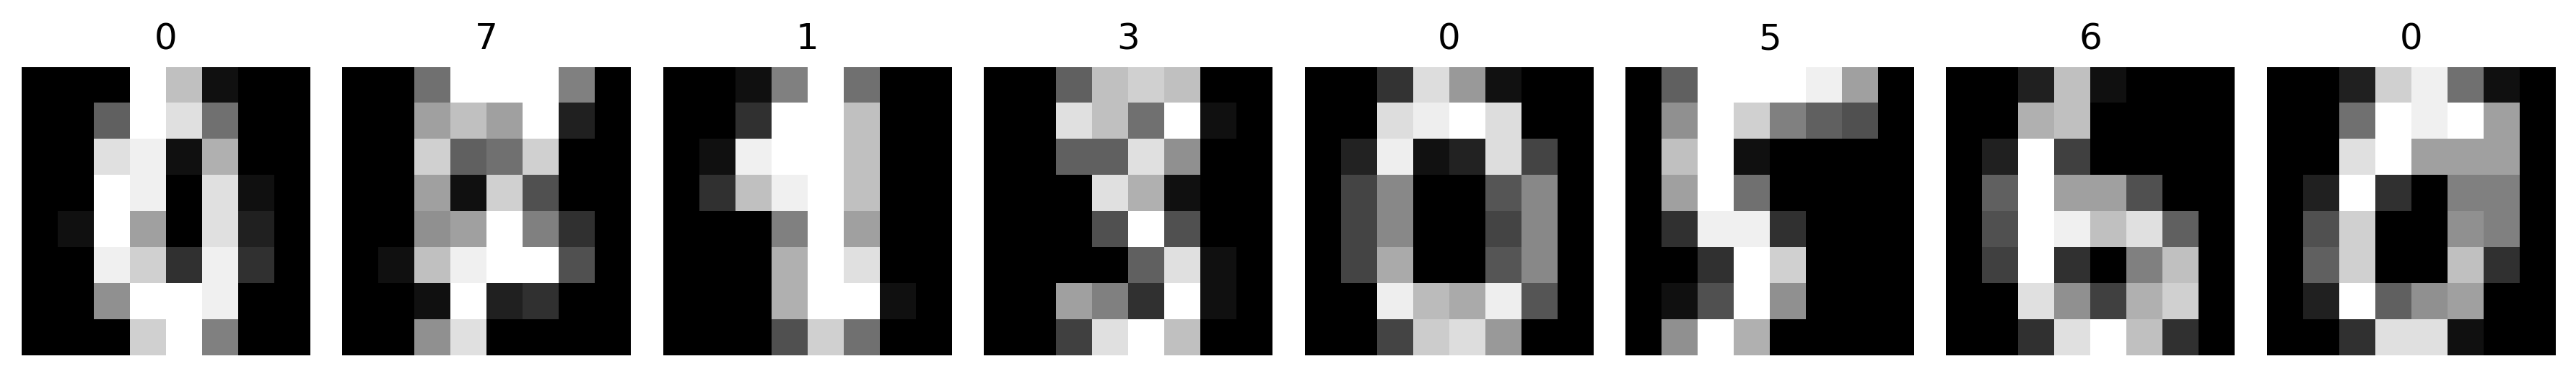

**Figure 9.13:** Digit samples from the training set after conversion to PyTorch *tensors* and normalization.


In [12]:
# 1. Data loading and preprocessing
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0  # Normalization to the range [0, 1]
y = digits.target

# Stratified split into training (70%) and test (30%) sets
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Adjusting to the dimension expected by PyTorch: (N_samples, Channels, Height, Width)
X_treino_t = torch.tensor(X_treino).unsqueeze(1)   # Dimension: (N, 1, 8, 8)
y_treino_t = torch.tensor(y_treino, dtype=torch.long)
X_teste_t = torch.tensor(X_teste).unsqueeze(1)
y_teste_t = torch.tensor(y_teste, dtype=torch.long)

# Display a sample
n_amostras = 8
imgs = [img.squeeze().numpy() for img in X_treino_t[:n_amostras]]
imgs_titles = [str(label.item()) for label in y_treino_t[:n_amostras]]
mm.show(imgs, titles=imgs_titles, cols=n_amostras, figsize=(12, 2.5))

##### Block 2: Definition of the Convolutional Architecture

Model construction in **PyTorch** is structured around the object-oriented paradigm, with a specific class created to represent the neural network (in this example, the `CNNDigitos` class), which inherits all the functionality of the base class `nn.Module`. The `__init__` constructor is responsible for instantiating the layers and declaring their trainable parameters, while the `forward` method establishes the numerical sequence of the forward pass.

[Figure 9.14](#fig-09-cnn-digitos-esquema) synthesizes the spatial transformations of the tensors and the data flow throughout the `CNNDigitos` class.

<figure id="fig-09-cnn-digitos-esquema" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-cnn-digitos-esquema.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figure 9.14:</strong> Representation of the flow of dimensional transformations of the tensors throughout the *CNNDigitos* architecture.</figcaption>
</figure>

1. **Constructor (`__init__`) and Component Instantiation:**
   * **Convolutional Layer 1 (`self.conv1`):** Applies $8$ filters of size $3 \times 3$ with `padding=1` to the grayscale input ($1$ channel), preserving the spatial resolution of $8 \times 8$ pixels.
   * **Convolutional Layer 2 (`self.conv2`):** Processes the $8$ feature maps received from the previous layer by applying $16$ filters of size $3 \times 3$ with `padding=1`.
   * **Subsampling (`self.pool`):** Instantiates the *Max-Pooling* operation with a $2 \times 2$ window and stride of $2$, reducing the spatial dimension (height and width) by half with each application.
   * **Fully Connected Layers (`self.fc1` and `self.fc2`):** The first dense projection receives the flattened tensor of dimension $16 \times 2 \times 2 = 64$ and produces $32$ intermediate features. The second projects these $32$ features onto the $10$ final output logits.

2. **Forward Propagation in the `forward` Method:**
   * **First Convolutional Block:** The input tensor of shape $(N, 1, 8, 8)$ passes through `conv1` + ReLU and is subsampled by `pool`, resulting in the shape $(N, 8, 4, 4)$.
   * **Second Convolutional Block:** The tensor $(N, 8, 4, 4)$ is processed by `conv2` + ReLU and reduced by `pool` to the shape $(N, 16, 2, 2)$.
   * **Flattening:** The method `x.view(x.size(0), -1)` reshapes the $3\text{D}$ structure into a $1\text{D}$ vector of $64$ elements per sample, preserving the batch dimension $N$.
   * **Classification:** The vector of $64$ elements feeds `fc1` with ReLU activation ($32$ neurons) and ends at `fc2`, producing the $10$ unnormalized logits for the computation of the loss function.

In [13]:
# 2. Definition of the Convolutional Architecture
class CNNDigitos(nn.Module):
    """
    Compact convolutional architecture:
    2 convolutional layers with ReLU and Max-Pooling + 2 dense layers.
    """
    def __init__(self, n_classes=10):
        super().__init__()
        
        # Conv1: 1 input channel, 8 3x3 filters with padding 1 (output: 8x8)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        # Conv2: 8 input channels, 16 3x3 filters with padding 1 (output: 4x4)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.relu = nn.ReLU()

        # 2x2 Max-Pooling with stride 2
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers (FC)
        self.fc1 = nn.Linear(16 * 2 * 2, 32)
        self.fc2 = nn.Linear(32, n_classes)

    def forward(self, x):
        # First block: Conv (8x8) -> ReLU -> Pool (4x4)
        x = self.pool(self.relu(self.conv1(x)))

        # Second block: Conv (4x4) -> ReLU -> Pool (2x2)
        x = self.pool(self.relu(self.conv2(x)))
        
        # Flatten: reshapes the 3D matrix (16, 2, 2) into a 1D vector (64)
        x = x.view(x.size(0), -1)

        # Intermediate dense layer with ReLU
        x = self.relu(self.fc1(x))

        # Final classification layer (logits)
        return self.fc2(x)

###### Analysis of Layers and Flow of the `CNNDigitos` Class

1. **Constructor (`__init__`) and Component Instantiation:**
   * **Convolutional Layer 1 (`self.conv1`):** Applies $8$ filters of size $3 \times 3$ with `padding=1` to the grayscale input ($1$ channel), preserving the resolution of $8 \times 8$ *pixels*.
   * **Convolutional Layer 2 (`self.conv2`):** Processes the $8$ received feature maps by applying $16$ filters of size $3 \times 3$ with `padding=1`.
   * **Subsampling (`self.pool`):** Instantiates the *Max-Pooling* operation with a $2 \times 2$ window and stride $2$, halving the spatial dimensions (height and width) at each application.
   * **Fully Connected Layers (`self.fc1` and `self.fc2`):** The first dense projection receives the flattened *tensor* of dimension $16 \times 2 \times 2 = 64$ and produces $32$ intermediate features. The second projects these $32$ features onto the $10$ output *logits*.

2. **Forward Propagation in the `forward` Method:**
   * **First Block:** The *tensor* $(N, 1, 8, 8)$ passes through `conv1` + ReLU and is reduced by `pool` to $(N, 8, 4, 4)$.
   * **Second Block:** The *tensor* $(N, 8, 4, 4)$ passes through `conv2` + ReLU and is reduced by `pool` to $(N, 16, 2, 2)$.
   * **Flattening:** The method `x.view(x.size(0), -1)` converts the $3\text{D}$ structure into a $1\text{D}$ vector of $64$ elements per sample.
   * **Classification:** The vector of $64$ elements feeds `fc1` with ReLU activation ($32$ neurons) and ends in `fc2`, which produces the $10$ final *logits* for the computation of the Cross-Entropy loss.

##### Block 3: Instantiation and Optimization Parameters

The learning configuration stage requires instantiating the defined architecture and selecting two core components: the **loss function**, which quantifies the model's error, and the **optimization algorithm**, responsible for adjusting the parameters toward the minimum of that function.

1. **Instantiation and Parameter Counting:**
   The model is created by instantiating the `modelo_cnn` object from the `CNNDigitos` class. The expression `sum(p.numel() for p in modelo_cnn.parameters())` iterates over all trainable parameter *tensors* of the network (weights and biases of each layer) and calculates the total cardinality of the model, quantifying its representational capacity.

2. **Loss Function (`nn.CrossEntropyLoss`):**
   Cross-Entropy Loss is the standard choice for multiclass classification problems. In PyTorch, this implementation internally combines the application of the *LogSoftmax* function with Negative Log-Likelihood Loss (*NLLLoss*). For this reason, the network's output layer produces raw logits, eliminating the need for an explicit *Softmax* function at the end of the `forward` method.

3. **Adaptive Optimizer (`optim.Adam`):**
   Parameter updates use the *Adam* algorithm (*Adaptive Moment Estimation*), with an initial learning rate of $\eta = 0.01$ (`lr=1e-2`). *Adam* combines the principles of momentum with step-size adaptation based on moving averages of first- and second-order derivatives, individually adjusting the learning rate for each network parameter.

In [14]:
# 3. Model Initialization and Optimization Parameters
modelo_cnn = CNNDigitos()
num_params = sum(p.numel() for p in modelo_cnn.parameters())
print(f"Trainable model parameters: {num_params}")

criterio = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo_cnn.parameters(), lr=1e-2)

Trainable model parameters: 3658


##### Block 4: Training Loop and Evaluation

CNN training occurs iteratively through the Stochastic Gradient Descent algorithm by *mini-batches* (*Mini-batch SGD*).

The learning curves resulting from this process are shown in [Figure 9.15](#fig-09-cnn-treinamento), generated at the end of execution.

1. **Training Phase (`modelo_cnn.train()`):**
   The main loop executes training over $50$ epochs. In each epoch, the following steps occur:
   * **Stochastic Shuffling:** The function `torch.randperm(n)` generates a random permutation of the sample indices, ensuring that the ordering of *mini-batches* varies each epoch to avoid sampling biases.
   * **Division into *Mini-batches*:** The training set is sliced into batches of $32$ samples (`tam_lote = 32`).
   * **Zeroing Gradients (`otimizador.zero_grad()`):** Clears the gradients accumulated in the *tensor* from the previous iteration, preventing the unwanted summation of derivatives across distinct batches.
   * **Forward Pass and Loss:** The *forward pass* computes the predictions `saida`, and the call `criterio(saida, y_treino_t[idx])` quantifies the batch error.
   * **Backpropagation (`perda.backward()`):** Applies the chain rule to compute the partial derivatives of the loss with respect to each parameter ($\frac{\partial L}{\partial w}$).
   * **Weight Update (`otimizador.step()`):** Updates the model parameters according to the *Adam* optimizer equations.

2. **Evaluation Phase (`modelo_cnn.eval()`):**
   At the end of each epoch, the model is switched to evaluation mode. The context `with torch.no_grad()` temporarily disables the automatic derivative computation engine (*autograd*), reducing memory consumption and accelerating inference on the test set (`X_teste_t`). The operation `.argmax(dim=1)` extracts the class with the highest probability for each sample, allowing the test accuracy to be calculated.

3. **Visualization with the `morph` Library:**
   The function `mm.showTrainCurves` from the didactic library `morph` consolidates the training loss history and test accuracy into a single graphical panel, allowing the model convergence to be diagnosed and the stability of learning to be monitored across epochs.

Final accuracy of the CNN on the test set: 0.9759


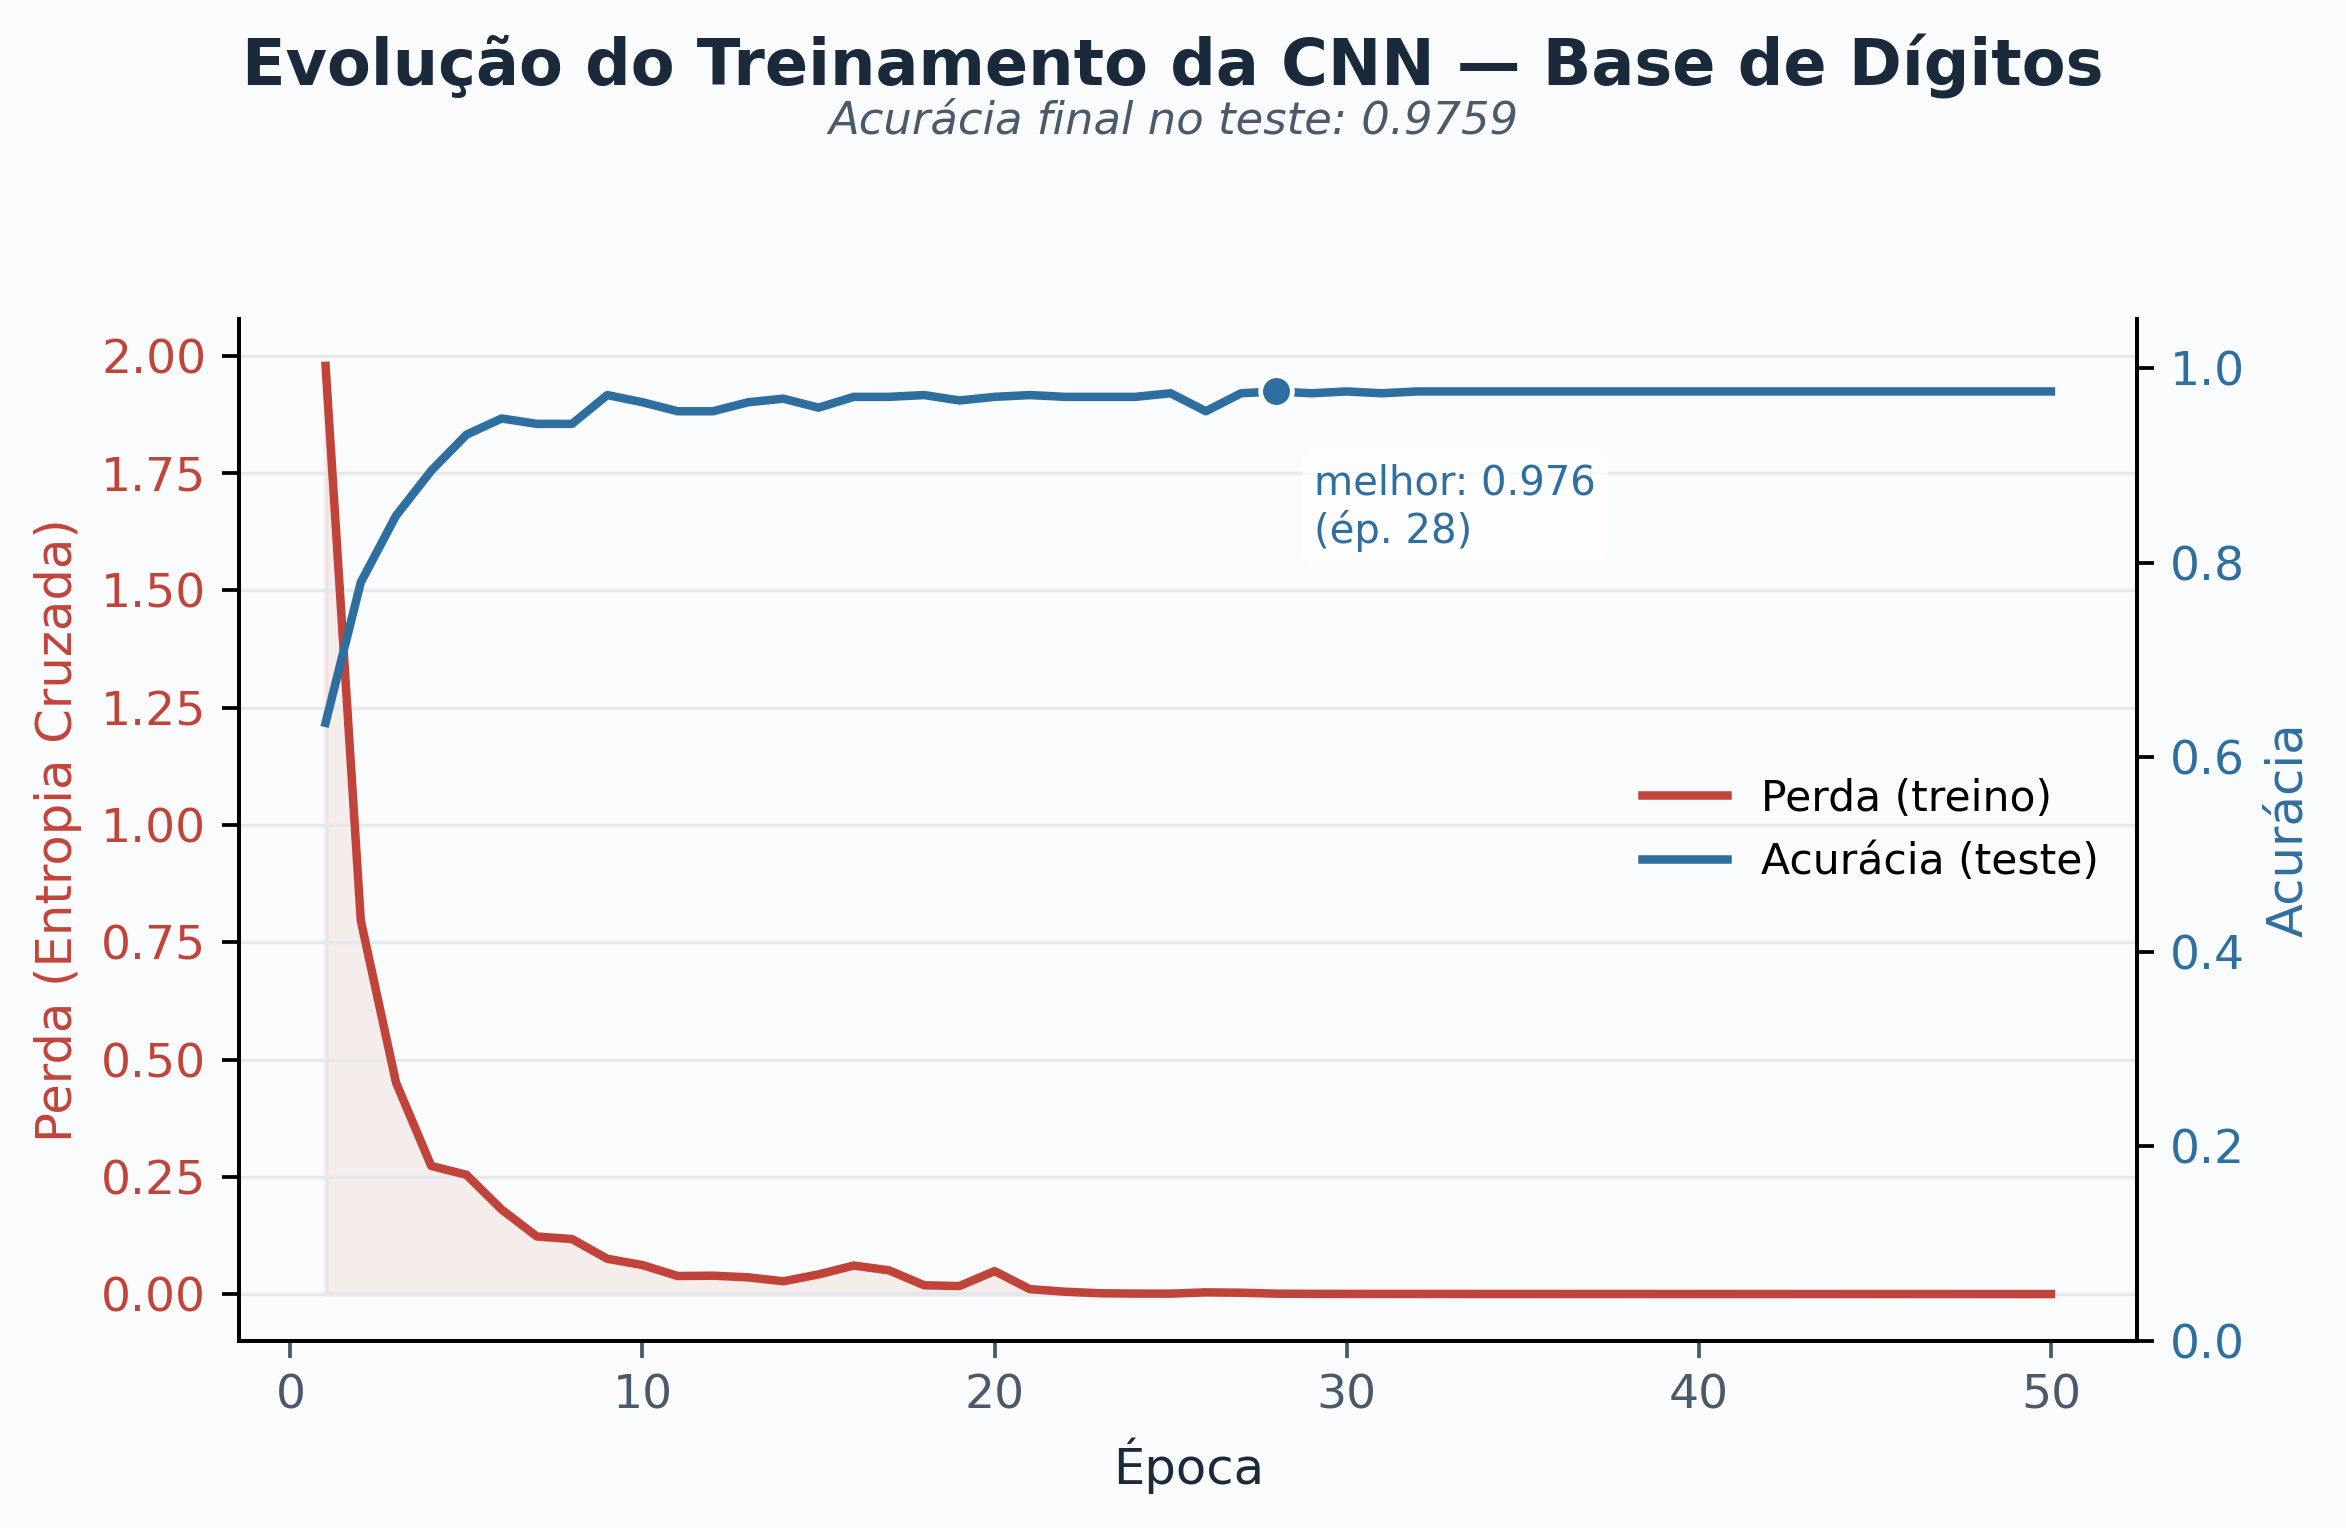

**Figure 9.15**


In [15]:
# | fig-cap: "Training and evaluation curves of the CNN on the digits dataset: evolution of cross-entropy loss on the training set and accuracy on the test set over 50 epochs."
# | echo: true
# | output: true

# 4. Training Loop (Mini-batch SGD)
n = X_treino_t.size(0)                    # Number of samples
tam_lote = 32                             # Mini-batch size
epocas = 50                               # Total epochs
historico_perda, historico_acc = [], []   # Metrics history

for epoca in range(epocas):                  # Repeat for each epoch
    modelo_cnn.train()                       # Training mode
    perm = torch.randperm(n)                 # Shuffle samples
    perda_epoca = 0.0                        # Accumulate losses
    for i in range(0, n, tam_lote):          # Iterate over mini-batches
        idx = perm[i:i + tam_lote]           # Batch indices
        otimizador.zero_grad()               # Zero gradients
        saida = modelo_cnn(X_treino_t[idx])  # Forward pass
        perda = criterio(saida, y_treino_t[idx]) # Compute loss
        perda.backward()                         # Backpropagation
        otimizador.step()                        # Update weights
        perda_epoca += perda.item() * len(idx)   # Sum loss

    # Model evaluation on the test set at the end of each epoch
    modelo_cnn.eval()                            # Evaluation mode
    with torch.no_grad():                        # No gradients
        pred_teste = modelo_cnn(X_teste_t).argmax(dim=1)  # Predictions
        acc_teste = (pred_teste == y_teste_t).float().mean().item()  # Accuracy
    historico_perda.append(perda_epoca / n)      # Record loss
    historico_acc.append(acc_teste)              # Record accuracy

acc_final_cnn = historico_acc[-1]                # Final accuracy
print(f"Final accuracy of the CNN on the test set: {acc_final_cnn:.4f}")  # Display result

final = mm.showTrainCurves(                      # Plot curves
    historico_perda, historico_acc,
    titulo="Evolução do Treinamento da CNN — Base de Dígitos",
    subtitulo=f"Acurácia final no teste: {acc_final_cnn:.4f}",
)

##### Block 5: Visualization of the Activation Flow

Inspecting the trained network allows observing the progressive transformation of the input *tensor* across the layers of the `CNNDigitos` architecture. [Figure 9.16](#fig-09-cnn-ativacoes) illustrates the dimensions and intermediate activations obtained when processing a real example of the digit $3$.

1. **Sample Selection and Preparation:**
   The stochastic seed is fixed with `torch.manual_seed(7)` to ensure reproducibility of the results. The first occurrence of the digit $3$ in the `load_digits` dataset is isolated, normalized to the interval $[0.0, 1.0]$, and reshaped as a *tensor* `x` of dimension $(1, 1, 8, 8)$.

2. **Intermediate Inspection with `mm.showNet`:**
   The `mm.showNet` function from the `morph` library performs the *forward pass* of the *tensor* `x` through the previously trained `modelo_cnn` instance. Using *forward hooks*, the function intercepts the numerical state of activations in the convolutional (`nn.Conv2d`), pooling (`nn.MaxPool2d`), and fully connected (`nn.Linear`) layers, returning them in the `acts` dictionary. The nonlinear activation functions (`nn.ReLU`) are not registered as independent stages, since their application occurs directly on the output *tensor* of the corresponding layer.

3. **Result Verification:**
   The command `list(acts.keys())` displays the sequence of identifiers for the monitored layers, allowing confirmation of the progressive dimensional reduction and the generation of the *logit* with maximum value at the index corresponding to class $3$, as demonstrated in [Figure 9.16](#fig-09-cnn-ativacoes).

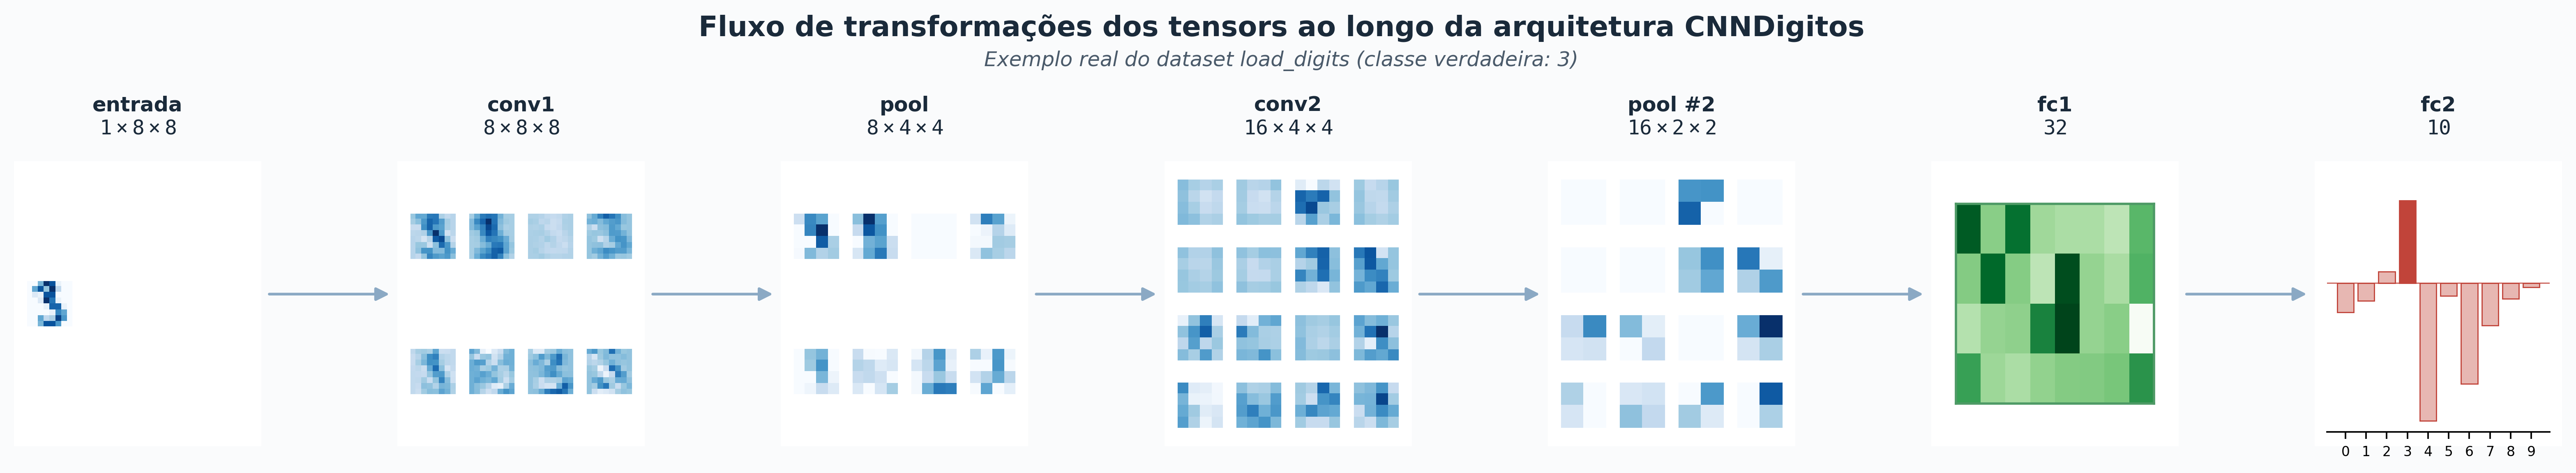

**Figure 9.16:** Flow of activations of the trained CNN when processing a real example of the digit 3, from the *load_digits* dataset: tensor dimensions layer by layer, from input to output *logit*.


Captured layers: ['conv1', 'pool', 'conv2', 'pool #2', 'fc1', 'fc2']


In [16]:
torch.manual_seed(7)
digits = load_digits()
idx = np.where(digits.target == 3)[0][0]
img = digits.images[idx] / 16.0
x = torch.tensor(img, dtype=torch.float32).view(1, 1, 8, 8)

# Reuse of the previously trained model instance
acts = mm.showNet(
    modelo_cnn,
    x,
    titulo="Fluxo de transformações dos tensors ao longo da arquitetura CNNDigitos",
    subtitulo=f"Exemplo real do dataset load_digits (classe verdadeira: {digits.target[idx]})",
)
print("Captured layers:", list(acts.keys()))

##### Inspecting the Computational Graph with `torchviz`

While `mm.showNet` prioritizes didactic clarity—displaying one column per layer with trainable parameters—the `torchviz` library projects the **autograd graph** exactly as PyTorch builds it internally for gradient computation. [Figure 9.17](#fig-09-torchviz-grafo) illustrates this perspective by representing the `CNNDigitos` architecture.

1. **Tracked Forward Propagation:** With the trained model in `eval()` mode, the *forward pass* over the `x` tensor of digit $3$ is sufficient for the *autograd* engine to record all executed operations, including those without trainable parameters, such as the `ReLU` activation function and the `view` dimensional reshaping.

2. **Graph Generation (`make_dot`):** The `make_dot(saida, params=...)` function builds the graph from the output tensor by traversing backward through the operation history to the leaf nodes (the model's trainable parameters). Each node in the diagram represents an operation of the *backward pass* (such as `ReluBackward` or `AddmmBackward`), not merely a conceptual block of the `nn.Module`.

3. **Export and Rendering (`.render`):** The `.render(..., format="png", cleanup=True)` method invokes the `dot` executable from **Graphviz** to compile the image in PNG format, automatically removing intermediate source-code files.

[Figure 9.17](#fig-09-torchviz-grafo) highlights how this computational graph, even for a compact architecture, exhibits greater density than the `mm.showNet` panel, as it details each atomic operation responsible for the gradient flow.

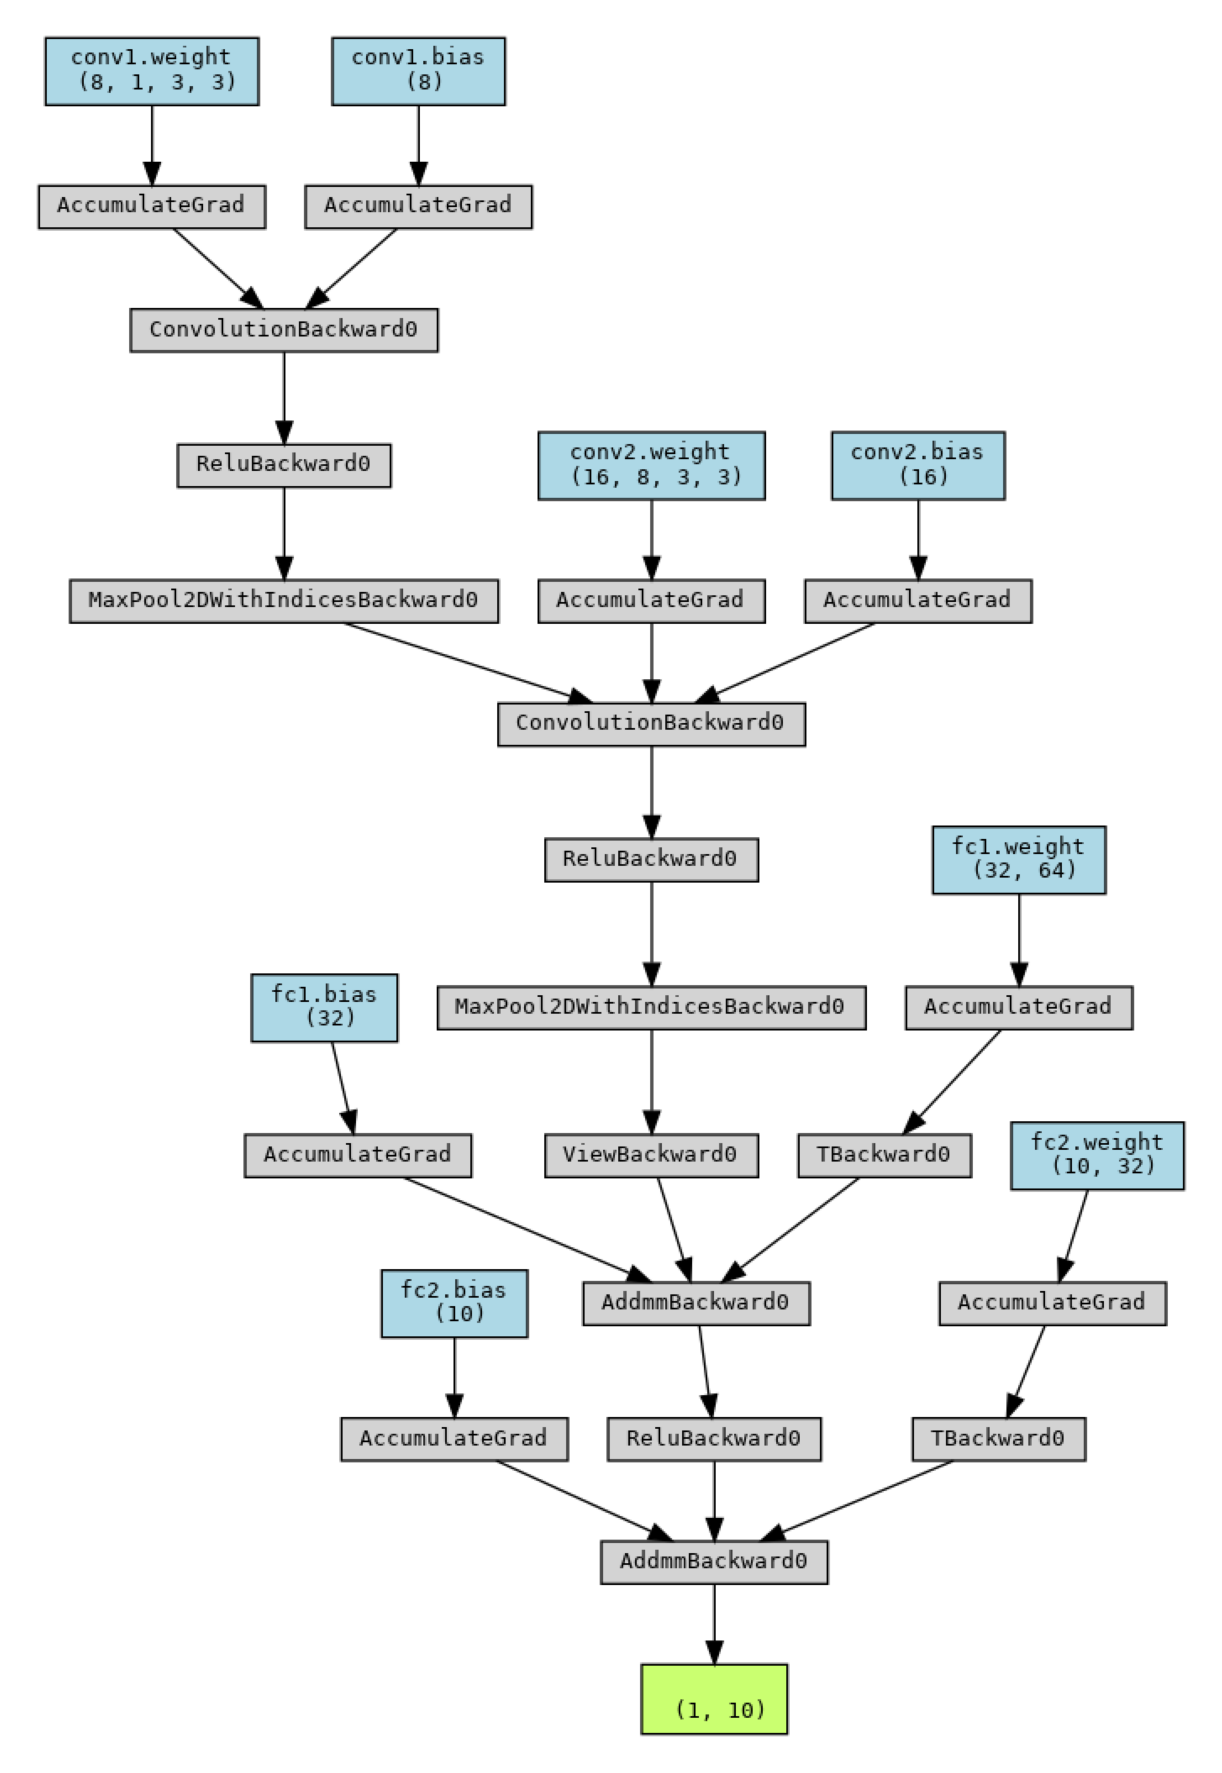

**Figure 9.17:** Computational graph of *CNNDigitos* generated via *torchviz*, showing the *forward* operations and the gradient nodes (*backward*) associated with each trainable parameter.


In [17]:
# 1. Forward pass with gradient tracking enabled
modelo_cnn.eval()
saida = modelo_cnn(x)  # Reuse of tensor x (digit 3)

# 2. Basic graph: flow of operations up to the output
grafo_simples = make_dot(saida, params=dict(modelo_cnn.named_parameters()))
caminho_simples = grafo_simples.render("cnn_digitos_grafo_simples", format="png", cleanup=True)

# 3. Direct display in the Quarto/Jupyter environment
# The .render() returns the path of the generated PNG file; we need to open it as an image
imagem_simples = np.array(Image.open(caminho_simples).convert("RGB"))
mm.show(imagem_simples, figsize=(5,10))

##### Detailed View of the Computational Graph with `torchviz`

In addition to the simplified representation, the `torchviz` library allows expanding the *autograd* graph to inspect the internal execution details of the `CNNDigitos` network. [Figure 9.18](#fig-09-torchviz-grafo-detalhado) presents this expanded structure for the same input *tensor* `x`.

1. **Tracing with Operation Attributes (`show_attrs=True`):** 
   The inclusion of attributes displays the hyperparameter configurations associated with each computational node during the forward pass, such as kernel dimensions (`kernel_size`), strides, and paddings in convolutions and subsamplings.

2. **Detection of Saved Tensors in Memory (`show_saved=True`):**
   This parameter forces the explicit display of the intermediate tensors that PyTorch retains in memory during the forward pass. These data are preserved because they will be strictly necessary for calculating the partial derivatives during the backward pass.

3. **Generation and Compilation of Graphs:**
   While `grafo_simples` generates a direct view of the gradient flow, `grafo_detalhado` compiles the expanded graph into the file `cnn_digitos_grafo_detalhado.png` via the `dot` executable from **Graphviz**.

As observed in [Figure 9.18](#fig-09-torchviz-grafo-detalhado), this detailed visualization is useful for debugging video memory (VRAM) consumption and verifying how the PyTorch engine internally allocates each node of the chain rule.

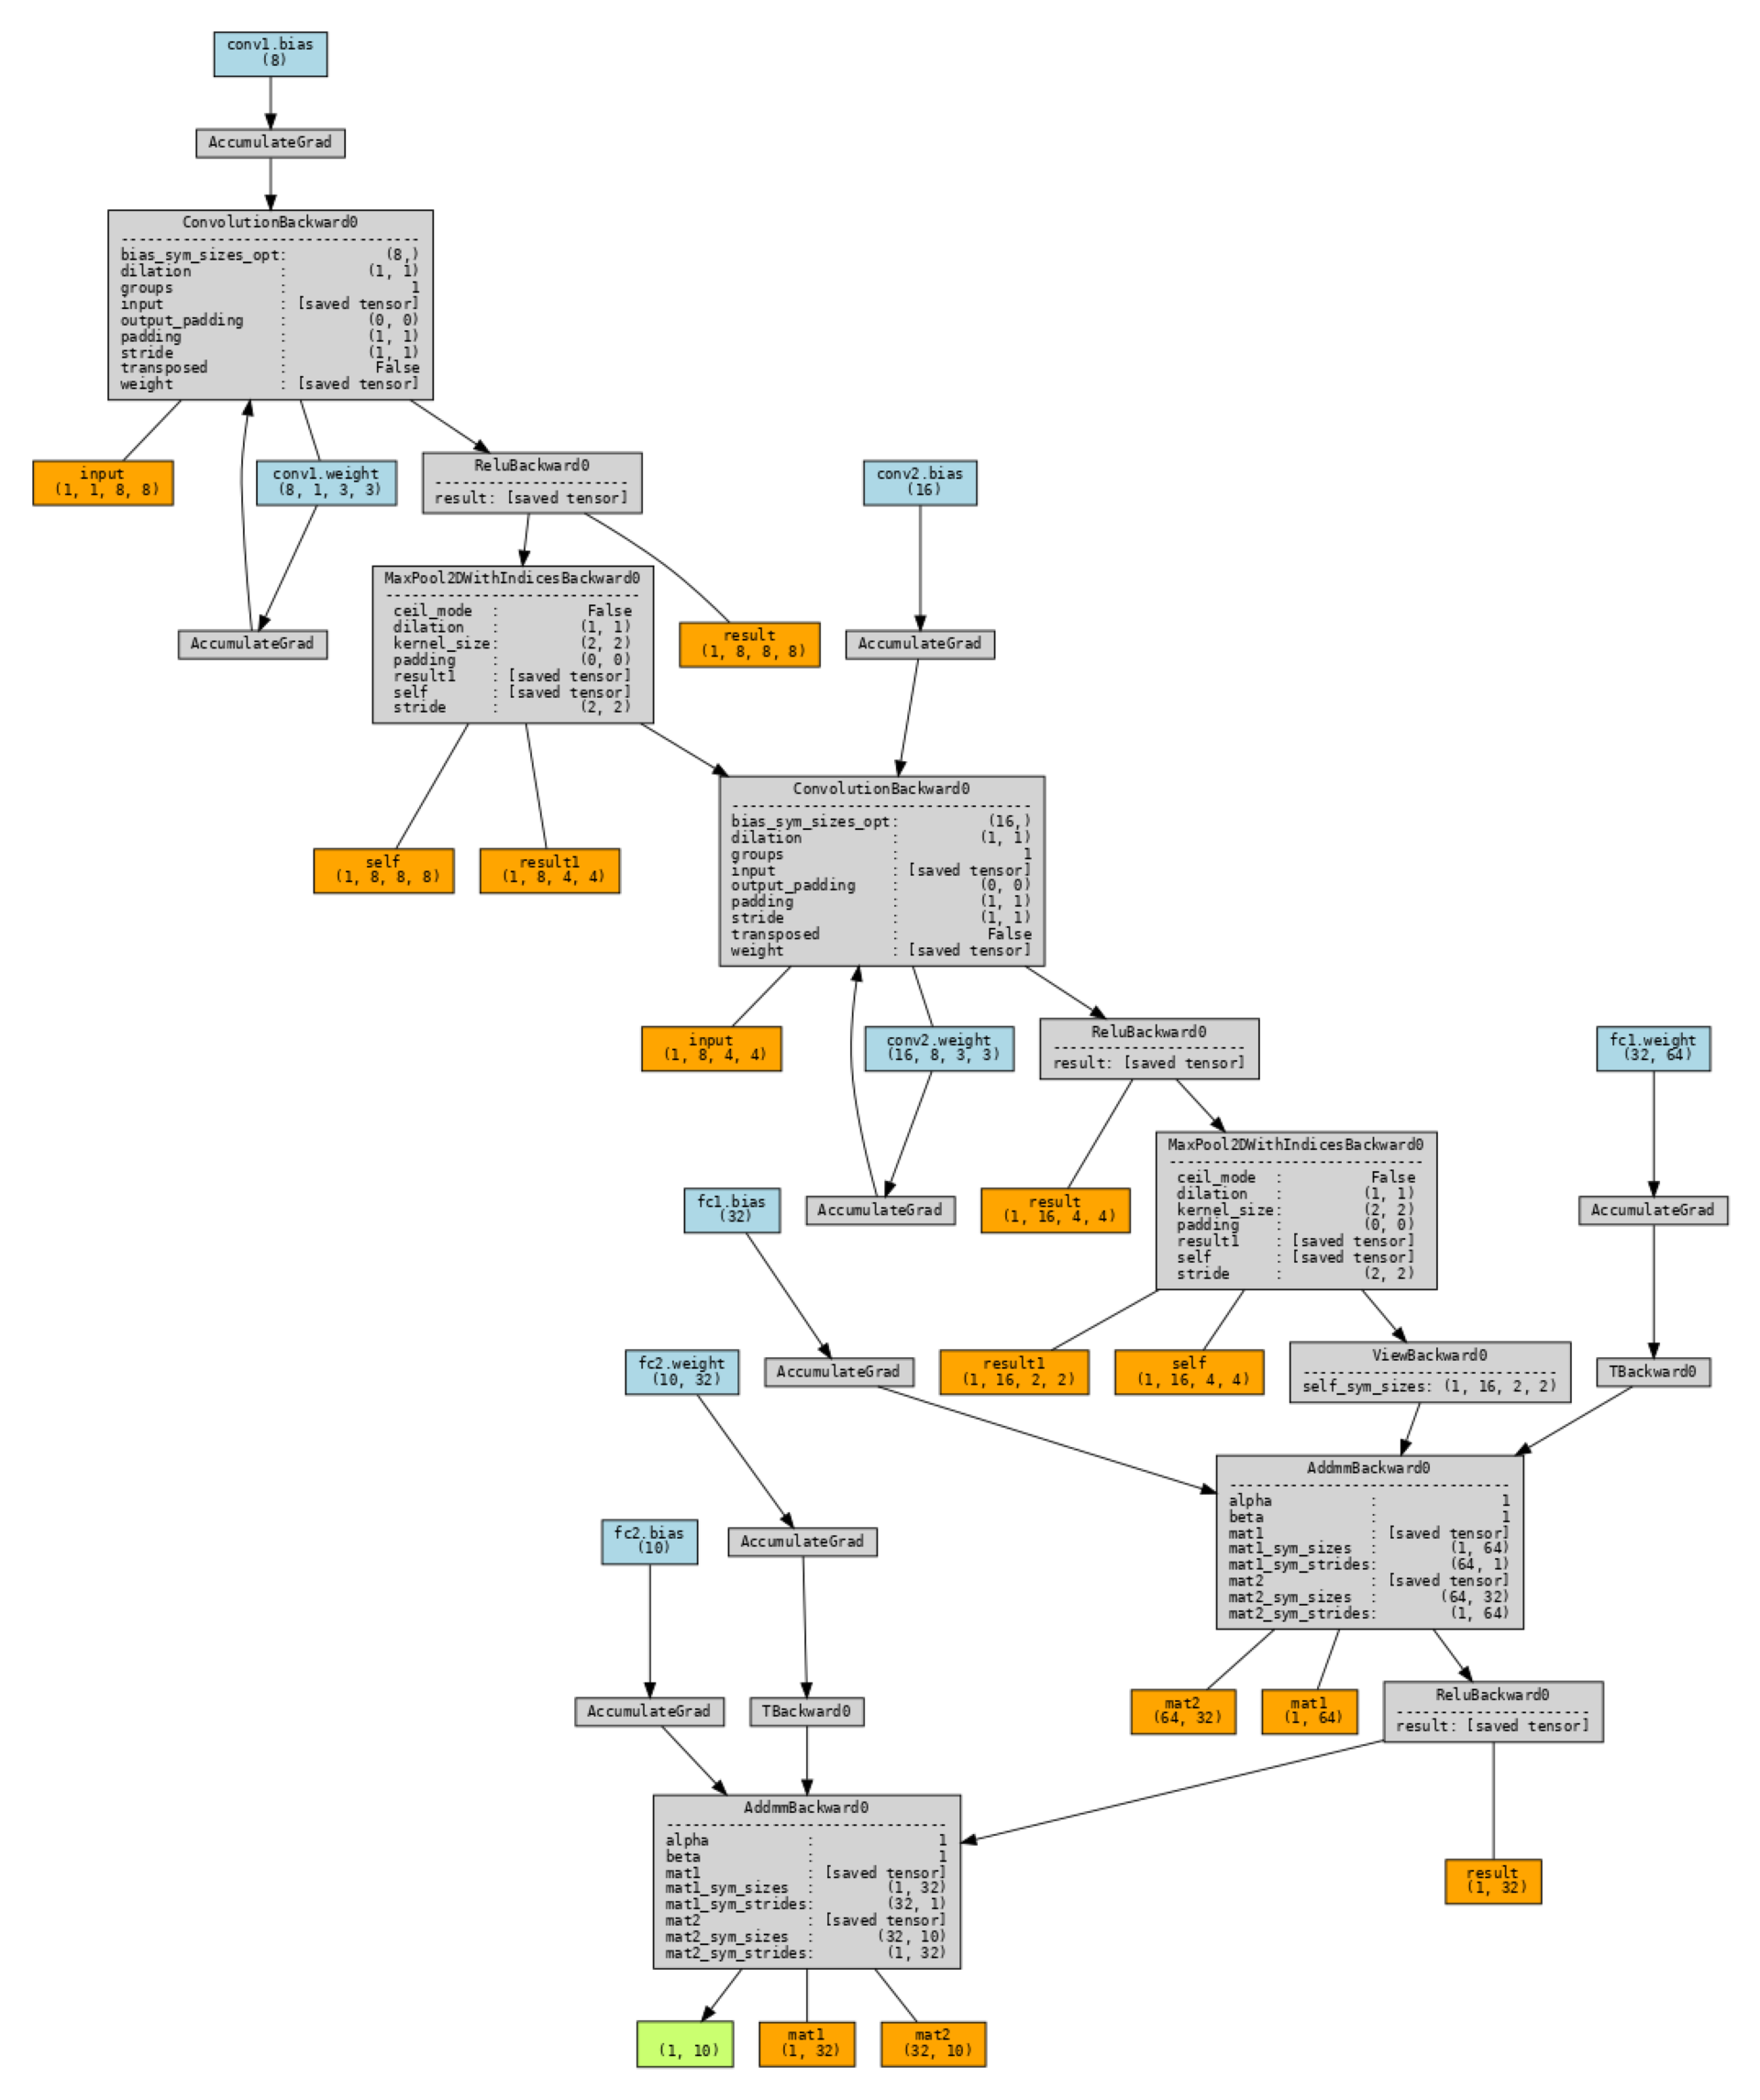

**Figure 9.18:** Detailed graph of the CNNDigitos class generated via *torchviz*.


In [18]:
# same code as before (make_dot + render)...

# 2. Detailed graph: display of dimensions and tensors saved for backward
grafo_detalhado = make_dot(
    saida,
    params=dict(modelo_cnn.named_parameters()),
    show_attrs=True,   # Displays operation attributes (e.g., kernel_size, stride)
    show_saved=True,   # Displays tensors saved in memory for backpropagation
)

caminho_detalhado = grafo_detalhado.render("cnn_digitos_grafo_detalhado", 
                                           format="png", cleanup=True)

# 3. Direct display in the Quarto/Jupyter environment
imagem_detalhado = np.array(Image.open(caminho_detalhado).convert("RGB"))
mm.show(imagem_detalhado, figsize=(8, 16))

##### Comparison with Chapter 7

[Figure 9.19](#fig-09-comparativo-cap7) brings together the results obtained on the same dataset (`load_digits`), establishing a direct parallel between the classical approaches explored previously and the CNN developed in this chapter.

1. **Performance of Raw Pixels vs. Manual Descriptors:** In the experiments from Chapter 7, the $k\text{-NN}$ classifier ($k=3$) achieved an accuracy of $98.4\%$ when fed directly with the raw pixels of the images. In contrast, prior feature extraction via the Histogram of Oriented Gradients (HOG) resulted in significantly lower performance ($75.8\%$). This decline occurs because HOG was designed to capture edge gradients in higher-resolution images; in matrices of only $8 \times 8$ pixels, the spatial resolution is insufficient to form informative orientation histograms.

2. **Equivalence of CNN and End-to-End Learning:** The convolutional network `CNNDigitos` achieves competitive performance of $97.6\%$, approaching the accuracy of $k\text{-NN}$ with raw pixels on a small and pre-aligned dataset. The major conceptual advantage lies in representation learning: instead of relying on manually designed descriptors (handcrafted features) or keeping the entire dataset in memory for neighbor searching at inference time, the CNN automatically optimizes its own convolutional filters during training, yielding a compact model capable of performing feature extraction and classification in an integrated (end-to-end) manner.

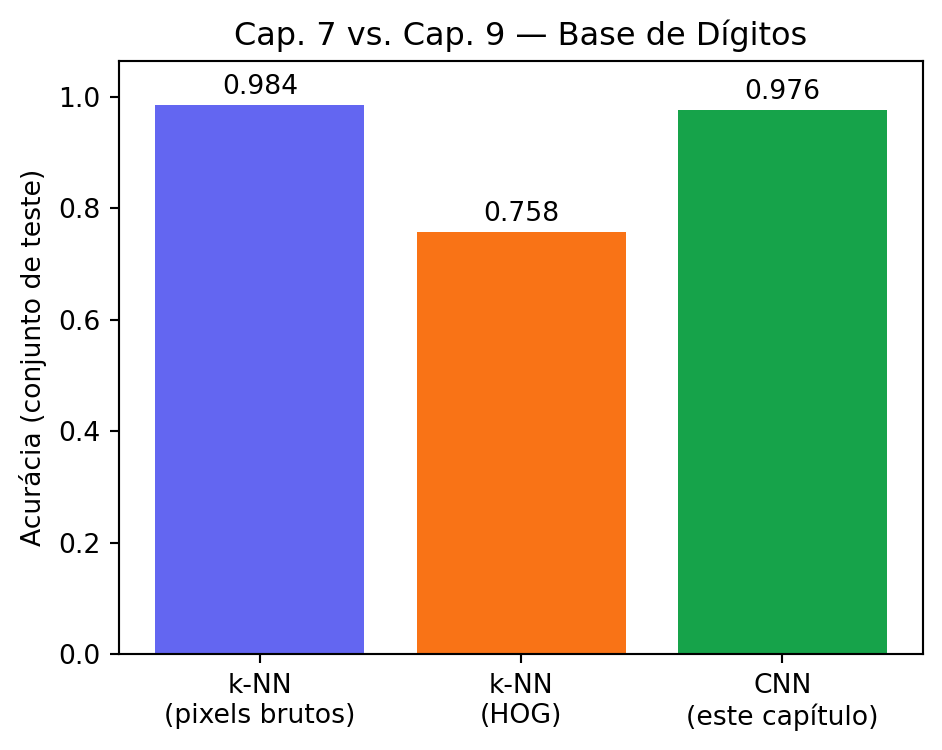

**Figure 9.19:** Comparison of accuracy between the classic classifiers from Chapter 7 (raw pixels and HOG with k-NN) and the CNN trained in this chapter, on the same digit dataset.


In [19]:
import matplotlib.pyplot as plt

# Values obtained in Chapter 7 (k-NN, k=3), reproduced for direct comparison
ACC_KNN_PIXELS_CAP7 = 0.9844
ACC_KNN_HOG_CAP7 = 0.7578

metodos = ["k-NN\n(pixels brutos)", "k-NN\n(HOG)", "CNN\n(este capítulo)"]
acuracias = [ACC_KNN_PIXELS_CAP7, ACC_KNN_HOG_CAP7, acc_final_cnn]

plt.figure(figsize=(5, 4))
cores = ["#6366f1", "#f97316", "#16a34a"]
plt.bar(metodos, acuracias, color=cores)
plt.ylim(0, max(acuracias) + 0.08)
plt.ylabel("Acurácia (conjunto de teste)")
plt.title("Cap. 7 vs. Cap. 9 — Base de Dígitos")

for i, v in enumerate(acuracias):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

> ### 📝 Nota
>
> ###### 🧠 Why It Works — And Why the CNN Does Not Always "Win"
>
> The observed result here **repeats the pattern already seen in Chapter 7**: the CNN, despite automatically learning its features, does not necessarily outperform the $k\text{-NN}$ with raw *pixels* on this specific dataset. The explanation is the same: `load_digits` is a small dataset (fewer than $1,800$ examples), with images that are already centered, normalized, and of very low resolution ($8 \times 8$) — conditions under which direct comparison of intensities is already highly informative, and there is little data for the network to learn filters that are truly superior to simple descriptors.
>
> The real differentiator of CNNs appears in scenarios that handcrafted descriptors and simple classifiers cannot address: larger and more realistic images, with thousands of categories, substantial variation in pose, lighting, and background, and massive training sets — exactly the regime in which the models presented in the section *"Large-Scale Applications"*, later on, were trained. The pedagogical lesson that runs through Chapters 7, 8, and 9 of this book is consistent: **the sophistication of a method should be proportional to the complexity of the problem** — using a CNN for a problem that a $k\text{-NN}$ solves equally well is a waste of computational resources, not a virtue.
>
> This same proportionality applies to the inspection tools used throughout the chapter. The `mm.showNet` was built for **didactic** purposes and works well on shallow networks such as `CNNDigitos`, but it does not scale to deep architectures: each traced layer becomes a column in the figure, and convolutional layers with hundreds of channels generate mosaics too large for visual interpretation; furthermore, the *hooks* store all activations in memory, and the *layout* assumes a sequential flow, not faithfully representing residual connections or branches (as in *ResNets* or *Inception* modules). Thus, `showNet` should be understood as a pedagogical lens for small networks — analogous to the role of `mm.showBoundBox` in the visual debugging of detections — and not as a substitute for production-oriented tools such as *TensorBoard* or *torchviz*.

#### 9.5.1.2 Transfer Learning

Training a CNN from scratch generally requires a large amount of labeled data and significant computational resources, as the training process must adjust all network parameters. In many applications, however, only a reduced set of data is available for the task of interest. In this situation, **transfer learning** reuses the representations learned by a model previously trained on a source task with a large volume of data, reducing training costs and the need for new samples.

In CV, this strategy explores the hierarchical organization of CNNs. The initial layers learn low-level visual features, such as edges, textures, intensity gradients, and color patterns, which remain useful across different domains. The deeper layers combine this information to form progressively more abstract and specialized representations, related to the classes present in the training base.

This section investigates under what conditions transfer learning yields good results. The first experiment shows that a small extractor trained on a restricted domain can lead to **negative transfer**. The second demonstrates why deep models pre-trained on large image datasets achieve high performance on new tasks. Finally, the third applies this strategy to a plant health diagnosis problem, illustrating a scenario close to real-world applications.

##### Experiment 1 — Limitations of a Small and Specialized Extractor

The first experiment shows that transfer learning does not always improve a model's performance. To this end, the handwritten digits dataset (`load_digits`) is divided into two disjoint domains:

- **Domain A (source):** digits $0$ to $4$, used to train a small CNN;
- **Domain B (target):** digits $5$ to $9$, reindexed to $0$ to $4$, forming a new task with only $20$ training samples.

The objective is to evaluate the effect of reusing the feature extractor learned in Domain A without allowing its adaptation to Domain B.

###### Block 1: Division of Domains, Scarcity, and Display of Samples

This block prepares the dataset for the experiment. Unlike the previous project, which used all digits in a single classification problem, the dataset is divided into two independent tasks: a source task (Domain A) and a target task (Domain B).

[Figure 9.20](#fig-09-transfer-amostras) presents examples from both domains after class separation, conversion to **PyTorch** *tensors*, and preprocessing.

1. **Class separation:** The boolean masks `mask_A` and `mask_B` separate the examples from each domain. Next, the code reindexes the labels of Domain B (`y[mask_B] - 5`) to the range $[0,4]$, allowing both models to use five output classes.

2. **Data scarcity:** The generator `np.random.default_rng(0)` selects only $20$ samples for training Domain B, approximately four per class, simulating a scenario where training from scratch tends to suffer from *overfitting*.

3. **Conversion to tensors:** The `para_tensor` function converts the images to the format $(N,1,8,8)$ and the labels to `torch.long`, compatible with the `nn.Conv2d` layers and the loss function.

4. **Sample visualization:** The code uses `.squeeze().numpy()` to convert the tensors into **NumPy** arrays. [Figure 9.20](#fig-09-transfer-amostras) presents examples from both domains and highlights the reindexing applied to the labels of Domain B.

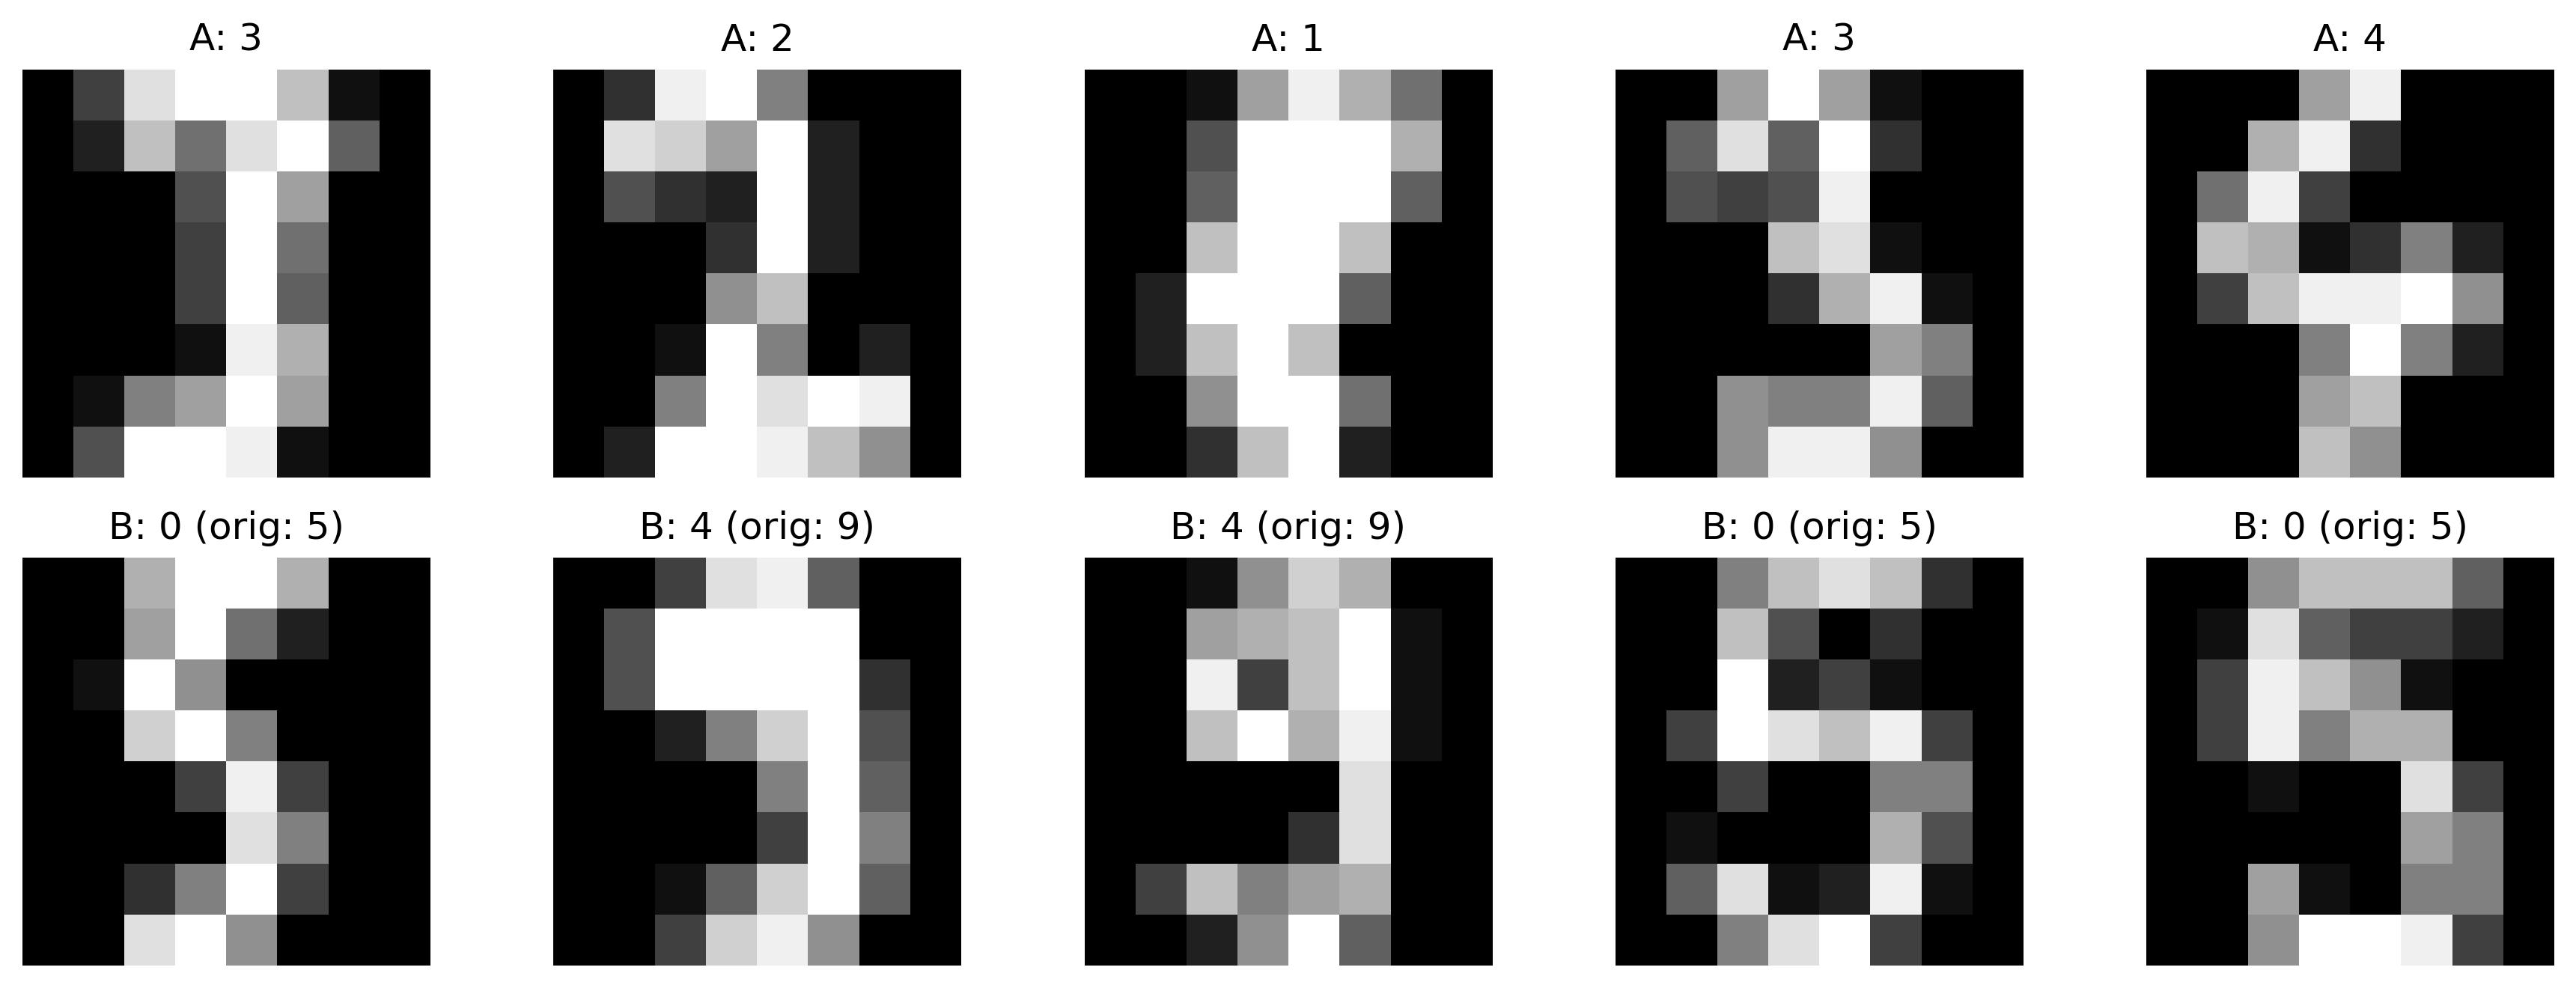

**Figure 9.20:** Samples from the training sets after preprocessing and dimensionality adjustment to PyTorch tensors: Domain A (digits 0 to 4, source task) and Domain B (digits 5 to 9 reindexed to 0 to 4, target task).


In [20]:
# 1. Splitting the dataset into two disjoint domains
classes_A, classes_B = [0, 1, 2, 3, 4], [5, 6, 7, 8, 9]
mask_A, mask_B = np.isin(y, classes_A), np.isin(y, classes_B)

XA, yA = X[mask_A], y[mask_A]
XB, yB = X[mask_B], y[mask_B] - 5  # Reindexing the labels to the range [0, 4]

# Splitting into training and test sets for both domains
XA_tr, XA_te, yA_tr, yA_te = train_test_split(
    XA, yA, test_size=0.25, random_state=42, stratify=yA
)
XB_tr, XB_te, yB_tr, yB_te = train_test_split(
    XB, yB, test_size=0.25, random_state=42, stratify=yB
)

# Simulation of extreme scarcity in the target domain: only 20 training samples
rng = np.random.default_rng(0)
idx_poucos = rng.choice(len(XB_tr), size=20, replace=False)
XB_tr_poucos, yB_tr_poucos = XB_tr[idx_poucos], yB_tr[idx_poucos]

# Helper function for conversion into PyTorch tensors
def para_tensor(Ximg, yarr):
    return torch.tensor(Ximg).unsqueeze(1), torch.tensor(yarr, dtype=torch.long)

XA_tr_t, yA_tr_t = para_tensor(XA_tr, yA_tr)
XA_te_t, yA_te_t = para_tensor(XA_te, yA_te)
XB_tr_t, yB_tr_t = para_tensor(XB_tr_poucos, yB_tr_poucos)
XB_te_t, yB_te_t = para_tensor(XB_te, yB_te)

# Display of samples from both domains
n_amostras = 5
imgs_A = [img.squeeze().numpy() for img in XA_tr_t[:n_amostras]]
titles_A = [f"A: {label.item()}" for label in yA_tr_t[:n_amostras]]

imgs_B = [img.squeeze().numpy() for img in XB_tr_t[:n_amostras]]
titles_B = [f"B: {label.item()} (orig: {label.item()+5})" for label in yB_tr_t[:n_amostras]]

mm.show(
    imgs_A + imgs_B,
    titles=titles_A + titles_B,
    cols=n_amostras,
    figsize=(12, 4.5)
)

###### Block 2: Modular Architecture and Generic Routines

To enable learning transfer, the convolutional architecture and training loop were refactored relative to the `CNNDigitos` class from the previous project.

1. **Architecture Modularization (Difference from `CNNDigitos`):**
   * In the previous project, the `CNNDigitos` class declared all layers (`conv1`, `conv2`, `pool`, `fc1`, `fc2`) as direct members of a single monolithic class.
   * Here, the architecture is separated into two components: the `ExtratorConv` class encapsulates the convolutional spatial block ($2$ $3 \times 3$ convolutions, $2$ $2 \times 2$ Max-Poolings, and flattening to $64$ elements), while the `CNNCompleta` class instantiates this extractor in `self.extrator` and attaches the classifier "head" (`fc1` and `fc2`).
   * This separation is what allows the internal state of the extractor (`state_dict()`) to be copied from one model to another in an isolated manner.

2. **Adjustment in the Number of Output Classes:**
   While `CNNDigitos` in the previous project had $10$ logits in the output layer (`self.fc2 = nn.Linear(32, 10)`), the `CNNCompleta` class receives `n_classes=5` in the constructor to suit the division of domains $A$ and $B$.

3. **Flexibilization of the Training Loop (`treinar`):**
   * In the previous project, the training loop iterated directly over the model's global attributes (`modelo_cnn.parameters()`) and computed specific metrics inline.
   * The `treinar` function abstracts this process and introduces the optional parameter `parametros`. If provided, the *Adam* optimizer updates **only** the parameters in that list, ignoring layers whose gradients have been deactivated. This flexibility is crucial for performing training with partial freezing of the network.

4. **Isolation of Evaluation (`calcular_acuracia`):**
   As done in the testing phase of the previous project, the function sets the model to `eval()` and uses the `torch.no_grad()` context to deactivate autograd, computing accuracy via `.argmax(dim=1)`.

In [21]:
# Definition of the reusable convolutional block (same extraction as the previous project)
class ExtratorConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        return x.view(x.size(0), -1)

# Modular architecture combining the extractor and the classification head
class CNNCompleta(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.extrator = ExtratorConv()
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.extrator(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# Generic training routine with selective parameter optimization
def treinar(modelo, X_t, y_t, epocas, lr, tam_lote=16, parametros=None):
    # Trainable parameters
    params = parametros if parametros is not None else modelo.parameters()  
    otim = optim.Adam(params, lr=lr)               # Adam optimizer
    crit = nn.CrossEntropyLoss()                   # Loss function
    n_amostras = X_t.size(0)                       # Number of samples
    for _ in range(epocas):                        # Repeat per epoch
        perm = torch.randperm(n_amostras)          # Shuffles samples
        for i in range(0, n_amostras, tam_lote):   # Iterates over mini-batches
            idx = perm[i:i + tam_lote]             # Batch indices
            otim.zero_grad()                       # Zeros gradients
            perda = crit(modelo(X_t[idx]), y_t[idx])  # Computes loss
            perda.backward()                       # Backpropagation
            otim.step()                            # Updates weights

# Evaluation routine
def calcular_acuracia(modelo, X_t, y_t):
    modelo.eval()                                  # Evaluation mode
    with torch.no_grad():                          # No gradients
        pred = modelo(X_t).argmax(dim=1)           # Predicted classes
    return (pred == y_t).float().mean().item()     # Returns accuracy

###### Block 3: Pre-training, Transfer, and Comparative Analysis

This block carries out a comparison between training the model from scratch and applying transfer learning with static freezing of the feature extractor. To ensure full transparency of the experiment, the sizes of the training and test sets for both domains are printed to the terminal.

1. **Quantification of Samples per Domain:**
   * **Domain A (source, digits $0$ to $4$):** It comprises $675$ training samples ($75\%$) and $226$ test samples ($25\%$), providing abundant data for the `source_model` to learn the convolutional feature extractor until it reaches $100\%$ accuracy.
   * **Domain B (target, digits $5$ to $9$):** It has $224$ test samples in total, but its training set is intentionally reduced from $672$ to only **$20$ samples** (`XB_tr_few`), creating a severe scenario of data scarcity.

2. **Step 1: Pre-training on Domain A (Source):**
   The `source_model` is trained from scratch on the $675$ samples of digits $0$ to $4$. Over $40$ epochs, the convolutional feature extractor adjusts its filters to identify the distinctive features of these first five digits, reaching $100\%$ accuracy on the test set ($226$ samples).

3. **Step 2: Weight Transfer and Freezing:**  
   * The `transfer_model` is created to solve the Domain B task (digits $5$ to $9$).
   * The weights learned on Domain A are copied via:
  
     - `load_state_dict(source_model.extractor.state_dict())`
  
   * **Freezing:** The loop `for p in transfer_model.extractor.parameters(): p.requires_grad = False` disables gradient computation in the convolutional layers.
   * **Selective Training:** The `train(...)` call strictly passes the parameters of the dense layers (`head_params`), adjusting the classification head with only the $20$ training samples.

4. **Step 3: Training from Scratch on Domain B (Experimental Control):**
   The `from_scratch_model` has the same architecture but is trained from scratch on the same $20$ samples from Domain B, without any weight reuse, over the same $40$ epochs.

5. **Analysis of Results ([Figure 9.21](#fig-09-transfer-learning)):**
   * **With Frozen Transfer ($72.77\%$):** By reusing the feature extractor trained on Domain A and freezing its parameters, the network achieves $72.77\%$ test accuracy ($224$ samples) by adjusting only the dense layers.
   * **Trained from Scratch ($76.79\%$):** Training from scratch outperforms frozen transfer on the Domain B test set.
   * **Reason for the Difference:** Since it is a tiny model (only $16$ convolutional filters on $8 \times 8$ matrices), the feature extractor trained on Domain A became **hyperspecialized** in the geometric shapes of digits $0$ to $4$. By rigidly freezing these few filters, the target model was limited to detectors unsuitable for $5$ to $9$. The network trained from scratch, even with only $20$ samples, was able to adapt its $16$ filters directly to the features of Domain B.

=== Database Size Breakdown ===
Domain A (0-4) — Training: 675 samples | Test: 226 samples
Domain B (5-9) — Full training: 672 | Reduced training: 20 | Test: 224 samples



Accuracy in source domain A (digits 0-4, 226 tests): 1.0000(dígitos 0-4, 226 testes): 1.0000


Target domain B (digits 5-9), only 20  training examples (224 tests):
  With transfer (frozen extractor): 0.7277
  Training from scratch (same data/epochs): 0.7679


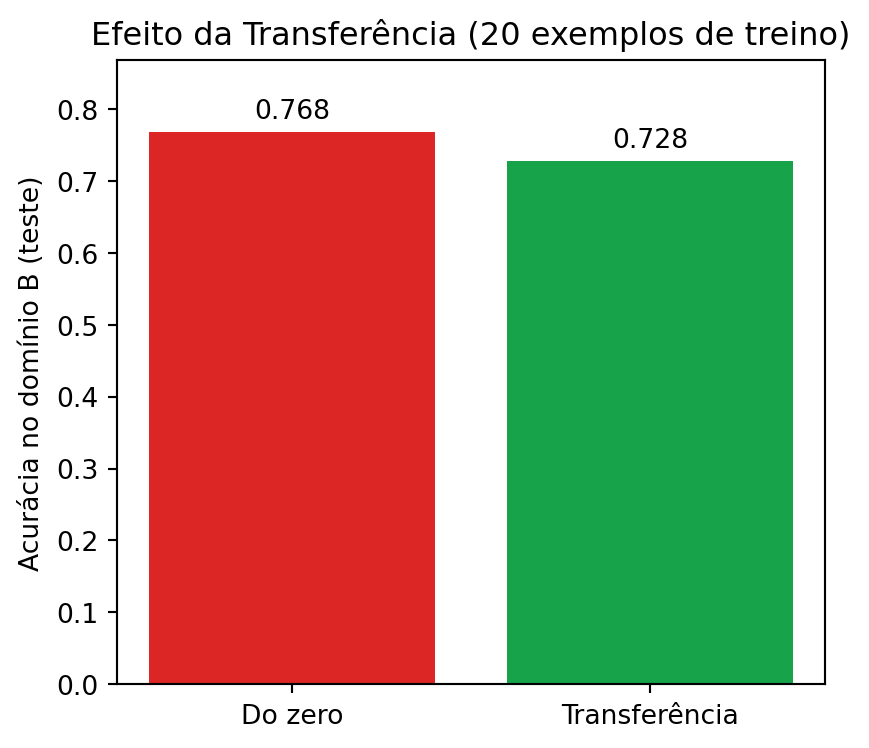

**Figure 9.21:** Comparison of accuracy on the Domínio B test set (digits 5 to 9) under data restriction (20 training examples): demonstration of the impact of rigid freezing and negative transfer in low-capacity networks.


In [22]:
# Fix seed for reproducibility
torch.manual_seed(42)

# Display training and test group sizes
print("=== Database Size Breakdown ===")
print(f"Domain A (0-4) — Training: {len(XA_tr_t)} samples | Test: {len(XA_te_t)} samples")
print(f"Domain B (5-9) — Full training: {len(XB_tr)} | Reduced training: {len(XB_tr_poucos)}",
      f"| Test: {len(XB_te_t)} samples\n")

# 1. Pre-training on the source task (Domain A: digits 0-4)
modelo_origem = CNNCompleta(n_classes=5)                       # Create CNN

#######
treinar(modelo_origem, XA_tr_t, yA_tr_t, epocas=40, lr=1e-2)   # Train model
         
acc_A = calcular_acuracia(modelo_origem, XA_te_t, yA_te_t)     # Measure accuracy
                          
print(f"Accuracy in source domain A "                      # Display result
      f"(digits 0-4, {len(XA_te_t)} tests): " f"{acc_A:.4f}"# Display result
      f"(dígitos 0-4, {len(XA_te_t)} testes): " f"{acc_A:.4f}")

# 2. Transfer Learning (Frozen Extractor)
modelo_transferencia = CNNCompleta(n_classes=5)        # Create CNN
modelo_transferencia.extrator.load_state_dict(         # Copy extractor
    modelo_origem.extrator.state_dict())

for p in modelo_transferencia.extrator.parameters():   # Traverse extractor
    p.requires_grad = False                            # Freeze weights

params_cabeca = list(modelo_transferencia.fc1.parameters())  # FC1
params_cabeca += list(modelo_transferencia.fc2.parameters()) # +FC2

#######
treinar(modelo_transferencia, XB_tr_t, yB_tr_t,              # Train head
         epocas=40, lr=1e-2, parametros=params_cabeca)

acc_transferencia = calcular_acuracia(modelo_transferencia, XB_te_t, yB_te_t) # Measure accuracy

# 3. Training from Scratch in Domain B
modelo_do_zero = CNNCompleta(n_classes=5)                     # Create CNN

#######
treinar(modelo_do_zero, XB_tr_t, yB_tr_t, epocas=40, lr=1e-2) # Train model
         
acc_do_zero = calcular_acuracia(modelo_do_zero,  XB_te_t, yB_te_t) # Measure accuracy
                               

print(f"Target domain B (digits 5-9), only {len(XB_tr_poucos)} ", 
      f"training examples ({len(XB_te_t)} tests):")
print(f"  With transfer (frozen extractor): {acc_transferencia:.4f}")
print(f"  Training from scratch (same data/epochs): {acc_do_zero:.4f}")

# Comparative visualization
plt.figure(figsize=(4.5, 4))
plt.bar(["Do zero", "Transferência"], [acc_do_zero, acc_transferencia], 
        color=["#dc2626", "#16a34a"])
plt.ylim(0, max([acc_do_zero, acc_transferencia]) + 0.1)
plt.ylabel("Acurácia no domínio B (teste)")
plt.title(f"Efeito da Transferência ({len(XB_tr_poucos)} exemplos de treino)")

for i, v in enumerate([acc_do_zero, acc_transferencia]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

###### Block 4: Visualization of the Activation Flow with `mm.showNet`

To confirm that the reused feature extraction preserves the dimensional transformations studied in the previous project, the `mm.showNet` function from the `morph` library is used again. [Figure 9.22](#fig-09-transfer-shownet) displays the activation flow of `modelo_transferencia` when processing a sample from Domain B (digit $7$, reindexed to class $2$).

1. **Preservation of the Convolutional Flow:** Since the `ExtratorConv` architecture replicates the same convolution and pooling layers as the `CNNDigitos` from the previous project, the dimensions of the intermediate tensors remain at $(1, 8, 4, 4)$ in the first block.
2. **Inspection of the Adapted Head:** The difference from the previous project arises in the output layer (`fc2`): whereas the previous project's model projected the intermediate vector into $10$ *logits* (classes $0$ through $9$), the transfer model projects the vector into $5$ *logits* (classes $0$ through $4$), capturing the relative probabilities of Domain B.

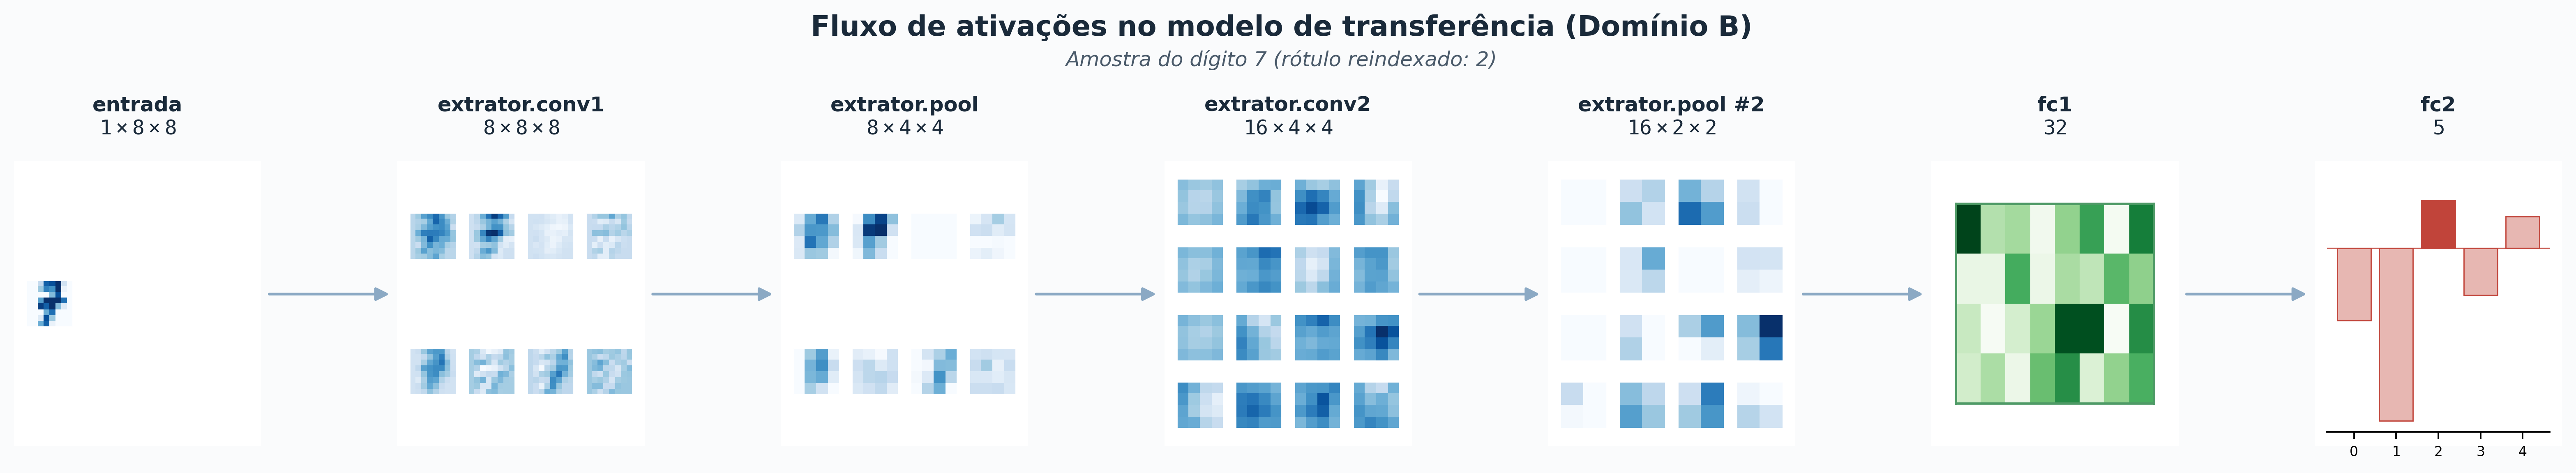

**Figure 9.22:** Flow of activations and dimensional transformations of the tensors in the transfer learning model when processing a test sample from Domain B (digit 7, reindexed to class 2).


Layers captured in the transfer model:
 ['extrator.conv1', 'extrator.pool', 'extrator.conv2', 'extrator.pool #2', 'fc1', 'fc2']


In [23]:
# Selects the first test sample from Domain B
x_amostra_B = XB_te_t[0:1]  # Tensor of dimension (1, 1, 8, 8)
classe_verdadeira = yB_te_t[0].item()
classe_original = classe_verdadeira + 5

# Inspection of the activation flow in the transfer model
acts_transfer = mm.showNet(
    modelo_transferencia,
    x_amostra_B,
    titulo="Fluxo de ativações no modelo de transferência (Domínio B)",
    subtitulo=f"Amostra do dígito {classe_original} (rótulo reindexado: {classe_verdadeira})",
)

print("Layers captured in the transfer model:\n", list(acts_transfer.keys()))

###### Analysis of Experiment 1

The model trained from scratch achieves superior accuracy compared to the model with transfer learning and a frozen feature extractor. This result characterizes a case of **negative transfer** and stems from three factors:

1. **Low capacity:** The feature extractor has only $16$ filters of size $3 \times 3$, insufficient to learn generalizable representations.

2. **Domain specialization:** Training on digits $0$ through $4$ produces filters that are poorly discriminative for digits $5$ through $9$.

3. **Lack of adaptation:** Freezing prevents the feature extractor from adjusting its filters to the new task.

> ### 📝 Nota
>
> ###### 💡 Pedagogical Prompt
>
> This experiment uses a small feature extractor trained on a restricted domain. Would the result be different if the feature extractor had learned its representations on a dataset with millions of images and great object diversity?

##### Experiment 2 — When Transfer Actually Works (*Pre-trained ResNet-18*)

The second experiment repeats the same structure as the first — few training examples, two classes, comparison between strategies — but replaces the handcrafted extractor of $16$ filters with the **_ResNet-18_**, an $18$-layer architecture pre-trained on *ImageNet* ($1.4$ million images, $1,000$ categories), and the synthetic digit dataset with real photographs from the **Oxford-IIIT Pet Dataset** (PARKHI, 2012).

The task: distinguish two canine breeds — **Pug** and **Boxer** — from only $15$ training photographs per class.

> ### 💡 Dica
>
> ###### 🐶 Why this scenario?
> The challenge here is not the visual similarity between the breeds — Pug and Boxer have quite distinct sizes and proportions — but rather the scarcity of data: only $30$ real photographs in total, with no synthetic images whatsoever. It is the type of low-data-budget problem that, in practice, motivates the use of pre-trained networks: there is neither time nor resources to photograph and label thousands of dogs before training a classifier from scratch.

###### Block 1: Loading the Real *Dataset* and Sparse Sampling

1. **Source:** the *Oxford-IIIT Pet Dataset* (PARKHI, 2012) is loaded via `torchvision.datasets.OxfordIIITPet`, which automatically downloads the $7,349$ photographs and their breed labels on the first run.
2. **Filtering:** only the two breeds of interest (`Pug`, `Boxer`) are kept.
3. **Deliberate sparsity:** only $15$ training photographs per class ($30$ in total) are sampled — the remainder constitutes the test set, used exclusively for evaluation.

[Figure 9.23](#fig-09-pets-amostras) displays training samples for each breed.

In [24]:
import random

RACAS_ALVO = ["Pug", "Boxer"]
N_TREINO_POR_CLASSE = 15
N_TESTE_POR_CLASSE = 20

# 1. Download of the full dataset (37 breeds) — CC BY-SA 4.0 license
pets_completo = OxfordIIITPet(
    root="dados_pets", split="trainval", target_types="category", download=True
)
nomes_racas = pets_completo.classes
indices_alvo = [nomes_racas.index(r) for r in RACAS_ALVO]

# 2. Filtering of the two breeds of interest, separated by class
por_classe = {idx: [] for idx in indices_alvo}
for img, lbl in pets_completo:
    if lbl in indices_alvo:
        por_classe[lbl].append(img)

# 3. Sampling: few training images, more test images
rng = random.Random(42)
imgs_treino, y_treino, imgs_teste, y_teste = [], [], [], []
for classe_idx, idx_original in enumerate(indices_alvo):
    imgs_raca = por_classe[idx_original][:]
    rng.shuffle(imgs_raca)
    imgs_treino += imgs_raca[:N_TREINO_POR_CLASSE]
    y_treino += [classe_idx] * N_TREINO_POR_CLASSE
    imgs_teste += imgs_raca[N_TREINO_POR_CLASSE : N_TREINO_POR_CLASSE + N_TESTE_POR_CLASSE]
    y_teste += [classe_idx] * N_TESTE_POR_CLASSE

print(f"Training: {len(imgs_treino)} images | Test: {len(imgs_teste)} images")

amostras_pil = imgs_treino[:4] + imgs_treino[N_TREINO_POR_CLASSE:N_TREINO_POR_CLASSE + 4]
amostras_exibicao = [np.array(img.convert("RGB")) for img in amostras_pil]  # PIL -> ndarray
titulos_exibicao = [RACAS_ALVO[0]] * 4 + [RACAS_ALVO[1]] * 4
mm.show(amostras_exibicao, titles=titulos_exibicao, cols=4, figsize=(11, 6))

**Figure 9.23:** Real training samples from the *Oxford-IIIT Pet Dataset* (Parkhi et al., 2012, CC BY-SA 4.0 license): *Pug* and *Boxer*, breeds chosen to simulate a real-world data-scarcity scenario.


###### Block 2: Three Strategies on the Same Architecture

To isolate the effect of transfer learning, the three strategies reuse **exactly the same architecture** (*ResNet-18*), differing only in the origin of the weights and which parameters remain trainable:

1. **`from_scratch`:** random weights (`weights=None`) — equivalent to training the *ResNet-18* architecture entirely from scratch, as in Block 2 of Experiment 1.
2. **`frozen`:** weights pre-trained on *ImageNet*, with `requires_grad = False` in all convolutional layers — only the new final layer is trained.
3. **`fine_tuning`:** weights pre-trained on *ImageNet* as a starting point, but **without** freezing — the entire network adapts to the new domain, with a low learning rate to avoid destroying prior knowledge.

In all cases, the final layer `fc` is replaced by `nn.Linear(fc.in_features, 2)`, corresponding to the two target breeds.

In [25]:
transformacao_resnet = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def prepara_tensores(imgs, labels):
    X = torch.stack([transformacao_resnet(img.convert("RGB")) for img in imgs])
    y = torch.tensor(labels, dtype=torch.long)
    return X, y

X_tr, y_tr = prepara_tensores(imgs_treino, y_treino)
X_te, y_te = prepara_tensores(imgs_teste, y_teste)

def cria_modelo_pets(estrategia):
    pesos = None if estrategia == "do_zero" else models.ResNet18_Weights.DEFAULT
    modelo = models.resnet18(weights=pesos)
    if estrategia == "congelado":
        for p in modelo.parameters():
            p.requires_grad = False
    modelo.fc = nn.Linear(modelo.fc.in_features, len(RACAS_ALVO))
    return modelo

modelo_do_zero = cria_modelo_pets("do_zero")
modelo_congelado = cria_modelo_pets("congelado")
modelo_fine_tuning = cria_modelo_pets("fine_tuning")

###### Block 3: Comparative Training and Accuracy Analysis

Reusing the generic functions `treinar` and `calcular_acuracia`, defined in Block 2 of Experiment 1, the three models are trained on the same set of $30$ photographs and evaluated on the test set (images never seen during training):

* The `do_zero` model tends to **overfit** quickly to the $30$ training photographs, without generalizing to the test set — $30$ examples are drastically insufficient to adjust the $11$ million parameters of the *ResNet-18* from scratch.
* The `congelado` model should already achieve considerably higher accuracy, as it reuses, without any adjustment, generic visual features (edges, textures, contours) learned on *ImageNet* — only the new linear layer needs to be adjusted to the $30$ photographs.
* The `fine_tuning` model tends to match or surpass the frozen extractor, as it starts from the same prior knowledge, but also allows fine-tuning of the entire network to the visual particularities of the breeds.

[Figure 9.24](#fig-09-pets-comparativo) summarizes the three results.

In [26]:
torch.manual_seed(42)

configuracoes = [
    ("Do zero",              modelo_do_zero,      None, 2e-3),
    ("Extrator congelado",   modelo_congelado,    "fc", 1e-3),
    ("Fine-tuning completo", modelo_fine_tuning,  None, 1e-4),
]

resultados_pets = {}
for nome, modelo, alvo_params, taxa in configuracoes:
    parametros = modelo.fc.parameters() if alvo_params == "fc" else None
    treinar(modelo, X_tr, y_tr, epocas=15, lr=taxa, tam_lote=8, parametros=parametros)
    resultados_pets[nome] = calcular_acuracia(modelo, X_te, y_te)
    print(f"{nome}: {resultados_pets[nome]*100:.1f}%")

plt.figure(figsize=(5.5, 4))
cores = ["#dc2626", "#f59e0b", "#16a34a"]
plt.bar(resultados_pets.keys(), resultados_pets.values(), color=cores)
plt.ylim(0, 1.05)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chute aleatório (50%)")
plt.ylabel("Acurácia no teste")
plt.title("Pug vs. Boxer — 15 fotos de treino/classe")
for i, v in enumerate(resultados_pets.values()):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha="center")
plt.xticks(rotation=10)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 9.24:** Comparison of accuracy on the real test set (*Pug* vs. *Boxer*, 15 training photographs per class): from scratch, frozen extractor and full *fine-tuning*, all on the same ResNet-18 architecture.


###### Block 4: Qualitative Inspection of Predictions

As in Experiment 1 and in the following section on foliar diagnosis, it is instructive to observe individually some predictions of the best model (typically `fine_tuning` or `frozen`) on real test photographs, comparing the predicted label with the actual breed.

In [27]:
melhor_modelo = modelo_fine_tuning  # or frozen_model, according to the result of Block 3
melhor_modelo.eval()

idx_amostras = list(range(4)) + list(range(N_TESTE_POR_CLASSE, N_TESTE_POR_CLASSE + 4))

imgs_pred, titulos_pred = [], []
with torch.no_grad():
    for idx in idx_amostras:
        entrada = X_te[idx].unsqueeze(0)
        pred_idx = melhor_modelo(entrada).argmax(dim=1).item()
        real_idx = y_te[idx].item()
        marcador = "✓" if pred_idx == real_idx else "✗"
        imgs_pred.append(np.array(imgs_teste[idx].convert("RGB")))  # PIL -> ndarray
        titulos_pred.append(f"{marcador} previsto: {RACAS_ALVO[pred_idx]}\n"
                             f"real: {RACAS_ALVO[real_idx]}")

mm.show(imgs_pred, titles=titulos_pred, cols=4, figsize=(12, 7))

**Figure 9.25:** Model predictions with pre-trained extractor (ResNet-18) on real test photographs: predicted label vs. real breed, four samples from each class.


In [28]:
 
# Explicit cleanup of downloaded data and memory release
if FLAG_LIMPAR_DADOS:
    if os.path.exists('./dados_pets'):
        shutil.rmtree('./dados_pets')
        print('🧹 Temporary data directory ./pets_data removed successfully.')

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

##### Experiment 3 — Phytosanitary Diagnosis with Transfer Learning

The previous experiment showed that a *ResNet-18* pre-trained on **ImageNet** can adapt to a new task using few samples. Now, the same strategy is applied to a phytosanitary diagnosis problem. The *ResNet-18* must classify images of leaves into three categories: `["folha_saudavel", "folha_doente", "sintoma_desconhecido"]`.

- **`folha_saudavel`:** leaf without visible lesions.
- **`folha_doente`:** leaf with dark spots that simulate a fungal disease.
- **`sintoma_desconhecido`:** leaf with yellowish chlorosis, representing a pattern different from the known disease.

> ### 💡 Dica
>
> ###### 🌱 Why this scenario?
>
> Phytosanitary diagnosis constitutes an important application of CV in precision agriculture. A model pre-trained on **ImageNet** can reuse features such as edges, textures, and color patterns to learn this new task with few images.

###### Block 1: Generation of the Synthetic *Dataset*

This block generates a synthetic set with **30** images per class for training and **8** for validation, totaling **90** and **24** images, respectively.

1. **Leaf generation:** The `desenha_folha_base` function creates the leaf outline, varying size, orientation, and shade of green.

2. **Disease simulation:** The `aplica_manchas_doenca` function adds irregular dark spots that simulate fungal lesions.

3. **Simulation of another symptom:** The `aplica_sintoma_desconhecido` function adds yellowish regions representing a pattern distinct from the known disease.

4. **Sample visualization:** [Figure 9.26](#fig-09-folhas-amostras) presents examples of the three categories of the synthetic set.

Training: 90 images (30 per class) | Validation: 24 images (8 per class)


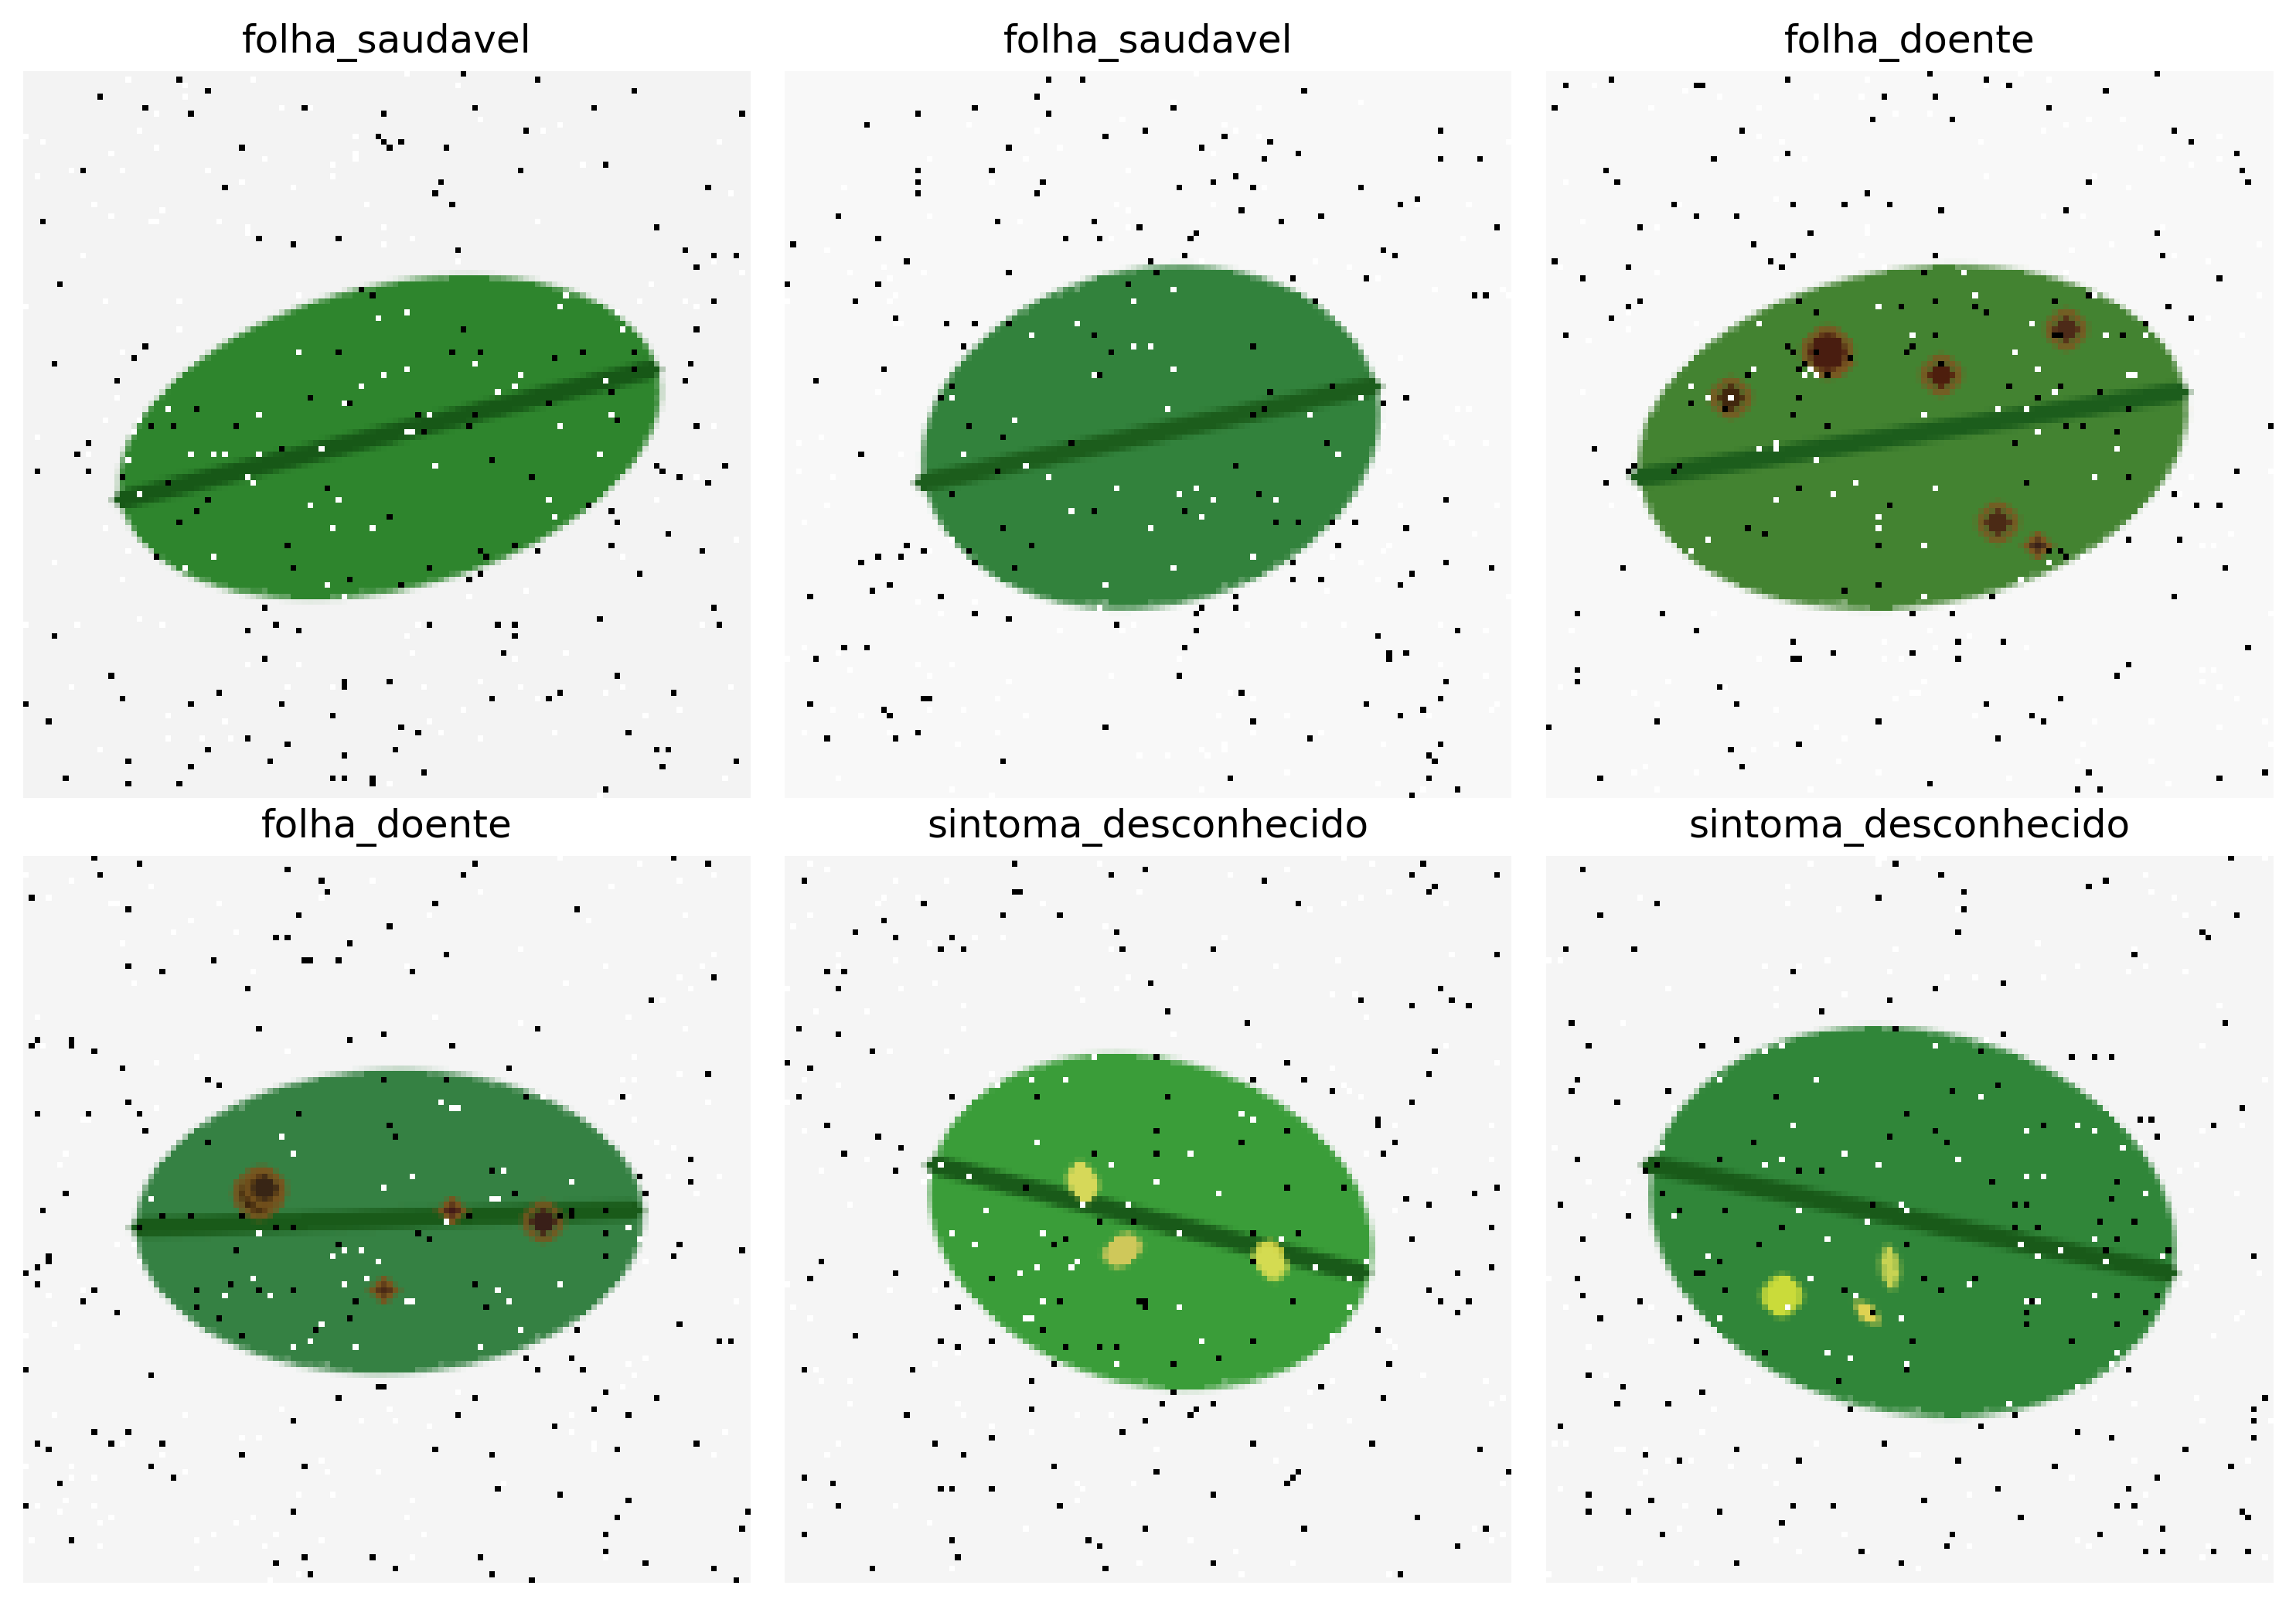

**Figure 9.26**


In [29]:
# | fig-cap: "Synthetic samples from the leaf diagnosis *dataset*: healthy leaf, diseased leaf (dark spots) and unknown symptom (yellowish chlorosis) with salt-and-pepper noise."
# | echo: true
# | output: true

CLASSES_FOLHA = ["folha_saudavel", "folha_doente", "sintoma_desconhecido"]


def desenha_folha_base(tam_img, rng):
    '''Draws the oval outline of a green leaf with a central vein,
    with small variations in tone, size and orientation between samples.'''
    img = np.full((tam_img, tam_img, 3), 245, dtype=np.uint8)  # light background
    cx, cy = tam_img // 2, tam_img // 2
    eixo_a = rng.randint(int(tam_img * 0.30), int(tam_img * 0.38))
    eixo_b = rng.randint(int(tam_img * 0.20), int(tam_img * 0.26))
    angulo = rng.uniform(-15, 15)
    verde = (rng.randint(40, 70), rng.randint(120, 160), rng.randint(40, 70))
    cv2.ellipse(img, (cx, cy), (eixo_a, eixo_b), angulo, 0, 360, verde, -1, cv2.LINE_AA)
    ang_rad = np.deg2rad(angulo)
    dx, dy = np.cos(ang_rad), np.sin(ang_rad)
    p1 = (int(cx - eixo_a * dx), int(cy - eixo_a * dy))
    p2 = (int(cx + eixo_a * dx), int(cy + eixo_a * dy))
    cv2.line(img, p1, p2, (25, 90, 25), 2, cv2.LINE_AA)  # central vein
    return img, (cx, cy, eixo_a, eixo_b, angulo)


def aplica_manchas_doenca(img, centro_folha, rng, n_manchas=(4, 8)):
    '''Simulates leaf lesions: dark spots with irregular edges
    (typical pattern of fungal diseases).'''
    cx, cy, eixo_a, eixo_b, _ = centro_folha
    for _ in range(rng.randint(*n_manchas)):
        raio = rng.randint(1, 3)
        px = cx + rng.randint(-int(eixo_a * 0.7), int(eixo_a * 0.7))
        py = cy + rng.randint(-int(eixo_b * 0.7), int(eixo_b * 0.7))
        cor_mancha = (rng.randint(50, 90), rng.randint(25, 45), rng.randint(10, 25))
        cv2.circle(img, (px, py), raio, cor_mancha, -1, cv2.LINE_AA)
        cv2.circle(img, (px, py), raio + 1, (120, 85, 30), 1, cv2.LINE_AA)  # halo
    return img


def aplica_sintoma_desconhecido(img, centro_folha, rng):
    '''Simulates a distinct pattern (yellowish mottling/chlorosis), different
    from the dark spots of the known disease.'''
    cx, cy, eixo_a, eixo_b, _ = centro_folha
    for _ in range(rng.randint(3, 5)):
        eixo_m = (rng.randint(1, 3), rng.randint(2, 3))
        px = cx + rng.randint(-int(eixo_a * 0.6), int(eixo_a * 0.6))
        py = cy + rng.randint(-int(eixo_b * 0.6), int(eixo_b * 0.6))
        cor_clorose = (rng.randint(200, 235), rng.randint(195, 225), rng.randint(50, 90))
        ang_m = rng.uniform(0, 180)
        cv2.ellipse(img, (px, py), eixo_m, ang_m, 0, 360, cor_clorose, -1, cv2.LINE_AA)
    return img


def aplica_ruido_sal_pimenta(img, prop_ruido=0.02, rng=None):
    '''Applies random salt noise (white dots) and pepper noise (black dots).
    prop_noise: fraction of altered pixels (e.g., 0.02 = 2% of pixels).'''
    if prop_ruido <= 0:
        return img
    
    img_ruido = img.copy()
    num_pixels = int(prop_ruido * img.shape[0] * img.shape[1])
    n_sal = num_pixels // 2
    n_pimenta = num_pixels - n_sal

    # Applies Salt (White - [255, 255, 255])
    for _ in range(n_sal):
        y = rng.randint(0, img.shape[0] - 1)
        x = rng.randint(0, img.shape[1] - 1)
        img_ruido[y, x] = [255, 255, 255]

    # Applies Pepper (Black - [0, 0, 0])
    for _ in range(n_pimenta):
        y = rng.randint(0, img.shape[0] - 1)
        x = rng.randint(0, img.shape[1] - 1)
        img_ruido[y, x] = [0, 0, 0]

    return img_ruido


def gera_folha(classe_idx, tam_img=128, rng=None, prop_ruido=0.02):
    rng = rng or random.Random()
    img, geometria = desenha_folha_base(tam_img, rng)
    nome = CLASSES_FOLHA[classe_idx]
    
    if nome == "folha_doente":
        img = aplica_manchas_doenca(img, geometria, rng)
    elif nome == "sintoma_desconhecido":
        img = aplica_sintoma_desconhecido(img, geometria, rng)
        
    ruido_exp = rng.randint(-3, 3)  # slight exposure variation
    img = np.clip(img.astype(np.int16) + ruido_exp, 0, 255).astype(np.uint8)
    
    # Application of Salt and Pepper noise
    img = aplica_ruido_sal_pimenta(img, prop_ruido=prop_ruido, rng=rng)
    
    return img


def gera_conjunto(n_por_classe, tam_img=128, seed=0, prop_ruido=0.02):
    rng = random.Random(seed)
    imgs, labels = [], []
    for classe_idx in range(len(CLASSES_FOLHA)):
        for _ in range(n_por_classe):
          imgs.append(gera_folha(classe_idx, tam_img=tam_img, rng=rng, prop_ruido=prop_ruido))
          labels.append(classe_idx)
    return imgs, labels


N_POR_CLASSE_TREINO, N_POR_CLASSE_VAL = 30, 8

imgs_treino, labels_treino = gera_conjunto(n_por_classe=N_POR_CLASSE_TREINO, seed=42, 
                                           prop_ruido=0.02)
imgs_val, labels_val = gera_conjunto(n_por_classe=N_POR_CLASSE_VAL, seed=123, prop_ruido=0.02)

print(f"Training: {len(imgs_treino)} images ({N_POR_CLASSE_TREINO} per class) | "
      f"Validation: {len(imgs_val)} images ({N_POR_CLASSE_VAL} per class)")

# Display of 2 samples of each class (6 images in total)
amostras_exibir, titulos_exibir = [], []
for classe_idx, nome in enumerate(CLASSES_FOLHA):
    for k in range(2):
        idx = classe_idx * N_POR_CLASSE_TREINO + k
        amostras_exibir.append(imgs_treino[idx])
        titulos_exibir.append(nome)

mm.show(amostras_exibir, titles=titulos_exibir, cols=3, figsize=(10, 7))

> ### 📝 Nota
>
> ###### 🧠 Common Pitfall
>
> Transfer learning requires that each class exhibits distinct visual patterns. Repeating the same image with different labels prevents the classifier layer from learning a decision boundary, since the feature extractor produces nearly identical features for all samples.
>
> In this experiment, each image is independently generated, with visual patterns consistent with its class (healthy leaf, fungal lesions, or chlorosis), providing sufficient information for training the classifier layer.

###### Block 2: Preparation of Tensors and Architecture Adaptation

Models such as *ResNet-18* require color images of $224 \times 224$ *pixels* normalized according to *ImageNet* statistics ($\mu = [0.485; 0.456; 0.406]$ and $\sigma = [0.229; 0.224; 0.225]$).

1. **Input Transformation (`transforms.Compose`):** resizing and standard normalization are applied to each image of the synthetic *dataset*, producing the tensors `X_treino`/`X_val` and the labels `y_treino`/`y_val` — each example is a genuinely distinct image, associated with the correct label of its class.
2. **Freezing the Extractor:** the loop `for p in modelo_resnet.parameters(): p.requires_grad = False` disables gradients in the pre-trained convolutional layers.
3. **New Final Layer:** the layer `modelo_resnet.fc` is replaced by a new instance `nn.Linear(modelo_resnet.fc.in_features, n_classes_destino)`, freshly initialized and with gradients active by default. The number of input features is obtained dynamically from the original layer itself (`in_features`, equal to $512$ in ResNet-18), rather than being manually fixed in the code — a recommended practice, as it makes the snippet reusable for other variants of the architecture without modifications.

In [30]:
# 1. Pipeline of transformations expected by ResNet
transformacao_resnet = T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def prepara_tensores(imgs, labels):
    tensores = [transformacao_resnet(T.functional.to_tensor(img)) for img in imgs]
    X = torch.stack(tensores)
    y = torch.tensor(labels, dtype=torch.long)
    return X, y


# 2. Conversion of the synthetic dataset (Block 1) into normalized tensors
X_treino, y_treino = prepara_tensores(imgs_treino, labels_treino)
X_val, y_val = prepara_tensores(imgs_val, labels_val)

loader_treino = DataLoader(TensorDataset(X_treino, y_treino), batch_size=16, shuffle=True)
loader_val = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)

# 3. Loading of the pre-trained ResNet-18 and freezing of the feature extractor
n_classes_destino = len(CLASSES_FOLHA)
modelo_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for parametro in modelo_resnet.parameters():
    parametro.requires_grad = False

# 4. Replacement of the final layer for the 3 new target classes
modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, n_classes_destino)

print(f"New final layer: {modelo_resnet.fc}")

###### Block 3: Training Loop and Evaluation

With the extractor frozen and the new output layer properly attached, the fine-tuning of the new classification head is carried out.

1. **Focused Optimization:** the *Adam* optimizer receives strictly `modelo_resnet.fc.parameters()`, updating only the new output layer — the rest of the network remains frozen, as defined in Block 2.
2. **Loop Execution:** at each epoch, the model iterates over the training batches, computes the Cross-Entropy loss, and adjusts the weights of the final layer; subsequently, the accuracy is evaluated on the validation set (images never seen during training).
3. **Training Curves:** [Figure 9.27](#fig-09-resnet-treino) tracks the evolution of the training loss and validation accuracy over the epochs — since the three classes are visually distinct from one another, genuine convergence is expected, well above the $33\%$ threshold corresponding to a random guess among $3$ classes.

In [31]:
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_resnet = modelo_resnet.to(dispositivo)

criterio = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo_resnet.fc.parameters(), lr=1e-3)

historico_perda, historico_acc = [], []
epocas = 10

for epoca in range(epocas):
    modelo_resnet.train()
    perda_acumulada, n_batches = 0.0, 0

    for X_batch, y_batch in loader_treino:
        X_batch, y_batch = X_batch.to(dispositivo), y_batch.to(dispositivo)

        otimizador.zero_grad()
        saidas = modelo_resnet(X_batch)
        perda = criterio(saidas, y_batch)
        perda.backward()
        otimizador.step()

        perda_acumulada += perda.item()
        n_batches += 1
    historico_perda.append(perda_acumulada / n_batches)

    modelo_resnet.eval()
    acertos, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader_val:
            X_batch, y_batch = X_batch.to(dispositivo), y_batch.to(dispositivo)
            predicoes = modelo_resnet(X_batch).argmax(dim=1)
            acertos += (predicoes == y_batch).sum().item()
            total += y_batch.size(0)
    acc = acertos / total
    historico_acc.append(acc)

    print(f"Epoch {epoca+1}/{epocas} — loss: {historico_perda[-1]:.4f} — ",
          f" val_accuracy: {acc*100:.1f}%")

f=mm.showTrainCurves(
    historico_perda, historico_acc,
    titulo="Fine-Tuning da ResNet-18 — Diagnóstico Foliar",
    subtitulo="Apenas a nova camada linear (fc) é treinada; o extrator permanece congelado",
)

**Figure 9.27:** Training curves of the fine-tuning of ResNet-18 on the synthetic leaf diagnosis *dataset*: training loss and validation accuracy over epochs.


###### Block 4: Qualitative Inspection of Predictions

In addition to the aggregated accuracy curve, it is instructive to individually examine some of the model's predictions on the validation set, comparing the predicted label with the true label. [Figure 9.28](#fig-09-resnet-predicoes) displays two samples from each class.

In [32]:
modelo_resnet.eval()

# Two samples from each class in the validation set
idx_amostras = [0, N_POR_CLASSE_VAL, 2 * N_POR_CLASSE_VAL,
                1, N_POR_CLASSE_VAL + 1, 2 * N_POR_CLASSE_VAL + 1]

imgs_pred, titulos_pred = [], []
with torch.no_grad():
    for idx in idx_amostras:
        entrada = X_val[idx].unsqueeze(0).to(dispositivo)
        pred_idx = modelo_resnet(entrada).argmax(dim=1).item()
        real_idx = y_val[idx].item()
        marcador = "✓" if pred_idx == real_idx else "✗"
        imgs_pred.append(imgs_val[idx])
        titulos_pred.append(f"{marcador} previsto: {CLASSES_FOLHA[pred_idx]}\n"+
                            f"real: {CLASSES_FOLHA[real_idx]}")

mm.show(imgs_pred, titles=titulos_pred, cols=3, figsize=(10, 7))

**Figure 9.28:** Predictions of the fine-tuned ResNet-18 on validation samples: predicted label vs. true label, with two samples per class.


###### Analysis of Experiment 3

The *ResNet-18* achieves high accuracy even when using a reduced set of synthetic images. This result shows that the representations learned on **ImageNet** remain useful in a completely different domain, requiring only the adaptation of the classifier layer.

The experiment also illustrates a common situation in real-world applications, where the availability of labeled data is limited. In such scenarios, transfer learning reduces training time and allows obtaining models with good performance even without training the entire network.

> ### 📝 Nota
>
> ###### 🧠 Comparative Synthesis — When Does Transfer Learning Work?
>
> The three experiments show that transfer learning depends on the generalization capacity of the feature extractor.
>
> - **Experiment 1:** a small extractor, trained on a restricted domain, learns poorly generalizable representations and can produce **negative transfer**.
>
> - **Experiment 2:** a *ResNet-18* pre-trained on **ImageNet** transfers general representations to a dog and cat breed classification task, achieving high accuracy with few samples.
>
> - **Experiment 3:** the same strategy adapts the model to a plant health diagnosis problem, showing that a single extractor can serve as a foundation for different application domains.

##### Comparison of Transfer Approaches

[Table 9.2](#tbl-comparativo-transferencia) summarizes the results obtained in the three experiments.

<a id="tbl-comparativo-transferencia"></a>

**Tabela 9.2:** Comparison among the three transfer learning scenarios presented in this section.

| Aspect | Experiment 1 | Experiment 2 | Experiment 3 |
| --- | --- | --- | --- |
| **Feature extractor** | Small CNN | *ResNet-18* | *ResNet-18* |
| **Extractor training** | Digits ($0$–$4$) | **ImageNet** | **ImageNet** |
| **Generalization capacity** | Low | High | High |
| **New task** | Digits ($5$–$9$) | Dog and cat breeds | Plant health diagnosis |
| **Result** | Negative transfer | Positive transfer | Positive transfer |


### 9.5.2 Object Detection

The previous experiments showed how transfer learning adapts pre-trained models for image classification tasks. The same principle also underpins object detection architectures, in which a pre-trained feature extractor provides general visual representations, while specialized modules locate and classify objects in the image.

The following sections present **Faster R-CNN** as an example of a pre-trained detector used directly for inference, and then a complete fine-tuning experiment with the **YOLO** architecture.

#### 9.5.2.1 Faster R-CNN: Pretrained Detector

Object detection extends the use of pretrained models to a task more complex than classification. **Faster R-CNN** uses a pretrained CNN, such as *ResNet-50*, as a **feature extractor** (*backbone*) and adds specialized modules to locate and classify objects.

Regarding this extractor, the architecture incorporates two main "heads":

- ***Region Proposal Network* (RPN):** proposes regions of the image with a high probability of containing objects.
- **Classifier head:** refines these regions, assigns a class to each object, and adjusts its bounding boxes.

The following code uses a Faster R-CNN with weights pretrained on **COCO** to detect objects in an image, producing their classes, coordinates, and confidence scores.

> ### 📝 Nota
>
> ##### 🔍 Where is transfer learning here?
>
> Unlike the previous experiments, this example **does not perform fine-tuning**. The model only performs inference (`eval()`), directly reusing the weights of the *backbone*, the RPN, and the classifier head trained on **COCO**.
>
> Adaptation to a new domain would require replacing the `box_predictor` layer with a new classification head, compatible with the classes of the application, and training it on a set of annotated images. This procedure follows the same principle presented in the transfer learning section and constitutes the usual workflow for specific applications, such as pest detection, manufacturing defects, or vehicles.

1. **COCO categories:** The code retrieves the class names from the metadata of the weights (`FasterRCNN_ResNet50_FPN_Weights.DEFAULT.meta["categories"]`). Although this list contains $91$ entries for historical reasons of the COCO annotation format, only $80$ correspond to object categories.

2. **Inference:** The image loaded by `mm.read()` is converted into a *tensor* and processed by the model in evaluation mode (`eval()`). The code keeps only the detections with confidence greater than $80\%$.

3. **Image annotation:** For each detected object, the code draws the bounding box (`cv2.rectangle`) and writes the predicted class and its confidence (`cv2.putText`).

4. **Visualization:** [Figure 9.29](#fig-09-deteccao-pretreinada) presents the annotated image with the detections made by the model.

In [33]:
# 1. Loading the image and the COCO category names
url_imagem = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
url_imagem = "http://images.cocodataset.org/val2017/000000039769.jpg"
img = mm.read(url_imagem)

pesos_coco = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
categorias_coco = pesos_coco.meta["categories"]  # Mapping index -> class name

# 2. Loading the pre-trained Faster R-CNN model
modelo_detection = fasterrcnn_resnet50_fpn(weights=pesos_coco).eval()

# 3. Running inference without gradient calculation
with torch.no_grad():
    predicao = modelo_detection([to_tensor(img)])[0]

# 4. Filtering detections with confidence higher than 80%
limiar_confianca = 0.8
mascara_confianca = predicao["scores"] >= limiar_confianca

caixas_filtradas = predicao["boxes"][mascara_confianca].numpy()
scores_filtrados = predicao["scores"][mascara_confianca].numpy()
labels_filtrados = predicao["labels"][mascara_confianca].numpy()

img_com_caixas = img.copy()

# 5. Drawing the bounding boxes and class labels
for box, score, label_idx in zip(caixas_filtradas, scores_filtrados, labels_filtrados):
    x1, y1, x2, y2 = box.astype(int)
    nome_classe = categorias_coco[label_idx]
    texto_rotulo = f"{nome_classe}: {score:.2f}"

    # Draws the red rectangle (RGB: 255, 0, 0) with 3 pixel thickness
    cv2.rectangle(img_com_caixas, (x1, y1), (x2, y2), (255, 0, 0), 3)

    # Writes the class and confidence above the bounding box
    cv2.putText(
        img_com_caixas,
        texto_rotulo,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2,
        cv2.LINE_AA,
    )

# 6. Graphical display of the resulting image
mm.show(img_com_caixas, title="Faster R-CNN (COCO) — Detection with Class and Confidence")

**Figure 9.29:** Result of inference with the Faster R-CNN model pre-trained on the *dataset* COCO: identification of the class, bounding box, and confidence score overlapped.


#### 9.5.2.2 Object Detection and Transfer Learning with YOLO

The previous sections applied transfer learning to **image classification** problems, where the model associates a single label with the entire image. In this section, the same principle is extended to **object detection**, a task that requires simultaneously identifying **what** is present in the image and **where** each object is located.

The previous subsection presented **Faster R-CNN** as an example of a pretrained detector used directly for inference, without any adaptation to the new domain. In this experiment, the model undergoes a **fine-tuning** step: starting from a **YOLO** (*You Only Look Once*) architecture pretrained on the **COCO** dataset, the network is adapted to detect and classify objects from a new domain.

Unlike Faster R-CNN, which performs detection in two stages, the **YOLO** family adopts a single-stage detector architecture, estimating, in a single pass through the network, the bounding boxes, the confidence of each detection, and the corresponding class. This strategy reduces computational cost and enables real-time applications.

As an example, the experiment uses a synthetic dataset of geometric shapes (triangles, squares, stars, among others), with variations in color, size, rotation, and degradation by salt-and-pepper noise.

##### Block 1: Generation of the Synthetic *Dataset*

The following block generates a synthetic set for training and evaluating the detector. Each image contains between one and three objects belonging to one of the nine classes:

```python
CLASSES = [
    'Triangle', 'Square', 'Pentagon', 'Hexagon',
    'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross'
]
```

1. **Shape generation:** The functions `poligono_regular`, `poligono_estrela`, and `poligono_cruz` construct the coordinates of the objects. The function `desenha_objeto` draws each shape with random position, size, orientation, and color and calculates its *bounding box*.

2. **Annotation in YOLO format:** The function `gera_imagem_ruidosa` generates between one and three objects per image and converts each *bounding box* to the YOLO format, represented by the class and the normalized coordinates of the center, width, and height.

3. **Image degradation:** The function `adiciona_ruido_sal_pimenta` adds impulsive noise, simulating acquisition imperfections.

4. **Sample visualization:** [Figure 9.30](#fig-09-yolo-amostras-iniciais) presents examples of the synthetic set with the *bounding boxes* overlaid by the function `mm.showBoundBox()`.

In [34]:
CLASSES = [
    'Triangle', 'Square', 'Pentagon', 'Hexagon',
    'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross'
]
N_LADOS = {'Triangle': 3, 'Square': 4, 'Pentagon': 5, 'Hexagon': 6, 'Heptagon': 7}

def poligono_regular(cx, cy, r, n_lados, rot_graus):
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + 2 * np.pi * np.arange(n_lados) / n_lados
    return np.stack([cx + r * np.cos(angs), cy + r * np.sin(angs)], axis=1)

def poligono_estrela(cx, cy, r_externo, rot_graus, n_pontas=5):
    r_interno = r_externo * 0.45
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + np.pi * np.arange(2 * n_pontas) / n_pontas
    raios = np.where(np.arange(2 * n_pontas) % 2 == 0, r_externo, r_interno)
    return np.stack([cx + raios * np.cos(angs), cy + raios * np.sin(angs)], axis=1)

def poligono_cruz(cx, cy, r, rot_graus, espessura_rel=0.35):
    w = r * espessura_rel
    base = np.array([
        (-w, -r), (w, -r), (w, -w), (r, -w), (r, w), (w, w),
        (w, r), (-w, r), (-w, w), (-r, w), (-r, -w), (-w, -w),
    ])
    theta = np.deg2rad(rot_graus)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return base @ R.T + np.array([cx, cy])

def desenha_objeto(img, classe_idx, cx, cy, tamanho, rotacao, cor):
    nome = CLASSES[classe_idx]
    if nome in N_LADOS:
        pts = poligono_regular(cx, cy, tamanho, N_LADOS[nome], rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Star':
        pts = poligono_estrela(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Cross':
        pts = poligono_cruz(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Circle':
        cv2.circle(img, (int(cx), int(cy)), int(tamanho), cor, -1)
        xs, ys = np.array([cx - tamanho, cx + tamanho]), np.array([cy - tamanho, cy + tamanho])
    else:  # Ellipse
        eixo = (int(tamanho), int(tamanho * 0.6))
        cv2.ellipse(img, (int(cx), int(cy)), eixo, rotacao, 0, 360, cor, -1)
        ang = np.deg2rad(rotacao)
        dx = np.hypot(eixo[0] * np.cos(ang), eixo[1] * np.sin(ang))
        dy = np.hypot(eixo[0] * np.sin(ang), eixo[1] * np.cos(ang))
        xs, ys = np.array([cx - dx, cx + dx]), np.array([cy - dy, cy + dy])
    return xs.min(), ys.min(), xs.max(), ys.max()

def adiciona_ruido_sal_pimenta(img, quantidade=0.05):
    img_ruidosa = img.copy()
    h, w, c = img_ruidosa.shape
    num_ruido = int(quantidade * h * w)
    
    # White (255, 255, 255)
    coords_sal = [np.random.randint(0, i - 1, num_ruido) for i in (h, w)]
    img_ruidosa[coords_sal[0], coords_sal[1]] = [255, 255, 255]
    
    # Black (0, 0, 0)
    coords_pimenta = [np.random.randint(0, i - 1, num_ruido) for i in (h, w)]
    img_ruidosa[coords_pimenta[0], coords_pimenta[1]] = [0, 0, 0]
    
    return img_ruidosa

def gera_imagem_ruidosa(tam_img=160, n_objetos=(1, 3), taxa_ruido=0.01, rng=None):
    rng = rng or random.Random()
    img_limpa = np.full((tam_img, tam_img, 3), 255, dtype=np.uint8)
    anotacoes = []
    
    for _ in range(rng.randint(*n_objetos)):
        classe_idx = rng.randrange(len(CLASSES))
        tamanho = rng.randint(tam_img // 10, tam_img // 5)
        cx = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        cy = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        rotacao = rng.uniform(0, 360)
        cor = tuple(rng.sample(range(30, 226), 3))
        
        x0, y0, x1, y1 = desenha_objeto(img_limpa, classe_idx, cx, cy, tamanho, rotacao, cor)
        x0, y0 = max(x0, 0), max(y0, 0)
        x1, y1 = min(x1, tam_img), min(y1, tam_img)
        
        # YOLO format: (class, x_center, y_center, width, height) normalized
        xc, yc = (x0 + x1) / 2 / tam_img, (y0 + y1) / 2 / tam_img
        w, h = (x1 - x0) / tam_img, (y1 - y0) / tam_img
        anotacoes.append((classe_idx, xc, yc, w, h)) 
        
    img_ruidosa = adiciona_ruido_sal_pimenta(img_limpa, quantidade=taxa_ruido)
    return img_ruidosa, anotacoes

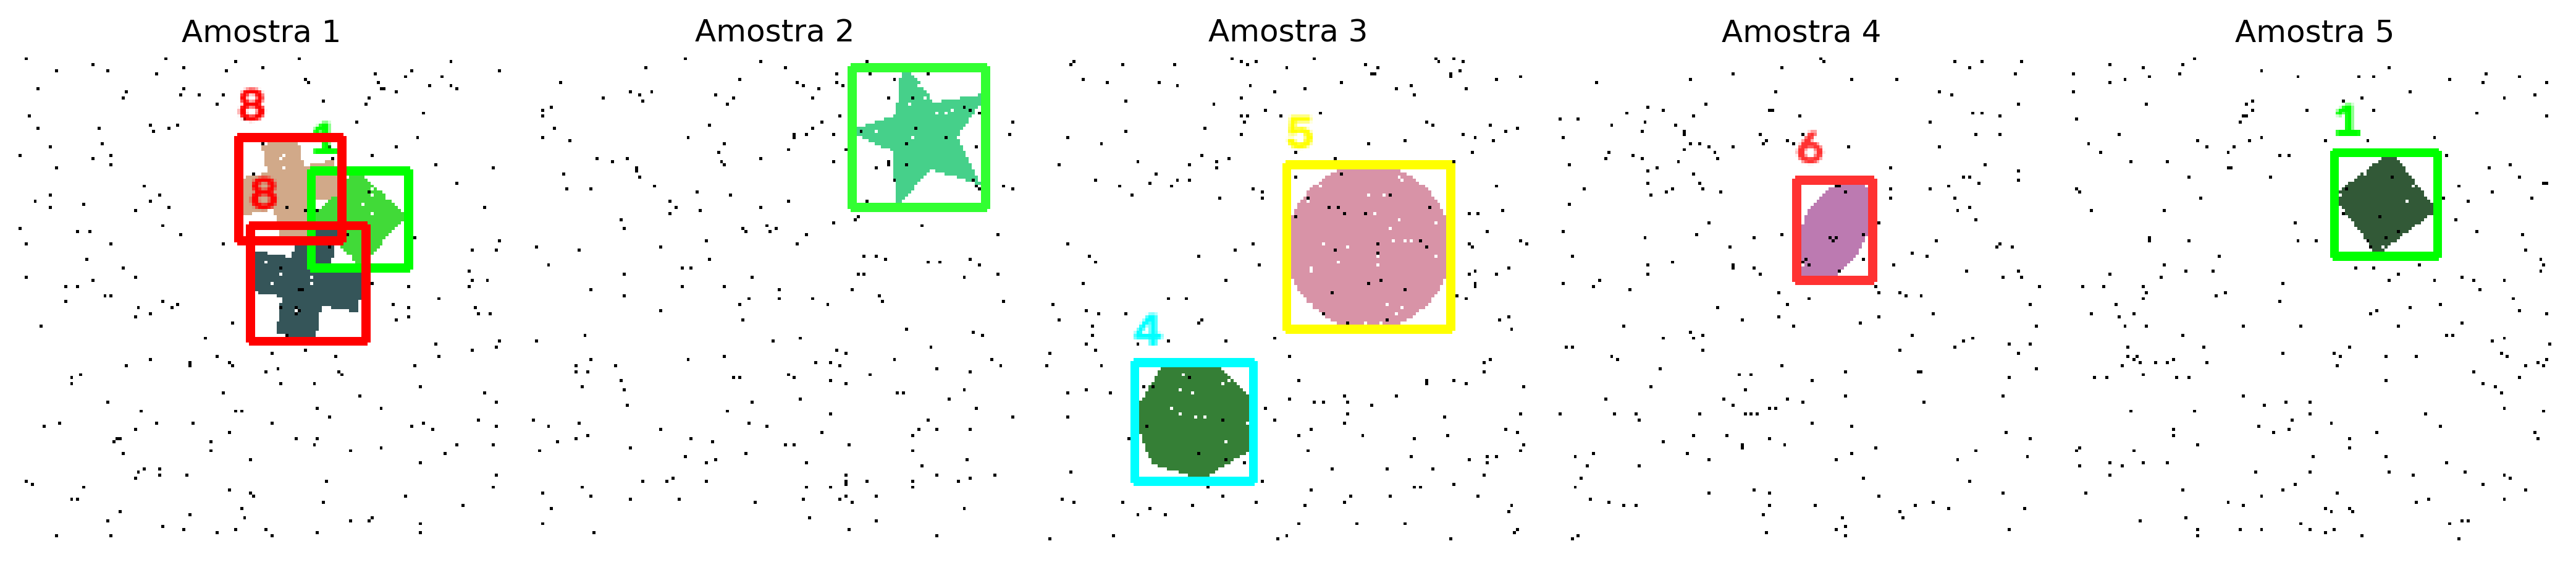

**Figure 9.30:** Initial samples of the noisy synthetic geometric objects *dataset* with YOLO-format bounding boxes overlaid.


In [35]:
# Generation of 5 samples for initial display at the top of the project
n_amostras_iniciais = 5
rng_demo = random.Random(42)

imgs_demo = []
titulos_demo = []

for idx in range(n_amostras_iniciais):
    img_ruid, anotacoes = gera_imagem_ruidosa(rng=rng_demo)
    
    # Temporary recording of the annotation for native reading by mm.showBoundBox
    filename_temp = f"temp_label_{idx}.txt"
    with open(filename_temp, "w") as f:
        for c, xc, yc, w, h in anotacoes:
            f.write(f"{c} {xc:.4f} {yc:.4f} {w:.4f} {h:.4f}\n")
            
    img_anotada = mm.showBoundBox(img_ruid, filename=filename_temp, fmt="yolo", show=False)
    imgs_demo.append(img_anotada)
    titulos_demo.append(f"Amostra {idx+1}")

# Display of the panel of 5 samples
mm.show(
    imgs_demo,
    titles=titulos_demo,
    cols=n_amostras_iniciais,
    figsize=(14, 3)
)

##### Block 2: Dataset Organization and Creation of the `data.yaml` File

This block organizes the dataset in the format expected by the **Ultralytics YOLO** library. The images and annotations are distributed into separate directories for training and validation, while the `data.yaml` file gathers the necessary information for training the detector.

```text
shapes_dataset/
├── data.yaml
├── images/
│   ├── train/
│   └── val/
└── labels/
    ├── train/
    └── val/
```

1. **Dataset generation:** The code creates **90** images for training and **20** for validation. For each image, it writes a `.txt` file containing one line per object, in YOLO format (`class`, `x_c`, `y_c`, `width`, `height`), with all coordinates normalized.

2. **File organization:** The images are stored in `images/train` and `images/val`, while the corresponding annotations are written to `labels/train` and `labels/val`, preserving the same file name.

3. **Creation of the `data.yaml` file:** The code automatically generates the configuration file containing the dataset path, the training and validation directories, and the mapping between numeric indices and the names of the nine classes.

In [36]:
base_dir = "shapes_dataset"
rng_global = random.Random(42)

for split, n_imgs in [("train", 90), ("val", 20)]:
    os.makedirs(f"{base_dir}/images/{split}", exist_ok=True)
    os.makedirs(f"{base_dir}/labels/{split}", exist_ok=True)
    
    for i in range(n_imgs):
        img_ruid, anotacoes = gera_imagem_ruidosa(rng=rng_global)
        cv2.imwrite(f"{base_dir}/images/{split}/{i:04d}.jpg", img_ruid)
        
        with open(f"{base_dir}/labels/{split}/{i:04d}.txt", "w") as f:
            for c, xc, yc, w, h in anotacoes:
                f.write(f"{c} {xc:.4f} {yc:.4f} {w:.4f} {h:.4f}\n")

with open(f"{base_dir}/data.yaml", "w") as f:
    f.write(
        f"path: {os.path.abspath(base_dir)}\n"
        "train: images/train\nval: images/val\nnames:\n"
    )
    for i, nome in enumerate(CLASSES):
        f.write(f"  {i}: {nome}\n")

print("Noisy dataset generated successfully: 90 training images and 20 validation images.")

Noisy dataset generated successfully: 90 training images and 20 validation images.


##### Block 3: Pre-processing with Median Filter

This block applies pre-processing to reduce the effect of salt-and-pepper noise introduced during *dataset* generation. The **Median Filter** (`cv2.medianBlur`) removes this type of degradation while better preserving object edges than conventional smoothing filters.

1. **Image filtering:** The code applies a median filter with a $3 \times 3$ window to the noisy image, reducing impulsive *pixels* without altering the dataset annotations.

2. **Comparative visualization:** [Figure 9.31](#fig-09-yolo-pre-processamento) compares the original image and the filtered image, keeping the *bounding boxes* overlaid using the `mm.showBoundBox()` function.

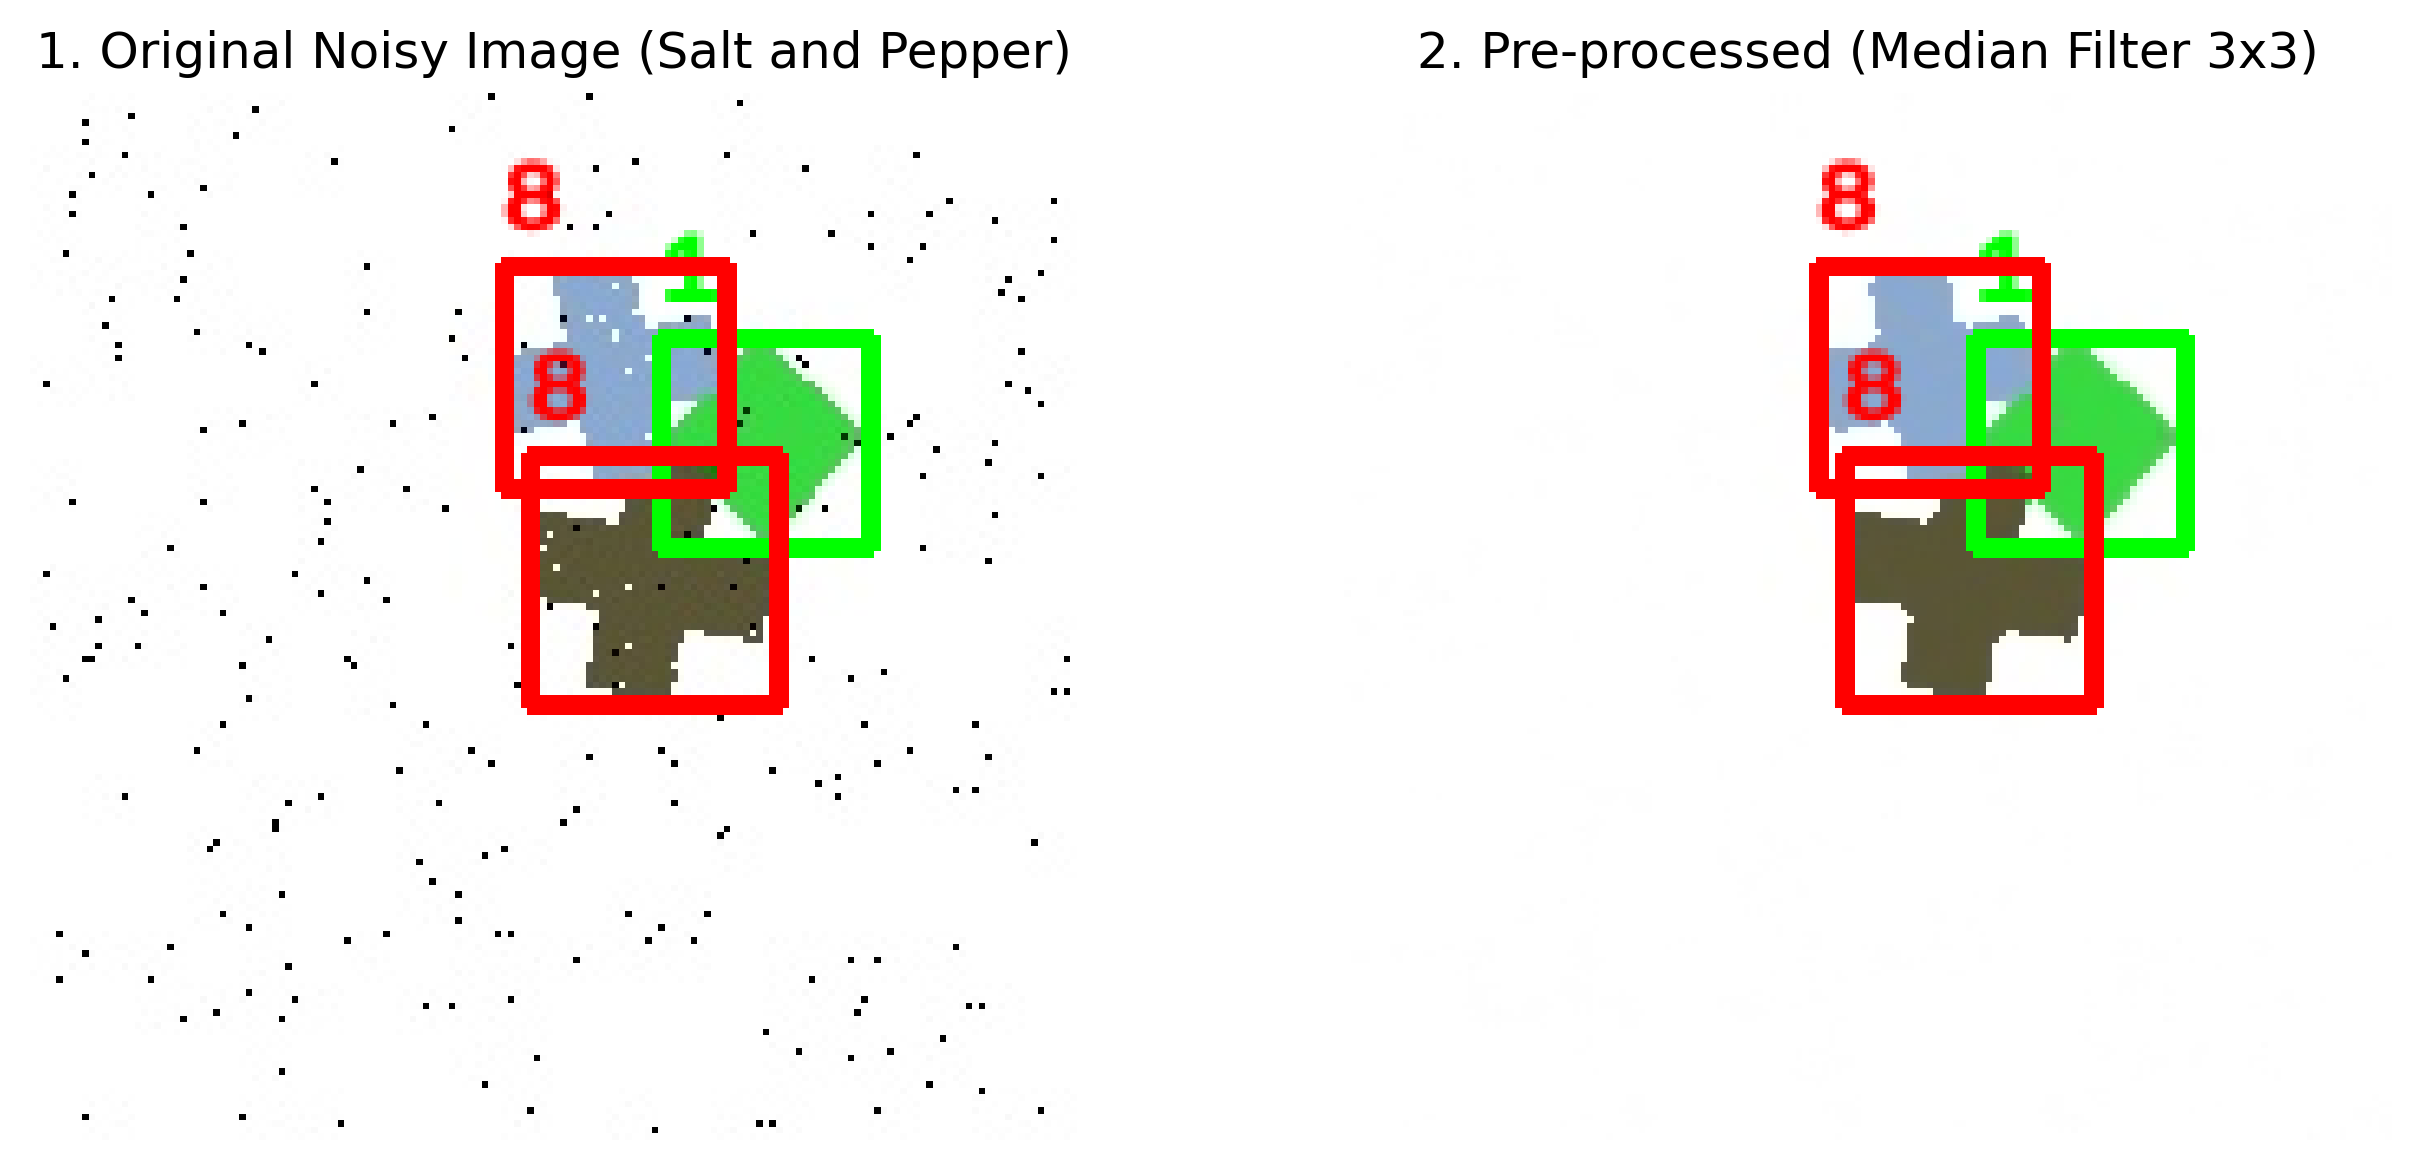

**Figure 9.31:** Comparison between the original image with salt-and-pepper noise and the image after applying the Median Filter (3x3). The *bounding boxes* in YOLO format remain unchanged.


In [37]:
# 1. Loading the first noisy sample from the dataset
caminho_img = f"{base_dir}/images/train/0000.jpg"
caminho_label = f"{base_dir}/labels/train/0000.txt"

img_ruidosa = mm.read(caminho_img)

# 2. Pre-processing with Median Filter (3x3 window)
img_filtrada = cv2.medianBlur(img_ruidosa, ksize=3)

# 3. Overlaying bounding boxes with mm.showBoundBox
img_ruid_anotada = mm.showBoundBox(img_ruidosa, filename=caminho_label, fmt="yolo", show=False)
img_filt_anotada = mm.showBoundBox(img_filtrada, filename=caminho_label, fmt="yolo", show=False)

# 4. Comparative display with mm.show
mm.show(
    [img_ruid_anotada, img_filt_anotada],
    titles=[
        "1. Original Noisy Image (Salt and Pepper)",
        "2. Pre-processed (Median Filter 3x3)"
    ],
    cols=2,
    figsize=(9, 4)
)

##### Block 4: Dataset Preprocessing and Fine-Tuning of YOLOv8

This block applies the Median Filter to the image set and performs fine-tuning of the pre-trained **YOLOv8n** detector on the **COCO** dataset. Filtering reduces the effect of impulsive noise introduced during image generation, while training adapts the network parameters to the new domain of geometric shapes.

1. **Batch filtering:** The code iterates through the `train` and `val` directories and applies `cv2.medianBlur` with a $3 \times 3$ window to all images, preserving the original YOLO annotations.

2. **Detector fine-tuning:** The network `YOLO("yolov8n.pt")`, initially trained on COCO, is adapted to the geometric dataset using the `.train()` function. The training uses images with a resolution of $320 \times 320$ pixels for $30$ epochs.

3. **Model evaluation:** The `.val()` function computes detection metrics on the validation set, including **precision**, **recall**, and **mAP50** (*mean Average Precision* with an IoU threshold equal to $0.5$).

In [38]:
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

base_dir = "shapes_dataset"
base_dir_filt = "shapes_dataset_filtrado"

# 1. Creates a FILTERED copy of the dataset in a separate folder
#    (the original dataset in base_dir remains noisy, intact)
for split in ["train", "val"]:
    pasta_imgs_orig = f"{base_dir}/images/{split}"
    pasta_labels_orig = f"{base_dir}/labels/{split}"
    pasta_imgs_filt = f"{base_dir_filt}/images/{split}"
    pasta_labels_filt = f"{base_dir_filt}/labels/{split}"

    os.makedirs(pasta_imgs_filt, exist_ok=True)
    os.makedirs(pasta_labels_filt, exist_ok=True)

    for nome_arq in os.listdir(pasta_imgs_orig):
        if nome_arq.endswith(".jpg"):
            img_ruidosa = cv2.imread(f"{pasta_imgs_orig}/{nome_arq}")
            img_filtrada = cv2.medianBlur(img_ruidosa, ksize=3)
            # writes the filtered version to the NEW folder, does not overwrite the original
            cv2.imwrite(f"{pasta_imgs_filt}/{nome_arq}", img_filtrada)

    # copies the labels (they do not change with the filter)
    for nome_arq in os.listdir(pasta_labels_orig):
        shutil.copy(f"{pasta_labels_orig}/{nome_arq}", f"{pasta_labels_filt}/{nome_arq}")

# 2. data.yaml pointing to the FILTERED dataset
with open(f"{base_dir_filt}/data.yaml", "w") as f:
    f.write(
        f"path: {os.path.abspath(base_dir_filt)}\n"
        "train: images/train\nval: images/val\nnames:\n"
    )
    for i, nome in enumerate(CLASSES):
        f.write(f"  {i}: {nome}\n")

print("Pre-processing completed: filtered dataset saved in a separate folder.\n")

# Download pre-trained YOLOv8 model (yolov8n.pt) if not already present
with contextlib.redirect_stdout(io.StringIO()), \
    contextlib.redirect_stderr(io.StringIO()):
    modelo_yolo = YOLO("yolov8n.pt")
print("YOLOv8 model loaded.")

Pre-processing completed: filtered dataset saved in a separate folder.

YOLOv8 model loaded.


In [39]:
# 3. Custom callback to print only the epoch currently running
def on_train_epoch_start(trainer):
    epoch_atual = trainer.epoch + 1
    total_epochs = trainer.epochs
    # Writes directly to the original stdout (bypassing the silencer)
    sys.__stdout__.write(f"🔄 Processando Época {epoch_atual}/{total_epochs}...\n")
    sys.__stdout__.flush()

# Adds the callback to the model
modelo_yolo.add_callback("on_train_epoch_start", on_train_epoch_start)

# 4. Context manager to silence the Ultralytics garbage (C/C++ and Python)
@contextlib.contextmanager
def silenciar_logs():
    logger = logging.getLogger("ultralytics")
    disabled_state = logger.disabled
    logger.disabled = True
    
    with open(os.devnull, "w") as fnull:
        old_stdout_fd = os.dup(1)
        old_stderr_fd = os.dup(2)
        try:
            os.dup2(fnull.fileno(), 1)
            os.dup2(fnull.fileno(), 2)
            with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
                yield
        finally:
            os.dup2(old_stdout_fd, 1)
            os.dup2(old_stderr_fd, 2)
            os.close(old_stdout_fd)
            os.close(old_stderr_fd)
            logger.disabled = disabled_state

# Training Execution
print("--- Starting YOLOv8 Training ---")
with silenciar_logs():
    resultados_treino = modelo_yolo.train(
        data=f"{base_dir_filt}/data.yaml",   # <-- trains on the filtered dataset
        epochs=30,
        imgsz=320,
        batch=16,
        device=device,
        verbose=False,
        plots=False
    )
    metricas = modelo_yolo.val(verbose=False)

# 5. Final Metrics
precision = metricas.results_dict["metrics/precision(B)"]
recall = metricas.results_dict["metrics/recall(B)"]
map50 = metricas.results_dict["metrics/mAP50(B)"]

print("\n--- Optimized YOLOv8 Model Performance ---")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"mAP at 50% (IoU 0.50): {map50*100:.2f}%")

--- Starting YOLOv8 Training ---



--- Optimized YOLOv8 Model Performance ---
Precision: 75.33%
Recall: 86.28%
mAP at 50% (IoU 0.50): 88.26%


##### Block 5: Inference Comparison: Noisy Image and Restored Image

After fine-tuning YOLOv8 on the restored dataset, a visual comparison is performed between detection applied directly to an image degraded by salt-and-pepper noise and the same image after the Median Filter.

The goal is to observe how a simple preprocessing step can influence the quality of predictions from a detector already adapted to the new domain.

1. **Inference with YOLO:** The `modelo_yolo.predict()` function performs detection on both versions of the image, using a confidence threshold of $25\%$ (`conf=0.25`).

2. **Visualization of Predictions:** The `plot()` function generates the images annotated with the bounding boxes and labels predicted by the model. [Figure 9.32](#fig-09-yolo-inferencia-comparativa) presents the comparison between the two scenarios.

In [40]:
# 1. Loading a original test sample (without the filter saved in batch)
caminho_teste = f"{base_dir}/images/val/0002.jpg"
img_ruidosa_teste = mm.read(caminho_teste)

# 2. Punctual application of the Median Filter (3x3) for comparison
img_filtrada_teste = cv2.medianBlur(img_ruidosa_teste, ksize=3)

# 3. Inference with the trained YOLOv8 model
pred_ruidosa = modelo_yolo.predict(img_ruidosa_teste, conf=0.25, verbose=False)[0]
pred_filtrada = modelo_yolo.predict(img_filtrada_teste, conf=0.25, verbose=False)[0]

# 4. Extraction of the annotated matrices by the YOLO generator (BGR -> RGB conversion)
img_pred_ruid = cv2.cvtColor(pred_ruidosa.plot(), cv2.COLOR_BGR2RGB)
img_pred_filt = cv2.cvtColor(pred_filtrada.plot(), cv2.COLOR_BGR2RGB)

# 5. Standardized comparative display via mm.show
mm.show(
    [img_pred_ruid, img_pred_filt],
    titles=[
        f"Inference on the Noisy Image ({len(pred_ruidosa.boxes)} objects)",
        f"Inference on the Filtered Image ({len(pred_filtrada.boxes)} objects)"
    ],
    cols=2,
    figsize=(10, 4)
)

**Figure 9.32:** Comparison of YOLOv8 inference fine-tuned by transfer learning on a salt-and-pepper noisy image and on the version restored by the Median Filter. The predicted bounding boxes and classes are displayed on each image.


In [41]:
# Explicit cleaning of downloaded data and memory release
if FLAG_LIMPAR_DADOS:
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
        print('🧹 Diretório de dados temporários {} removido com sucesso.'.format(base_dir))

    if os.path.exists(base_dir_filt):
        shutil.rmtree(base_dir_filt)
        print('🧹 Diretório de dados temporários {} removido com sucesso.'.format(base_dir_filt))

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

> ### 📝 Nota
>
> ###### 🧠 A domain far more distant than that of digits
>
> In the transfer learning experiment between handwritten digits (domains A and B), the source and target tasks shared very similar visual statistics: both were grayscale strokes on a uniform background. Here, the distance between domains is considerably greater — YOLO was pretrained on **natural color photographs** from COCO (people, animals, vehicles, everyday objects), and the target task consists of **synthetic geometric shapes, with solid colors and well-defined contours**, lacking texture, lighting, or complex backgrounds.
>
> Even so, transfer learning remains advantageous: the early layers of a detector trained on COCO learn generic filters — edge, corner, and contrast-region detectors — that remain useful for delimiting the contour of a triangle or a star, even though the final visual content is quite distinct. This is why allowing fine-tuning of all layers, combined with consistent preprocessing between training and inference to mitigate salt-and-pepper noise, enables high accuracy rates in detecting objects from the new domain.

##### Using a Real Dataset

The *pipeline* above was built entirely around the **YOLO annotation format** (class, $x_{centro}$, $y_{centro}$, width, height, normalized by the image's width and height) precisely so that it can be reused without modifications if the reader has access to a set of real images annotated in the same way — for example, a set of images of photographed or rendered geometric objects, each with a corresponding `.txt` file in the same format used here. To do so, one would only need to:

1. Organize the real images in `shapes_dataset/images/train` and `shapes_dataset/images/val`, and the corresponding annotation `.txt` files in the `labels/train` and `labels/val` folders (one annotation file per image, same base name, `.txt` extension);
2. Adjust the `data.yaml` file if the number or names of the classes differ;
3. Run the same training, fine-tuning, and visualization cells already presented, without any other code modifications.

This separation between **data generation/organization** and **model training** is, in practice, the reason why standardized annotation formats (such as YOLO's) are so widely adopted: they allow swapping the input dataset — synthetic for real, one domain for another — while keeping all the rest of the transfer learning *pipeline* unchanged.

### 9.5.3 Object Segmentation

The same transfer learning principle also underpins image segmentation architectures, in which a pretrained feature extractor provides general visual representations, while a specialized head performs dense, pixel-wise classification.

The following sections present **DeepLabV3** as an example of a pretrained segmenter used directly for inference, and then the **U-Net** architecture, trained from scratch and compared with a classic morphological baseline.

#### 9.5.3.1 DeepLabV3: Pre-trained Segmenter

In semantic segmentation, the objective is not limited to locating objects through bounding boxes. The network assigns a class to each pixel of the image, producing a label map with the same resolution as the input. Architectures such as **DeepLabV3**, with a **ResNet-50** backbone, utilize a pre-trained feature extractor and a specialized head to perform this dense classification.

1. **Loading and inference:** The model `deeplabv3_resnet50(weights="DEFAULT")` loads pre-trained weights on the **Pascal VOC** dataset, which defines $21$ segmentation classes. The code converts the image into a tensor, adds the batch dimension (`unsqueeze(0)`), and performs inference.

2. **Class map:** The model's output has dimensions $(1, 21, H, W)$, containing a value for each class at every pixel. The operation `.argmax(dim=1)` selects the class with the highest response at each position, generating a two-dimensional label matrix with dimensions $(H, W)$.

3. **Visualization:** The code converts the label map into the format expected by `mm.show()`, which displays the segmentation result in [Figure 9.33](#fig-09-segmentacao-pretreinada).

In [42]:
# | fig-cap: "Semantic segmentation map generated by the pre-trained DeepLabV3 model: pixel-by-pixel classification represented in a 2D matrix displayed."
# | eval: false
# | echo: true
# | output: true

# 1. Image loading (returns numpy.ndarray)
url_imagem = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
url_imagem = "http://images.cocodataset.org/val2017/000000039769.jpg"
img = mm.read(url_imagem)

# 2. Loading the pre-trained DeepLabV3 model in evaluation mode
modelo_segmentacao = deeplabv3_resnet50(weights="DEFAULT").eval()

# 3. Running inference without gradient computation
with torch.no_grad():
    tensor_entrada = to_tensor(img).unsqueeze(0)  # Format (1, C, H, W)
    saida = modelo_segmentacao(tensor_entrada)["out"]
    
    # Selecting the class with the highest probability per pixel (argmax along the channel axis)
    mapa_classes = saida.argmax(dim=1).squeeze(0).byte().cpu().numpy()

# 4. Displaying the semantic segmentation map
mm.show(
    [img,mapa_classes],
    title=["Original image","Semantic Segmentation (DeepLabV3)"]
)

**Figure 9.33**


#### 9.5.3.2 Semantic Segmentation with U-Net Architecture

The previous subsection presented a pretrained model (*DeepLabV3*) that directly produces a class label per *pixel*. This section completes the sequence of practical projects—classification and detection—by addressing semantic segmentation implemented and trained from scratch with the **U-Net**, the reference architecture introduced by Ronneberger (2015).

In classification, the final feature map was flattened into a vector, discarding spatial information in favor of a single label per image. The U-Net, in turn, produces an output with the **same spatial resolution as the input**: a two-dimensional map in which each *pixel* receives its own classification. This requirement—preserving high-resolution spatial detail while building semantic context in deep layers—motivates the encoder-decoder architecture with shortcut connections (*skip connections*).

The scenario used simulates the segmentation of nodules in synthetic medical exams: grayscale images contain a circular region ("nodule") overlaid on a background, both contaminated by Gaussian noise and with very similar intensity means—an intentional low-contrast challenge, ideal for demonstrating the benefit of spatial learning compared to pointwise thresholding.

##### Block 1: Synthetic Nodule Set Generator and Initial Display

The following generator produces (image, mask) pairs: the image contains a circular region of intensity slightly higher than that of the background, both affected by the same standard deviation of Gaussian noise. The binary mask precisely delimits the nodule region and serves as the reference ground truth.

1. **Nodule Construction:** The function `gera_imagem_com_nodulo` overlays the nodule onto the background on a $64 \times 64$ matrix and applies Gaussian noise.
2. **Visualization with `mm.show`:** [Figure 9.34](#fig-09-unet-dataset) illustrates the first two samples and their respective masks.

Training set: 160 images | Validation set: 40 images



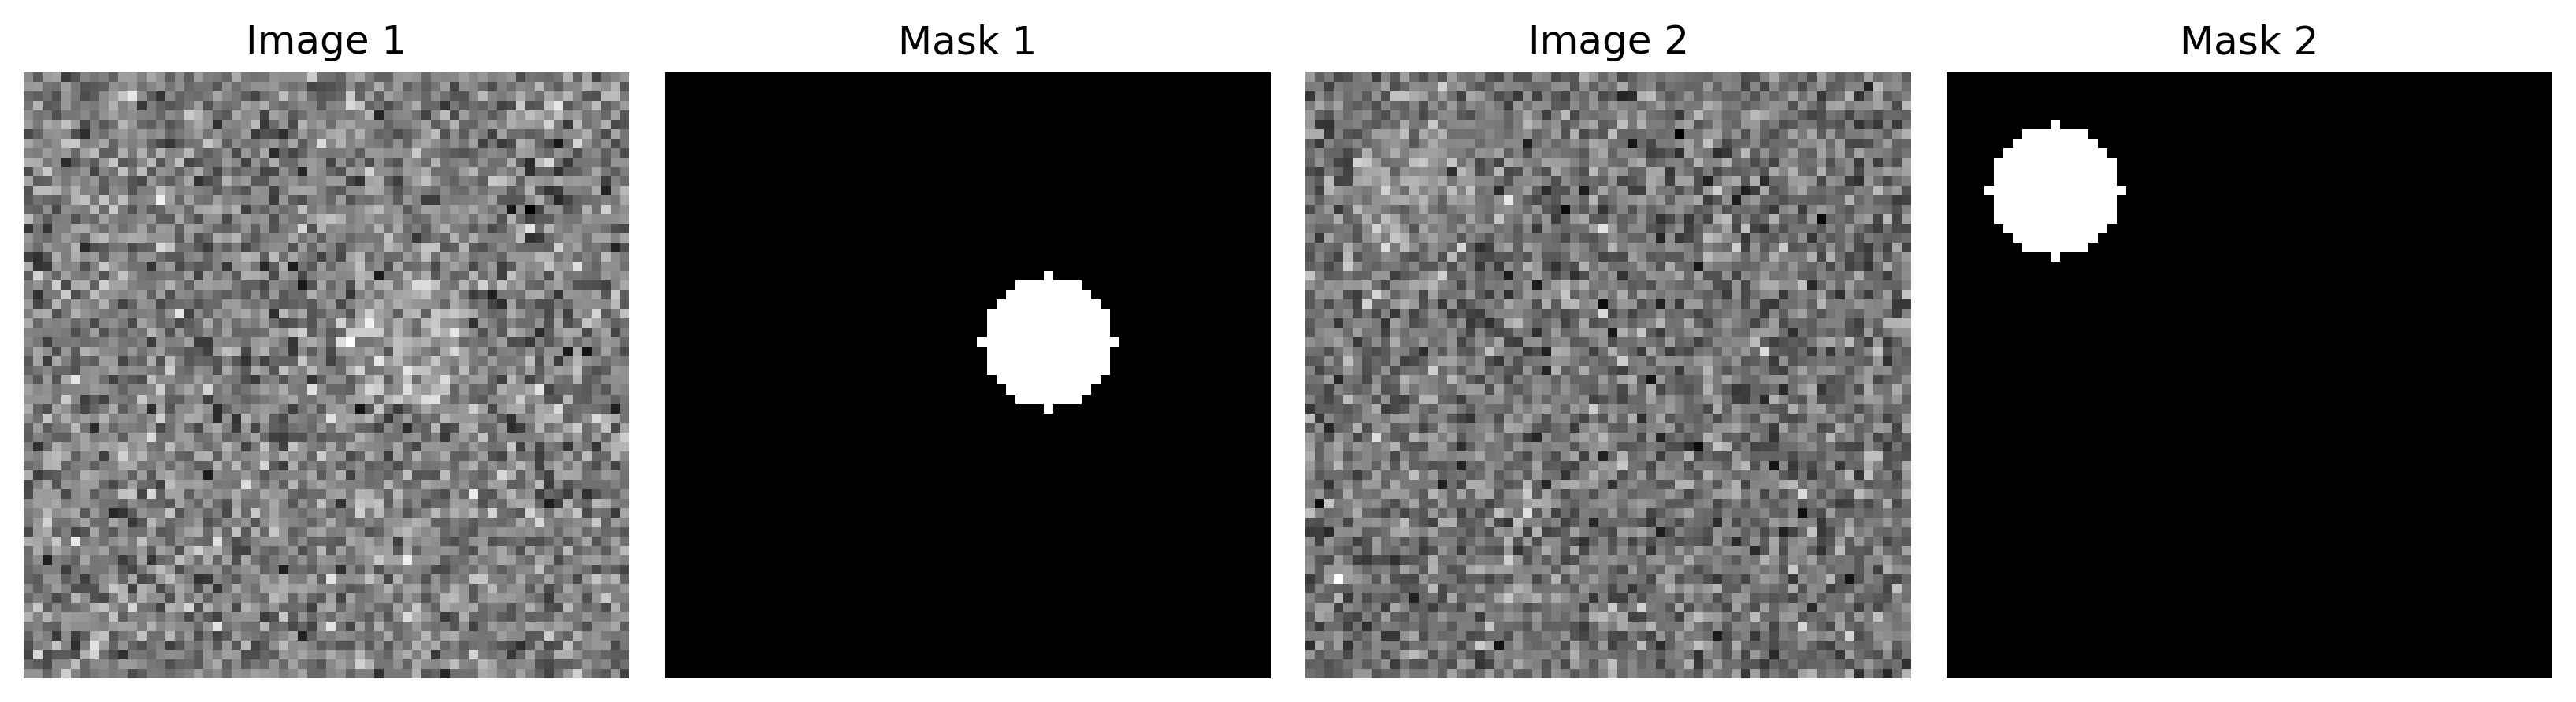

**Figure 9.34:** Samples from the synthetic nodule dataset: grayscale image under noise and its respective reference binary mask shown.


In [43]:
TAM_IMG = 64


def gera_imagem_com_nodulo(
    tam=TAM_IMG,
    raio_min=7,
    raio_max=15,
    media_fundo=95,
    media_nodulo=118,
    sigma_ruido=26,
    rng=None,
):
    rng = rng or np.random.default_rng()
    fundo = rng.normal(media_fundo, sigma_ruido, (tam, tam))
    nodulo = rng.normal(media_nodulo, sigma_ruido, (tam, tam))
    mascara = np.zeros((tam, tam), dtype=np.uint8)

    raio = int(rng.integers(raio_min, raio_max))
    cx = int(rng.integers(raio + 4, tam - raio - 4))
    cy = int(rng.integers(raio + 4, tam - raio - 4))

    cv2.circle(mascara, (cx, cy), raio, 255, -1)
    imagem = np.clip(np.where(mascara > 0, nodulo, fundo), 0, 255).astype(
        np.uint8
    )
    return imagem, mascara


# Generation of training and validation sets
rng_dados = np.random.default_rng(42)
N_TREINO, N_VAL = 160, 40

imgs_treino, masks_treino = zip(
    *[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_TREINO)]
)
imgs_val, masks_val = zip(
    *[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_VAL)]
)

print(
    f"Training set: {N_TREINO} images | Validation set: {N_VAL} images\n"
)

# Display of initial samples 
mm.show(
    [imgs_treino[0], masks_treino[0], imgs_treino[1], masks_treino[1]],
    titles=["Image 1", "Mask 1", "Image 2", "Mask 2"],
    cols=4,
    figsize=(11, 3),
)

##### Block 2: Classical Baseline (Filtering, Otsu, and Morphology)

Before employing the U-Net, the performance of a classical morphological *pipeline* built with the `morph` library is evaluated: a **Gaussian smoother** (`mm.blur`), an **Otsu thresholding** (`mm.threshold`), and a **morphological opening** (`mm.open`) to eliminate isolated noise.

1. **Intersection over Union (IoU) Metric:** The function `iou_mascaras` computes the degree of *pixel-by-pixel* overlap between the prediction and the ground truth mask.
2. **Execution and Comparison:** [Figure 9.35](#fig-09-unet-classico) displays the result of classical segmentation on a test image, demonstrating the limitations of the global threshold under low contrast.

Average IoU (classical baseline) on validation: 0.7516



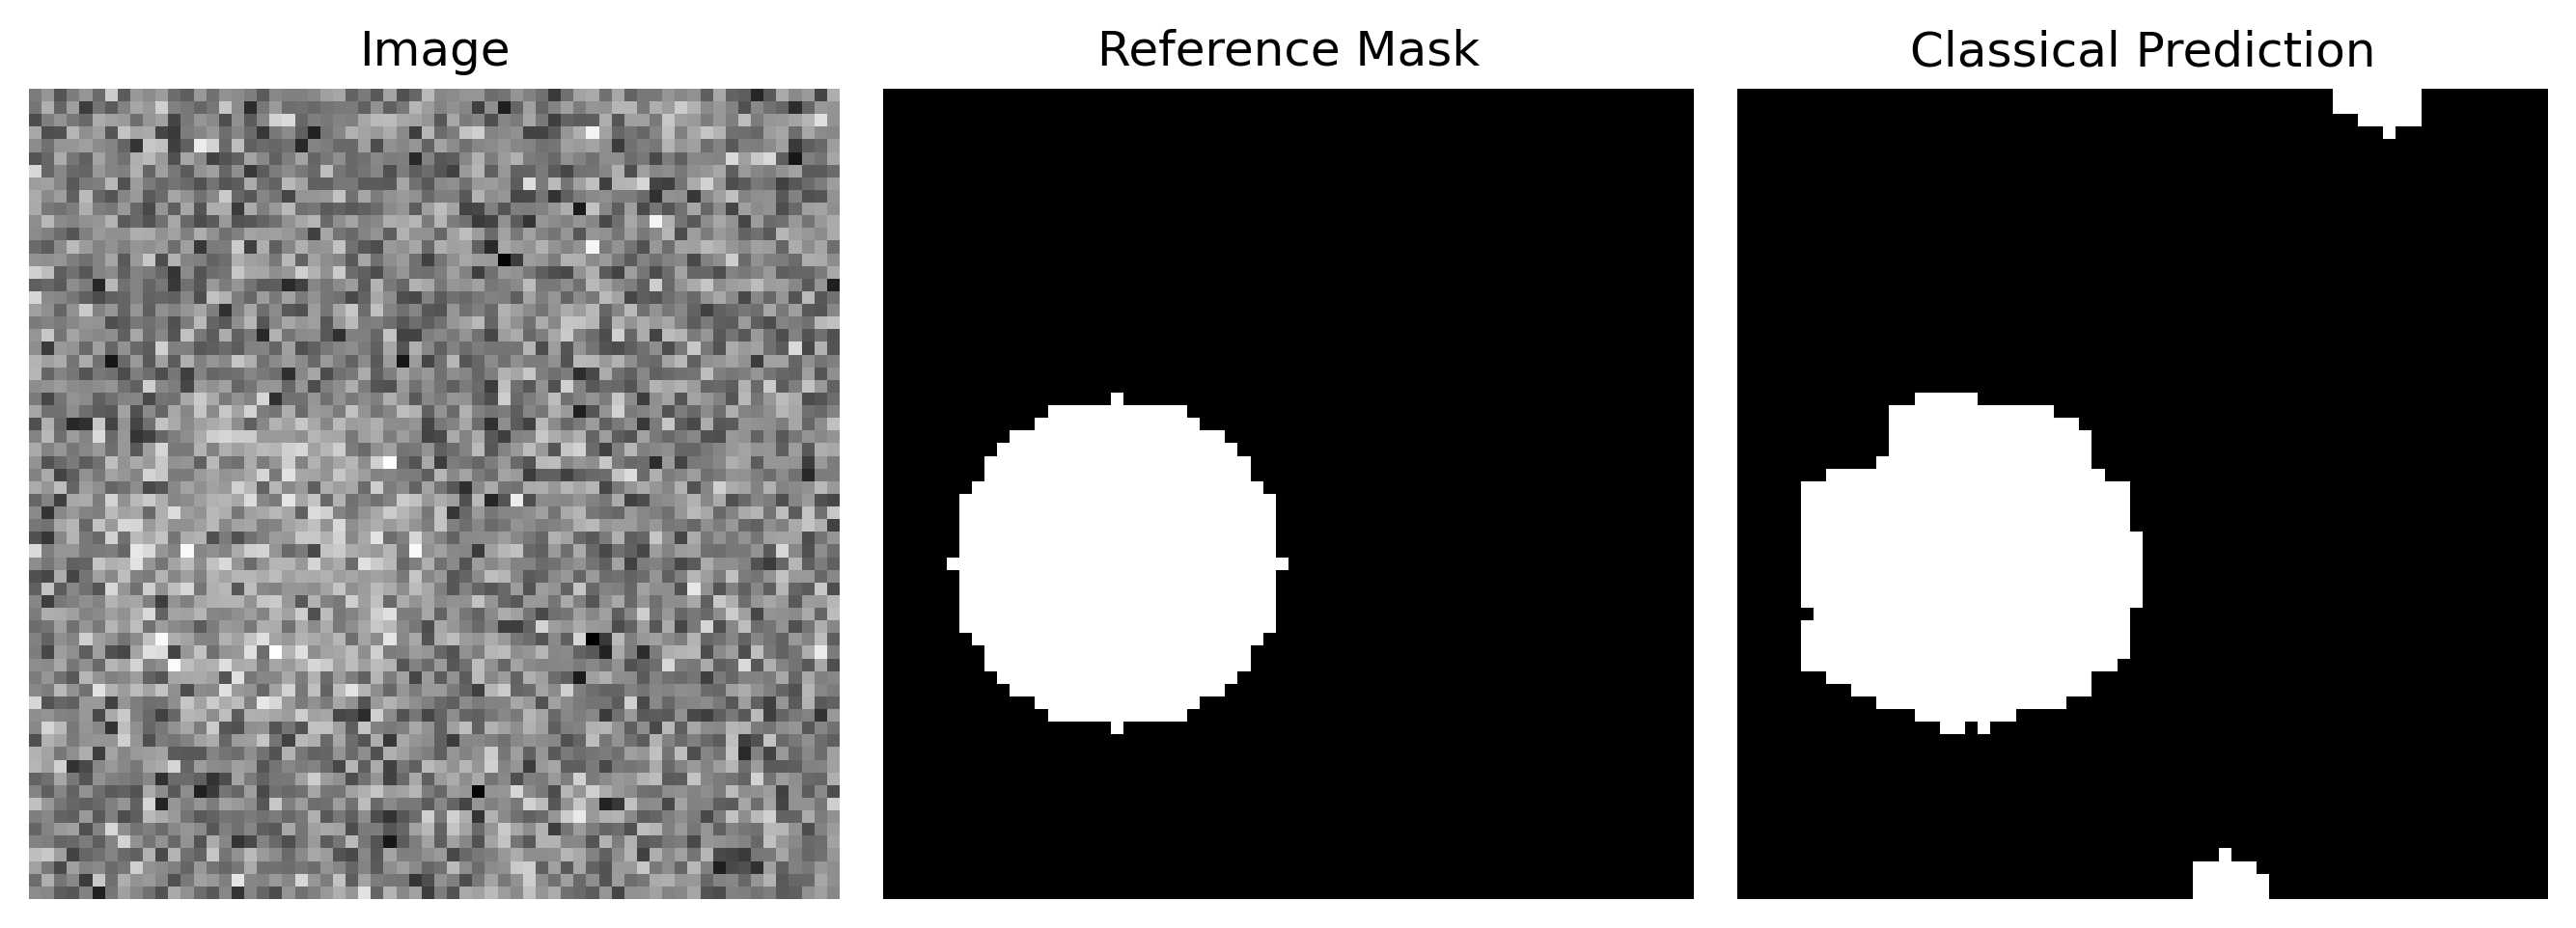

**Figure 9.35:** Classical segmentation baseline: smoothing, Otsu thresholding, and morphological opening displayed.


In [44]:
def iou_mascaras(predita, referencia):
    p, r = predita > 0, referencia > 0
    intersecao = np.logical_and(p, r).sum()
    uniao = np.logical_or(p, r).sum()
    return intersecao / uniao if uniao else 1.0


def segmenta_classico(imagem, elemento_estrutural):
    suavizada = mm.blur(imagem, 7)
    binaria = mm.threshold(suavizada)
    return mm.open(binaria, elemento_estrutural)


elemento_estrutural = mm.sedisk(5)
ious_classico = [
    iou_mascaras(segmenta_classico(img, elemento_estrutural), mask)
    for img, mask in zip(imgs_val, masks_val)
]
iou_classico_medio = float(np.mean(ious_classico))
print(
    f"Average IoU (classical baseline) on validation: {iou_classico_medio:.4f}\n"
)

predicao_classica_exemplo = segmenta_classico(imgs_val[0], elemento_estrutural)

mm.show(
    [imgs_val[0], masks_val[0], predicao_classica_exemplo],
    titles=["Image", "Reference Mask", "Classical Prediction"],
    cols=3,
    figsize=(9, 3.2),
)

##### Block 3: Construction of the U-Net Architecture and Loss Functions
 
The U-Net is a "U"-shaped architecture (hence the name), specifically designed for image segmentation. It consists of two pathways that work together:
 
- 🔽 **Encoder:** descends through the image, reducing spatial resolution at each step while extracting increasingly abstract features (edges → textures → shapes → context).
- 🔼 **Decoder:** ascends back, reconstructing the original resolution through transposed convolutions (*upsampling*), until it generates a mask of the same size as the input image.
 
The element that makes U-Net special is the **skip connections**: they carry feature maps from the encoder directly to the corresponding stage of the decoder, at the same resolution. This prevents fine details—such as contours and edges—from being lost during spatial compression.
 
**General architecture flow:**
 
```text
Input
  │
  ▼
Encoder (Conv → Conv → Pool) × 3
  │
  ├──── skip connections reinject high-resolution maps ────┐
  ▼                                                         │
Bottleneck                                                 │
  │                                                         │
  ▼                                                         │
Decoder (Upsample → Concat → Conv → Conv) × 3  ◄────────────┘
  │
  ▼
Output 1×1 (logits)
```
 
**Main components:**
 
1. **Base Convolutional Block (`BlocoConv`)**
   The fundamental unit repeated throughout the network. It applies two $3 \times 3$ convolutions in sequence, each followed by ReLU activation, with padding that preserves the spatial dimensions of the input. This block appears in both the encoder and the decoder.
 
2. **Transposed Convolution (`nn.ConvTranspose2d`)**
   This is the operation responsible for *upsampling* in the decoder: instead of reducing spatial resolution (as `MaxPool2d` does in the encoder), it increases it, learning the necessary weights to "undo" the compression and gradually recover the original image size.
 
3. **Combined Loss (BCE + Dice)**
   The `perda_segmentacao` function sums two complementary metrics:
   - **Binary Cross-Entropy (BCE):** evaluates pixel-by-pixel accuracy.
   - **Dice Coefficient:** evaluates the overall overlap between the predicted and ground-truth masks.
 
   Together, they balance local precision with fidelity of the segmented shape as a whole.

In [45]:
class BlocoConv(nn.Module):

    def __init__(self, canais_entrada, canais_saida):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Conv2d(canais_entrada, canais_saida, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(canais_saida, canais_saida, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.rede(x)


class UNetCompacta(nn.Module):

    def __init__(self, canais_entrada=1, base=8):
        super().__init__()
        self.enc1 = BlocoConv(canais_entrada, base)
        self.enc2 = BlocoConv(base, base * 2)
        self.enc3 = BlocoConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)

        self.fundo = BlocoConv(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(
            base * 8, base * 4, kernel_size=2, stride=2
        )
        self.dec3 = BlocoConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(
            base * 4, base * 2, kernel_size=2, stride=2
        )
        self.dec2 = BlocoConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(
            base * 2, base, kernel_size=2, stride=2
        )
        self.dec1 = BlocoConv(base * 2, base)

        self.saida = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        f = self.fundo(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(f), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.saida(d1)


def para_tensores(imagens, mascaras):
    X = (
        torch.tensor(np.stack(imagens), dtype=torch.float32).unsqueeze(1)
        / 255.0
    )
    Y = (
        torch.tensor(np.stack(mascaras), dtype=torch.float32).unsqueeze(1)
        / 255.0
    )
    return X, Y


def perda_dice(logits, alvo, eps=1e-6):
    probs = torch.sigmoid(logits)
    intersecao = (probs * alvo).sum(dim=(1, 2, 3))
    uniao = probs.sum(dim=(1, 2, 3)) + alvo.sum(dim=(1, 2, 3))
    dice = (2 * intersecao + eps) / (uniao + eps)
    return 1 - dice.mean()


def perda_segmentacao(logits, alvo):
    return nn.functional.binary_cross_entropy_with_logits(
        logits, alvo
    ) + perda_dice(logits, alvo)

##### Block 4: U-Net Training and Performance Evaluation

Training is run for $35$ epochs using the *Adam* optimizer. At each epoch, the Training Loss and the mean IoU index on the validation set are monitored.

1. **Training Loop:** Parameters are updated with *mini-batches* of $16$ samples.
2. **Graphical Evolution:** [Figure 9.36](#fig-09-unet-treinamento) displays the graph with the progress of loss and IoU.

Trainable U-Net parameters: 120681
1 / 35


6 / 35


11 / 35


16 / 35


21 / 35


26 / 35


31 / 35


Final average IoU of U-Net on validation: 0.8876


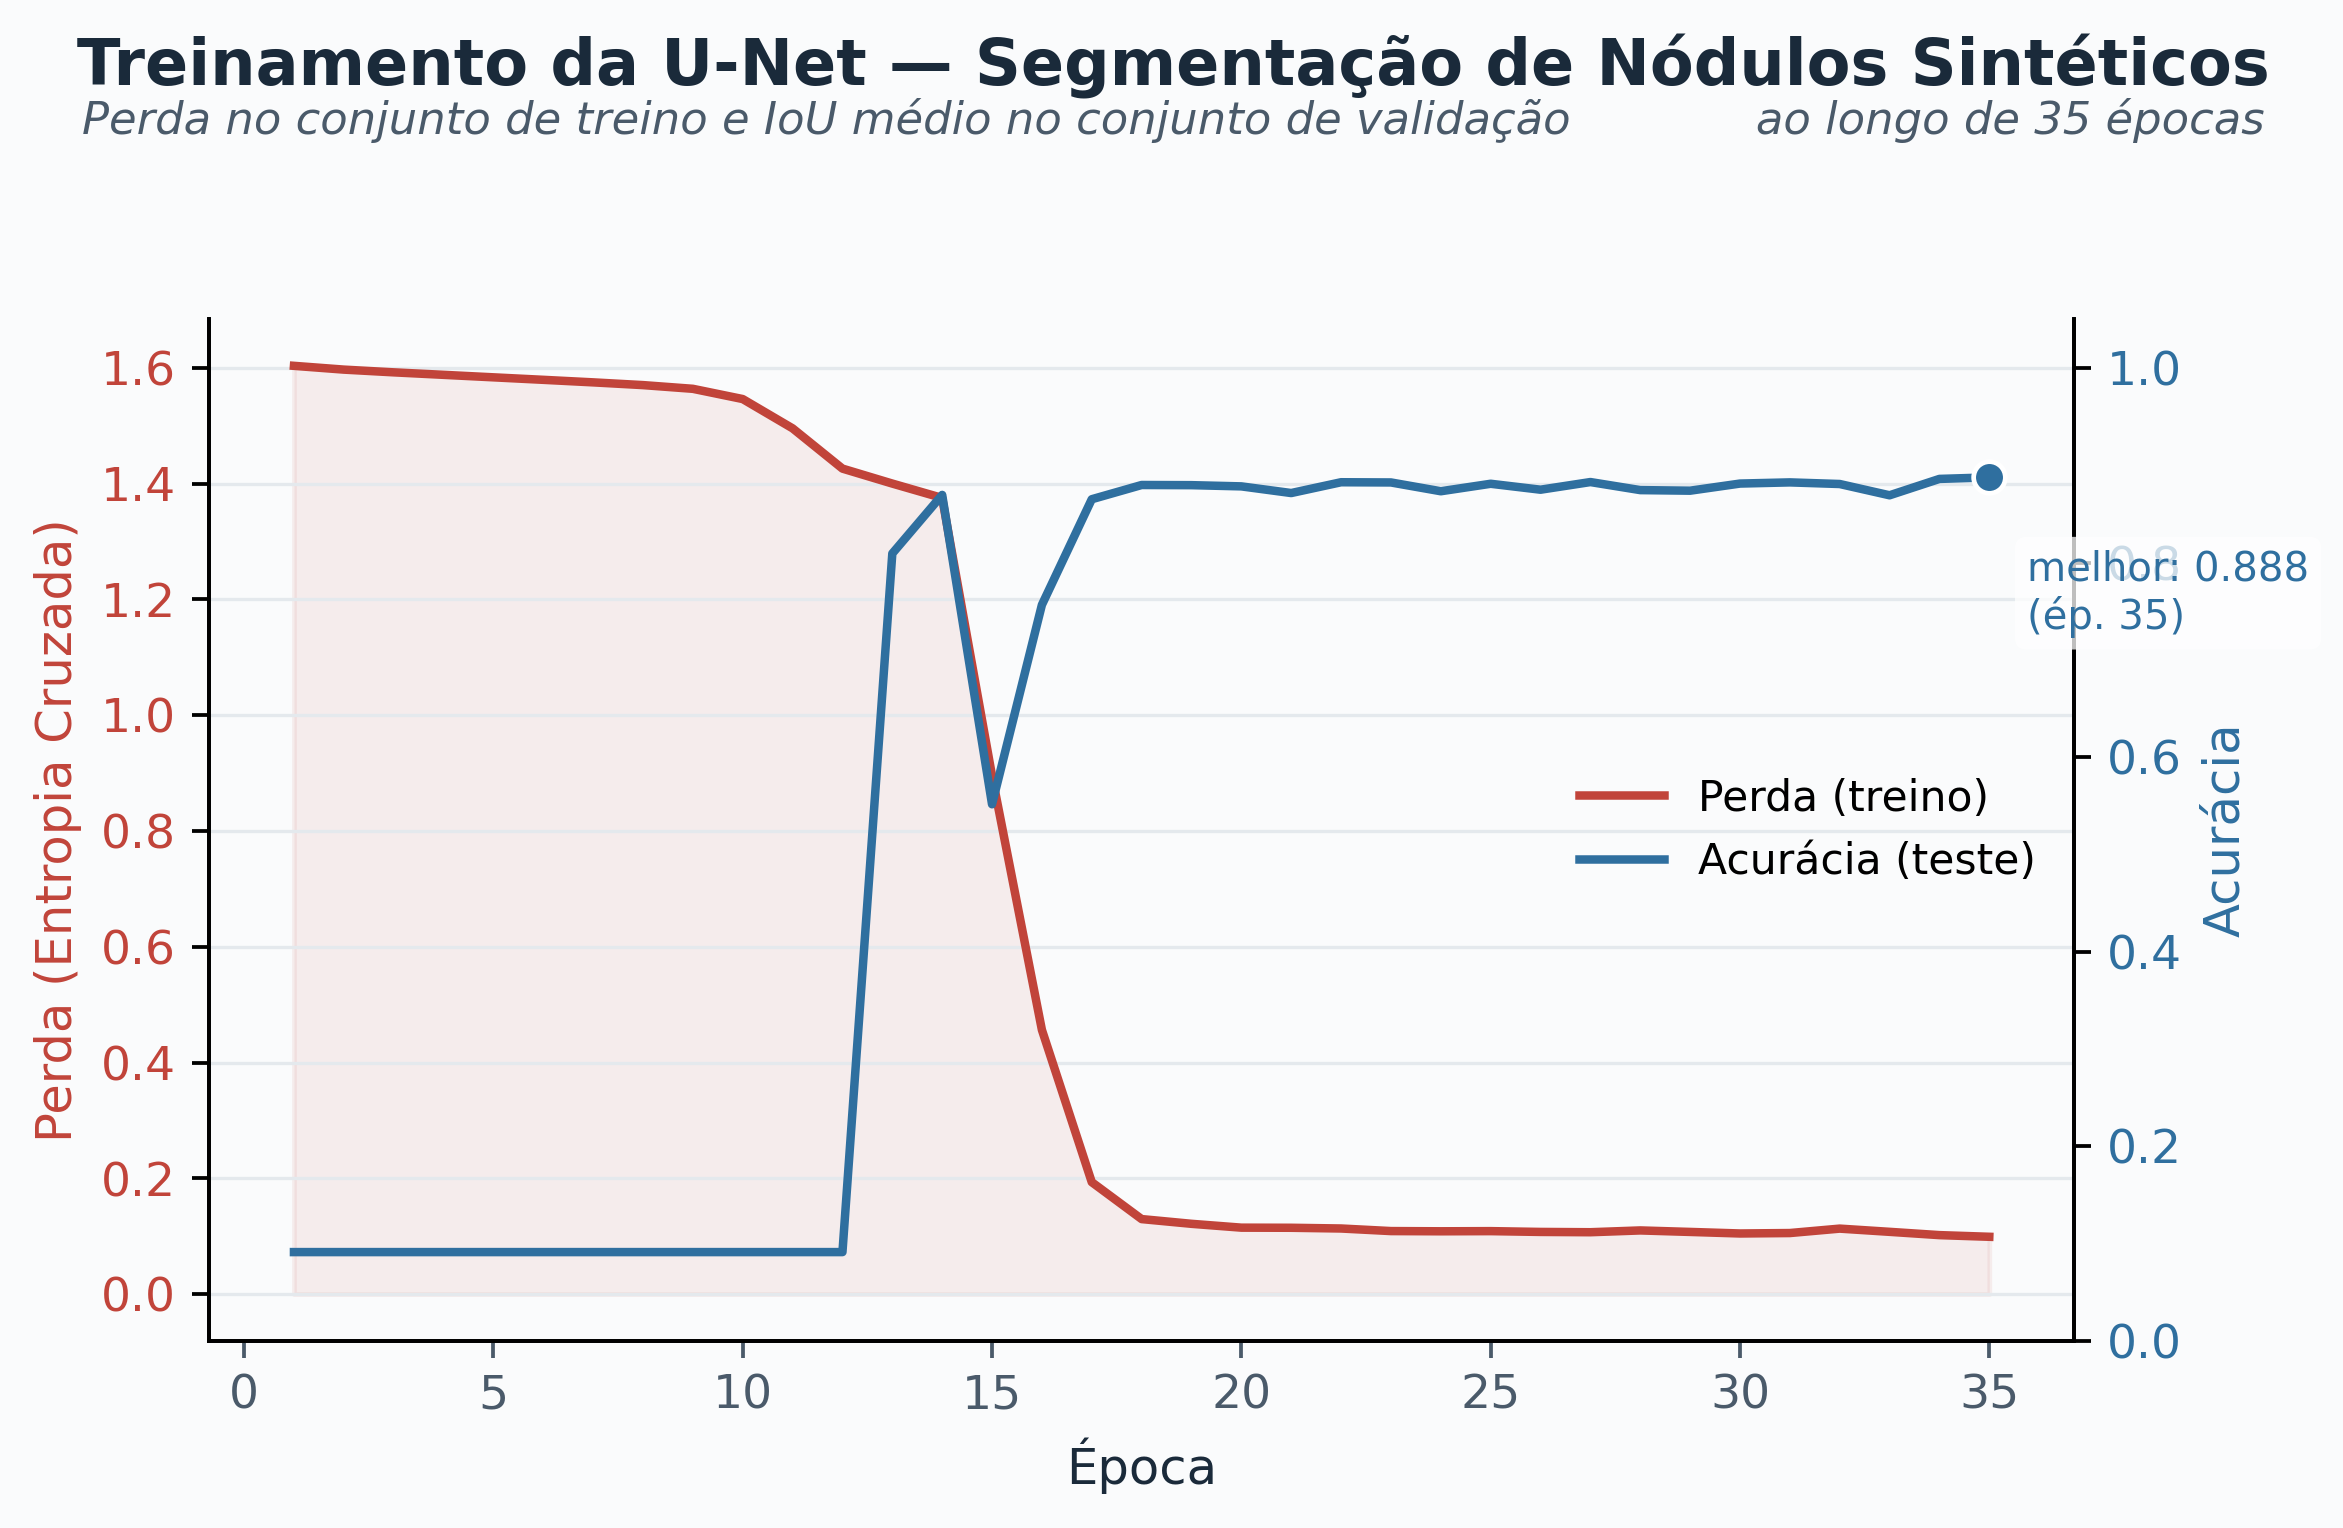

**Figure 9.36:** Evolution of compact U-Net training: loss reduction and increase in the average IoU index on the validation set over 35 epochs.


In [46]:
modelo_unet = UNetCompacta()
print(
    f"Trainable U-Net parameters: {sum(p.numel() for p in modelo_unet.parameters())}"
)

X_treino_unet, Y_treino_unet = para_tensores(imgs_treino, masks_treino)
X_val_unet, Y_val_unet = para_tensores(imgs_val, masks_val)

otimizador_unet = optim.Adam(modelo_unet.parameters(), lr=1e-3)
n = X_treino_unet.size(0)
tam_lote = 16
epocas_unet = 35
historico_perda_unet, historico_iou_unet = [], []

for epoca in range(epocas_unet):
    if epoca % 5 == 0:  # Prints every 5 epochs
        print(epoca + 1, "/", epocas_unet)
    modelo_unet.train()
    perm = torch.randperm(n)
    perda_epoca = 0.0

    for i in range(0, n, tam_lote):
        idx = perm[i : i + tam_lote]
        otimizador_unet.zero_grad()
        logits = modelo_unet(X_treino_unet[idx])
        perda = perda_segmentacao(logits, Y_treino_unet[idx])
        perda.backward()
        otimizador_unet.step()
        perda_epoca += perda.item() * len(idx)

    modelo_unet.eval()
    with torch.no_grad():
        predicao_val = (torch.sigmoid(modelo_unet(X_val_unet)) > 0.5).float()
        intersecao = (predicao_val * Y_val_unet).sum(dim=(1, 2, 3))
        uniao = ((predicao_val + Y_val_unet) > 0).float().sum(dim=(1, 2, 3))
        iou_epoca = (intersecao / uniao.clamp(min=1e-6)).mean().item()

    historico_perda_unet.append(perda_epoca / n)
    historico_iou_unet.append(iou_epoca)

iou_unet_final = historico_iou_unet[-1]
print(f"Final average IoU of U-Net on validation: {iou_unet_final:.4f}")

# Training evolution chart
r = mm.showTrainCurves(historico_perda_unet, historico_iou_unet,
        titulo="Treinamento da U-Net — Segmentação de Nódulos Sintéticos",
        subtitulo="Perda no conjunto de treino e IoU médio no conjunto de validação \
            ao longo de 35 épocas")

##### Block 5: Quantitative and Qualitative Comparison (Classic vs. U-Net)

The comparison between the classic approach and the U-Net highlights the superiority of representation learning in low-contrast scenarios.

1. **Metrics Panel:** The bar chart in [Figure 9.37](#fig-09-unet-comparativo) contrasts the mean IoU of both methods on validation.
2. **Qualitative Visualization:** The visual comparison across three samples demonstrates how skip connections recover the nodule contour even under pronounced noise.

Mean IoU (classical Smoothing + Otsu): 0.7516
Mean IoU (U-Net): 0.8876


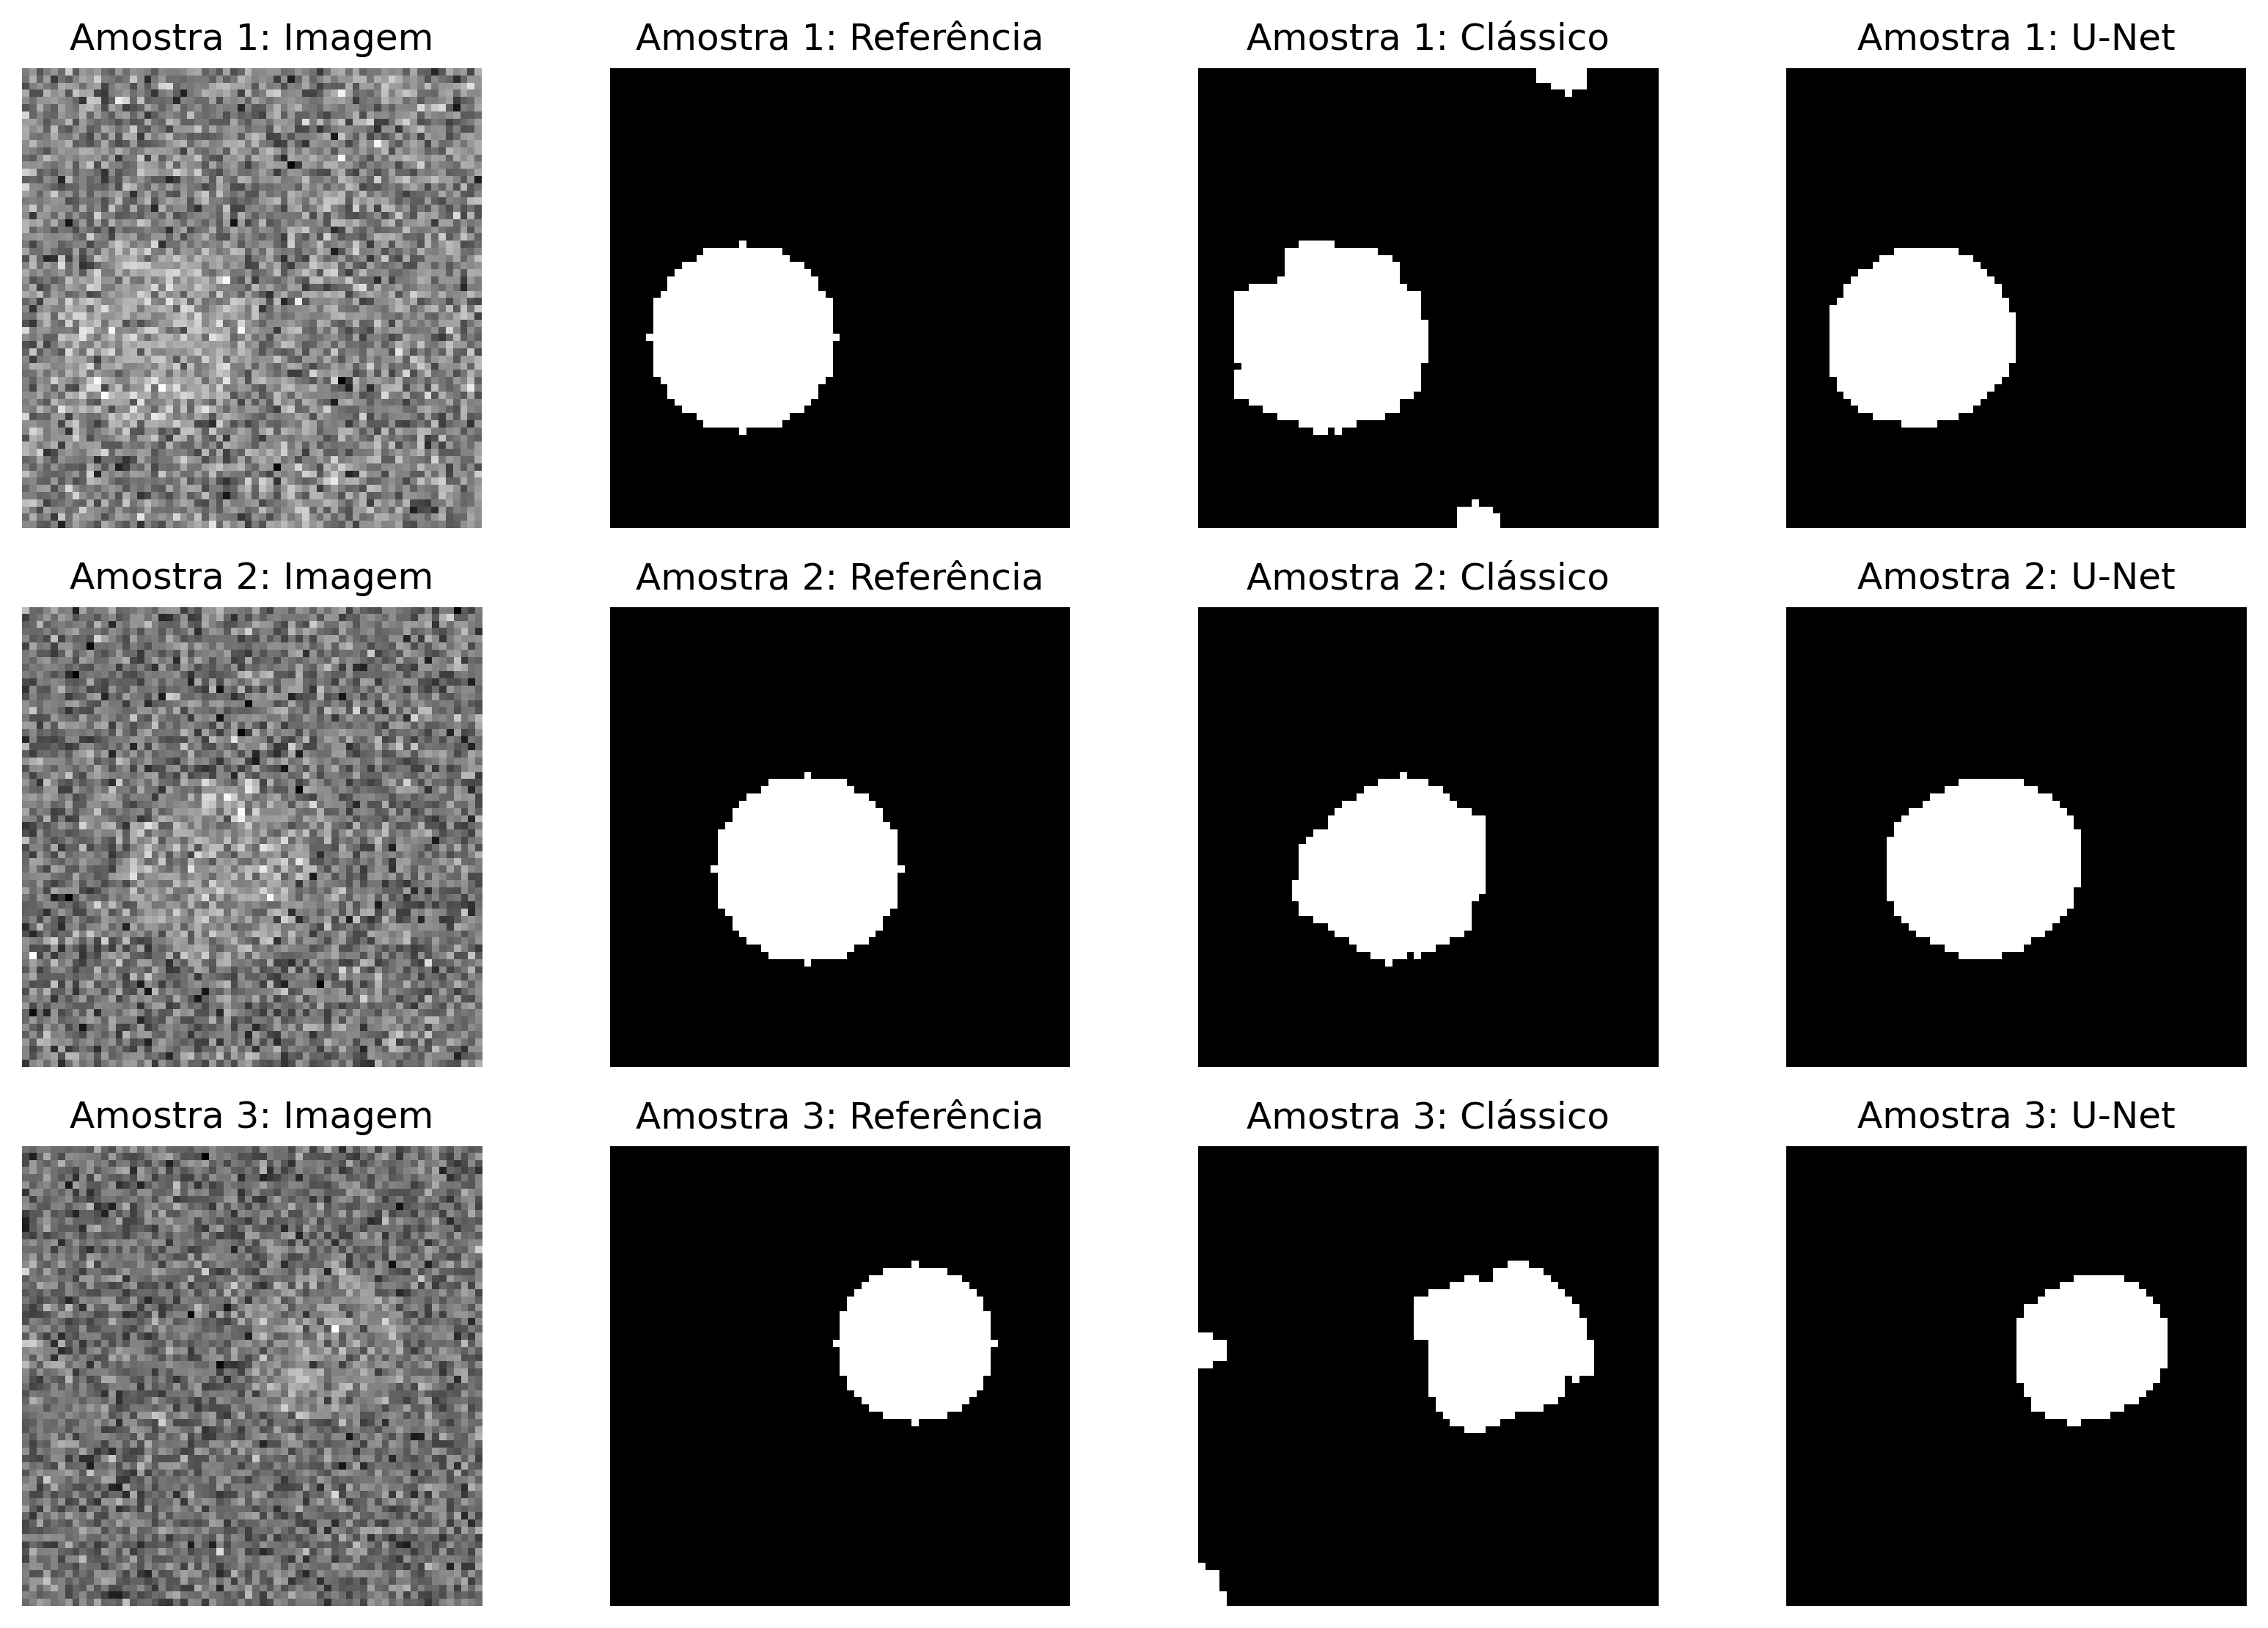

**Figure 9.37:** Quantitative comparison (mean IoU) and qualitative comparison between the classical approach and the U-Net trained on three validation samples.


In [47]:
# 1. Comparison 
print(f"Mean IoU (classical Smoothing + Otsu): {iou_classico_medio:.4f}")
print(f"Mean IoU (U-Net): {iou_unet_final:.4f}")

# 2. Qualitative side-by-side display in 3 samples via mm.show
imgs_comparativas = []
titulos_comparativos = []

for i in range(3):
    with torch.no_grad():
        pred_unet = (
            (torch.sigmoid(modelo_unet(X_val_unet[i : i + 1])) > 0.5)
            .float()
            .squeeze()
            .numpy()
            * 255
        )

    pred_classico = segmenta_classico(imgs_val[i], elemento_estrutural)

    imgs_comparativas.extend(
        [imgs_val[i], masks_val[i], pred_classico, pred_unet.astype(np.uint8)]
    )

    t_prefix = f"Amostra {i+1}"
    titulos_comparativos.extend(
        [
            f"{t_prefix}: Imagem",
            f"{t_prefix}: Referência",
            f"{t_prefix}: Clássico",
            f"{t_prefix}: U-Net",
        ]
    )

mm.show(
    imgs_comparativas,
    titles=titulos_comparativos,
    cols=4,
    figsize=(11, 7.5),
)

> ### 📝 Nota
>
> ###### 🧠 Why Does U-Net Outperform Fixed Thresholding?
>
> Otsu thresholding applies a global cutoff value to local intensity. When the mean difference between the nodule and the background is small relative to Gaussian noise, this rule makes systematic errors at the edges.
>
> U-Net overcomes this limitation by combining the broad semantic context extracted by the encoder with the fine spatial details preserved by the skip connections. This enables the identification of the nodule's presence and the precise delineation of its contours, even under intense noise.

### 9.5.4 Data Engineering for CV (*Roboflow*)

A U-Net can be trained from images annotated on data engineering platforms for Computer Vision (CV), such as *Roboflow*. These platforms allow you to organize datasets, perform annotations, apply preprocessing steps and *data augmentation*, train models, and export data in various formats. In this section, however, the example revisits **geometric object detection**, using datasets already presented in this book.

> ### ❗ Dependency on Internet connection and API key
>
> The cells in this section require an Internet connection and a free *Roboflow* API key (`app.roboflow.com`). In the project's *Workspace*, access **⚙ → Roboflow API** and copy the **Private API Key**.
>
> Create the file `chave_roboflow.txt` in this folder, containing **only the key**, without quotation marks. A template for this file is available in `chave_roboflow.txt.exemplo`.
>
> Add `chave_roboflow.txt` to the `.gitignore` file, as it contains an access credential that should not be versioned or shared.

#### 9.5.4.1 Object Detection using *Roboflow*

*Roboflow* allows inference on local images, enabling the assessment of the hosted model's performance in identifying objects of interest.

In addition to inference, the *dataset* can be exported in the `png-mask-semantic` format, where each image is accompanied by a semantic segmentation mask. In this mask, each pixel represents the class to which the corresponding object belongs. The image-mask pairs are used as training data for `UNetCompacta`.

#### 9.5.4.2 Connection, *download*, and verification of the *dataset*

The code establishes a connection to the `mctest` *Workspace* and the
`geometric-test00` project, version 6, and performs the *download* of the *dataset* to
`dados/datasetRoboFlow`. It then verifies the *shape* of the images in each
*split*. The verification function is reused later in the section.

In [48]:
from roboflow import Roboflow
from pathlib import Path
from PIL import Image
from collections import Counter

def contar_shapes(raiz, splits=("train", "valid", "test")):
    """Counts the shape (height, width, channels) of images per split."""
    for split in splits:
        pasta = raiz / split / "images"
        if not pasta.exists():
            print(f"{split}: folder not found")
            continue

        shapes = Counter()
        for arquivo in pasta.iterdir():
            if arquivo.is_file():
                with Image.open(arquivo) as img:
                    shapes[(img.height, img.width, len(img.getbands()))] += 1

        txt = ", ".join(f"{s}: {n}" for s, n in shapes.items())
        print(f"{split}: {txt}")


chave = Path("chave_roboflow.txt")

if not chave.exists():
    print("Roboflow key not found: chave_roboflow.txt")
else:
    with open(chave) as f:
        api_key = f.read().strip()

    # Project:
    # https://app.roboflow.com/mctest/geometric-test00/models
    # geometric-test00/6

    rf = Roboflow(api_key=api_key)
    projeto = rf.workspace("mctest").project("geometric-test00")
    versao = projeto.version(6)

    print(
        f"ID: {versao.version} | Name: {versao.name} | "
        f"Images: {versao.images}"
    )

    raiz = Path("dados/datasetRoboFlow")
    versao.download("yolov8", location=str(raiz))

    print("Dataset:", raiz)
    contar_shapes(raiz)

#### 9.5.4.3 Downloading the dataset reproducibly (alternative)

As an alternative to the dataset obtained via *Roboflow*, one may use a
dataset available in a GitHub repository, also organized into the same
*splits* and containing the same object classes. The data
sets, however, are not identical: the GitHub images have a resolution
of `608×608` pixels, while the images exported by *Roboflow* have
`640×640` pixels.

The code below performs the *download* of the GitHub dataset, if it is not
already available locally, and reuses `contar_shapes` to verify
the dimensions of the images in each *split*.

In [49]:
import os

if not os.path.exists("dados/dataset"):
    cmd = (
        "git clone --no-checkout --depth 1 --filter=blob:none "
        "https://github.com/fzampirolli/pdi-vc.git tmp_repo && "
        "cd tmp_repo && git sparse-checkout set all/cap09/dados/dataset "
        "&& git checkout && cd .. && mkdir -p dados && "
        "cp -r tmp_repo/all/cap09/dados/dataset dados/dataset && "
        "rm -rf tmp_repo"
    )
    !{cmd}

if not chave.exists():
    print("Chave do Roboflow não encontrada: chave_roboflow.txt")
else:
  versao_recente = projeto.versions()[-1]
  print(f"Versão mais recente: {versao_recente.version.split('/')[-1]}")

  contar_shapes(Path("dados/dataset"))

#### 9.5.4.4 Comparing one image from each *dataset*

The two *datasets* have images with different resolutions: `608×608` on
GitHub and `640×640` on *Roboflow*. For a direct visual comparison, the
images are resized to the same dimensions before being displayed side by
side ([Figure 9.38](#fig-09-datasets-comparacao)).

In [50]:
import cv2

if not chave.exists():
    print("Roboflow key not found: key_roboflow.txt")
else:
    caminho1 = next((raiz / "train/images").iterdir())
    caminho2 = next((Path("dados/dataset") / "train/images").iterdir())

    img1 = mm.read(str(caminho1))
    img2 = mm.read(str(caminho2))

    # Resizes both to the same size (the smaller of the two)
    largura = min(img1.shape[1], img2.shape[1])
    altura = min(img1.shape[0], img2.shape[0])
    img1_r = cv2.resize(img1, (largura, altura))
    img2_r = cv2.resize(img2, (largura, altura))

    mm.show(
        [img1_r, img2_r],
        title=[f"Roboflow {img1.shape}", f"GitHub {img2.shape}"],
    )

**Figure 9.38:** An image of each *dataset*, resized for comparison


#### 9.5.4.5 Inference with the trained model

The model trained in version 6 is used to perform inference on
a local test image. The prediction considers the confidence and
overlap thresholds employed by non-maximum suppression
(NMS), and the result is presented in the annotated image of
[Figure 9.39](#fig-09-roboflow-detection).

In [51]:
# version.model is deprecated; use version.models()

if not chave.exists():
    print("Roboflow key not found: chave_roboflow.txt")
else:
    modelo = versao.models()[0]

    img_path = "dados/dataset/test/images/00001.jpg"
    pred = modelo.predict(img_path, confidence=40, overlap=30)
    resp = pred.json()  # includes the detected boxes in resp["predictions"]

    altura, largura, _ = mm.read(img_path).shape
    print("Test image dimensions:", (altura, largura))

    pred.save("resultado.jpg")  # annotated image

    mm.show(
        mm.read("resultado.jpg"),
        title="Result of inference with the Roboflow model",
        figsize=(6, 6)
    )

**Figure 9.39:** Result of inference with the Roboflow model


#### 9.5.4.6 Evaluating predictions with IoU and class

*Roboflow* returns each box with the center coordinates (`x`, `y`) in
*pixels* and the predicted class, while local labels
(`dados/dataset/test/labels/00001.txt`) follow the YOLO format, with center and
dimensions normalized to the range `[0, 1]`. Before comparison using
`mm.IoU`, the boxes must be converted to the same format, with
top-left corner coordinates and dimensions expressed in
*pixels*.

A prediction is only considered correct when the predicted class matches the
class of the ground-truth box and its *Intersection over Union* (IoU) is greater than or
equal to the defined threshold, adopting, in this example, `0.5` (50%) as the default
value.

> ### ❗ Importante
>
> ##### The *Roboflow* `class_id` does not correspond to the index of the local labels
>
> During export, *Roboflow* reorders the classes in **alphabetical order** in the
> `data.yaml`, regardless of the order used in the original project,
> preserved in the GitHub `data.yaml`. Thus, `class_id = 0` corresponds to
> `Circulo` in the API response, while the same index corresponds to
> `Triangulo` in the local labels.
>
> Therefore, the comparison must be made by **class name**
> (`p["class"]`), subsequently converting it to the corresponding index
> in the local list. The `class_id`s should not be compared directly.

In [52]:
# resp, width and height were defined in the previous cell

# Order of classes used in the local labels (data/dataset/*/labels/*.txt)
CLASSES_LOCAIS = ["Triangulo", "Quadrado", "Pentagono", "Hexagono",
                   "Heptagono", "Circulo", "Elipse"]

def predicao_correta(pred: tuple, real: tuple, limiar: float = 0.5) -> bool:
    """True if same class and mm.IoU(pred_box, real_box) >= threshold."""
    classe_pred, caixa_pred = pred
    classe_real, caixa_real = real
    return classe_pred == classe_real and mm.IoU(caixa_pred, caixa_real) >= limiar

def caixa_roboflow(p: dict) -> tuple:
    """Converts Roboflow prediction to (class, (x, y, w, h))."""
    caixa = (p["x"] - p["width"] / 2, p["y"] - p["height"] / 2,
             p["width"], p["height"])
    # uses the class name (not the class_id!) to match the local order
    classe = CLASSES_LOCAIS.index(p["class"])
    return (classe, caixa)

def carrega_labels_yolo(caminho_txt: str, largura: int, altura: int) -> list:
    """Reads YOLO labels (normalized) and converts to (class, (x, y, w, h))."""
    caixas = []
    with open(caminho_txt) as f:
        for linha in f:
            classe, xc, yc, w, h = map(float, linha.split())
            w_px, h_px = w * largura, h * altura
            x_px = xc * largura - w_px / 2
            y_px = yc * altura - h_px / 2
            caixas.append((int(classe), (x_px, y_px, w_px, h_px)))
    return caixas

if not chave.exists():
    print("Roboflow key not found: roboflow_key.txt")
else:
    caixas_pred = [caixa_roboflow(p) for p in resp["predictions"]]
    caixas_real = carrega_labels_yolo(
        "dados/dataset/test/labels/00001.txt", largura, altura
    )

    acertos = sum(
        any(predicao_correta(cp, cr, limiar=0.5) for cr in caixas_real)
        for cp in caixas_pred
    )
    print(f"{hits}/{len(pred_boxes)} correct predictions (class + IoU >= 50%)")

To visualize the result, each prediction is drawn over the image:
green when it is a hit (class + IoU ≥ threshold) and red when it is a
miss, as shown in [Figure 9.40](#fig-09-roboflow-acertos).

In [53]:
import cv2

VERDE, VERMELHO = (0, 255, 0), (255, 0, 0)

if not chave.exists():
    print("Roboflow key not found: chave_roboflow.txt")
else:
    img_acertos = mm.read(img_path).copy()

    if not chave.exists():
        print("Roboflow key not found: chave_roboflow.txt")
    else:
        for cp in caixas_pred:
            classe_pred, (x, y, w, h) = cp
            correta = any(predicao_correta(cp, cr, limiar=0.5) for cr in caixas_real)
            cor = VERDE if correta else VERMELHO

            p1, p2 = (int(x), int(y)), (int(x + w), int(y + h))
            cv2.rectangle(img_acertos, p1, p2, cor, 2)
            cv2.putText(img_acertos, str(classe_pred), (p1[0], p1[1] - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

    mm.show(
        img_acertos,
        title=f"{acertos}/{len(caixas_pred)} correct predictions "
            f"(class + IoU >= 50%)",
        figsize=(6, 6)
    )

**Figure 9.40:** Correct predictions (green) and incorrect predictions (red)


### 9.5.5 Geometric and Integrated Applications

The chapter concludes by integrating two pillars of CV: **projective geometry** (studied in Chapters 6 and 8) and **deep learning**. The combination of these approaches supports practical real-world applications, as illustrated below.

#### 9.5.5.1 Augmented Reality with Markers and Homography

Imagine a camera pointed at a table where someone has placed a small ArUco marker. Depending on the camera's angle, that marker appears **rotated, tilted, in perspective** — never perfectly square. It is precisely this distortion that homography knows how to "read" and undo (or, in our case, replicate for a new image).

The complete workflow of a marker-based AR application follows three steps:

1. **Setup:** the marker is inserted into a real scene, undergoing a perspective transformation (simulating the camera's angle).
2. **Detection:** the algorithm locates the marker in the scene and recovers the exact coordinates of its 4 corners using `cv2.aruco.ArucoDetector`.
3. **Replacement:** with the homography between the "ideal" marker and the "detected" marker, a **new virtual image** is projected exactly over the marker's area — as if it had transformed into a window for other content, as shown in [Figure 9.41](#fig-09-realidade-aumentada).

> ### 📝 Nota
>
> **Important technical detail:** ArUco requires a white margin around the pattern (the "quiet zone") for the detector to distinguish the marker from the background. Therefore, the code below adds a border with `cv2.copyMakeBorder` and uses `cv2.INTER_NEAREST` interpolation when warping the image, preventing rotation from blurring the black and white squares and hindering detection.

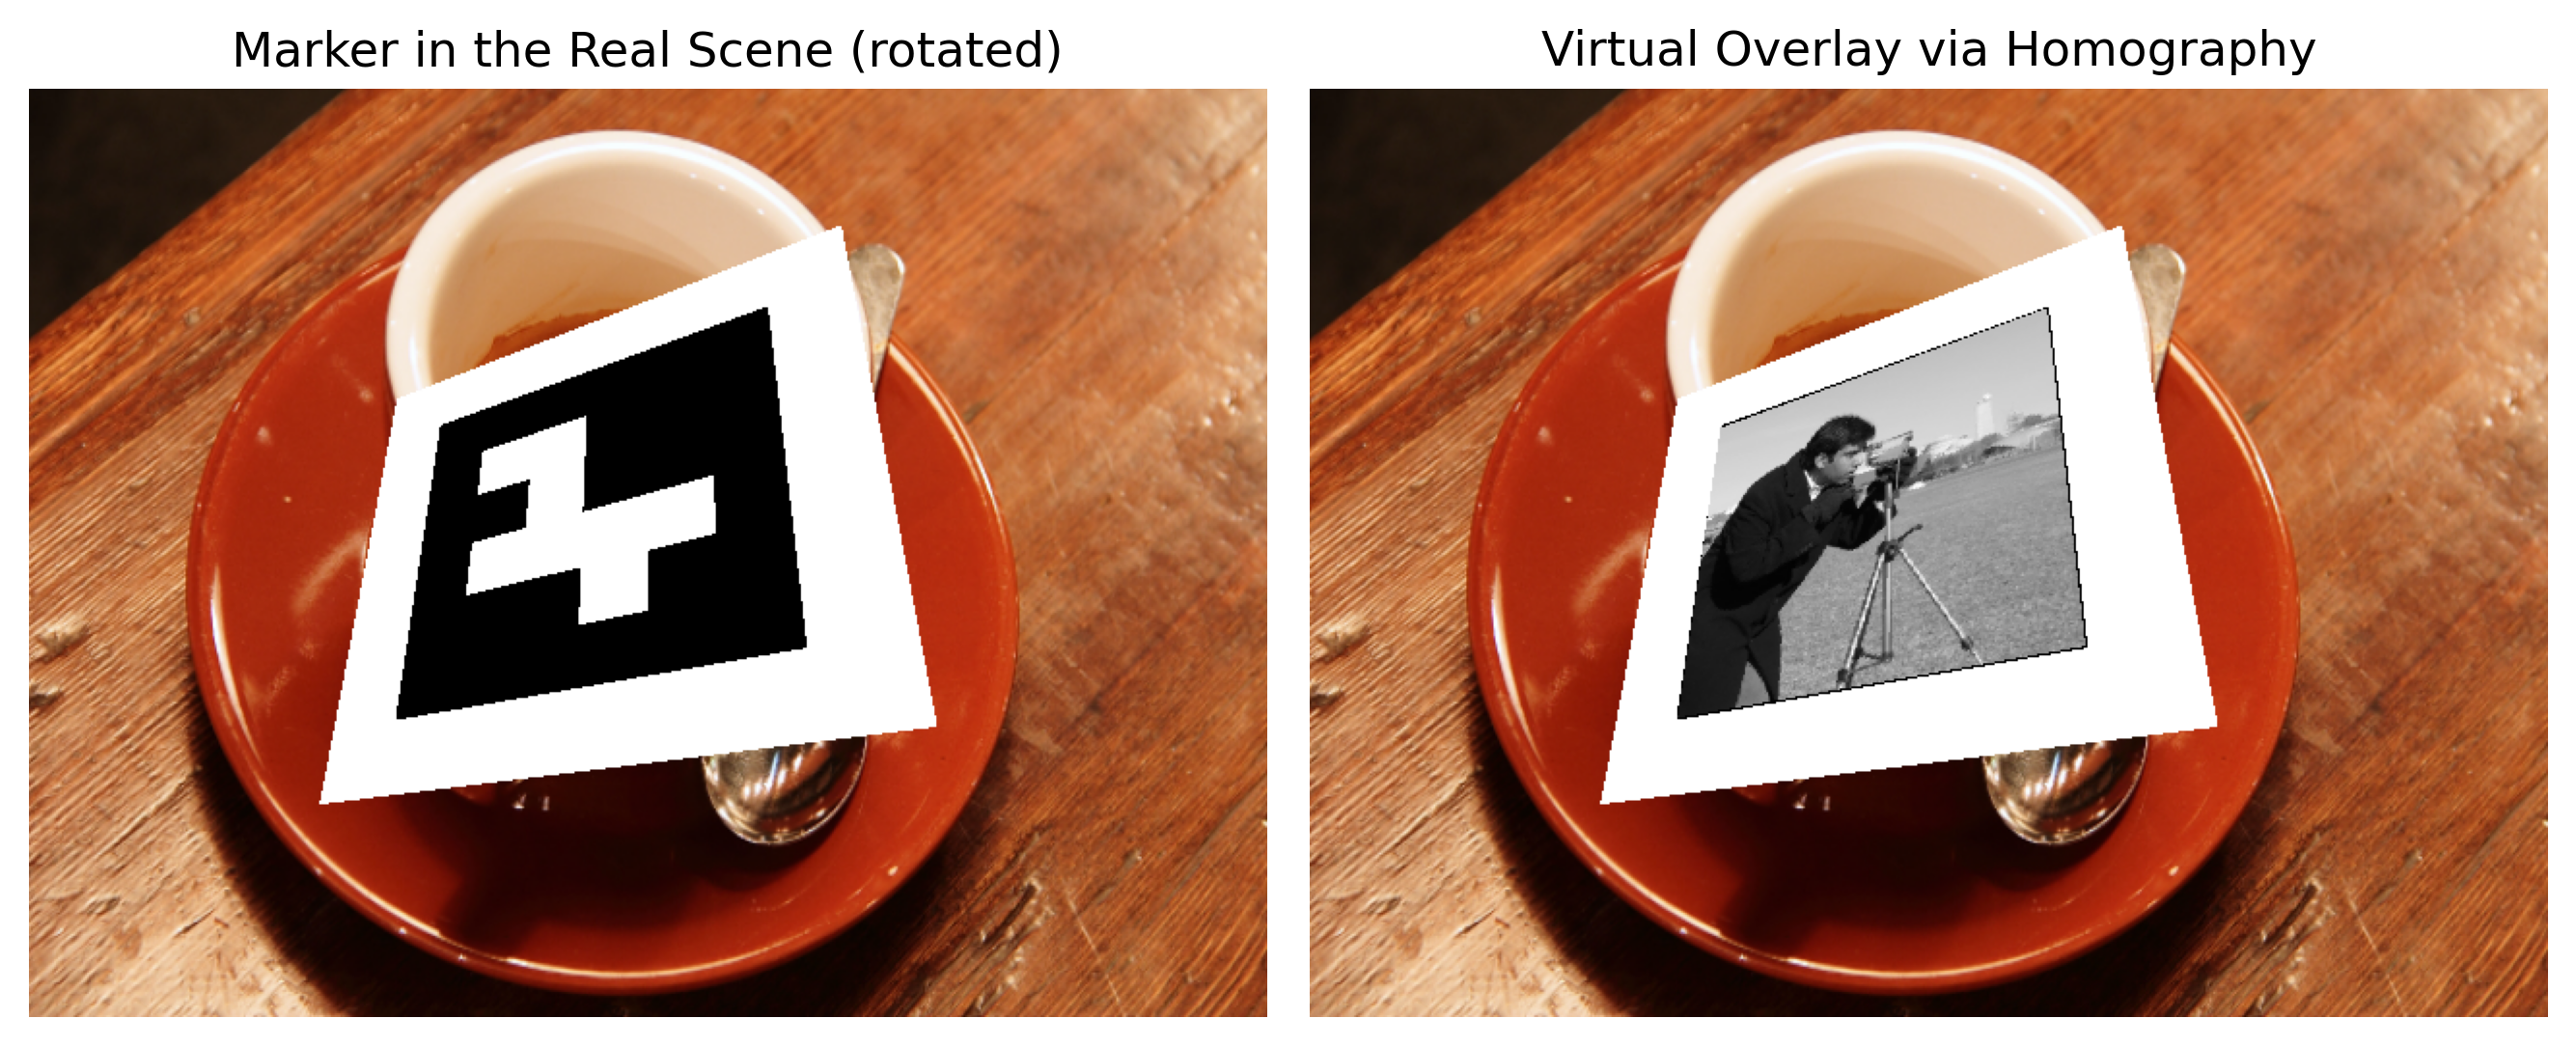

**Figure 9.41**


In [54]:
# | fig-cap: "Augmented reality based on ArUco marker: marker inserted in real scene and rotated, detected and replaced by virtual image via homography."
# | echo: true
# | output: true

# 1. Generation of the synthetic ArUco marker, already with white margin (quiet zone)
# → this margin is essential for the detector to be able to "see" the marker
dic = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_bruto = cv2.aruco.generateImageMarker(dic, 7, 200)
aruco_gray = cv2.copyMakeBorder(
    aruco_bruto, 40, 40, 40, 40, cv2.BORDER_CONSTANT, value=255
)  # 200 -> 280px, with 40px of white border on each side
aruco = cv2.cvtColor(aruco_gray, cv2.COLOR_GRAY2BGR)
lado = aruco.shape[0]  # 280

# 2. Real background scene, using an example image from skimage.data
fundo = cv2.cvtColor(skdata.coffee(), cv2.COLOR_RGB2BGR)
cena = cv2.resize(fundo, (640, 480))

# Corners of the "front-facing" marker (src) and its rotated/tilted position in the scene (dst)
src = np.float32([[0, 0], [lado, 0], [lado, lado], [0, lado]])
dst = np.float32([[190, 160], [420, 70], [470, 330], [150, 370]])  # rotation + perspective

# 3. Projects the marker (with sharp edges) onto the real scene
H_cena, _ = cv2.findHomography(src, dst)
mask_cena = cv2.warpPerspective(
    np.full((lado, lado), 255, np.uint8), H_cena, (640, 480),
    flags=cv2.INTER_NEAREST,
)
cena[mask_cena > 0] = cv2.warpPerspective(
    aruco, H_cena, (640, 480), flags=cv2.INTER_NEAREST
)[mask_cena > 0]

# 4. Detection of the marker within the scene (as a camera would)
det = cv2.aruco.ArucoDetector(dic, cv2.aruco.DetectorParameters())
corners, ids, _ = det.detectMarkers(cena)

assert ids is not None and len(corners) > 0, \
    "Marcador não detectado — confira iluminação/contraste da cena."

# 5. Virtual image (another image from skimage.data) that will "replace" the marker
# Note: we use the INNER square of the marker (without the margin) as the projection area,
# so the homography of the virtual image uses the original 'src' (200x200), not the 'side' with border
src_interno = np.float32([[0, 0], [200, 0], [200, 200], [0, 200]])
virtual = cv2.resize(
    cv2.cvtColor(skdata.camera(), cv2.COLOR_RGB2BGR), (200, 200)
)

# The detected corners correspond to the marker WITH the margin (280x280),
# so we recalculate H_ra using 'src' with margin, to keep the projection consistent
H_ra, _ = cv2.findHomography(src, corners[0][0])

# The detected homography is applied to the virtual image (resized to 'side')
virtual_grande = cv2.resize(virtual, (lado, lado))
ra = cena.copy()
mask_ra = cv2.warpPerspective(
    np.full((lado, lado), 255, np.uint8), H_ra, (640, 480), flags=cv2.INTER_NEAREST
)
ra[mask_ra > 0] = cv2.warpPerspective(
    virtual_grande, H_ra, (640, 480), flags=cv2.INTER_NEAREST
)[mask_ra > 0]

# Display: scene with marker vs. scene with Augmented Reality applied
mm.show(
    [cv2.cvtColor(cena, cv2.COLOR_BGR2RGB), cv2.cvtColor(ra, cv2.COLOR_BGR2RGB)],
    titles=["Marker in the Real Scene (rotated)", "Virtual Overlay via Homography"],
    cols=2,
    figsize=(9, 4),
)

**Pipeline summary:**

| Step | What it does | Key function |
|---|---|---|
| 1. Generation | ArUco marker with white border | `generateImageMarker` + `copyMakeBorder` |
| 2. Placement | Inserts distorted marker into the scene | `findHomography` + `warpPerspective` |
| 3. Detection | Locates marker and returns corners | `ArucoDetector.detectMarkers` |
| 4. Replacement | Projects virtual image onto the marker | `findHomography` + `warpPerspective` |

> 💡 **Lesson:** The detector "finding nothing" is common in CV. Always ask: **"did I provide enough contrast and space?"** — this applies to ArUco, QR codes, and facial recognition.

#### 9.5.5.2 Photogrammetry and Scale Reference

**Photogrammetry** enables the estimation of physical dimensions of objects from digital images. To achieve this, a reference object with known dimensions is placed in the same scene as the object of interest. This procedure establishes a relationship between distances measured in *pixels* and their corresponding dimensions in the real world.

Consider, for example, a credit card, whose dimensions follow the international standard ISO/IEC 7810. Since its width is exactly **8.56 cm**, it suffices to determine how many *pixels* this width occupies in the image to calculate the conversion factor between *pixels* and centimeters. If the card corresponds to 140 *pixels*, then each *pixel* will represent approximately **0.061 cm**. This same scale factor can be applied to estimate the dimensions of any other object located on the same plane of the scene, as illustrated in [Figure 9.42](#fig-09-fotogrametria).

The procedure can be divided into two main steps:

1. **Segmentation and bounding box:** locate, in the image, both the reference object and the object of interest, using techniques such as color segmentation, thresholding, contour detection, or object detection methods.
2. **Conversion to physical dimensions:** calculate the ratio $\mathrm{cm/pixel}$ from the known width of the reference object and use it to convert the measurements of the object of interest from *pixels* to centimeters.

> ### 📝 Nota
>
> **Condition for reliable measurements**
>
> The conversion between *pixels* and centimeters assumes that the reference object and the object of interest are approximately on the same plane and at the same distance from the camera. Under these conditions, the scale remains practically constant throughout the image. Differences in depth, camera tilt, or lens distortions can introduce errors in the estimated measurements.

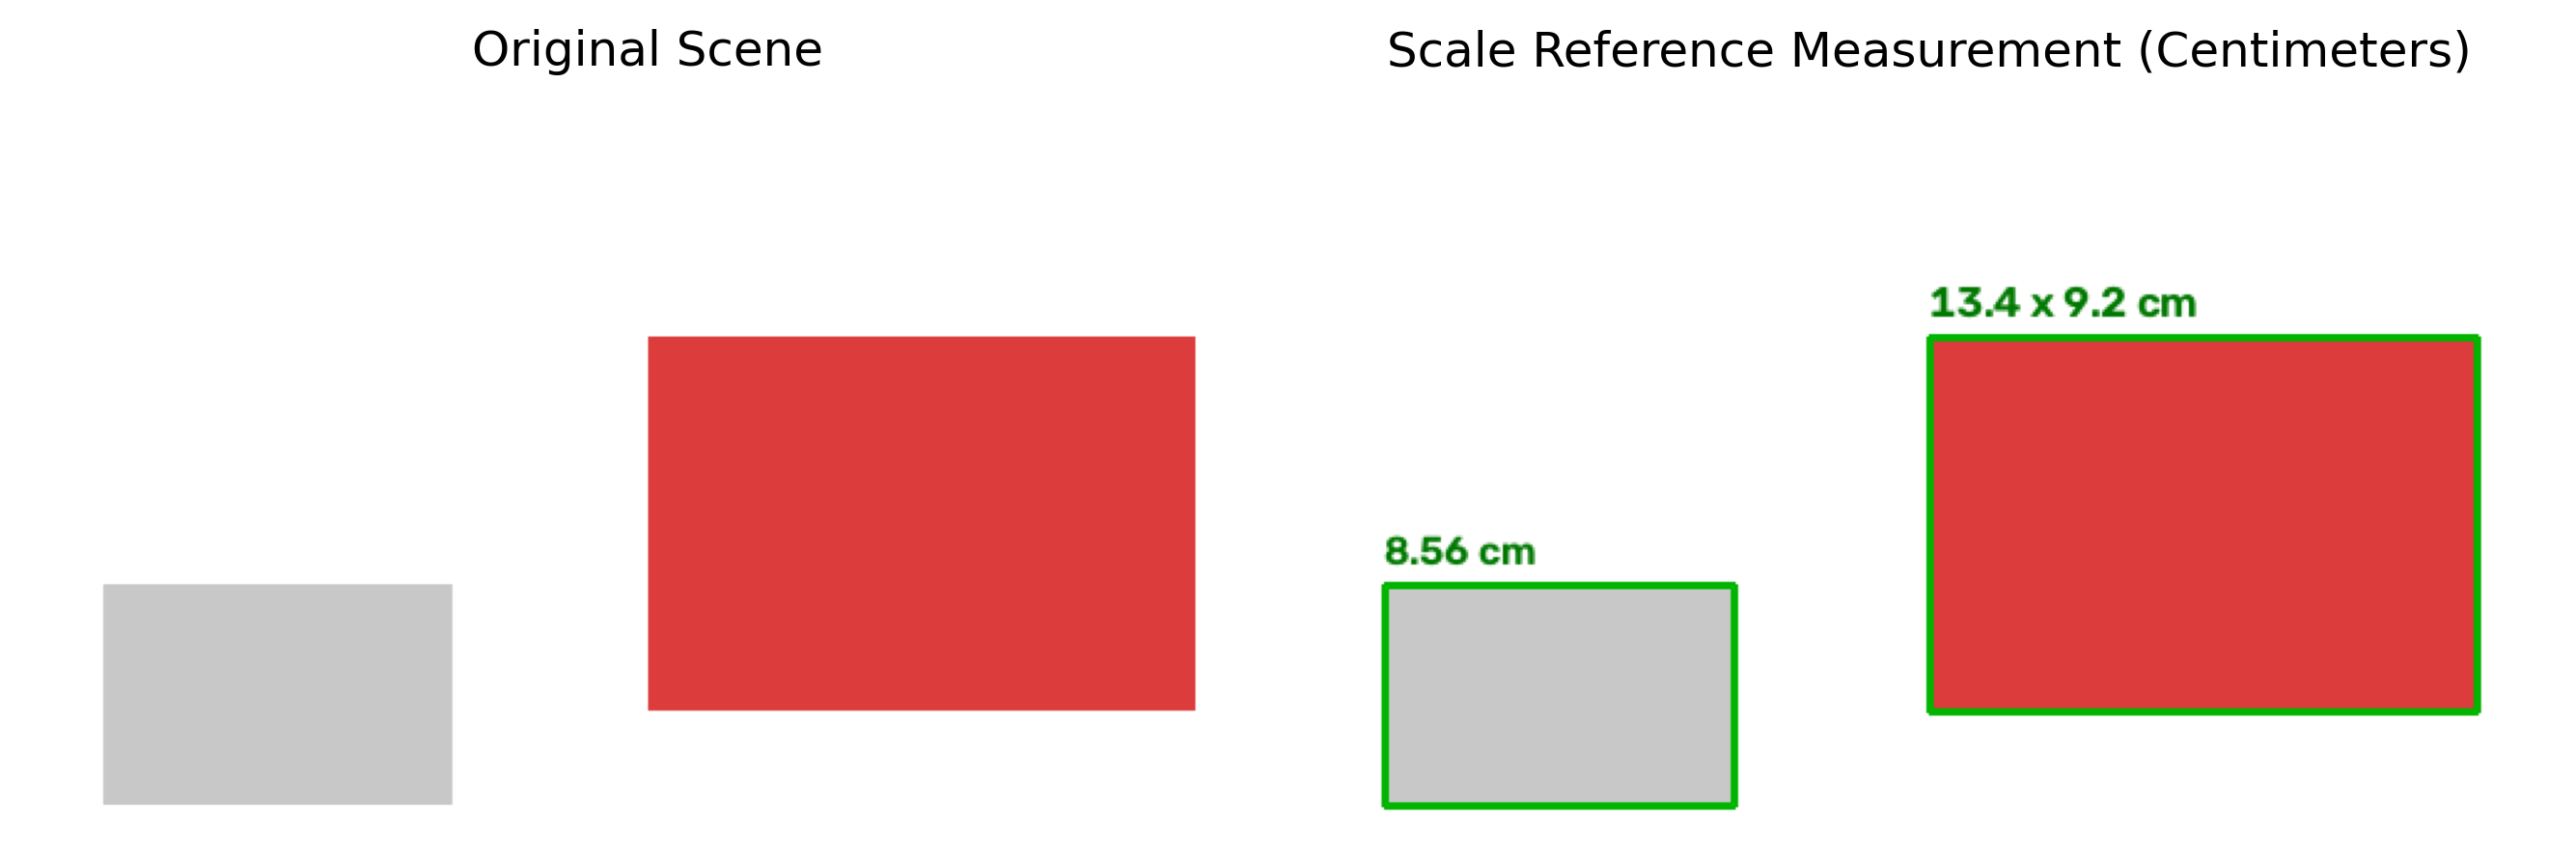

**Figure 9.42:** Measurement of real physical dimensions using a reference card with a known scale (8.56 cm) rendered. The gray rectangle represents the reference card and the blue rectangle represents the target object. The estimated dimensions of the object are displayed in centimeters.


In [55]:
COR_REFERENCIA = (200, 200, 200)  # Reference card (gray)
COR_OBJETO = (60, 60, 220)  # Target object (red)

# Synthetic scene drawing
cena_medicao = np.full((300, 500, 3), 255, dtype=np.uint8)
cv2.rectangle(
    cena_medicao, (30, 200), (30 + 140, 200 + 88), COR_REFERENCIA, -1
)
cv2.rectangle(cena_medicao, (250, 100), (250 + 220, 100 + 150), COR_OBJETO, -1)


def caixa_delimitadora_por_cor(imagem_bgr, cor_bgr, tolerancia=40):
    diferenca = np.abs(imagem_bgr.astype(int) - np.array(cor_bgr)).sum(axis=2)
    mascara = (diferenca < tolerancia).astype(np.uint8) * 255
    contornos, _ = cv2.findContours(
        mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    maior_contorno = max(contornos, key=cv2.contourArea)
    return cv2.boundingRect(maior_contorno)


x_ref, y_ref, w_ref_px, h_ref_px = caixa_delimitadora_por_cor(
    cena_medicao, COR_REFERENCIA
)
x_obj, y_obj, w_obj_px, h_obj_px = caixa_delimitadora_por_cor(
    cena_medicao, COR_OBJETO
)

# Physical scale calculation
LARGURA_REFERENCIA_CM = 8.56
razao_cm_por_px = LARGURA_REFERENCIA_CM / w_ref_px
largura_obj_cm = w_obj_px * razao_cm_por_px
altura_obj_cm = h_obj_px * razao_cm_por_px

# Drawing boxes and estimated measurements
resultado = cena_medicao.copy()
cv2.rectangle(
    resultado, (x_ref, y_ref), (x_ref + w_ref_px, y_ref + h_ref_px), (0, 180, 0), 2
)
cv2.rectangle(
    resultado, (x_obj, y_obj), (x_obj + w_obj_px, y_obj + h_obj_px), (0, 180, 0), 2
)

cv2.putText(
    resultado,
    f"{LARGURA_REFERENCIA_CM:.2f} cm",
    (x_ref, y_ref - 8),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.55,
    (0, 120, 0),
    2,
)

cv2.putText(
    resultado,
    f"{largura_obj_cm:.1f} x {altura_obj_cm:.1f} cm",
    (x_obj, y_obj - 8),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (0, 120, 0),
    2,
)

mm.show(
    [
        cv2.cvtColor(cena_medicao, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB),
    ],
    titles=[
        "Original Scene",
        "Scale Reference Measurement (Centimeters)",
    ],
    cols=2,
    figsize=(9, 4),
)

**Pipeline summary:**

| Step | What it does | Key function |
|---|---|---|
| 1. Synthetic scene | Draws the reference card and target object with distinct colors | `cv2.rectangle` |
| 2. Segmentation | Isolates each object by color and extracts its contour | `cv2.findContours` |
| 3. Bounding box | Obtains the bounding box (position and size in pixels) of each object | `cv2.boundingRect` |
| 4. Scaling | Converts pixels to centimeters using the known card width | Rule of three: $\text{cm/pixel} = \dfrac{8{,}56}{w_{ref\_px}}$ |
| 5. Annotation | Draws the boxes and displays the estimated measurements on the image | `cv2.rectangle` + `cv2.putText` |

> 💡 **Real-world application:** this is exactly the technique used by *e-commerce* apps that estimate the size of a product from a photo taken next to a card, by agricultural systems that measure fruit on conveyor belts, and even by forensic experts who calculate the dimensions of traces at crime scenes — all based on the same idea: **a known ruler within the photo itself.**

## 9.6 Summary

This chapter, which concludes Part II of the book, presented:

* **Learned convolution and pooling:** the same mathematical convolution
  operation from Chapter 3, but with kernels treated as parameters
  adjusted through training, rather than defined manually;

* **Weight sharing and feature hierarchy** as
  properties that make CNNs efficient and capable of learning
  increasingly abstract representations in successive layers;

* **Training a CNN from scratch**, with performance comparable — and not
  necessarily superior — to the classical classifiers from Chapter 7
  on a small and simple dataset, reinforcing that the choice of method should
  be proportional to the actual complexity of the problem;

* **Transfer learning**, experimentally demonstrated as an
  effective strategy for tasks with few labeled data, reusing
  a feature extractor already trained on a related task, and
  its limitations, evidenced by negative transfer between
  very distinct domains;

* **Large-scale applications** with pre-trained models for classification,
  detection (*Faster R-CNN*), and segmentation (*DeepLabV3*), following the same
  principle of transfer learning at an industrial scale;

* **Transfer learning applied to object detection**, fine-tuning
  a YOLO pre-trained on COCO to locate and classify synthetic
  geometric objects, illustrating the same principle of partial
  freezing in source and target domains that are even more distant from each other;

* **Semantic segmentation with U-Net**, implemented and trained from scratch on
  a synthetic low-contrast dataset, outperforming a classical
  thresholding baseline thanks to the skip connections between encoder and
  decoder;

* **Data engineering for Computer Vision with Roboflow**, using
  a dataset and a pre-trained model to perform inference in geometric
  object detection, as well as comparing datasets with different
  resolutions but with the same object classes;

* The integration of **computational geometry** (homography and calibration) and
  **deep learning** in two real applications that conclude the book:
  **augmented reality** and **photogrammetry**.

## 9.7 🤖 Using Gemini Notebook as a Complementary Tutor

In this edition, the use of **Gemini Notebook** is encouraged as a
complementary learning tool. Based on artificial intelligence, the system
uses exclusively the documents provided by the author as its source of
knowledge, producing responses aligned with the content and approach
adopted throughout this chapter.

> ### ❗ 🎓 Study with the Intelligent Tutor
>
> [🚀 ACCESS Gemini Notebook: CHAPTER 09](https://notebooklm.google.com/notebook/88495fa2-9139-45da-8d1b-9a9b2e609d36)
>
> #### 🌐 Language and Programming Language
>
> The project for this chapter in Gemini Notebook was built using only the text in **Portuguese** and the code examples in **Python**. If you are studying from the English or French edition, or following the C++ track, the tutor's responses may not correspond exactly to the version you are reading.
>
> #### ⚠️ Notice Regarding AI-Generated Content
>
> Although it is a valuable study support tool, Gemini Notebook may
> occasionally produce incomplete, inaccurate, or incorrect responses.
> It is recommended that you validate the information by consulting the
> chapter material, books, scientific articles, and other reliable academic
> sources. Whenever possible, run and experiment with the practical examples
> presented throughout the text to consolidate your understanding of the
> concepts.

## 9.8 Exercise List

The following exercises consolidate the concepts presented in this chapter through adaptations, experiments, and extensions of the algorithms developed throughout the text, using the `PyTorch`, `ultralytics`, and the didactic library `morph`.

1. **(10%)** Investigate the impact of depth on a convolutional architecture. Starting from the two-layer network of Practical Project 1, add a third convolutional layer with 32 filters before the fully connected layers. Train the new architecture keeping the same number of epochs and the same data split. Compare the accuracy on the test set and the total number of trainable parameters relative to the original network, discussing whether the increase in depth brought a measurable benefit for images of dimension $8 \times 8$.

2. **(15%)** Evaluate the data threshold required in the target domain for training a CNN from scratch to become competitive with **transfer learning**. Varying the number of training samples available in domain B over $\{5, 10, 20, 40, 80\}$, measure the test accuracy for both strategies. Present the results in a line plot and determine from which data volume training from scratch achieves performance equivalent to the pre-trained extractor.

3. **(15%)** Investigate the **partial fine-tuning** strategy compared to total weight freezing. In the transfer learning scenario between digit domains, unfreeze the second convolutional layer (`conv2`) of the extractor so that it is updated together with the classification head during training on domain B. Compare the accuracy obtained with total freezing and with training from scratch, discussing the trade-off between adaptation capacity and the risk of overfitting.

4. **(20%)** Evaluate the influence of freeze depth on the performance of **YOLO** detectors subjected to transfer learning. Using the synthetic dataset of geometric shapes, perform fine-tuning while varying the backbone freezing parameter over $\{0, 5, 10, 15\}$. Record the $\text{mAP}_{50}$ metric on the validation set for each configuration, present the data in a table, and discuss whether partial freezing is advantageous when the source (COCO) and target (geometric shapes) domains are significantly distinct.

5. **(20%)** Study the importance of **skip connections** in the **U-Net** architecture for semantic segmentation. Implement a variation `UNetSemAtalhos` that functions as a traditional convolutional *autoencoder*, removing the concatenations between the encoder and decoder stages. Train both models on the same base of synthetic nodules, compare the mean IoU on the validation set, and visually present the difference in the accuracy of the edges segmented by each method.

6. **(20%) — Challenge: semantic segmentation with *Roboflow*.** Use a *Roboflow* project of the *instance segmentation* type, containing the seven classes of geometric shapes used in this chapter. Export the *dataset* in the `coco-segmentation` format and develop a procedure to convert the polygons stored in the `_annotations.coco.json` files into multiclass semantic masks, in which each pixel receives the index of the corresponding class and the value `0` represents the background. Use the resulting images and masks to train `UNetCompacta`. Evaluate the mean IoU on the test set and visually compare the predicted masks with the original annotations. Discuss the main difficulties encountered in converting COCO annotations to masks and the effects of overlapping objects or objects belonging to different classes.

7. **(Bonus – 10%)** Develop an interactive system that combines **object detection (YOLO)** with **scale reference measurement (photogrammetry)**. Train the detector to identify two classes in a scene: a "Reference Card" (known dimension of $8{,}56\text{ cm} \times 5{,}39\text{ cm}$) and a "Target Object." When performing inference on a new image, use the pixel dimension of the detected card's *bounding box* to convert the target object's box dimensions into centimeters. Display the processed image with class labels, confidence probability, and estimated physical dimensions overlaid.

8. **(Bonus – 10%)** Develop a **stereo vision depth estimation** system from two images of the same scene obtained from different positions, simulating a pair of stereo cameras. Assume that the distance between the two capture positions (*baseline*) is known.

   Use one of the **object detection** methods presented in the chapter, such as YOLO, to locate the objects of interest in both images. For each detection, establish the correspondence between the same object in the two positions and determine its **disparity**. From the disparity, the *baseline*, and the camera parameters, use stereo geometry to estimate the distance of each object relative to the cameras.

   As an extension of the didactic library `morph`, modify the `showBoundBox` method so that, in addition to the **class** and **detection confidence**, it displays the **estimated distance of the object** over each *bounding box*. The result should allow visualizing, directly in the images, the class, the accuracy (confidence), and the depth of each detected object.

   Present the two images with the detections, the correspondences between the objects, the disparity image, and a representation of the estimated depth. Discuss how the distance between the cameras, the accuracy of detection and correspondence, the image resolution, and the object's position in the scene influence the quality of the estimate.

   For validation, use at least one object whose distance to the camera is known. Compare the estimated depth with the actual value and report the **absolute error** and the **relative error**. Also discuss the limitations of the method when an object is not correctly detected in both images or when the correspondence between the observed regions is ambiguous.

## 9.9 Closing of Part II

This chapter concludes Part II of the book and closes the sequence of content initiated in Chapter 6, dedicated to the representation, detection, description, and matching of features in images. Throughout these chapters, classical CV methods based on **handcrafted features**, such as Sobel, LBP, HOG, ORB, and Haar Cascade, were presented, as well as methods grounded in **automatically learned features**, represented by CNNs.

The examples and experiments developed show that none of these approaches is universally superior. The choice of the most appropriate technique depends on the characteristics of the problem, the availability of training data, the accuracy requirements, and the computational constraints of the application. In well-structured problems with limited data, classical descriptors often offer simple and efficient solutions. Conversely, more complex tasks tend to benefit from the learning capacity provided by CNNs.

Several study directions can deepen the concepts presented in this part of the book, among which the following stand out:

- **Modern CNN architectures**, such as ResNet, EfficientNet, and *Vision Transformers*, which expand representation capacity and performance in visual classification and recognition tasks;
- **Object detection and segmentation**, with emphasis on the YOLO families and on prompt-based segmentation models, such as *Segment Anything*;
- **Three-dimensional reconstruction and SLAM** (*Simultaneous Localization and Mapping*), which use multiple images to estimate scene geometry and the trajectory of moving cameras;
- **Generative image models**, such as generative adversarial networks (GANs) and diffusion models, capable of synthesizing realistic images from examples or textual descriptions.

The fundamentals developed throughout Part II constitute the basis for these and other advanced CV areas, in which the adequate representation of visual information remains a central element for the analysis and understanding of images.

## Chapter References

The concepts and algorithms presented in this chapter were grounded in classic and contemporary references from the Deep Learning literature applied to VC:

* Mcculloch (1943), for proposing the first mathematical and logical abstraction of the artificial neuron, establishing the conceptual foundations of computational neural processing.
* Rosenblatt (1958), for the original formulation of the **Perceptron**, the precursor model of the artificial neuron used in modern deep learning architectures.
* Goodfellow (2016) and Lecun (2015), for the fundamentals of neural networks, convolution, activation functions, and training of deep models.
* Bishop (2006), for rigorous concepts of pattern recognition, probability, maximum likelihood estimation, and statistical methods applied to machine learning.
* Ronneberger (2015) for the **U-Net** architecture, used in semantic segmentation with skip connections between encoder and decoder.
* Redmon (2016), for the **YOLO** (*You Only Look Once*) architecture, used in object detection experiments with transfer learning.
* Ren (2015), for the **Faster R-CNN** architecture, employed as a pretrained object detection model.
* He (2016), for the **ResNet** architecture, the basis of several pretrained feature extractors used in this chapter.
* Chen (2018), for the **DeepLabV3** architecture, used as a pretrained semantic segmentation model.
* Kirillov (2023), for the **Segment Anything (SAM)** model, mentioned as a study direction for promptable segmentation.
* {google} (2025), referring to the **Gemini Notebook** tool, used in the preparation of the chapter's summary infographic and made available as supplementary study support.

## Chapter References


BISHOP, C. M. **Pattern Recognition and Machine Learning**. New York, NY, USA, Springer, 2006.

CHEN, Liang-Chieh *et al*. **Encoder-Decoder with Atrous Separable Convolution for Semantic Image Segmentation**. Cham, Springer International Publishing, 2018.

GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. **Deep Learning**. Cambridge, MA, USA, MIT Press, 2016.

HE, Kaiming *et al*. **Deep Residual Learning for Image Recognition**. 2016.

KINGMA, D. P.; BA, J. **Adam: A Method for Stochastic Optimization**. San Diego, CA, USA, 2015.

KIRILLOV, Alexander *et al*. **Segment Anything**. 2023.

LECUN, Y.; BENGIO, Y.; HINTON, G. **Deep learning**. Nature Publishing Group, 2015.

MCCULLOCH, W. S.; PITTS, W. **A Logical Calculus of the Ideas Immanent in Nervous Activity**. 1943.

PARKHI, Omkar M. *et al*. **Cats and Dogs**. IEEE, 2012.

REDMON, Joseph *et al*. **You Only Look Once: Unified, Real-Time Object Detection**. 2016.

REN, Shaoqing *et al*. **Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks**. Curran Associates, Inc., 2015.

RONNEBERGER, O.; FISCHER, P.; BROX, T. **U-Net: Convolutional Networks for Biomedical Image Segmentation**. Cham, Switzerland, Springer, 2015.

ROSENBLATT, F. **The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain**. 1958.

{GOOGLE}. **{NotebookLM}**. 2025.

*Reference not found for: 50*